# NB03e — Derived Products: Composites, Landuse, Temporal Statistics v40

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


>
> This program is free software: you can redistribute it and/or modify
> the Free Software Foundation, either version 3 of the License, or
> (at your option) any later version.
>
> This program is distributed in the hope that it will be useful,
> but WITHOUT ANY WARRANTY; without even the implied warranty of
> MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
>
> along with this program. If not, see <https://www.gnu.org/licenses/>.

| Field | Value |
|---|---|
| Notebook | `03e_bda_Composites_Landuse_Statistics_v40.ipynb` |
| Version | `v40` |
| Pipeline position | Product derivation. After NB03a/b/c + NB03d (audit). Before NB03f (derived prune) and NB04a (QA). |
| License | Code: AGPL-3.0-or-later — see [LICENSE](../LICENSE) |
| Last validated | 2026-04-14 |

## Narrative

The largest processing notebook in the pipeline (~5000 lines). Transforms source-level
TIFs (per-date backscatter, coherence, multispectral bands) into analysis-ready derived
products. All products are TIFs stored in `SATELLITE_DIR` and `TEMPORAL_ROOT`.
NB03f audits/prunes these products, NB04a runs QC/QA, then NB05a copies and aligns
them into the portable `data_stack`.

---

## Cell RASTERIZE: Building Footprints + Damage to Raster Masks

Creates `building_labels.tif` (int32, 1-based building IDs) and `damage_mask.tif`
(int8: -1=unlabeled, 0=undamaged, 1=damaged) per city. Reads AOI.geojson buildings
from CITIES_DIR, writes to STACK_DIR. This is a prerequisite product — NB05 feature
extraction requires these raster masks for zonal statistics.

---

## Cell P5: Cloud Mask from SCL Band

Reads the clipped SCL (Scene Classification Layer) from Sentinel-2 L2A and creates a
binary cloud mask per scene date.

**ESA Sen2Cor SCL classes:**
0=no_data, 1=saturated, 2=dark_area, 3=cloud_shadow, 4=vegetation, 5=not_vegetated,
6=water, 7=unclassified, 8=cloud_medium, 9=cloud_high, 10=thin_cirrus, 11=snow_ice

**Cloud mask logic:** SCL in {0, 1, 3, 8, 9, 10} = 1 (unusable), else = 0 (clear).
Classes 2 (dark_area) and 11 (snow_ice) are kept as clear because dark areas may be
shadows of intact buildings and snow is handled separately in landuse classification.

**Cloud frequency map:** Per-period fraction of dates flagged cloudy per pixel
(`s2__qa__cloud_freq.tif`). Used as QA metric — pixels with >80% cloud frequency
across a period have unreliable composites.

| Input | Output |
|-------|--------|
| `MS_DIR/{city}/s2__scl__{date}.tif` | `s2__cloud_mask__{date}.tif` per date |
| | `composites/{period}/s2__qa__cloud_freq.tif` |

---

## Cell 18A: Land Use Classification — Per-Date, Per-Pixel (v3)

### Purpose
This classification is **NOT** a standalone land use map. It is a **pre-filter and
feature generator** for downstream Building Damage Assessment (BDA).

The goal is to label every pixel as one of a few simple classes so that the
prebattle-vs-postbattle **transition matrix** reveals damage signals without needing
deep learning for the obvious cases.

### Why This Matters for BDA

1. **Compute efficiency**: Masking permanent water and forest avoids wasting compute
   on pixels that can never be damaged buildings.

2. **Transition matrix** gives strong damage signals for free:

| Prebattle | Postbattle | Interpretation |
|-----------|------------|----------------|
| Urban | Urban | Likely intact (or rebuilt) |
| Urban | Bare Soil | **STRONG DAMAGE** (demolished) |
| Urban | Vegetation | **DAMAGE + TIME** (rubble + regrowth) |
| Vegetation | Vegetation | Never was a building, skip in ML |
| Vegetation | Bare Soil | Shelling/clearing, not building damage |
| Bare Soil | Urban | New construction |

   The ML model then only needs to work hard on ambiguous cases like urban→urban
   where damage is subtle or partial.

3. **Pioneer vegetation on rubble**: If a building is destroyed and enough time passes
   (>6 months to >1 year), pioneer plants colonize the rubble. A naive approach would
   classify this as "vegetation" and discard it, missing the damage entirely. By keeping
   ALL classes and comparing pre vs post, we catch this: prebattle=urban,
   postbattle=vegetation = rubble with regrowth = damage. Therefore we NEVER discard
   any class.

4. **Snow handling**: Snow is flagged but NOT used for transition analysis because snow
   is seasonal and can cover intact rooftops. Snow dates should be excluded from
   pre/post comparison or treated as nodata in the transition matrix.

### Classification Approach

Simple hierarchical thresholds. Per-pixel, no spatial merging, no morphological
filtering. Granularity is preserved for the ML pipeline.

**Order:** Snow → Water → Vegetation → Sparse Veg → Urban → Bare Soil

### Spectral Indices Used

| Index | Formula | Purpose | Reference |
|-------|---------|---------|-----------|
| NDVI | (B8-B4)/(B8+B4) | Vegetation detection | Tucker 1979 |
| NDBI | (B11-B8)/(B11+B8) | Built-up detection (primary) | Zha et al. 2003 |
| MNDWI | (B3-B11)/(B3+B11) | Water detection | Xu 2006 |
| NDSI | (B3-B11)/(B3+B11) | Snow detection (same formula as MNDWI, separated by NIR gate) | Dozier 1989 |

**Diagnostic indices** (computed + saved as TIFs, NOT used in classification):

| Index | Formula | Purpose | Reference |
|-------|---------|---------|-----------|
| BSI | ((B11+B4)-(B8+B2))/((B11+B4)+(B8+B2)) | Bare Soil Index | Rikimaru et al. 2002 |
| IBI | (NDBI-(SAVI+MNDWI)/2)/(NDBI+(SAVI+MNDWI)/2) | Built-up (too strict as classifier, useful as ML feature) | Xu 2008 |
| SAVI | ((B8-B4)/(B8+B4+0.5))*1.5 | Soil-adjusted veg, component of IBI | Huete 1988 |
| UI | (B12-B8)/(B12+B8) | Urban Index (SWIR2-based alternative to NDBI) | — |
| BAEI | (B4+0.3-B8-B2)/(B4+B11+B8+B2) | Built-up Area Extraction | — |

### Thresholds Per Class

**1. Snow** (Dozier 1989; Hall et al. 2002):
NDSI > 0.4 AND B8 > 0.11 AND B3 > 0.1.
B8 > 0.11 separates snow (high NIR) from water (low NIR). B3 > 0.1 avoids dark
shadows being classified as snow. Snow on rooftops IS snow — skip snow dates in
transition analysis.

**2. Water** (Xu 2006 MNDWI, strict):
MNDWI > 0.3 AND NDVI < 0.0 AND B8 < 0.15.
MNDWI 0.3 avoids wet soil, shadows, snow false positives. NDVI < 0 confirms no
floating/aquatic vegetation. B8 < 0.15 confirms water absorbs NIR strongly.

**3. Dense Vegetation** (Tucker 1979, season-aware):
Summer (Apr-Sep): NDVI > 0.5. Winter (Oct-Mar): NDVI > 0.3.
Winter thresholds lower to catch conifers and winter wheat. Standard European
growing-season threshold.

**4. Sparse Vegetation:**
Summer: 0.2 < NDVI <= 0.5. Winter: 0.15 < NDVI <= 0.3.
Grassland, shrubs, pioneer vegetation on rubble. Kept separate because sparse veg
on rubble is ambiguous for BDA.

**5. Urban / Built-up** (Zha et al. 2003):
NDBI > 0.0 AND NDVI < 0.15 AND MNDWI < 0.0.
NDBI > 0.0 is the original Zha 2003 threshold restored. The prior -0.05 was too
permissive in Ukrainian winter scenes — dry/senescent vegetation, sparse grassland,
and bare soil (slightly negative NDBI -0.05 to 0.0) were inflating urban class by
5-15%. Known issue: bare soil also has positive NDBI, but in city-clipped AOIs most
non-vegetated area IS urban.

**6. Bare Soil:** Residual class. Everything valid remaining: fallow land, rubble,
exposed earth, roads. In BDA context: bare soil postbattle where urban was prebattle
is a strong damage indicator.

### Class Encoding

| Code | Class | Notes |
|------|-------|-------|
| 0 | NoData | Invalid/masked pixels |
| 1 | Snow | Flag only — exclude from transitions |
| 2 | Water | Permanent water bodies |
| 3 | Dense Vegetation | NDVI > 0.3/0.5 (season-dependent) |
| 4 | Sparse Vegetation | Grassland, pioneer veg on rubble |
| 5 | Urban / Built-up | NDBI-primary detection |
| 6 | Bare Soil | Residual class, strong damage indicator |

### Transition Matrix Encoding

`transition[y,x] = prebattle_class * 10 + postbattle_class`

Primary damage codes: **53** (urban→veg), **54** (urban→sparse), **56** (urban→bare).
Code 55 (urban→urban) needs ML for subtle/partial damage. Codes 33, 34, 44 are permanent
non-building, safe to exclude from ML. Snow codes (1x, x1) treated as nodata.

---

## Cell P2: Multispectral Winter Baseline Composite (Pre + Post)

Reads clipped S2 band TIFs, groups by temporal window (using `compute_temporal_windows()`),
stacks per band, computes per-pixel **median** composite, then classifies landuse on the
median reflectance.

**Why median then classify (not classify then vote):** Median reflectance smooths cloud
residuals and atmospheric noise *before* thresholding. Per-date classification followed
by majority voting would propagate noisy per-date classifications. Median-then-classify
is scientifically cleaner.

Winter months selected via `MS_WINTER_MONTHS` in global_setup. For periods with only 1
scene: passthrough (no median needed).

| Output per period | Description |
|-------------------|-------------|
| `s2__composite__b02.tif` ... `s2__composite__b12.tif` | Median reflectance per band |
| `s2__composite__ndvi.tif` | NDVI computed on median composite |
| `s2__composite__mndwi.tif` | MNDWI computed on median composite |
| `s2__composite__ndbi.tif` | NDBI computed on median composite |
| `s2__composite__landuse.tif` | Landuse classified on median composite |
| `s2__obs_count.tif` | Number of cloud-free observations per pixel |
| `composite_meta.json` | Scene dates, cloud stats, period metadata |

---

## Cell P2b: RGB GeoTIFF Generator

Creates 3-band uint8 RGB GeoTIFFs from every clipped MS scene and from composites.
For visualization in GeoNode, GIS databases, QGIS, and thesis figures.

**Stretch:** 2-98 percentile per band → 0-255 uint8.

---

## Cell P4: NBR Per-Scene + dNBR/RBR from Composites

Computes Normalized Burn Ratio **per individual scene** (not composite).

| Index | Formula | Reference |
|-------|---------|-----------|
| NBR | (NIR - B12) / (NIR + B12) | Key and Benson 2006 |
| dNBR | NBR_pre - NBR_post | Standard |
| RBR | dNBR / (NBR_pre + 1.001) | Parks et al. 2014 |

**NIR band preference:** B8A (865nm, 20m) over B08 (842nm, 10m) — better spectral
alignment with SWIR2 (B12, 20m).

dNBR and RBR are computed from P2 composite NBR (already created per-period), not from
per-scene NBR. This gives a single pre-vs-post burn severity map per city.

Cloud masks from P5 are applied: cloudy pixels in per-scene NBR are set to NaN.

---

## Cell P6: Visibility and Fire Product (Cloud + Smoke + Fire)

Combined per-date visibility product from multiple S2 bands + SCL. Detects clouds,
smoke, fire, and burn scars. Swiss firefighter use case: fire detection in mountain
terrain. Conflict use case: oil fires, infrastructure fires, smoke plumes.

### Visibility Classes

| Code | Class | Detection Method |
|------|-------|------------------|
| 0 | Clear | Default |
| 1 | Cloud | SCL 8, 9 |
| 2 | Cloud Shadow | SCL 3 |
| 3 | Thin Cirrus | SCL 10 |
| 4 | Dense Smoke | B01/B04 > 1.8, SWIR2 < 0.15, not SCL cloud |
| 5 | Light Haze | B01/B04 > 1.3, reduced contrast |
| 6 | Active Fire | SWIR2 > 1.0 (saturation) + B04 < 0.15 + NBR < -0.25 |
| 7 | Burned Area | NBR < -0.25, no thermal anomaly |
| 8 | Saturated | SCL 1 |
| 9 | Dark Area | SCL 2 |

### Smoke and Fire Thresholds

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `SMOKE_B01_B04_RATIO` | 1.8 | B01 (coastal aerosol, 60m) elevated relative to B04 (red) |
| `HAZE_B01_B04_RATIO` | 1.3 | Lighter threshold for haze |
| `SMOKE_SWIR2_MAX` | 0.15 | SWIR2 must be low for smoke (not fire) |
| `FIRE_SWIR2_MIN` | 1.0 | Sensor saturation level thermal anomaly |
| `FIRE_B04_MAX` | 0.15 | Fire emits in SWIR but is dark in visible |
| `FIRE_NBR_MAX` | -0.25 | Strongly negative NBR = active burn |
| `BURN_NBR_MAX` | -0.25 | Conservative burn scar threshold |

**WARNING:** Smoke B01/B04 ratio method is **ad-hoc and unpublished**. Surface-type
dependency makes fixed thresholds unreliable. Results are low-confidence. SCL gating
applied: exclude SCL cloud classes before smoke test to avoid double-counting cloud
edges as smoke.

**Fire threshold fix:** B12 > 0.30 previously flagged ordinary bare soil and urban
surfaces as fire. Combined with NBR = -0.10 to -0.35, this caused 30-55% false fire
in winter scenes. New thresholds: B12 > 1.0 (sensor saturation) + B04 < 0.15 (fire is
dark in visible). Burn scar: NBR < -0.25 with land-cover pre-mask (exclude water/snow/urban).

**Output format:** Per-scene binary TIFs (`active_fire.tif`, `burn_scar.tif`), NOT
averaged composites. Fire is an event, not a statistic.

---

## Cell P1: CARD-BS Temporal Statistics (Baseline + Assessment)

Computes per-pixel temporal statistics from CARD-BS backscatter scenes. This directly
produces the Dietrich et al. (2025) features.

**Periods:**
- **Baseline:** prebattle dates (before `battle_start`)
- **Assessment:** postbattle dates (after `battle_end`)

**Statistics (7 per polarization per period):** min, max, mean, median, std, kurtosis,
skewness. With 2 polarizations (VV, VH) x 2 periods x 7 stats = 28 CARD features.
These are 14 of the 28 Dietrich features.

| Input | Output |
|-------|--------|
| `SAR_CARD_DIR/{city}/s1__{pol}__{date}.tif` | `temporal_stats/s1__{pol}__baseline__{stat}.tif` |
| | `temporal_stats/s1__{pol}__assessment__{stat}.tif` |

---

## Cell P3: Coherence Baseline Temporal Statistics

Computes per-pixel temporal statistics from InSAR coherence pairs. **Prebattle only.**
Stats: min, max, mean, median, std (5, not 7 — kurtosis/skewness omitted because
coherence time series are shorter than CARD).

| Input | Output |
|-------|--------|
| `SAR_COH_DIR/{city}/s1__coh_{vv\|vh}__...PRE...tif` | `coherence_baseline/s1__coh_baseline__{stat}.tif` |

---

## Cell R1: Post-Battle Coherence Baseline + Z-Scores

Computes post-battle coherence baseline stats from POST-labeled COH pairs. Also
computes per-date **z-score anomaly maps**:

**Z-score = (coh_date - pre_mean) / pre_std**

A z-score of -2 means coherence dropped 2 standard deviations below the pre-battle
mean — strong damage signal. Z-scores normalize across cities with different baseline
coherence levels, enabling cross-city comparison.

| Input | Output |
|-------|--------|
| POST COH TIFs + P3 baseline stats | `post_baseline/s1__coh_post_baseline__{stat}.tif` |
| | `zscore/s1__coh_zscore_VV__{d1}.tif` per date |

---

## Cell R2: Rolling Multi-Window Temporal (COH + CARD)

**First systematic comparison of rolling window lengths for SAR conflict BDA.**
No published study compares window sizes for building damage assessment.

Computes rolling mean at multiple window sizes for temporal smoothing. Scenes loaded
ONCE per city per sensor, all windows computed from memory.

| Window | Scenes | Duration (at 12-day S1A revisit) | Character |
|--------|--------|----------------------------------|-----------|
| roll3 | 3 | ~36 days (~1 month) | Fine-grained, captures rapid changes |
| roll7 | 7 | ~84 days (~3 months) | **Closest to Dietrich 3-month window** |
| roll13 | 13 | ~156 days (~6 months) | Maximum smoothing, stable baseline |

Configured via `ROLLING_WINDOW_SIZES = [3, 7, 13]` in `global_setup.py`.
Previous sizes roll2/roll5 were purged (~421 GB deleted) after analysis showed
they added no discriminative value over the 3/7/13 set.

| Input | Output |
|-------|--------|
| COH: `SAR_COH_DIR/{city}/s1__coh_...tif` | `TEMPORAL_ROOT/{city}/COH/rolling/s1__coh_vv__roll{N}__{d1}.tif` |
| CARD: `SAR_CARD_DIR/{city}/s1__{pol}__{date}.tif` | `TEMPORAL_ROOT/{city}/CARD/rolling/s1__{pol}__roll{N}__{date}.tif` |

---

## Cell P1b: Rolling Window Temporal Statistics (Assessment Only)

Same 7-stat aggregation as P1 but reading from R2 rolling mean TIFs instead of raw scenes.
**Assessment period only** — baseline stats already exist from P1 (CARD) and P3 (COH) on
raw TIFs and are reused.

**Why roll7 matters:** roll7 (~84 days at 12-day S1 revisit) is the closest equivalent to
Dietrich's 3-month assessment window. Comparing P1 (raw scene stats) vs P1b-roll7 (rolling
mean stats) isolates the effect of temporal smoothing on classification performance.

For each window size (3, 7, 13), computes 7 stats on post-battle rolling TIFs. This
generates the `card_roll{3,7,13}` and `coh_roll{3,7,13}` feature groups used in NB09a
sensor/temporal ablation experiments.

| Input | Output |
|-------|--------|
| `TEMPORAL_ROOT/{city}/CARD/rolling/s1__{pol}__roll{N}__{date}.tif` | `rolling_stats/s1__{pol}__roll{N}__assessment__{stat}.tif` |
| `TEMPORAL_ROOT/{city}/COH/rolling/s1__coh_vv__roll{N}__{date}.tif` | `rolling_stats/s1__coh_vv__roll{N}__assessment__{stat}.tif` |

---

## Cell P1c: Dietrich 3-Month Block Temporal Statistics

**TRUE Dietrich replication at TIF level.** Splits raw CARD scenes into non-overlapping
3-month blocks and computes 7 stats per block. Matches Dietrich's T0..T12 scheme.

### Block Scheme (per city, relative to battle_start)

| Block | Period | Notes |
|-------|--------|-------|
| blk00 | Full baseline | **SKIPPED** — reused from P1 `temporal_stats/` |
| blk_pre01 | battle_start - 3mo to battle_start | Pre-invasion guard (Eq. 3) |
| blk_pre02 | battle_start - 6mo to battle_start - 3mo | Earlier pre-invasion |
| blk01 | battle_start to battle_start + 3mo | First post-invasion block |
| blk02 | battle_start + 3mo to battle_start + 6mo | Second post-invasion |
| ... | ... | Continues until data runs out |

**Dietrich uses FIXED calendar windows** (Feb 2020-2024). **We use battle_start-relative
windows** (adapts per city). The 3-month block size is identical. This is a design choice:
relative windows ensure every city's block01 captures the first 3 months of conflict
regardless of when the battle started.

| Input | Output |
|-------|--------|
| `SAR_CARD_DIR/{city}/s1__{pol}__{date}.tif` (raw, same as P1) | `block_stats/s1__{pol}__blk{NN}__{stat}.tif` |
| | `block_stats/s1__{pol}__blk_pre{NN}__{stat}.tif` |
| | `block_stats/block_stats_meta.json` |

---

## Research Questions Addressed
- **RQ-features:** Which temporal aggregation (fixed block, rolling, z-score) best captures damage?
- **RQ-features:** Does season-aware landuse classification improve transition matrix quality?
- **RQ-features:** Do rolling windows outperform fixed 12-month baselines (Dietrich)?
- **RQ-fire:** Can active fire and burn scars be reliably detected from S2 spectral bands?

## Inputs

| Data | Source | Format |
|------|--------|--------|
| CARD VV/VH TIFs | `SAR_CARD_DIR/{city}/` (NB03b) | GeoTIFF (dB) |
| COH VV/VH TIFs | `SAR_COH_DIR/{city}/` (NB03c) | GeoTIFF |
| MS band TIFs (B02-B12, SCL) | `MS_DIR/{city}/` (NB03a) | GeoTIFF |
| `AOI.geojson` per city | NB01b | GeoJSON (buildings + damage) |
| `cities_config.json` | Manual | JSON (battle dates for period assignment) |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| `building_labels.tif` + `damage_mask.tif` | `STACK_DIR/{city}/` | NB05a |
| Cloud masks per date | `MS_DIR/{city}/s2__cloud_mask__{date}.tif` | P2, P4, P6, NB09d |
| Cloud frequency | `composites/{period}/s2__qa__cloud_freq.tif` | QA |
| Landuse per date | `LANDUSE_DIR/{city}/s2__landuse__{date}.tif` | NB09e |
| MS composites per period | `composites/{period}/s2__composite__{band}.tif` | NB03f → NB04a → NB05a |
| RGB GeoTIFFs | `MS_DIR/{city}/rgb/` | Visualization |
| NBR per scene | `MS_DIR/{city}/s2__nbr__{date}.tif` | NB03f → NB04a → NB05a |
| dNBR, RBR per period | `composites/{period}/s2__dnbr.tif`, `s2__rbr.tif` | NB03f → NB04a → NB05a |
| Fire/burn per scene | `s2__active_fire__{date}.tif`, `s2__burn_scar__{date}.tif` | NB03f → NB04a → NB05a |
| CARD temporal stats | `temporal_stats/` | NB03f → NB04a → NB05a (Dietrich features) |
| COH baseline stats | `coherence_baseline/` | NB03f → NB04a → NB05a (Dietrich features) |
| COH post baseline + z-scores | `TEMPORAL_ROOT/.../post_baseline/`, `zscore/` | NB03f → NB04a → NB05a |
| Rolling mean TIFs | `TEMPORAL_ROOT/.../rolling/` | P1b, NB03f → NB04a → NB05a |
| Rolling stats TIFs | `TEMPORAL_ROOT/.../rolling_stats/` | NB03f → NB04a → NB05a |
| Dietrich block stats | `TEMPORAL_ROOT/.../block_stats/` | NB03f → NB04a → NB09a |
| `bda.sqlite` (derived products) | `CATALOG_DB` | NB05a |

## Cell Structure

| Cell | ID | What | Lines | Status |
|------|----|------|-------|--------|
| 0 | — | Documentation (this cell) | — | — |
| 1 | — | Requirements summary | — | — |
| 2-3 | Cell 3 | Config (all thresholds, window sizes) | 34 | Config |
| 4 | Cell 4 | Load global_setup | 11 | Config |
| 5-6 | CLEANUP | Delete derived products before regen (disabled) | — | Optional |
| 7-8 | RASTERIZE | Buildings/damage → raster masks | 18 | **Core** |
| 9-10 | P5 | Cloud mask from SCL (6 unusable classes) | 210 | **Core** |
| 11-12 | Cell 18A | Landuse classification (6 classes, season-aware) | 1011 | **Core** |
| 13-14 | P2 | MS winter composite (median per band + indices) | 477 | **Core** |
| 15-16 | P2b | RGB GeoTIFF generator (2-98% stretch) | 278 | Visualization |
| 17-18 | P4 | NBR per-scene + dNBR/RBR from composites | 252 | **Core** |
| 19-20 | P6 | Visibility + fire (8 classes) | 383 | **Core** |
| 21-22 | P1 | CARD temporal stats (baseline + assessment, 7 stats) | 282 | **Core** |
| 23-24 | P3 | COH baseline temporal stats (5 stats) | 271 | **Core** |
| 25-26 | R1 | Post-battle COH baseline + z-score anomaly | 263 | **Core** |
| 27-28 | R2 | Rolling multi-window (roll3/7/13, COH + CARD) | 315 | **Core** |
| 29-30 | P1b | Rolling window temporal stats (assessment only) | 409 | **Core** |
| 31-32 | P1c | Dietrich 3-month block stats (true replication) | 449 | **Core** |
| 33-34 | SQLITE | Register derived products | 7 | **Core** |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.3 Preprocessing — Cloud Masking | P5 | SCL-based binary cloud mask |
| 3.3 Preprocessing — Landuse Classification | Cell 18A | Hierarchical thresholds, season-aware, transition matrix |
| 3.3 Preprocessing — Spectral Composites | P2 | Winter median composites, median-then-classify rationale |
| 3.3 Preprocessing — Spectral Indices | P4 | NBR, dNBR, RBR formulae and references |
| 3.3 Preprocessing — Fire Detection | P6 | SWIR2 thermal, B01/B04 smoke, threshold justification |
| 3.3 Preprocessing — Temporal Statistics | P1, P3 | Dietrich 7-stat baseline/assessment replication |
| 3.3 Preprocessing — Rolling Windows | R2, P1b | Novel multi-window comparison, window size rationale |
| 3.3 Preprocessing — Z-Score Anomaly | R1 | Coherence anomaly normalization for cross-city comparison |
| 3.3 Preprocessing — Dietrich Block Replication | P1c | True T0..T12 replication, relative vs fixed windows |
| 3.3 Preprocessing — Rasterization | RASTERIZE | Building footprint + damage masks |

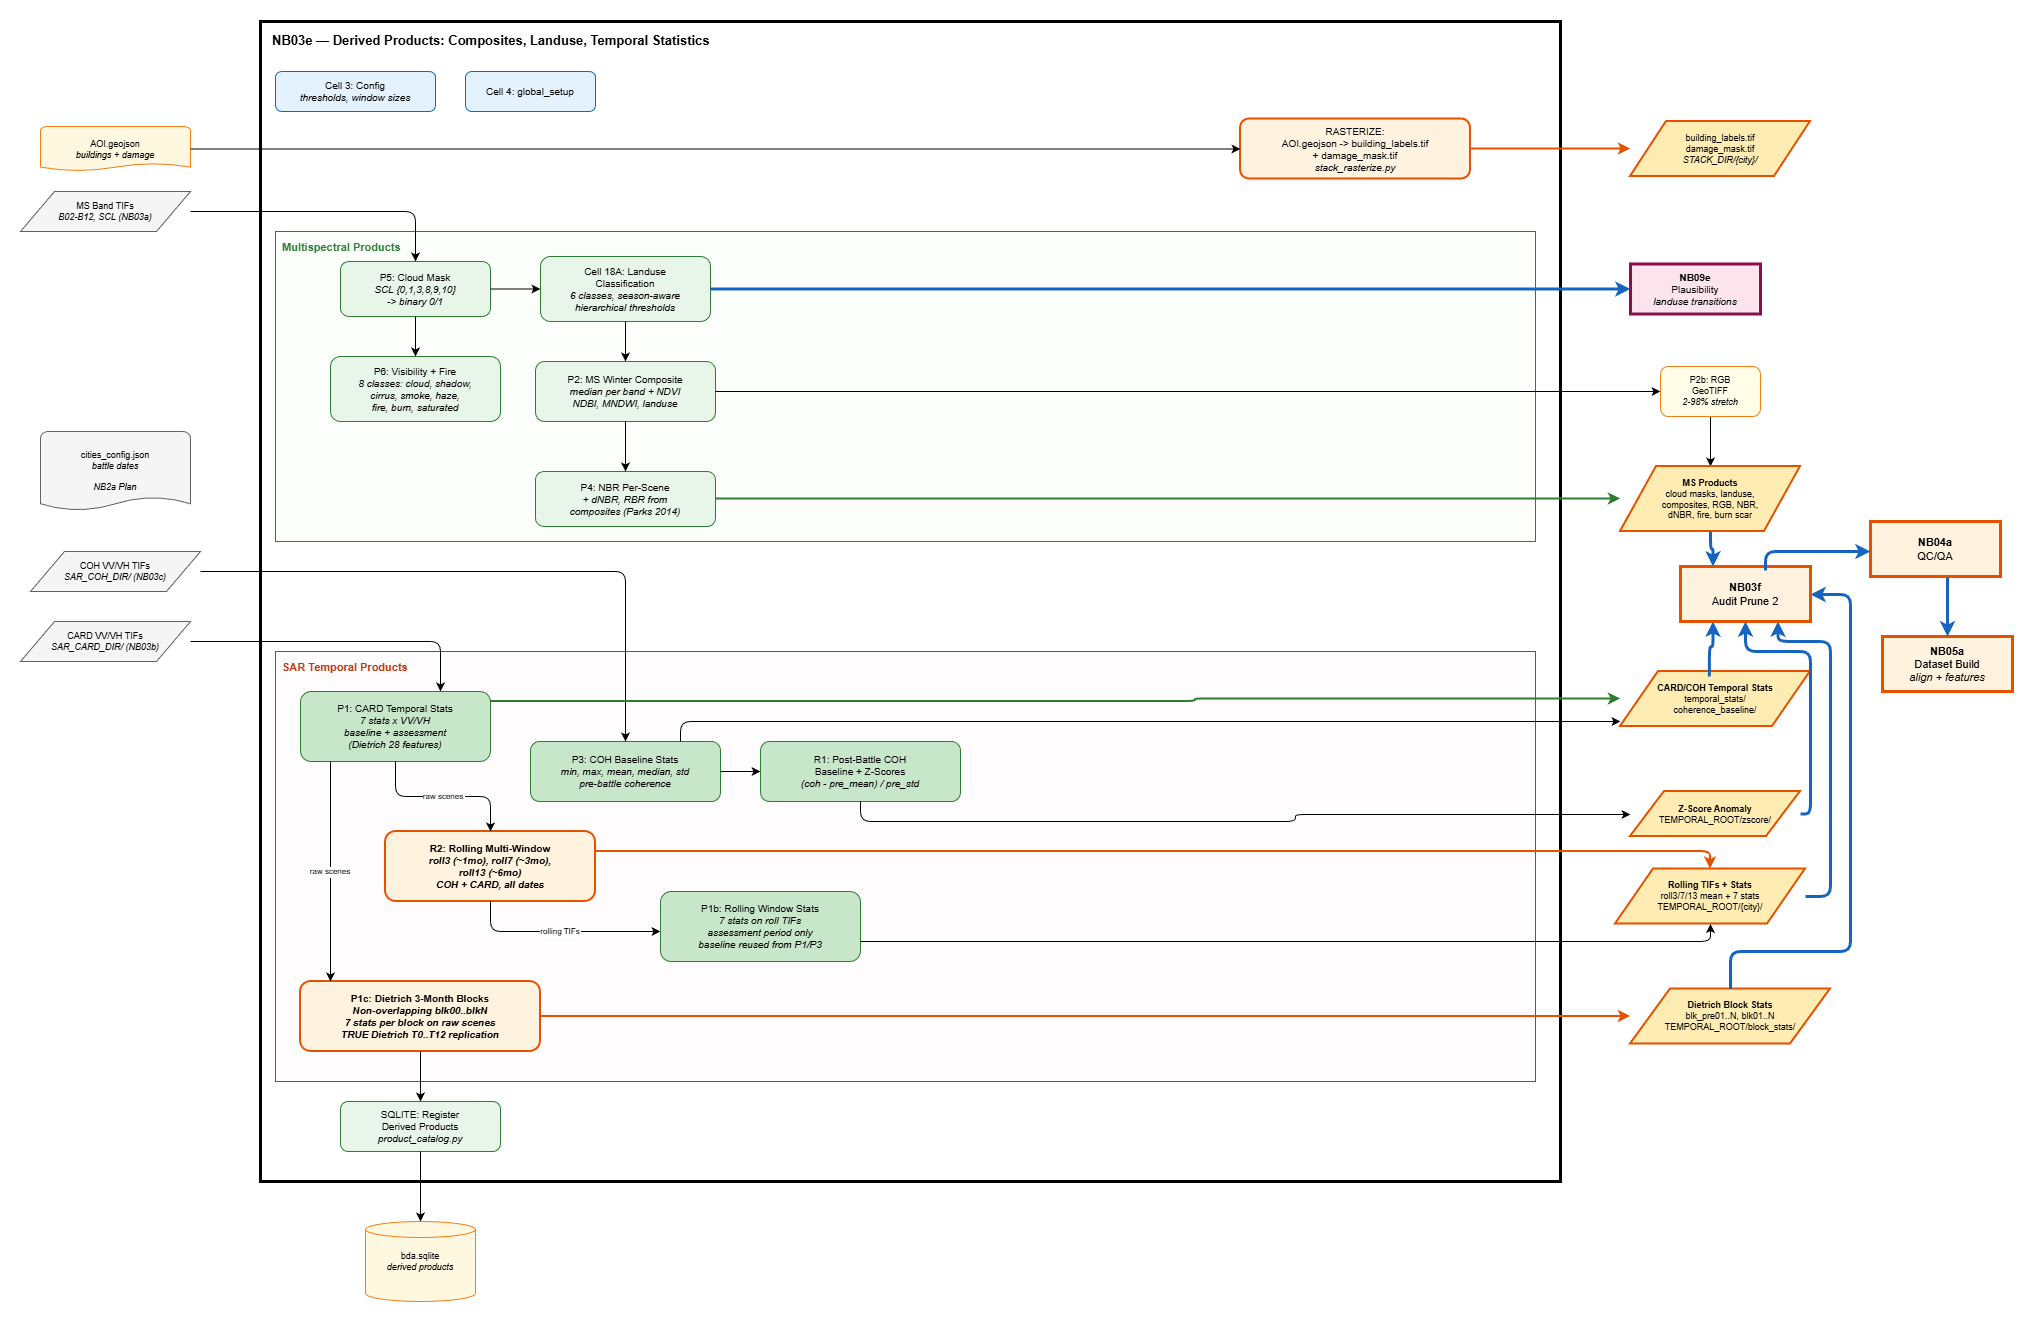

# CELL 4: COMPLETE ENVIRONMENT SETUP (BDA + SNAP12) - LOCAL WSL VERSION


In [1]:
# @title CELL 3: NB03d CONFIG
# ---- shared ----
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None            # or ["Mariupol"]
CLIP_BY_POLYGON = False


# smoke detection thresholds
# B01 (coastal aerosol, 60m) is sensitive to atmospheric scattering
# smoke: B01 elevated relative to B04 (red), SWIR2 normal (unlike clouds)
# WARNING: B01/B04 ratio method is ad-hoc and unpublished. Surface-type
# dependency makes fixed thresholds unreliable. Results are low-confidence.
# SCL gating applied: exclude SCL cloud classes before smoke test to avoid
# double-counting cloud edges as smoke.
SMOKE_B01_B04_RATIO = 1.8      # B01/B04 > threshold = dense smoke
HAZE_B01_B04_RATIO = 1.3       # lighter threshold for haze
SMOKE_SWIR2_MAX = 0.15         # SWIR2 should be low for smoke (not fire)

# fire detection thresholds
# CRITICAL FIX: B12>0.30 flagged ordinary bare soil/urban as fire.
# Dry agricultural soil in eastern Ukraine routinely has B12=0.20-0.40
# and NBR=-0.10 to -0.35. This caused 30-55% false fire in winter scenes.
# New thresholds: B12>1.0 (sensor saturation) + B04<0.15 (fire is dark in visible).
# Burn scar: NBR<-0.25 with land-cover pre-mask (exclude water/snow/urban).
FIRE_SWIR2_MIN = 1.0           # sensor saturation level thermal anomaly
FIRE_B04_MAX = 0.15            # fire emits in SWIR but is dark in visible
FIRE_NBR_MAX = -0.25           # strongly negative NBR = active burn
BURN_NBR_MAX = -0.25           # burn scar threshold (conservative)



# --- NB04c-specific configuration ---
WINDOW_SIZE = 3                 # rolling window size (scenes)
STAT_NAMES = ['min', 'max', 'mean', 'median', 'std']

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\\PROJECTS\\masterthesis\\gdrive\\masterthesis\\notebooks\\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())


BDA GLOBAL SETUP
Started: 2026-04-25 23:30:40
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.2/7452.0 GB (6541.8 GB free)
  GDrive (F:)     1277.8/3726.0 GB (2448.2 GB free)
  Local data      11560.0/14901.9 GB (3341.8 GB free)
  Data stack      1277.8/3726.0 GB (2448.2 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL PLAN-LOAD: READ UNIFIED SCENE PLAN FOR DATE FILTERING

In [3]:
# @title CELL PLAN-LOAD: READ UNIFIED SCENE PLAN (RECONCILED)
# =============================================================================
# Loads nb02a_scene_plan.json via plan_reconcile which:
#   1. Scans disk for actual TIFs, updates status to 'extracted'
#   2. Normalizes all dates to YYYYMMDD (strips hyphens if present)
#   3. Saves updated plan back to disk
#
# After this cell: PLAN_DATES_MS/CARD/SLC contain YYYYMMDD date sets
# matching TIF filenames on disk. Only 'on_disk'/'extracted' scenes included.
# =============================================================================
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import plan_reconcile
importlib.reload(plan_reconcile)

# locate plan
_plan_candidates = [
    STACK_DIR / 'nb02a_scene_plan.json' if 'STACK_DIR' in dir() else None,
    OUTPUTS_DIR / 'nb02a_scene_plan.json' if 'OUTPUTS_DIR' in dir() else None,
    NOTEBOOKS_DIR / 'nb02a_scene_plan.json' if 'NOTEBOOKS_DIR' in dir() else None,
]
PLAN_PATH = None
for _p in _plan_candidates:
    if _p and _p.exists():
        PLAN_PATH = _p
        break
assert PLAN_PATH is not None, f'Plan not found. Tried: {[str(p) for p in _plan_candidates if p]}'

# Reconcile: scan disk, fix statuses, normalize dates to YYYYMMDD, save
PLAN = plan_reconcile.reconcile(
    plan_path=PLAN_PATH,
    ms_dir=MS_DIR if 'MS_DIR' in dir() else None,
    sar_card_dir=SAR_CARD_DIR if 'SAR_CARD_DIR' in dir() else None,
    sar_coh_dir=SAR_COH_DIR if 'SAR_COH_DIR' in dir() else None,
    save=True,
)

# Build per-city date sets for downstream plan filters
# All dates are YYYYMMDD after reconciliation.
# Only include scenes with status in ('on_disk', 'extracted').
_ON_DISK = {'on_disk', 'extracted'}

PLAN_DATES_MS = {}
PLAN_DATES_CARD = {}
PLAN_DATES_SLC = {}
PLAN_COH_PAIRS = {}
PLAN_MS_PERIODS = {}
PLAN_CARD_PERIODS = {}
PLAN_SLC_PERIODS = {}

for city, cdata in PLAN.items():
    # MS
    ms_dates = set()
    ms_periods = {}
    for s in cdata.get('ms', []):
        if s.get('status', '') not in _ON_DISK:
            continue
        d = s.get('date', '')
        if d:
            ms_dates.add(d)
            ms_periods[d] = s.get('period', '')
    PLAN_DATES_MS[city] = ms_dates
    PLAN_MS_PERIODS[city] = ms_periods

    # CARD
    card_dates = set()
    card_periods = {}
    for s in cdata.get('card', []):
        if s.get('status', '') not in _ON_DISK:
            continue
        d = s.get('date', '')
        if d:
            card_dates.add(d)
            card_periods[d] = s.get('period', '')
    PLAN_DATES_CARD[city] = card_dates
    PLAN_CARD_PERIODS[city] = card_periods

    # SLC
    slc_dates = []
    slc_periods = {}
    for s in cdata.get('slc', []):
        if s.get('status', '') not in _ON_DISK:
            continue
        d = s.get('date', '')
        if d:
            slc_dates.append(d)
            slc_periods[d] = s.get('period', '')
    PLAN_DATES_SLC[city] = sorted(slc_dates)
    PLAN_SLC_PERIODS[city] = slc_periods

    # COH pairs from consecutive SLC
    sorted_slc = sorted(slc_dates)
    coh_pairs = set()
    for i in range(len(sorted_slc) - 1):
        coh_pairs.add((sorted_slc[i], sorted_slc[i+1]))
    PLAN_COH_PAIRS[city] = coh_pairs


def date_in_plan_card(date_str, city, tolerance_days=7):
    """Check if YYYYMMDD date is in CARD plan (with tolerance for actual_date drift)."""
    if city not in PLAN_DATES_CARD:
        return False
    if date_str in PLAN_DATES_CARD[city]:
        return True
    if tolerance_days <= 0:
        return False
    from datetime import datetime as _dt
    try:
        dt = _dt.strptime(date_str, '%Y%m%d')
    except ValueError:
        return False
    for vd in PLAN_DATES_CARD[city]:
        try:
            vdt = _dt.strptime(vd, '%Y%m%d')
            if abs((dt - vdt).days) <= tolerance_days:
                return True
        except ValueError:
            continue
    return False


# Summary
n_ms = sum(len(v) for v in PLAN_DATES_MS.values())
n_card = sum(len(v) for v in PLAN_DATES_CARD.values())
n_slc = sum(len(v) for v in PLAN_DATES_SLC.values())
n_coh = sum(len(v) for v in PLAN_COH_PAIRS.values())
print(f'\n  Plan date sets built: {n_ms} MS, {n_card} CARD, {n_slc} SLC, {n_coh} COH pairs')
overlap = len([c for c in CITIES_TO_PROCESS if c in PLAN])
print(f'  CITIES_TO_PROCESS: {overlap}/{len(CITIES_TO_PROCESS)} in plan')
for city in sorted(CITIES_TO_PROCESS):
    if city in PLAN:
        ms_n = len(PLAN_DATES_MS.get(city, set()))
        card_n = len(PLAN_DATES_CARD.get(city, set()))
        slc_n = len(PLAN_DATES_SLC.get(city, []))
        coh_n = len(PLAN_COH_PAIRS.get(city, set()))
        print(f'    {city:<22s}: {ms_n:>3d} MS, {card_n:>3d} CARD, {slc_n:>3d} SLC, {coh_n:>3d} COH')
    else:
        print(f'    {city:<22s}: NOT IN PLAN')


PLAN RECONCILE: DISK REALITY vs PLAN STATUS
  Plan: /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json
  Total changes: 0
  Plan saved: /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json
  MS  : {'extracted': 1630}
  CARD: {'extracted': 1776, 'to_download': 486, 'on_disk': 10}
  SLC : {'extracted': 511, 'to_download': 436, 'on_disk': 1325}

  Plan date sets built: 1392 MS, 1786 CARD, 1836 SLC, 1788 COH pairs
  CITIES_TO_PROCESS: 21/21 in plan
    Avdiivka              :  28 MS,  65 CARD,  65 SLC,  64 COH
    Borodyanka            :   0 MS,  10 CARD,  10 SLC,   9 COH
    Bucha                 :  13 MS,   9 CARD,   9 SLC,   8 COH
    Chernihiv             :  11 MS,  10 CARD,   2 SLC,   1 COH
    Chornobaivka          :  19 MS,  28 CARD,  13 SLC,  12 COH
    Dmytrivka             :  11 MS,   9 CARD,   8 SLC,   7 COH
    Hostomel              :  10 MS,  10 CARD,  10 SLC,   9 COH
    Irpin                 :   9 MS,  10 CARD,  10 SLC,   9 COH
    Kharkiv               :

# OK CELL 14D: CLEANUP secondary Products

# @title CELL CLEANUP: DELETE DERIVED PRODUCTS BEFORE REGENERATION
import shutil

CLEAN_DERIVED = True  # set False to skip cleanup

if CLEAN_DERIVED:
    derived_subdirs = ['composites', 'rgb', 'cloud_masks']
    cleaned = 0
    for city in CITIES_TO_PROCESS:
        # MS derived
        for subdir in derived_subdirs:
            d = MS_DIR / city / subdir
            if d.exists():
                shutil.rmtree(d)
                cleaned += 1
        # landuse
        lu = LANDUSE_DIR / city
        if lu.exists():
            shutil.rmtree(lu)
            cleaned += 1
        # temporal products (NB04c / now 3e)
        for sensor in ['COH', 'CARD']:
            tp = TEMPORAL_ROOT / city / sensor
            if tp.exists():
                shutil.rmtree(tp)
                cleaned += 1
        # COH subdirs (coherence_baseline, temporal_stats)
        for subdir in ['coherence_baseline', 'temporal_stats']:
            d = SAR_COH_DIR / city / subdir
            if d.exists():
                shutil.rmtree(d)
                cleaned += 1
        # CARD subdirs (temporal_stats)
        d = SAR_CARD_DIR / city / 'temporal_stats'
        if d.exists():
            shutil.rmtree(d)
            cleaned += 1
    print(f"Cleaned {cleaned} derived product directories for {len(CITIES_TO_PROCESS)} cities")

# CELL RASTERIZE: VECTOR BUILDINGS -> RASTER MASKS

In [4]:
# @title CELL RASTERIZE: BUILDING FOOTPRINTS + DAMAGE -> RASTER MASKS
# Creates building_labels.tif (int32, 1-based) + damage_mask.tif (int8, -1/0/1) per city.
# Reads AOI.geojson + buildings from CITIES_DIR, writes to STACK_DIR.
# This is a PRODUCT - must exist before NB05 feature extraction.
import importlib
import stack_rasterize
importlib.reload(stack_rasterize)
from stack_rasterize import rasterize_all_cities

FORCE_RERUN = True

RASTER_MASKS = rasterize_all_cities(
    stack_root=STACK_DIR,
    cities=CITIES_TO_PROCESS,
    cities_dir=CITIES_DIR,
    force_rerun=FORCE_RERUN,
)


RASTERIZE BUILDINGS: VECTOR -> RASTER MASKS
  Cities: 21
  Source: /content/drive_f/masterthesis/data/cities
  Output: /mnt/f/PROJECTS/masterthesis/data_stack
  Force rerun: True
  [1/21] Avdiivka: 13360 buildings (12618 rasterized), dmg=89 undam=12434 excl=837
  [2/21] Borodyanka: 49969 buildings (47363 rasterized), dmg=62 undam=5178 excl=44729
  [3/21] Bucha: 17367 buildings (16710 rasterized), dmg=158 undam=17057 excl=152
  [4/21] Chernihiv: 58626 buildings (55975 rasterized), dmg=333 undam=51042 excl=7251
  [5/21] Chornobaivka: 10829 buildings (10750 rasterized), dmg=6 undam=9903 excl=920
  [6/21] Dmytrivka: 13650 buildings (13113 rasterized), dmg=144 undam=13505 excl=1
  [7/21] Hostomel: 19798 buildings (19075 rasterized), dmg=511 undam=18634 excl=653
  [8/21] Irpin: 17686 buildings (16954 rasterized), dmg=249 undam=17116 excl=321
  [9/21] Kharkiv: 213845 buildings (202307 rasterized), dmg=238 undam=169866 excl=43741
  [10/21] Kherson: 10829 buildings (10750 rasterized), dmg=6 und

# CELL P5: CLOUD MASK FROM SCL BAND

In [5]:
# @title CELL P5: CLOUD MASK FROM SCL BAND
# =============================================================================
# Reads clipped SCL (Scene Classification Layer) from Sentinel-2 L2A,
# creates binary cloud mask per scene date.
#
# SCL classes (ESA Sen2Cor):
#   0=no_data, 1=saturated, 2=dark_area, 3=cloud_shadow,
#   4=vegetation, 5=not_vegetated, 6=water, 7=unclassified,
#   8=cloud_medium, 9=cloud_high, 10=thin_cirrus, 11=snow_ice
#
# Cloud mask: 1 = unusable (SCL in {0, 1, 3, 8, 9, 10}), 0 = clear
# Output: {city}_S2_{date}_cloud_mask.tif per date
#         composites/{period}/s2__qa__cloud_freq.tif = fraction of dates flagged cloudy per pixel
#
# Input:  MS_DIR/{city}/s2__scl__{date}.tif  (or legacy {city}_S2_{date}_SCL_20m.tif)
# Output: MS_DIR/{city}/{city}_S2_{date}_cloud_mask.tif  (flat)
#         MS_DIR/{city}/composites/{period}/s2__qa__cloud_freq.tif
#
# Requires: NB03C (clipped SCL band), Cell 4 (paths)
# =============================================================================

CELL_ID = "cell_p5_cloud_mask"
# City filter: uses CITIES_TO_PROCESS from Cell 4 (resolved from CITY_SELECTION + TIER_SELECTION)

# SCL classes to flag as unusable
CLOUD_SCL_CLASSES = {0, 1, 3, 8, 9, 10}
FORCE_RERUN = True

import numpy as np
import rasterio
from pathlib import Path
from datetime import datetime
import re
import time
import warnings
warnings.filterwarnings('ignore')

from aoi_date_extend_loader import load_city_boundary_with_dates

print("=" * 70)
print("CELL P5: CLOUD MASK FROM SCL BAND")
print("=" * 70)
print(f"  MS_DIR: {MS_DIR}")
print(f"  FORCE_RERUN: {FORCE_RERUN}")
print(f"  CITIES_TO_PROCESS: {len(CITIES_TO_PROCESS)} cities")
print(f"  Cloud SCL classes: {sorted(CLOUD_SCL_CLASSES)}")

start_time = time.time()


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(np.dtype(dtype)), 1)


def _get_period(city_name, date_str, cache={}):
    """Determine period from date vs battle dates."""
    if city_name not in cache:
        try:
            _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
            cache[city_name] = (bs, be)
        except Exception:
            cache[city_name] = (None, None)
    bs, be = cache[city_name]
    if bs is None:
        return 'unknown'
    dt = datetime.strptime(date_str, '%Y%m%d')
    if dt < bs:
        return 'prebattle'
    elif be and dt > be:
        return 'postbattle'
    return 'crossbattle'


# =============================================================================
# DISCOVER SCL FILES (FLAT)
# =============================================================================

tasks = []  # (city_name, city_dir, {date_str: scl_path})
missing_scl_cities = set()

if MS_DIR.exists():
    for city_dir in sorted(MS_DIR.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'temp', 'scenes', 'desktop.ini'):
            continue
        if CITIES_TO_PROCESS and city_dir.name not in CITIES_TO_PROCESS:
            continue

        # flat scan: SCL TIFs directly in city dir
        scl_files = {}
        has_any_tif = False
        for f in city_dir.iterdir():
            if not f.is_file() or not f.name.endswith('.tif'):
                continue
            has_any_tif = True
            # old: {city}_S2_{date}_SCL_20m.tif
            m = re.search(r'_(\d{8})_SCL_20m\.tif$', f.name)
            # new: s2__scl__{date}.tif
            if not m:
                m = re.match(r'^s2__scl__(\d{8})\.tif$', f.name)
            if m:
                scl_files[m.group(1)] = f

        # --- PLAN FILTER: only keep MS dates in plan ---
        _plan_ms_city = PLAN_DATES_MS.get(city_dir.name, set())
        if _plan_ms_city:
            before_n = len(scl_files)
            scl_files = {d: f for d, f in scl_files.items() if d in _plan_ms_city}
            if before_n != len(scl_files):
                print(f"    {city_dir.name} plan filter: {before_n} -> {len(scl_files)} SCL dates")

        if scl_files:
            tasks.append((city_dir.name, city_dir, scl_files))
        elif has_any_tif:
            missing_scl_cities.add(city_dir.name)

print(f"\n  Cities with SCL: {len(tasks)}")
for city_name, _, scl_files in tasks:
    print(f"    {city_name}: {len(scl_files)} dates")

if missing_scl_cities:
    print(f"\n  WARNING: {len(missing_scl_cities)} cities have MS data but no SCL band clipped:")
    for c in sorted(missing_scl_cities):
        print(f"    {c}")
    print(f"  -> Add 'SCL' to CLIP_BANDS in NB03C and rerun clipping.")

if not tasks:
    print(f"\n  No SCL data found. Add 'SCL' to NB03C CLIP_BANDS and rerun.")

# =============================================================================
# COMPUTE CLOUD MASKS
# =============================================================================

total_masks = 0
total_frequency = 0

for city_name, city_dir, scl_files in tasks:
    print(f"\n  {city_name}: {len(scl_files)} dates")

    # group dates by period for frequency maps
    period_masks = {}  # period -> [(date_str, cloud_mask_array)]
    ref_meta = None

    for date_str in sorted(scl_files.keys()):
        scl_path = scl_files[date_str]
        out_mask = city_dir / f"s2__cloud_mask__{date_str}.tif"
        period = _get_period(city_name, date_str)

        if out_mask.exists() and not FORCE_RERUN:
            with rasterio.open(out_mask) as src:
                cm = src.read(1).astype(np.float32)
                if ref_meta is None:
                    ref_meta = src.meta.copy()
            period_masks.setdefault(period, []).append(cm)
            continue

        with rasterio.open(scl_path) as src:
            scl = src.read(1)
            if ref_meta is None:
                ref_meta = src.meta.copy()

        # binary cloud mask: 1 = cloudy/unusable, 0 = clear
        cloud = np.isin(scl, list(CLOUD_SCL_CLASSES)).astype(np.uint8)

        save_raster(cloud, out_mask, ref_meta, dtype='uint8', nodata=255)
        period_masks.setdefault(period, []).append(cloud.astype(np.float32))
        total_masks += 1

        cloud_pct = 100.0 * cloud.sum() / cloud.size
        print(f"    {date_str} [{period}]: {cloud_pct:.1f}% cloudy")

    # cloud frequency map per period
    if ref_meta is not None:
        for period, masks in period_masks.items():
            if not masks:
                continue

            comp_dir = MS_DIR / city_name / "composites" / period
            comp_dir.mkdir(parents=True, exist_ok=True)
            freq_path = comp_dir / "s2__qa__cloud_freq.tif"

            ref_shape = masks[0].shape
            aligned = []
            for cm in masks:
                if cm.shape == ref_shape:
                    aligned.append(cm)
                else:
                    out = np.full(ref_shape, np.nan, dtype=np.float32)
                    h = min(cm.shape[0], ref_shape[0])
                    w = min(cm.shape[1], ref_shape[1])
                    out[:h, :w] = cm[:h, :w]
                    aligned.append(out)

            stack = np.stack(aligned)
            frequency = np.nanmean(stack, axis=0).astype(np.float32)
            save_raster(frequency, freq_path, ref_meta)
            total_frequency += 1
            print(f"    -> composites/{period}/s2__qa__cloud_freq.tif ({len(masks)} dates, mean cloud: {100*np.nanmean(frequency):.1f}%)")

# =============================================================================
# SUMMARY
# =============================================================================

duration = time.time() - start_time
print(f"\n{'='*70}")
print(f"CELL P5 COMPLETE ({duration:.0f}s)")
print(f"{'='*70}")
print(f"  Cloud masks created: {total_masks}")
print(f"  Frequency maps:     {total_frequency}")
if missing_scl_cities:
    print(f"  Cities missing SCL:  {len(missing_scl_cities)} (rerun NB03C with SCL in CLIP_BANDS)")
print(f"{'='*70}")


CELL P5: CLOUD MASK FROM SCL BAND
  MS_DIR: /content/drive_f/masterthesis/data/satellite/MS
  FORCE_RERUN: True
  CITIES_TO_PROCESS: 21 cities
  Cloud SCL classes: [0, 1, 3, 8, 9, 10]

  Cities with SCL: 19
    Avdiivka: 28 dates
    Bucha: 13 dates
    Chernihiv: 11 dates
    Chornobaivka: 19 dates
    Dmytrivka: 11 dates
    Hostomel: 10 dates
    Irpin: 9 dates
    Kharkiv: 15 dates
    Kherson: 19 dates
    Kramatorsk: 81 dates
    Lysychansk: 14 dates
    Makariv: 11 dates
    Mariupol: 12 dates
    Moschun: 10 dates
    Okhtyrka: 14 dates
    Rubizhne: 13 dates
    Sievierodonetsk: 15 dates
    Trostianets: 11 dates
    Volnovakha: 12 dates

  Avdiivka: 28 dates
    20201209 [prebattle]: 0.5% cloudy
    20210118 [prebattle]: 0.6% cloudy
    20211020 [prebattle]: 0.4% cloudy
    20211025 [prebattle]: 0.9% cloudy
    20211030 [prebattle]: 22.4% cloudy
    20211124 [prebattle]: 72.3% cloudy
    20220108 [prebattle]: 3.0% cloudy
    20220329 [crossbattle]: 0.4% cloudy
    20220508 [c

# OK LAND USE CLASSIFICATION - PER-DATE, PER-PIXEL (v5)

Fixed: NDBI 0.0 (Zha 2003), removed broken fire class, season-aware veg, shape alignment

In [6]:
# =============================================================================
# CELL 18A: LAND USE CLASSIFICATION - PER-DATE, PER-PIXEL (v3)
# =============================================================================
#
# PURPOSE:
# --------
# This classification is NOT a standalone land use map. It is a PRE-FILTER
# and FEATURE GENERATOR for downstream Building Damage Assessment (BDA).
#
# The goal is to label every pixel as one of a few simple classes so that
# the prebattle-vs-postbattle TRANSITION MATRIX reveals damage signals
# without needing deep learning for the obvious cases.
#
# WHY THIS MATTERS FOR BDA:
# -------------------------
# 1. If we later run ML/DL on full Sentinel swaths or city clips, masking
#    permanent water and permanent forest avoids wasting compute on pixels
#    that can never be damaged buildings.
#
# 2. The transition matrix (prebattle class -> postbattle class) gives
#    strong damage signals for free:
#
#      prebattle  ->  postbattle    interpretation
#      ---------     ----------    ---------------------------------
#      urban     ->  urban         likely intact (or rebuilt)
#      urban     ->  bare_soil     STRONG DAMAGE SIGNAL (demolished)
#      urban     ->  vegetation    DAMAGE + TIME (rubble + regrowth)
#      vegetation->  vegetation    never was a building, skip in ML
#      vegetation->  bare_soil     shelling/clearing, not building dmg
#      bare_soil ->  urban         new construction
#      bare_soil ->  bare_soil     unchanged empty land
#
#    The ML model then only needs to work hard on ambiguous cases like
#    urban->urban where damage is subtle or partial.
#
# 3. CRITICAL EDGE CASE - PIONEER VEGETATION ON RUBBLE:
#    If a building is destroyed and enough time passes (>6 months to >1yr),
#    pioneer plants colonize the rubble. A naive approach would classify
#    this as "vegetation" and discard it, missing the damage entirely.
#    By keeping ALL classes and comparing pre vs post, we catch this:
#    prebattle=urban, postbattle=vegetation => rubble with regrowth => damage.
#    Therefore we NEVER discard any class. All are kept as features.
#
# 4. Snow is flagged but NOT used for transition analysis because snow
#    is seasonal and can cover intact rooftops. A snow pixel tells us
#    nothing about building state, so snow dates should be excluded from
#    pre/post comparison or treated as nodata in the transition matrix.
#
# CLASSIFICATION APPROACH:
# ------------------------
# Simple hierarchical thresholds. Per-pixel, no spatial merging, no
# morphological filtering. Granularity is preserved for the ML pipeline.
#
# Order: Snow -> Water -> Vegetation -> Sparse Veg -> Urban -> Bare Soil
#
# INDICES USED:
# =============
#
# NDVI  = (B8 - B4) / (B8 + B4)
#   Normalized Difference Vegetation Index (Tucker 1979).
#   Chlorophyll absorbs red (B4), reflects NIR (B8).
#   Range: -1 to 1. Dense veg > 0.3, sparse 0.15-0.3, non-veg < 0.15.
#   Used for: vegetation class, urban exclusion gate.
#
# NDBI  = (B11 - B8) / (B11 + B8)
#   Normalized Difference Built-up Index (Zha et al. 2003).
#   Impervious surfaces reflect more SWIR1 (B11) than NIR (B8).
#   Range: -1 to 1. Built-up typically > 0, vegetation < 0.
#   Known issue: bare soil also has positive NDBI. In city-clipped AOIs
#   this is acceptable because most non-vegetated area IS urban.
#   Used for: urban class (primary detector).
#   Ref: Zha et al. 2003; Heinzen 2025 Table 2.2.4
#
# MNDWI = (B3 - B11) / (B3 + B11)
#   Modified Normalized Difference Water Index (Xu 2006).
#   Water reflects green (B3) and absorbs SWIR1 (B11).
#   Better than NDWI in urban areas (less building confusion).
#   Range: -1 to 1. Water > 0.3 (strict), non-water < 0.
#   Used for: water class, urban exclusion gate.
#   Ref: Xu 2006; Heinzen 2025 Table 2.2.4
#
# NDSI  = (B3 - B11) / (B3 + B11)
#   Normalized Difference Snow Index (Dozier 1989).
#   Same formula as MNDWI. Snow has high green and low SWIR reflectance.
#   Distinguished from water by NIR gate: snow has high B8, water has low B8.
#   Used for: snow class (flagging only, not for damage transitions).
#   Ref: Dozier 1989; Hall et al. 2002
#
# DIAGNOSTIC INDICES (computed + saved as TIFs, not used in classification):
#
# BSI   = ((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 + B2))
#   Bare Soil Index (Rikimaru et al. 2002). Diagnostic only.
#
# IBI   = (NDBI - (SAVI + MNDWI)/2) / (NDBI + (SAVI + MNDWI)/2)
#   Index-based Built-up Index (Xu 2008). Diagnostic only.
#   Was too strict as classifier (IBI > 0 missed most urban pixels in
#   city-clipped AOIs), but useful as continuous feature for ML.
#
# SAVI  = ((B8 - B4) / (B8 + B4 + 0.5)) * 1.5
#   Soil Adjusted Vegetation Index (Huete 1988). Component of IBI.
#
# UI    = (B12 - B8) / (B12 + B8)
#   Urban Index using SWIR2. Alternative to NDBI. Diagnostic only.
#
# BAEI  = (B4 + 0.3 - B8 - B2) / (B4 + B11 + B8 + B2)
#   Built-up Area Extraction Index. Diagnostic only.
#
# THRESHOLDS:
# ===========
#
# 1. SNOW: NDSI > 0.4 AND B8 > 0.11 AND B3 > 0.1
#    - NDSI 0.4 is standard (Hall et al. 2002)
#    - B8 > 0.11 separates snow (high NIR) from water (low NIR)
#    - B3 > 0.1 avoids dark shadows being classified as snow
#    - NOTE: snow on rooftops IS snow. For BDA transitions, skip snow dates.
#
# 2. WATER: MNDWI > 0.3 AND NDVI < 0.0 AND B8 < 0.15
#    - MNDWI 0.3 (strict) avoids wet soil, shadows, snow false positives
#    - NDVI < 0 confirms no vegetation (floating/aquatic veg excluded)
#    - B8 < 0.15 confirms water (water absorbs NIR strongly)
#    - Ref: Xu 2006
#
# 3. VEGETATION (dense): NDVI > 0.3
#    - Standard European growing-season threshold (Tucker 1979)
#    - Heinzen Table 2.2.4 recommends 0.2-0.3 range
#
# 4. VEGETATION (sparse): 0.15 < NDVI <= 0.3
#    - Grassland, shrubs, pioneer vegetation on rubble
#    - Kept separate because sparse veg on rubble is ambiguous for BDA
#
# 5. URBAN: NDBI > 0.0 AND NDVI < 0.15 AND MNDWI < 0.0
#    - NDBI > 0.0: original Zha et al. 2003 threshold restored.
#      The prior -0.05 value was too permissive in Ukrainian winter scenes,
#      capturing dry/senescent vegetation, sparse grassland, and bare soil
#      as urban. These surfaces have slightly negative NDBI (-0.05 to 0.0)
#      and were inflating urban class by 5-15%.
#    - NDVI < 0.15 confirms non-vegetated
#    - MNDWI < 0.0 confirms non-water
#    - Ref: Zha et al. 2003; Heinzen 2025 Table 2.2.4
#
# 6. BARE SOIL: everything valid remaining
#    - Residual class: fallow land, rubble, exposed earth, roads
#    - In BDA context: bare soil postbattle where urban was prebattle
#      is a strong damage indicator
#
# CLASS ENCODING:
# ===============
# 0 = NoData (invalid/masked pixels)
# 1 = Snow
# 2 = Water
# 3 = Vegetation (dense, NDVI > 0.3)
# 4 = Sparse Vegetation (0.15 < NDVI <= 0.3)
# 5 = Urban / Built-up
# 6 = Bare Soil
#
# DOWNSTREAM USAGE (transition matrix):
# ======================================
# After running this cell for all cities/periods/dates, the next cell
# should compute per-pixel transitions:
#
#   transition[y,x] = prebattle_class[y,x] * 10 + postbattle_class[y,x]
#
# Encoding: 53 = prebattle urban (5), postbattle vegetation (3) = DAMAGE
#           56 = prebattle urban (5), postbattle bare soil (6) = DAMAGE
#           55 = prebattle urban (5), postbattle urban (5) = likely intact
#           33 = prebattle veg (3), postbattle veg (3) = permanent veg, skip
#           65 = prebattle bare (6), postbattle urban (5) = new construction
#
# Transition codes 53, 54, 56 are the primary damage indicators.
# Code 55 needs ML to determine if subtle damage exists.
# Codes 33, 34, 44 are permanent non-building, safe to exclude from ML.
# Snow (1x, x1) should be treated as nodata in transitions.
#
# REFLECTANCE SCALING:
# ====================
# Sentinel-2 L2A BOA reflectance is stored as DN * 10000.
# We auto-detect: if max value > 100, divide by 10000 to get 0-1 range.
# Normalized difference indices are scale-invariant (factor cancels),
# but absolute thresholds on bands (B8 > 0.11) require correct scaling.
#
# REFERENCES:
# ===========
# Tucker 1979 - NDVI
# Zha et al. 2003 - NDBI
# Xu 2006 - MNDWI
# Xu 2008 - IBI
# Huete 1988 - SAVI
# Dozier 1989 - NDSI
# Hall et al. 2002 - NDSI snow mapping
# Rikimaru et al. 2002 - BSI
# Li & Chen 2014 - BSI variant
# El Mendili et al. 2020 - urban classification workflow
# Richards 2022 - remote sensing textbook
# Heinzen 2025 Table 2.2.4, Appendix B/C - index recommendations
#
# CRS NORMALIZATION:
# ==================
# All outputs are reprojected to EPSG:32636 (UTM zone 36N) regardless of
# source tile CRS. Sentinel-2 tiles over Ukraine come in different CRS
# (EPSG:4326, EPSG:32636, EPSG:32637) depending on orbit and tile.
# Without normalization, cell 18B transition matrix cannot align rasters
# from different dates because bounds in degrees vs meters are incomparable.
# UTM 36N covers most of Ukraine; eastern cities in UTM 37 get minor
# distortion acceptable at 10m resolution.
#
# =============================================================================

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import pandas as pd
import json
import sys
import re
import warnings
from datetime import datetime
from IPython.display import display
warnings.filterwarnings('ignore')

### ==================== CELL EXECUTION CONTROL ====================
CELL_ID = "cell_18a_landuse_classification"
FORCE_RERUN = True
# City filtering handled by CITIES_TO_PROCESS from Cell 4
SKIP_EXISTING = True
### ================================================================
CELL_LOG_FILE = LOGS_DIR / f"{CELL_ID}.json"
CELL_OUTPUT_LOG = LOGS_DIR / f"{CELL_ID}_output.log"
LANDUSE_OUTPUT_ROOT = LANDUSE_DIR

# Folders to exclude
EXCLUDED_FOLDERS = ['temp', 'tmp', 'cache', '.temp', '_temp']

S2_BAND_RESOLUTIONS = {
    'B02': 10, 'B03': 10, 'B04': 10, 'B08': 10,  # 10m
    'B05': 20, 'B06': 20, 'B07': 20, 'B8A': 20,  # 20m
    'B11': 20, 'B12': 20,                         # 20m SWIR
}

REQUIRED_BANDS = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']
TARGET_RESOLUTION = 10
RESAMPLING_METHOD = Resampling.bilinear

# =============================================================================
# THRESHOLDS
# =============================================================================

THRESHOLDS = {
    # Snow (Dozier 1989; Hall et al. 2002)
    # NDSI 0.4 + high NIR separates snow from water
    # Snow dates should be excluded from BDA transition analysis
    'snow': {
        'ndsi_min': 0.4,
        'nir_min': 0.11,
        'green_min': 0.1,
    },

    # Water (Xu 2006 MNDWI, strict)
    # Permanent water bodies - safe to mask in BDA
    'water': {
        'mndwi_min': 0.3,
        'ndvi_max': 0.0,
        'nir_max': 0.15,
    },

    # Vegetation (Tucker 1979; Heinzen Table 2.2.4)
    # Dense and sparse kept separate for BDA transition granularity
    # sparse veg on former urban = likely rubble with regrowth = damage
    # Season-aware: summer (Apr-Sep) Ukraine is very green/lush,
    # winter (Oct-Mar) thresholds must be lower to catch conifers + winter wheat
    'vegetation_winter': {
        'ndvi_dense': 0.3,
        'ndvi_sparse': 0.15,
    },
    'vegetation_summer': {
        'ndvi_dense': 0.5,
        'ndvi_sparse': 0.2,
    },

    # Urban (Zha et al. 2003 NDBI, original threshold restored)
    # NDBI > 0.0: original Zha 2003 threshold. The prior -0.05 inflated
    # urban by capturing dry grassland and bare soil in winter scenes.
    # NDVI < 0.15: non-vegetated gate
    # MNDWI < 0.0: non-water gate
    'urban': {
        'ndbi_min': 0.0,  # Zha et al. 2003 original; -0.05 captured bare soil + dry grassland
        'ndvi_max': 0.15,
        'mndwi_max': 0.0,
    },

    # Bare soil: residual class, no threshold needed
    # In BDA: prebattle urban -> postbattle bare soil = strong damage signal
}

# Reflectance scale factor
REFLECTANCE_SCALE = 10000.0

# All outputs normalized to this CRS for consistent pixel grids across dates
# UTM zone 36N covers most of Ukraine (30-36E). Cities in zone 37 (east of 36E)
# will be reprojected, introducing minor distortion acceptable at 10m.
from rasterio.crs import CRS
TARGET_CRS = CRS.from_epsg(32636)

def check_cell_status():
    if CELL_LOG_FILE.exists() and not FORCE_RERUN:
        with open(CELL_LOG_FILE, 'r') as f:
            log = json.load(f)
        if log.get('status') == 'SUCCESS':
            return True, log
    return False, None

already_run, previous_log = check_cell_status()

if already_run:
    print(f"CELL ALREADY RUN: {CELL_ID}")
    print(f"Set FORCE_RERUN = True to re-execute")
else:
    start_time = datetime.now()

    class Logger:
        def __init__(self, filepath):
            self.terminal = sys.stdout
            self.log = open(filepath, 'w', encoding='utf-8')
        def write(self, message):
            self.terminal.write(message)
            self.log.write(message)
        def flush(self):
            self.terminal.flush()
            self.log.flush()
        def close(self):
            self.log.close()

    logger = Logger(CELL_OUTPUT_LOG)
    sys.stdout = logger

    try:
        print("=" * 80)
        print("LAND USE CLASSIFICATION v5 - SEASON-AWARE, FIRE-FIXED (BDA PRE-FILTER)")
        print("=" * 80)
        print(f"Start: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"Reflectance scale factor: {REFLECTANCE_SCALE}")
        print(f"Excluded folders: {', '.join(EXCLUDED_FOLDERS)}\n")

        # =============================================================================
        # FOLDER & FILE DISCOVERY
        # =============================================================================

        def normalize_name(name: str) -> str:
            return name.lower().replace('-', '_').replace(' ', '_')

        def is_excluded_folder(folder_name: str) -> bool:
            normalized = normalize_name(folder_name)
            for excluded in EXCLUDED_FOLDERS:
                if normalize_name(excluded) in normalized:
                    return True
            return False

        # period label from date vs battle dates (flat structure has no period folders)
        _battle_dates_cache = {}
        def _get_battle_dates(city_name):
            if city_name not in _battle_dates_cache:
                try:
                    from aoi_date_extend_loader import load_city_boundary_with_dates
                    _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
                    _battle_dates_cache[city_name] = (bs, be, ongoing)
                except Exception:
                    _battle_dates_cache[city_name] = (None, None, False)
            return _battle_dates_cache[city_name]

        def _period_from_date(city_name, date_str):
            """Determine period label from date vs battle dates."""
            bs, be, ongoing = _get_battle_dates(city_name)
            if bs is None:
                return 'unknown'
            dt = datetime.strptime(date_str, '%Y%m%d')
            if dt < bs:
                return 'prebattle'
            elif be and dt > be:
                return 'postbattle'
            else:
                return 'crossbattle'

        def extract_date_from_filename(filename: str) -> str:
            # old: {city}_S2_YYYYMMDD_B02_10m.tif
            match = re.search(r'_(\d{8})_', filename)
            if match:
                return match.group(1)
            # new: s2__b02__YYYYMMDD.tif
            match = re.search(r'__(\d{8})\.tif$', filename)
            if match:
                return match.group(1)
            return None

        def group_band_files_by_date(period_dir: Path) -> dict:
            date_bands = {}
            for f in period_dir.iterdir():
                if not f.is_file() or not f.name.lower().endswith('.tif'):
                    continue
                date_str = extract_date_from_filename(f.name)
                if date_str is None:
                    continue
                # old: _B02_10m.tif
                band_match = re.search(r'_(B\d{2}|B8A)_', f.name)
                if band_match:
                    band_name = band_match.group(1)
                else:
                    # new: s2__b02__YYYYMMDD.tif
                    band_match = re.match(r's2__(b\d{2}|b8a)__\d{8}\.tif$', f.name)
                    if band_match:
                        band_name = band_match.group(1).upper()
                    else:
                        continue
                if date_str not in date_bands:
                    date_bands[date_str] = {}
                date_bands[date_str][band_name] = f
            return date_bands

        def validate_raster_file(filepath: Path) -> bool:
            try:
                with rasterio.open(filepath) as src:
                    _ = src.meta
                    _ = src.read(1, window=((0, 1), (0, 1)))
                return True
            except Exception:
                return False

        # =============================================================================
        # RESAMPLING
        # =============================================================================

        def resample_to_target(src_path: Path, target_shape: tuple,
                              target_transform, target_crs) -> np.ndarray:
            with rasterio.open(src_path) as src:
                dst_array = np.zeros(target_shape, dtype=np.float32)
                reproject(
                    source=rasterio.band(src, 1),
                    destination=dst_array,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=target_transform,
                    dst_crs=target_crs,
                    resampling=RESAMPLING_METHOD
                )
                return dst_array

        # =============================================================================
        # INDEX CALCULATIONS
        # =============================================================================

        def safe_divide(a, b):
            with np.errstate(divide='ignore', invalid='ignore'):
                result = a / b
                return np.where(np.isfinite(result), result, 0)

        def align_to_ref(arr, ref_shape):
            """Crop or pad array to match ref_shape (handles 1-2px mismatches from resampling)."""
            if arr.shape == ref_shape:
                return arr
            out = np.full(ref_shape, np.nan, dtype=arr.dtype)
            h = min(arr.shape[0], ref_shape[0])
            w = min(arr.shape[1], ref_shape[1])
            out[:h, :w] = arr[:h, :w]
            return out

        def get_season(date_str):
            """Return 'summer' (Apr-Sep) or 'winter' (Oct-Mar) from YYYYMMDD."""
            month = int(date_str[4:6])
            return 'summer' if 4 <= month <= 9 else 'winter'

        def calculate_ndvi(nir, red):
            return safe_divide(nir - red, nir + red)

        def calculate_ndbi(swir1, nir):
            return safe_divide(swir1 - nir, swir1 + nir)

        def calculate_ui(swir2, nir):
            return safe_divide(swir2 - nir, swir2 + nir)

        def calculate_mndwi(green, swir1):
            return safe_divide(green - swir1, green + swir1)

        def calculate_savi(nir, red, L=0.5):
            return safe_divide((nir - red) * (1 + L), nir + red + L)

        def calculate_bsi(swir1, red, nir, blue):
            num = (swir1 + red) - (nir + blue)
            den = (swir1 + red) + (nir + blue)
            return safe_divide(num, den)

        def calculate_ibi(ndbi, savi, mndwi):
            veg_water = (savi + mndwi) / 2.0
            return safe_divide(ndbi - veg_water, ndbi + veg_water)

        def calculate_ndsi(green, swir1):
            return safe_divide(green - swir1, green + swir1)

        def calculate_baei(red, swir1, nir, blue):
            return safe_divide(red + 0.3 - nir - blue, red + swir1 + nir + blue)

        # =============================================================================
        # BAND LOADING (PER DATE)
        # =============================================================================

        def load_bands_for_date(band_files: dict, date_str: str,
                                required_bands=REQUIRED_BANDS):
            missing_bands = []
            valid_files = {}

            for band in required_bands:
                if band not in band_files:
                    missing_bands.append(band)
                    continue
                if not validate_raster_file(band_files[band]):
                    print(f"      x {band}: Invalid file {band_files[band].name}")
                    missing_bands.append(band)
                    continue
                valid_files[band] = band_files[band]

            if missing_bands:
                raise FileNotFoundError(
                    f"Missing or invalid bands for {date_str}: {', '.join(missing_bands)}"
                )

            reference_band = None
            for band in ['B02', 'B03', 'B04', 'B08']:
                if band in valid_files:
                    reference_band = band
                    break
            if not reference_band:
                raise ValueError("No 10m reference band found")

            with rasterio.open(valid_files[reference_band]) as src:
                target_shape = (src.height, src.width)
                target_transform = src.transform
                target_crs = src.crs
                target_meta = src.meta.copy()

            bands = {}
            resampled = []
            direct = []

            for band in required_bands:
                band_path = valid_files[band]
                band_res = S2_BAND_RESOLUTIONS.get(band, 10)

                with rasterio.open(band_path) as src:
                    src_shape = (src.height, src.width)

                if src_shape == target_shape:
                    with rasterio.open(band_path) as src:
                        _arr = src.read(1).astype(np.float32)
                        # SANITIZE MS reflectance raw: nodata + 0 (scene footprint) -> NaN
                        _nd = src.nodata
                        if _nd is not None:
                            _arr[_arr == _nd] = np.nan
                        _arr[_arr == 0] = np.nan
                        bands[band] = _arr
                    direct.append(f"{band}({band_res}m)")
                else:
                    bands[band] = resample_to_target(
                        band_path, target_shape, target_transform, target_crs
                    )
                    resampled.append(f"{band}({band_res}m->10m)")

                if bands[band].shape != target_shape:
                    bands[band] = align_to_ref(bands[band], target_shape)

            if direct:
                print(f"        Direct: {', '.join(direct)}")
            if resampled:
                print(f"        Resampled: {', '.join(resampled)}")

            # Auto-detect reflectance scale
            sample_max = max(bands[b].max() for b in required_bands)
            if sample_max > 100:
                scale = REFLECTANCE_SCALE
                print(f"        Scaling DN -> reflectance (max DN={sample_max:.0f}, dividing by {scale:.0f})")
                for band in required_bands:
                    bands[band] = bands[band] / scale
            else:
                print(f"        Data already in reflectance range (max={sample_max:.4f})")

            # Normalize CRS to TARGET_CRS (EPSG:32636) for consistent pixel grids
            # across all dates. Without this, different S2 tiles produce different
            # CRS (4326 vs 32636 vs 32637) causing shape mismatches in cell 18B.
            from rasterio.warp import calculate_default_transform
            if str(target_crs) != str(TARGET_CRS):
                print(f"        Reprojecting {target_crs} -> {TARGET_CRS}")
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    target_crs, TARGET_CRS,
                    target_shape[1], target_shape[0],
                    left=target_meta['transform'].c,
                    bottom=target_meta['transform'].f + target_meta['transform'].e * target_shape[0],
                    right=target_meta['transform'].c + target_meta['transform'].a * target_shape[1],
                    top=target_meta['transform'].f,
                    resolution=TARGET_RESOLUTION,
                )
                new_shape = (dst_height, dst_width)
                reprojected_bands = {}
                for band in required_bands:
                    dst_array = np.zeros(new_shape, dtype=np.float32)
                    reproject(
                        source=bands[band],
                        destination=dst_array,
                        src_transform=target_transform,
                        src_crs=target_crs,
                        dst_transform=dst_transform,
                        dst_crs=TARGET_CRS,
                        resampling=Resampling.bilinear,
                    )
                    reprojected_bands[band] = dst_array
                bands = reprojected_bands
                target_transform = dst_transform
                target_meta.update({
                    'crs': TARGET_CRS,
                    'transform': dst_transform,
                    'width': dst_width,
                    'height': dst_height,
                })
                print(f"        Reprojected shape: {new_shape}")

            return bands, target_meta, target_transform

        # =============================================================================
        # CLASSIFICATION (simple NDBI-based, optimized for BDA pre-filtering)
        # =============================================================================

        def classify_landuse(bands, thresholds=THRESHOLDS, date_str=None):
            blue  = bands['B02']
            green = bands['B03']
            red   = bands['B04']
            nir   = bands['B08']
            swir1 = bands['B11']
            swir2 = bands['B12']

            # Calculate all indices
            ndvi  = calculate_ndvi(nir, red)
            ndbi  = calculate_ndbi(swir1, nir)
            ui    = calculate_ui(swir2, nir)
            mndwi = calculate_mndwi(green, swir1)
            savi  = calculate_savi(nir, red)
            bsi   = calculate_bsi(swir1, red, nir, blue)
            ibi   = calculate_ibi(ndbi, savi, mndwi)
            ndsi  = calculate_ndsi(green, swir1)
            baei  = calculate_baei(red, swir1, nir, blue)

            nbr = safe_divide(nir - swir2, nir + swir2)

            indices = {
                'ndvi': ndvi, 'ndbi': ndbi, 'ui': ui,
                'mndwi': mndwi, 'savi': savi, 'bsi': bsi,
                'ibi': ibi, 'ndsi': ndsi, 'baei': baei, 'nbr': nbr,
            }

            # Season-aware vegetation thresholds
            season = get_season(date_str) if date_str else 'winter'
            veg_key = f'vegetation_{season}'
            if veg_key not in thresholds:
                veg_key = 'vegetation_winter'  # fallback

            # Classes: 0=NoData, 1=Snow, 2=Water, 3=Vegetation, 4=Sparse Veg,
            #          5=Urban, 6=Bare Soil, 7=Shadow/Dark
            classification = np.zeros_like(ndvi, dtype=np.uint8)
            valid_mask = (nir > 0) & (red > 0) & (swir1 > 0)

            # 1. Snow (Dozier 1989; Hall et al. 2002)
            # Flag only - exclude snow dates from BDA transitions
            snow_t = thresholds['snow']
            snow_mask = (
                (ndsi > snow_t['ndsi_min']) &
                (nir > snow_t['nir_min']) &
                (green > snow_t['green_min']) &
                valid_mask
            )
            classification[snow_mask] = 1

            # 2. Water (Xu 2006 MNDWI, strict)
            water_t = thresholds['water']
            water_mask = (
                (mndwi > water_t['mndwi_min']) &
                (ndvi < water_t['ndvi_max']) &
                (nir < water_t['nir_max']) &
                valid_mask & ~snow_mask
            )
            classification[water_mask] = 2

            # 3. Dense vegetation (Tucker 1979, season-aware)
            veg_t = thresholds[veg_key]
            veg_mask = (
                (ndvi > veg_t['ndvi_dense']) &
                valid_mask & ~snow_mask & ~water_mask
            )
            classification[veg_mask] = 3

            # 4. Sparse vegetation
            sparse_veg_mask = (
                (ndvi > veg_t['ndvi_sparse']) &
                (ndvi <= veg_t['ndvi_dense']) &
                valid_mask & ~snow_mask & ~water_mask
            )
            classification[sparse_veg_mask] = 4

            # 5. Urban / built-up (Zha et al. 2003, NDBI with relaxed threshold)
            urban_t = thresholds['urban']
            already_classified = snow_mask | water_mask | veg_mask | sparse_veg_mask
            urban_mask = (
                (ndbi > urban_t['ndbi_min']) &
                (ndvi < urban_t['ndvi_max']) &
                (mndwi < urban_t['mndwi_max']) &
                valid_mask & ~already_classified
            )
            classification[urban_mask] = 5

            # 6. Bare soil = everything valid remaining (before shadow check)
            already_classified_2 = snow_mask | water_mask | veg_mask | sparse_veg_mask | urban_mask
            bare_soil_mask = valid_mask & ~already_classified_2
            classification[bare_soil_mask] = 6

            # 7. Shadow / dark pixels
            # Very low reflectance across all bands suggests deep shadow or
            # destroyed structures. Useful as BDA feature - intact rooftops reflect
            # more than rubble in shadow. Threshold: all VIS+NIR < 0.05.
            # NOTE: fire detection moved to P6 (visibility product) where
            # proper SWIR2 thresholds + land-cover pre-masking are applied.
            # The previous NBR<-0.15 & SWIR2>0.05 fire class was removed because
            # dry agricultural soil in Ukraine routinely has B12=0.20-0.40 and
            # NBR=-0.10 to -0.35, causing 30-55% false fire detections in winter.
            shadow_mask = (
                (blue < 0.05) & (green < 0.05) & (red < 0.05) & (nir < 0.05) &
                valid_mask & (classification == 6)  # only reclassify bare_soil
            )
            classification[shadow_mask] = 7

            return classification, indices

        # =============================================================================
        # VISUALIZATION & EXPORT
        # =============================================================================

        CLASS_NAMES = ['No Data', 'Snow', 'Water', 'Vegetation', 'Sparse Veg', 'Urban', 'Bare Soil', 'Shadow/Dark']
        CLASS_COLORS = ['#000000', '#FFFFFF', '#0000FF', '#00AA00', '#90EE90', '#FF0000', '#D2B48C', '#404040']

        def visualize_classification(classification, indices, city_name, period,
                                    date_str, save_dir=None, show_plot=False):
            cmap = ListedColormap(CLASS_COLORS)

            fig = plt.figure(figsize=(20, 12))

            ax1 = plt.subplot(2, 3, 1)
            ax1.imshow(classification, cmap=cmap, vmin=0, vmax=6)
            ax1.set_title(f'{city_name} - {period} - {date_str}\nLand Use (10m)', fontweight='bold')
            ax1.axis('off')

            from matplotlib.patches import Patch
            legend = [Patch(facecolor=CLASS_COLORS[i], edgecolor='black', label=CLASS_NAMES[i])
                      for i in range(len(CLASS_NAMES))]
            ax1.legend(handles=legend, loc='upper right', fontsize=8)

            index_plots = [
                ('ndvi', 'NDVI', 'RdYlGn', -1, 1),
                ('ndbi', 'NDBI (urban detector)', 'RdYlBu_r', -1, 1),
                ('bsi', 'BSI (diagnostic)', 'YlOrBr', -1, 1),
                ('mndwi', 'MNDWI', 'Blues', -1, 1),
                ('ibi', 'IBI (diagnostic)', 'RdYlBu_r', -1, 1),
            ]

            for idx, (key, title, cmap_name, vmin, vmax) in enumerate(index_plots, 2):
                ax = plt.subplot(2, 3, idx)
                im = ax.imshow(indices[key], cmap=cmap_name, vmin=vmin, vmax=vmax)
                ax.set_title(title, fontsize=10)
                ax.axis('off')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            plt.tight_layout()

            if save_dir:
                save_path = Path(save_dir) / f"{city_name}_{period}_{date_str}_landuse.png"
                save_path.parent.mkdir(parents=True, exist_ok=True)
                plt.savefig(save_path, dpi=300, bbox_inches='tight')

            if show_plot:
                plt.show()
            else:
                plt.close()

            return fig

        def calculate_class_statistics(classification):
            stats = []
            total_valid = np.sum(classification > 0)

            for class_id in range(len(CLASS_NAMES)):
                count = np.sum(classification == class_id)
                pct = (count / total_valid * 100) if total_valid > 0 else 0
                stats.append({
                    'class': CLASS_NAMES[class_id],
                    'class_id': class_id,
                    'pixel_count': int(count),
                    'percentage': pct
                })

            return stats

        def save_outputs(classification, indices, stats, meta, transform,
                        output_dir, city_name, period, date_str):
            output_dir = Path(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)

            meta_out = meta.copy()
            meta_out.update({'dtype': 'uint8', 'count': 1, 'compress': 'lzw'})
            with rasterio.open(output_dir / "s2__landuse.tif", 'w', **meta_out) as dst:
                dst.write(classification.astype(np.uint8), 1)

            indices_dir = output_dir / "indices"
            indices_dir.mkdir(exist_ok=True)
            meta_out.update({'dtype': 'float32'})
            for name, array in indices.items():
                with rasterio.open(indices_dir / f"s2__{name.lower()}.tif", 'w', **meta_out) as dst:
                    dst.write(array.astype(np.float32), 1)

            stats_with_context = []
            for s in stats:
                s_copy = s.copy()
                s_copy.update({'city': city_name, 'period': period, 'date': date_str})
                stats_with_context.append(s_copy)
            pd.DataFrame(stats_with_context).to_csv(output_dir / "landuse_statistics.csv", index=False)

        # =============================================================================
        # MAIN PROCESSING - PER DATE
        # =============================================================================

        def process_city_period_date(city_name, period_name, date_str, band_files,
                                    output_root):
            print(f"      Date: {date_str} ({len(band_files)} bands found)")

            # skip if output already exists
            if SKIP_EXISTING and not FORCE_RERUN:
                check_dir = Path(output_root) / city_name / period_name / date_str
                check_file = check_dir / "s2__landuse.tif"
                if check_file.exists():
                    print(f"        -> skipped (exists)")
                    return True, None

            try:
                bands, meta, transform = load_bands_for_date(band_files, date_str)
                classification, indices = classify_landuse(bands, date_str=date_str)
                stats = calculate_class_statistics(classification)

                # Print key stats
                snow_pct   = next((s['percentage'] for s in stats if s['class_id'] == 1), 0)
                water_pct  = next((s['percentage'] for s in stats if s['class_id'] == 2), 0)
                veg_pct    = next((s['percentage'] for s in stats if s['class_id'] == 3), 0)
                sparse_pct = next((s['percentage'] for s in stats if s['class_id'] == 4), 0)
                urban_pct  = next((s['percentage'] for s in stats if s['class_id'] == 5), 0)
                bare_pct   = next((s['percentage'] for s in stats if s['class_id'] == 6), 0)
                shadow_pct = next((s['percentage'] for s in stats if s['class_id'] == 7), 0)
                season = get_season(date_str)
                print(f"        -> [{season}] Urban: {urban_pct:.1f}%  Veg: {veg_pct:.1f}%  SparseV: {sparse_pct:.1f}%  Bare: {bare_pct:.1f}%  Water: {water_pct:.1f}%  Snow: {snow_pct:.1f}%  Shadow: {shadow_pct:.1f}%")

                output_dir = Path(output_root) / city_name / period_name / date_str
                save_outputs(classification, indices, stats, meta, transform,
                            output_dir, city_name, period_name, date_str)

                vis_dir = output_dir / "visualization"
                visualize_classification(classification, indices, city_name,
                                        period_name, date_str,
                                        save_dir=vis_dir, show_plot=False)

                return True, stats

            except Exception as e:
                print(f"        x {str(e)[:120]}")
                return False, None

        # =============================================================================
        # DISCOVER & PROCESS CITIES
        # =============================================================================

        print("Discovering cities (flat MS structure)...")
        cities_with_data = []

        if MS_DIR.exists():
            for city_dir in sorted(MS_DIR.iterdir()):
                if not city_dir.is_dir():
                    continue
                if is_excluded_folder(city_dir.name):
                    continue
                if city_dir.name in ('metadata', 'scenes', 'temp', 'desktop.ini'):
                    continue
                if CITIES_TO_PROCESS and city_dir.name not in CITIES_TO_PROCESS:
                    continue
                # flat: scan city_dir directly for band TIFs
                date_bands = group_band_files_by_date(city_dir)

                # --- PLAN FILTER: only keep MS dates in plan ---
                _plan_ms_city = PLAN_DATES_MS.get(city_dir.name, set())
                if _plan_ms_city and date_bands:
                    before_n = len(date_bands)
                    date_bands = {d: v for d, v in date_bands.items() if d in _plan_ms_city}
                    if before_n != len(date_bands):
                        print(f"    {city_dir.name} plan filter: {before_n} -> {len(date_bands)} dates")

                if date_bands:
                    cities_with_data.append({
                        'name': city_dir.name,
                        'date_bands': date_bands,
                        'city_dir': city_dir,
                    })

        print(f"Found {len(cities_with_data)} cities\n")

        if not cities_with_data:
            raise ValueError("No cities with multispectral data found")

        # Preview
        total_dates = 0
        print("City overview:")
        for city in cities_with_data:
            n_dates = len(city['date_bands'])
            total_dates += n_dates
            print(f"  {city['name']:25s}: {n_dates} dates")
        print(f"\nTotal observation dates to classify: {total_dates}\n")

        # Process
        print("=" * 80)
        print("PROCESSING")
        print("=" * 80 + "\n")

        processed_cities = 0
        processed_dates = 0
        failed_dates = 0
        all_stats = []

        cities_to_process = cities_with_data

        for idx, city_info in enumerate(cities_to_process, 1):
            city_name = city_info['name']
            date_bands = city_info['date_bands']

            print(f"[{idx}/{len(cities_to_process)}] {city_name} ({len(date_bands)} dates)")

            city_ok = True
            for date_str in sorted(date_bands.keys()):
                band_files = date_bands[date_str]
                period_label = _period_from_date(city_name, date_str)

                success, stats = process_city_period_date(
                    city_name, period_label, date_str,
                    band_files, LANDUSE_OUTPUT_ROOT
                )

                if success:
                    processed_dates += 1
                    if stats:
                        for s in stats:
                            s.update({
                                'city': city_name,
                                'period': period_label,
                                'date': date_str,
                            })
                            all_stats.append(s)
                else:
                    failed_dates += 1
                    city_ok = False

            if city_ok:
                processed_cities += 1
            print()

        # Save combined statistics
        if all_stats:
            stats_df = pd.DataFrame(all_stats)
            stats_df.to_csv(OUTPUTS_DIR / f"{CELL_ID}_combined_statistics.csv", index=False)

            print("=" * 80)
            print("RESULTS")
            print("=" * 80 + "\n")

            urban = stats_df[stats_df['class'] == 'Urban']
            pivot = urban.pivot_table(
                index=['city', 'period', 'date'],
                values='percentage',
                aggfunc='first'
            ).reset_index()
            pivot.columns = ['city', 'period', 'date', 'urban_pct']
            pivot = pivot.sort_values(['city', 'period', 'date'])
            display(pivot)

        print(f"\nProcessed: {processed_cities}/{len(cities_to_process)} cities fully OK")
        print(f"Classified: {processed_dates} observation dates")
        print(f"Failed: {failed_dates} observation dates")

        # Log
        end_time = datetime.now()
        duration = (end_time - start_time).total_seconds()

        with open(CELL_LOG_FILE, 'w') as f:
            json.dump({
                'cell_id': CELL_ID,
                'status': 'SUCCESS',
                'timestamp': end_time.isoformat(),
                'duration_seconds': duration,
                'cities_processed': processed_cities,
                'dates_classified': processed_dates,
                'failed_dates': failed_dates,
                'excluded_folders': EXCLUDED_FOLDERS,
                'thresholds': THRESHOLDS,
                'reflectance_scale': REFLECTANCE_SCALE,
            }, f, indent=2)

        print(f"\nComplete in {duration:.1f}s")

    except Exception as e:
        print(f"\nFAILED: {e}")
        import traceback
        traceback.print_exc()

        with open(CELL_LOG_FILE, 'w') as f:
            json.dump({'cell_id': CELL_ID, 'status': 'FAILED', 'error': str(e)}, f, indent=2)
        raise

    finally:
        sys.stdout = logger.terminal
        logger.close()

LAND USE CLASSIFICATION v5 - SEASON-AWARE, FIRE-FIXED (BDA PRE-FILTER)
Start: 2026-04-25 23:35:30
Reflectance scale factor: 10000.0
Excluded folders: temp, tmp, cache, .temp, _temp

Discovering cities (flat MS structure)...
Found 19 cities

City overview:
  Avdiivka                 : 28 dates
  Bucha                    : 13 dates
  Chernihiv                : 11 dates
  Chornobaivka             : 19 dates
  Dmytrivka                : 11 dates
  Hostomel                 : 10 dates
  Irpin                    : 9 dates
  Kharkiv                  : 15 dates
  Kherson                  : 19 dates
  Kramatorsk               : 81 dates
  Lysychansk               : 14 dates
  Makariv                  : 11 dates
  Mariupol                 : 12 dates
  Moschun                  : 10 dates
  Okhtyrka                 : 14 dates
  Rubizhne                 : 13 dates
  Sievierodonetsk          : 15 dates
  Trostianets              : 11 dates
  Volnovakha               : 12 dates

Total observation date

,city,period,date,urban_pct
0,Avdiivka,crossbattle,20220329,96.129544
1,Avdiivka,crossbattle,20220508,4.637770
2,Avdiivka,crossbattle,20220702,5.376718
3,Avdiivka,crossbattle,20220707,11.136093
4,Avdiivka,crossbattle,20220831,9.295625
5,Avdiivka,crossbattle,20221005,10.842341
6,Avdiivka,crossbattle,20221114,19.091307
7,Avdiivka,crossbattle,20230108,0.022369
8,Avdiivka,crossbattle,20230503,3.827336
9,Avdiivka,crossbattle,20230622,1.732239



Processed: 19/19 cities fully OK
Classified: 328 observation dates
Failed: 0 observation dates

Complete in 3268.1s


# CELL P2: MULTISPECTRAL WINTER BASELINE COMPOSITE

In [7]:
# @title CELL P2: MULTISPECTRAL WINTER BASELINE COMPOSITE (PRE + POST)
# =============================================================================
# Reads clipped S2 band TIFs from flat MS dir, groups by temporal window,
# stacks per band, computes per-pixel median composite, classifies landuse.
#
# Uses compute_temporal_windows() from aoi_date_extend_loader for date logic.
# Winter months from global config (MS_WINTER_MONTHS).
#
# Input:  MS_DIR/{city}/{city}_S2_{date}_{band}_{res}.tif  (flat)
# Output: MS_DIR/{city}/composites/{period}/
#           s2__composite__b02.tif ... s2__composite__b12.tif
#           s2__composite__ndvi.tif, s2__composite__mndwi.tif, s2__composite__ndbi.tif
#           s2__composite__landuse.tif
#           composite_meta.json (unchanged)
#           s2__obs_count.tif
#
# Median reflectance then classify is scientifically cleaner than voting
# on per-date classifications: median smooths cloud residuals and noise
# before thresholding.
#
# For periods with 1 scene: passthrough (no median needed).
# =============================================================================

CELL_ID = "cell_p2_ms_winter_composite"
# City filter: uses CITIES_TO_PROCESS from Cell 4 (resolved from CITY_SELECTION + TIER_SELECTION)
FORCE_RERUN = True

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
from datetime import datetime
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from aoi_date_extend_loader import load_city_boundary_with_dates, compute_temporal_windows

BANDS = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']
EXTRA_BANDS = ['B8A', 'B05', 'B07']  # 20m bands, loaded if available (for NDRE, CIre)
REFLECTANCE_SCALE = 10000.0
MIN_SCENES_FOR_COMPOSITE = 1
APPLY_CLOUD_MASK = True        # apply P5 cloud masks before compositing
WINTER_MONTHS = MS_WINTER_MONTHS if 'MS_WINTER_MONTHS' in dir() else [10, 11, 12, 1, 2]

# landuse thresholds (same as cell 18A)
CLASS_NAMES = {0: 'nodata', 1: 'snow', 2: 'water', 3: 'vegetation', 4: 'sparse_veg', 5: 'urban', 6: 'bare_soil'}
NDVI_VEG = 0.3
NDVI_SPARSE = 0.15
NDWI_WATER = 0.2
NDSI_SNOW = 0.4
NDBI_URBAN = 0.0  # Zha et al. 2003 original; -0.05 captured bare soil

print("=" * 70)
print("CELL P2: MS WINTER BASELINE COMPOSITE (PRE + POST, from clipped TIFs)")
print("=" * 70)
print(f"  MS_DIR: {MS_DIR}")
print(f"  Winter months: {WINTER_MONTHS}")
print(f"  MIN_SCENES_FOR_COMPOSITE: {MIN_SCENES_FOR_COMPOSITE}")
print(f"  APPLY_CLOUD_MASK: {APPLY_CLOUD_MASK}")

# =============================================================================
# FUNCTIONS
# =============================================================================

def safe_divide(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(np.abs(b) > 1e-10, a / b, np.nan)
    return result.astype(np.float32)


def classify_composite(bands):
    nir = bands['B08']
    red = bands['B04']
    green = bands['B03']
    swir1 = bands['B11']

    ndvi = safe_divide(nir - red, nir + red)
    mndwi = safe_divide(green - swir1, green + swir1)
    ndbi = safe_divide(swir1 - nir, swir1 + nir)

    valid = np.isfinite(ndvi) & np.isfinite(mndwi)
    classification = np.zeros_like(ndvi, dtype=np.uint8)

    snow_mask = valid & (mndwi > NDSI_SNOW) & (nir > 0.11) & (green > 0.1)
    classification[snow_mask] = 1

    water_mask = valid & ~snow_mask & (mndwi > 0.3) & (ndvi < 0.0) & (nir < 0.15)
    classification[water_mask] = 2

    veg_mask = valid & ~snow_mask & ~water_mask & (ndvi > NDVI_VEG)
    classification[veg_mask] = 3

    sparse_mask = valid & ~snow_mask & ~water_mask & ~veg_mask & (ndvi > NDVI_SPARSE)
    classification[sparse_mask] = 4

    urban_mask = valid & ~snow_mask & ~water_mask & ~veg_mask & ~sparse_mask & (ndbi > NDBI_URBAN)
    classification[urban_mask] = 5

    bare_mask = valid & ~snow_mask & ~water_mask & ~veg_mask & ~sparse_mask & ~urban_mask
    classification[bare_mask] = 6

    ndwi = safe_divide(green - nir, green + nir)
    indices = {'NDVI': ndvi, 'MNDWI': mndwi, 'NDBI': ndbi, 'NDWI': ndwi}

    if 'B8A' in bands and 'B05' in bands:
        b8a = bands['B8A']
        b05 = bands['B05']
        ndre = safe_divide(b8a - b05, b8a + b05)
        indices['NDRE'] = ndre
    if 'B07' in bands and 'B05' in bands:
        b07 = bands['B07']
        b05_ci = bands['B05']
        cire = safe_divide(b07, b05_ci + 1e-10) - 1.0
        indices['CIre'] = cire

    return classification, indices


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(np.dtype(dtype)), 1)


def find_clipped_tifs(city_dir, city_name):
    """Scan flat city dir, group TIFs by date.
    Old: {city}_S2_{date}_{band}_{res}.tif
    New: s2__{band}__{date}.tif
    """
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    for f in city_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if date_str not in date_bands:
            date_bands[date_str] = {}
        date_bands[date_str][band] = f
    return date_bands

def align_to_ref(arr, ref_shape):
    """Crop or pad array to match ref_shape (handles 1-2px mismatches)."""
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def load_and_align_band(band_path, ref_meta):
    with rasterio.open(band_path) as src:
        data = src.read(1).astype(np.float32)
        # SANITIZE MS reflectance raw: nodata + 0 (scene footprint) -> NaN
        _nd = src.nodata
        if _nd is not None:
            data[data == _nd] = np.nan
        data[data == 0] = np.nan
        ref_shape = (ref_meta['height'], ref_meta['width'])

        # check both CRS and resolution (20m bands have same CRS as 10m but different pixel size)
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)

        if same_crs and src_res == ref_res:
            return align_to_ref(data, ref_shape)

        # different CRS or different resolution -> reproject/resample
        dst_data = np.full(ref_shape, np.nan, dtype=np.float32)
        reproject(
            data, dst_data,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
            resampling=Resampling.bilinear,
        )
        return dst_data


def split_dates_by_composite_period(all_dates, battle_start, battle_stop, ongoing):
    """Split date strings into composite periods using temporal windows + winter months."""
    windows = compute_temporal_windows(battle_start, battle_stop, ongoing)
    pre_start = windows['pre_battle_start']
    pre_end = windows['pre_battle_end']
    post_start = windows['post_battle_start']
    post_end = windows['post_battle_end']

    result = {
        'winter_baseline': [],       # pre-battle + winter months
        'post_winter_baseline': [],  # post-battle + winter months
        'prebattle_baseline': [],    # pre-battle, any season
    }

    for date_str in all_dates:
        dt = datetime.strptime(date_str, '%Y%m%d')
        month = dt.month
        is_winter = month in WINTER_MONTHS

        if pre_start <= dt <= pre_end:
            result['prebattle_baseline'].append(date_str)
            if is_winter:
                result['winter_baseline'].append(date_str)
        elif post_start <= dt <= post_end:
            if is_winter:
                result['post_winter_baseline'].append(date_str)

    return result

# =============================================================================
# DISCOVER CITIES
# =============================================================================

tasks = []  # (city_name, period, city_dir, {date: {band: path}})

if MS_DIR.exists():
    for city_dir in sorted(MS_DIR.iterdir()):
        if not city_dir.is_dir():
            continue
        if city_dir.name in ('metadata', 'temp', 'scenes', 'composites', 'desktop.ini'):
            continue
        if CITIES_TO_PROCESS and city_dir.name not in CITIES_TO_PROCESS:
            continue

        city_name = city_dir.name

        # load battle dates
        try:
            _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
        except Exception as e:
            print(f"  {city_name}: no battle dates ({e}), skipping")
            continue

        # scan flat dir for all band TIFs
        all_date_bands = find_clipped_tifs(city_dir, city_name)
        if not all_date_bands:
            continue

        # --- PLAN FILTER: only keep dates that exist in the plan ---
        plan_ms = PLAN_DATES_MS.get(city_name, set())
        if plan_ms:
            before_n = len(all_date_bands)
            all_date_bands = {d: v for d, v in all_date_bands.items() if d in plan_ms}
            after_n = len(all_date_bands)
            if before_n != after_n:
                print(f"    Plan filter: {before_n} -> {after_n} dates ({before_n - after_n} removed)")
        else:
            print(f"    WARNING: {city_name} not in plan, using all {len(all_date_bands)} dates on disk")

        if not all_date_bands:
            continue

        # split dates into composite periods
        period_dates = split_dates_by_composite_period(
            list(all_date_bands.keys()), bs, be, ongoing
        )

        for period, dates in period_dates.items():
            if not dates:
                continue
            # filter to dates with all required bands
            valid_dates = {d: all_date_bands[d] for d in dates
                           if d in all_date_bands and all(b in all_date_bands[d] for b in BANDS)}
            if valid_dates:
                tasks.append((city_name, period, city_dir, valid_dates))

print(f"\n  Tasks found: {len(tasks)}")
for city_name, period, _, valid_dates in tasks:
    dates_str = ', '.join(sorted(valid_dates.keys()))
    print(f"    {city_name} / {period}: {len(valid_dates)} dates ({dates_str})")

# =============================================================================
# PROCESS
# =============================================================================

total_start = time.time()
summary = []

for ci, (city_name, period, city_dir, valid_dates) in enumerate(tasks):
    print(f"\n{'='*70}")
    print(f"  [{ci+1}/{len(tasks)}] {city_name} / {period} ({len(valid_dates)} dates)")
    print(f"{'='*70}")

    output_dir = MS_DIR / city_name / MS_COMPOSITES_SUBDIR / period
    meta_path = output_dir / 'composite_meta.json'

    if meta_path.exists() and not FORCE_RERUN:
        print(f"    Already exists, skipping")
        summary.append({'city': city_name, 'period': period, 'status': 'skipped'})
        continue

    if len(valid_dates) < MIN_SCENES_FOR_COMPOSITE:
        print(f"    Not enough dates (need {MIN_SCENES_FOR_COMPOSITE})")
        summary.append({'city': city_name, 'period': period, 'status': f'insufficient ({len(valid_dates)})'})
        continue

    output_dir.mkdir(parents=True, exist_ok=True)

    # reference grid from first date's B04
    first_date = sorted(valid_dates.keys())[0]
    ref_band_path = valid_dates[first_date]['B04']
    with rasterio.open(ref_band_path) as src:
        ref_meta = {
            'driver': 'GTiff', 'dtype': 'float32',
            'width': src.width, 'height': src.height,
            'count': 1, 'crs': src.crs, 'transform': src.transform,
            'nodata': np.nan,
        }
    ref_shape = (ref_meta['height'], ref_meta['width'])
    print(f"    Grid: {ref_shape[1]}x{ref_shape[0]} ({ref_meta['crs']})")

    # stack bands across dates
    band_stacks = {b: [] for b in BANDS + EXTRA_BANDS}
    dates_used = []

    for date_str in sorted(valid_dates.keys()):
        band_files = valid_dates[date_str]
        scene_ok = True
        scene_bands = {}

        for band in BANDS:
            try:
                data = load_and_align_band(band_files[band], ref_meta)
                if np.nanmax(data) > 100:
                    data = data / REFLECTANCE_SCALE
                scene_bands[band] = data
            except Exception as e:
                print(f"      {date_str} {band} failed: {e}")
                scene_ok = False
                break

        if not scene_ok:
            continue

        # apply cloud mask from P5 (flat: same city dir)
        cloudy = None
        if APPLY_CLOUD_MASK:
            cloud_mask_file = city_dir / f"s2__cloud_mask__{date_str}.tif"
            if not cloud_mask_file.exists():
                cloud_mask_file = city_dir / f"{city_name}_S2_{date_str}_cloud_mask.tif"
            if cloud_mask_file.exists():
                cloud_data = load_and_align_band(cloud_mask_file, ref_meta)
                cloudy = (cloud_data >= 1)
                n_cloudy = np.sum(cloudy)
                if n_cloudy > 0:
                    for band in BANDS:
                        scene_bands[band][cloudy] = np.nan
                    cloud_pct = 100.0 * n_cloudy / cloudy.size
                    print(f"    {date_str}: cloud mask applied ({cloud_pct:.1f}% masked)")

        # load extra bands (optional)
        for eband in EXTRA_BANDS:
            if eband in band_files:
                try:
                    edata = load_and_align_band(band_files[eband], ref_meta)
                    if np.nanmax(edata) > 100:
                        edata = edata / REFLECTANCE_SCALE
                    if cloudy is not None and np.any(cloudy):
                        edata[cloudy] = np.nan
                    scene_bands[eband] = edata
                except Exception:
                    pass

        # coverage check (after cloud masking)
        valid_frac = np.sum(np.isfinite(scene_bands['B04']) & (scene_bands['B04'] > 0)) / (ref_shape[0] * ref_shape[1])
        print(f"    {date_str}: valid={valid_frac*100:.1f}%")

        if valid_frac < 0.2:
            print(f"      Too little coverage, skipping")
            continue

        for band in BANDS:
            band_stacks[band].append(scene_bands[band])
        for eband in EXTRA_BANDS:
            if eband in scene_bands:
                band_stacks[eband].append(scene_bands[eband])
        dates_used.append(date_str)

    print(f"\n    Dates used: {len(dates_used)}")

    if len(dates_used) < MIN_SCENES_FOR_COMPOSITE:
        print(f"    Not enough valid dates (need {MIN_SCENES_FOR_COMPOSITE})")
        summary.append({'city': city_name, 'period': period, 'status': f'insufficient ({len(dates_used)})'})
        continue

    # per-pixel median composite (or passthrough if 1 scene)
    method = 'per-pixel median' if len(dates_used) > 1 else 'single-scene passthrough'
    print(f"    Computing composite ({method}) from {len(dates_used)} dates...")
    composite_bands = {}
    for band in BANDS:
        stack = np.array(band_stacks[band])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            composite_bands[band] = np.nanmedian(stack, axis=0).astype(np.float32)
        valid_count = np.sum(np.isfinite(composite_bands[band]))
        total_px = ref_shape[0] * ref_shape[1]
        print(f"      {band}: valid={valid_count:,}/{total_px:,} ({valid_count/total_px*100:.1f}%)")

    for eband in EXTRA_BANDS:
        if band_stacks[eband]:
            estack = np.array(band_stacks[eband])
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                composite_bands[eband] = np.nanmedian(estack, axis=0).astype(np.float32)
            print(f"      {eband}: {len(band_stacks[eband])}/{len(dates_used)} dates")

    # observation count map
    b04_stack = np.array([scene for scene in band_stacks.get('B04', []) if scene is not None])
    if len(b04_stack) > 0:
        obs_count = np.sum(np.isfinite(b04_stack), axis=0).astype(np.uint8)
    else:
        obs_count = np.zeros(ref_shape, dtype=np.uint8)

    del band_stacks
    gc.collect()

    # classify
    print(f"    Classifying...")
    classification, indices = classify_composite(composite_bands)

    total_valid = np.sum(classification > 0)
    for cid, cname in CLASS_NAMES.items():
        if cid == 0:
            continue
        count = np.sum(classification == cid)
        pct = count / max(total_valid, 1) * 100
        if pct > 0.1:
            print(f"      {cname:12s}: {pct:5.1f}%")

    # save
    print(f"    Saving to {output_dir}")
    for band in BANDS:
        save_raster(composite_bands[band], output_dir / f"s2__composite__{band.lower()}.tif", ref_meta)

    save_raster(classification, output_dir / "s2__composite__landuse.tif", ref_meta, dtype='uint8', nodata=0)

    for idx_name, idx_data in indices.items():
        save_raster(idx_data, output_dir / f"s2__composite__{idx_name.lower()}.tif", ref_meta)

    for eband in EXTRA_BANDS:
        if eband in composite_bands:
            save_raster(composite_bands[eband], output_dir / f"s2__composite__{eband.lower()}.tif", ref_meta)

    save_raster(obs_count, output_dir / "s2__obs_count.tif", ref_meta, dtype='uint8', nodata=0)

    meta_info = {
        'city': city_name,
        'period': period,
        'n_scenes': len(dates_used),
        'scene_dates': dates_used,
        'bands': BANDS,
        'winter_months': WINTER_MONTHS,
        'composite_method': method,
        'classification_method': 'hierarchical threshold (same as 18A)',
        'created': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta_info, f, indent=2)

    summary.append({'city': city_name, 'period': period, 'status': 'success', 'n_scenes': len(dates_used), 'method': method})
    del composite_bands, classification, indices, obs_count
    gc.collect()

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"MS WINTER COMPOSITE COMPLETE ({elapsed/60:.1f} min)")
print(f"{'='*70}")
for s in summary:
    status = s.get('status', '?')
    extra = f" ({s['n_scenes']} dates, {s.get('method', '?')})" if 'n_scenes' in s else ""
    print(f"  {s['city']:25s} / {s.get('period', '?'):25s}: {status}{extra}")


CELL P2: MS WINTER BASELINE COMPOSITE (PRE + POST, from clipped TIFs)
  MS_DIR: /content/drive_f/masterthesis/data/satellite/MS
  Winter months: [10, 11, 12, 1, 2]
  MIN_SCENES_FOR_COMPOSITE: 1
  APPLY_CLOUD_MASK: True

  Tasks found: 54
    Avdiivka / winter_baseline: 6 dates (20210118, 20211020, 20211025, 20211030, 20211124, 20220108)
    Avdiivka / post_winter_baseline: 3 dates (20241009, 20250221, 20250226)
    Avdiivka / prebattle_baseline: 6 dates (20210118, 20211020, 20211025, 20211030, 20211124, 20220108)
    Bucha / winter_baseline: 5 dates (20210120, 20211226, 20220102, 20220107, 20220204)
    Bucha / post_winter_baseline: 1 dates (20221228)
    Bucha / prebattle_baseline: 5 dates (20210120, 20211226, 20220102, 20220107, 20220204)
    Chernihiv / winter_baseline: 2 dates (20211101, 20220107)
    Chernihiv / post_winter_baseline: 1 dates (20221113)
    Chernihiv / prebattle_baseline: 2 dates (20211101, 20220107)
    Chornobaivka / winter_baseline: 4 dates (20211001, 20211026, 

# CELL P2b: RGB GEOTIFF GENERATOR (ALL MS SCENES + COMPOSITES)

In [8]:
# @title CELL P2b: RGB GEOTIFF GENERATOR (ALL MS SCENES + COMPOSITES)
# =============================================================================
# Creates 3-band uint8 RGB GeoTIFFs from every clipped MS scene and from
# composites. For visualization in GeoNode / GDB / QGIS.
#
# Input:  MS_DIR/{city}/{city}_S2_{date}_B0{2,3,4}_{res}.tif  (flat)
#         MS_DIR/{city}/composites/{period}/composite_B0{2,3,4}.tif
# Output: MS_DIR/{city}/rgb/{city}_{date}_RGB.tif
#         MS_DIR/{city}/rgb/{city}_{period}_composite_RGB.tif
#
# Stretch: 2-98 percentile per band -> 0-255 uint8
# =============================================================================
FORCE_RERUN = True

CELL_ID = "cell_p2b_rgb_generator"
# City filter: uses CITIES_TO_PROCESS from Cell 4 (resolved from CITY_SELECTION + TIER_SELECTION)

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
from datetime import datetime
import re
import time
import warnings
warnings.filterwarnings('ignore')

SKIP_DIRS = ('metadata', 'temp', 'scenes', 'composites', 'rgb', 'desktop.ini')
RGB_BANDS = ['B04', 'B03', 'B02']  # R, G, B
REFLECTANCE_SCALE = 10000.0
STRETCH_LO = 2    # percentile
STRETCH_HI = 98   # percentile

print("=" * 70)
print("CELL P2b: RGB GEOTIFF GENERATOR")
print("=" * 70)
print(f"  MS_DIR: {MS_DIR}")

# =============================================================================
# FUNCTIONS
# =============================================================================

def find_clipped_tifs(city_dir, city_name):
    """Scan flat city dir, group TIFs by date.
    Old: {city}_S2_{date}_{band}_{res}.tif
    New: s2__{band}__{date}.tif
    """
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    for f in city_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if date_str not in date_bands:
            date_bands[date_str] = {}
        date_bands[date_str][band] = f
    return date_bands


def load_band(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        # SANITIZE MS reflectance raw: nodata + 0 -> NaN
        _nd = src.nodata
        if _nd is not None:
            data[data == _nd] = np.nan
        data[data == 0] = np.nan
        meta = src.meta.copy()
    return data, meta


def stretch_to_uint8(data, lo_pct=STRETCH_LO, hi_pct=STRETCH_HI):
    valid = data[np.isfinite(data) & (data > 0)]
    if len(valid) == 0:
        return np.zeros_like(data, dtype=np.uint8)
    lo = np.percentile(valid, lo_pct)
    hi = np.percentile(valid, hi_pct)
    if hi <= lo:
        hi = lo + 1
    stretched = np.clip((data - lo) / (hi - lo) * 255, 0, 255)
    stretched[~np.isfinite(data) | (data <= 0)] = 0
    return stretched.astype(np.uint8)


def write_rgb(r, g, b, out_path, ref_meta):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff',
        'dtype': 'uint8',
        'count': 3,
        'nodata': 0,
        'compress': 'deflate',
    })
    out_meta.pop('nodata', None)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(r, 1)
        dst.write(g, 2)
        dst.write(b, 3)
        dst.set_band_description(1, 'Red (B04)')
        dst.set_band_description(2, 'Green (B03)')
        dst.set_band_description(3, 'Blue (B02)')


def align_to_ref(arr, ref_shape):
    """Crop or pad array to match ref_shape (handles 1-2px mismatches)."""
    if arr.shape == ref_shape:
        return arr
    out = np.zeros(ref_shape, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def make_rgb_from_bands(b04_path, b03_path, b02_path, out_path):
    r_data, meta = load_band(b04_path)
    g_data, _ = load_band(b03_path)
    b_data, _ = load_band(b02_path)
    ref_shape = r_data.shape
    g_data = align_to_ref(g_data, ref_shape)
    b_data = align_to_ref(b_data, ref_shape)

    if np.nanmax(r_data) > 100:
        r_data = r_data / REFLECTANCE_SCALE
    if np.nanmax(g_data) > 100:
        g_data = g_data / REFLECTANCE_SCALE
    if np.nanmax(b_data) > 100:
        b_data = b_data / REFLECTANCE_SCALE

    r = stretch_to_uint8(r_data)
    g = stretch_to_uint8(g_data)
    b = stretch_to_uint8(b_data)

    write_rgb(r, g, b, out_path, meta)
    return True

# =============================================================================
# DISCOVER TASKS
# =============================================================================

scene_tasks = []    # (city, date, b04, b03, b02, out_path)
composite_tasks = []  # (city, period, b04, b03, b02, out_path)

if MS_DIR.exists():
    for city_dir in sorted(MS_DIR.iterdir()):
        if not city_dir.is_dir():
            continue
        if city_dir.name in SKIP_DIRS:
            continue
        if CITIES_TO_PROCESS and city_dir.name not in CITIES_TO_PROCESS:
            continue

        city_name = city_dir.name
        rgb_dir = city_dir / MS_RGB_SUBDIR

        # --- per-scene RGBs from flat city dir ---
        date_bands = find_clipped_tifs(city_dir, city_name)

        # --- PLAN FILTER: only keep MS dates in plan ---
        _plan_ms_city = PLAN_DATES_MS.get(city_name, set())
        if _plan_ms_city:
            before_n = len(date_bands)
            date_bands = {d: v for d, v in date_bands.items() if d in _plan_ms_city}
            if before_n != len(date_bands):
                print(f"    Plan filter MS: {before_n} -> {len(date_bands)} dates")

        for date_str, bands in sorted(date_bands.items()):
            if all(b in bands for b in RGB_BANDS):
                out_name = f"s2__rgb__{date_str}.tif"
                out_path = rgb_dir / out_name
                scene_tasks.append((
                    city_name, date_str,
                    bands['B04'], bands['B03'], bands['B02'],
                    out_path
                ))

        # --- composite RGBs ---
        comp_dir = city_dir / MS_COMPOSITES_SUBDIR
        if comp_dir.exists():
            for period_dir in sorted(comp_dir.iterdir()):
                if not period_dir.is_dir():
                    continue
                b04 = period_dir / 's2__composite__b04.tif'
                b03 = period_dir / 's2__composite__b03.tif'
                b02 = period_dir / 's2__composite__b02.tif'
                if b04.exists() and b03.exists() and b02.exists():
                    out_name = f"s2__rgb__{period_dir.name}_composite.tif"
                    out_path = rgb_dir / out_name
                    pass  # composite RGBs are junk (blurry averaged) - skip
                    # composite_tasks.append((
                    #     city_name, period_dir.name,
                    #     b04, b03, b02,
                    #     out_path
                    # ))

total_tasks = len(scene_tasks) + len(composite_tasks)
print(f"\n  Scene RGB tasks:     {len(scene_tasks)}")
print(f"  Composite RGB tasks: {len(composite_tasks)}")
print(f"  Total:               {total_tasks}")

# per-city breakdown
cities_seen = {}
for city, date, *_ in scene_tasks:
    cities_seen.setdefault(city, {'scenes': 0, 'composites': 0})
    cities_seen[city]['scenes'] += 1
for city, period, *_ in composite_tasks:
    cities_seen.setdefault(city, {'scenes': 0, 'composites': 0})
    cities_seen[city]['composites'] += 1
for city in sorted(cities_seen):
    c = cities_seen[city]
    print(f"    {city:25s}: {c['scenes']} scenes, {c['composites']} composites")

# =============================================================================
# PROCESS SCENES
# =============================================================================

total_start = time.time()
created = 0
skipped = 0
failed = 0

if scene_tasks:
    print(f"\n{'='*70}")
    print("CREATING SCENE RGBs")
    print(f"{'='*70}")

for i, (city, date, b04, b03, b02, out_path) in enumerate(scene_tasks):
    if out_path.exists() and not FORCE_RERUN:
        skipped += 1
        continue

    out_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        make_rgb_from_bands(b04, b03, b02, out_path)
        created += 1
        if created <= 20 or created % 50 == 0:
            print(f"    [{i+1}/{len(scene_tasks)}] {city}/{date} -> {out_path.name}")
    except Exception as e:
        print(f"    [{i+1}/{len(scene_tasks)}] FAILED {city}/{date}: {e}")
        failed += 1

# =============================================================================
# PROCESS COMPOSITES
# =============================================================================

if False and composite_tasks:  # disabled: composite RGBs are junk
    print(f"\n{'='*70}")
    print("CREATING COMPOSITE RGBs")
    print(f"{'='*70}")

for i, (city, period, b04, b03, b02, out_path) in enumerate(composite_tasks):
    if out_path.exists() and not FORCE_RERUN:
        skipped += 1
        continue

    out_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        make_rgb_from_bands(b04, b03, b02, out_path)
        created += 1
        print(f"    [{i+1}/{len(composite_tasks)}] {city}/{period} composite -> {out_path.name}")
    except Exception as e:
        print(f"    [{i+1}/{len(composite_tasks)}] FAILED {city}/{period} composite: {e}")
        failed += 1

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"RGB GENERATION COMPLETE ({elapsed:.1f}s)")
print(f"{'='*70}")
print(f"  Created:  {created}")
print(f"  Skipped:  {skipped} (already exist)")
print(f"  Failed:   {failed}")
print(f"  Output:   MS_DIR/{{city}}/rgb/")


CELL P2b: RGB GEOTIFF GENERATOR
  MS_DIR: /content/drive_f/masterthesis/data/satellite/MS

  Scene RGB tasks:     328
  Composite RGB tasks: 0
  Total:               328
    Avdiivka                 : 28 scenes, 0 composites
    Bucha                    : 13 scenes, 0 composites
    Chernihiv                : 11 scenes, 0 composites
    Chornobaivka             : 19 scenes, 0 composites
    Dmytrivka                : 11 scenes, 0 composites
    Hostomel                 : 10 scenes, 0 composites
    Irpin                    : 9 scenes, 0 composites
    Kharkiv                  : 15 scenes, 0 composites
    Kherson                  : 19 scenes, 0 composites
    Kramatorsk               : 81 scenes, 0 composites
    Lysychansk               : 14 scenes, 0 composites
    Makariv                  : 11 scenes, 0 composites
    Mariupol                 : 12 scenes, 0 composites
    Moschun                  : 10 scenes, 0 composites
    Okhtyrka                 : 14 scenes, 0 composites
    Ru

# CELL P4: NBR PER-SCENE + dNBR/RBR FROM COMPOSITES

In [9]:
# @title CELL P4: NBR PER-SCENE + dNBR/RBR FROM COMPOSITES
# =============================================================================
# Computes Normalized Burn Ratio PER INDIVIDUAL SCENE (not composite).
# NBR = (NIR - B12) / (NIR + B12)       (Key & Benson, 2006)
# Prefers B8A (865nm, 20m) over B08 (842nm, 10m).
#
# dNBR and RBR are computed from P2 composite NBR (already created per-period).
# dNBR = NBR_pre - NBR_post
# RBR  = dNBR / (NBR_pre + 1.001)       (Parks et al. 2014)
#
# Input:  MS_DIR/{city}/{city}_S2_{date}_B08_10m.tif  (flat)
#                         {city}_S2_{date}_B8A_20m.tif
#                         {city}_S2_{date}_B12_20m.tif
#         MS_DIR/{city}/{city}_S2_{date}_cloud_mask.tif  (from P5)
#
# Output: MS_DIR/{city}/nbr/{city}_NBR_{date}.tif           (per-scene)
#         MS_DIR/{city}/composites/s2__dnbr__{pre}_vs_{post}.tif  (from P2 composites)
#         MS_DIR/{city}/composites/s2__rbr__{pre}_vs_{post}.tif
#
# Requires: NB03c (clipped B08/B8A + B12), P5 (cloud masks), P2 (composite_NBR)
# =============================================================================

CELL_ID = "cell_p4_nbr_perscene"
FORCE_RERUN = True

APPLY_CLOUD_MASK = True
DNBR_PAIRS = [
    ('winter_baseline', 'post_winter_baseline'),
    ('prebattle_baseline', 'postbattle'),
]

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
from datetime import datetime
import re
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("CELL P4: NBR PER-SCENE + dNBR/RBR FROM COMPOSITES")
print("=" * 70)
print(f"  MS_DIR: {MS_DIR}")
print(f"  FORCE_RERUN: {FORCE_RERUN}")
print(f"  APPLY_CLOUD_MASK: {APPLY_CLOUD_MASK}")
print(f"  CITIES_TO_PROCESS: {len(CITIES_TO_PROCESS)} cities")

start_time = time.time()


def safe_divide(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(np.abs(b) > 1e-10, a / b, np.nan)
    return result.astype(np.float32)


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(np.dtype(dtype)), 1)


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def load_and_align(band_path, ref_meta):
    with rasterio.open(band_path) as src:
        data = src.read(1).astype(np.float32)
        # SANITIZE MS reflectance raw: nodata + 0 -> NaN
        _nd = src.nodata
        if _nd is not None:
            data[data == _nd] = np.nan
        data[data == 0] = np.nan
        ref_shape = (ref_meta['height'], ref_meta['width'])
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)
        if same_crs and src_res == ref_res:
            return align_to_ref(data, ref_shape)
        dst_data = np.full(ref_shape, np.nan, dtype=np.float32)
        reproject(
            data, dst_data,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
            resampling=Resampling.bilinear,
        )
        return dst_data


def find_clipped_tifs(city_dir, city_name):
    """Scan flat city dir, group TIFs by date.
    Old: {city}_S2_{date}_{band}_{res}.tif
    New: s2__{band}__{date}.tif
    """
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    for f in city_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if date_str not in date_bands:
            date_bands[date_str] = {}
        date_bands[date_str][band] = f
    return date_bands


# =============================================================================
# PART 1: PER-SCENE NBR
# =============================================================================

print(f"\n--- PART 1: PER-SCENE NBR ---")
total_nbr = 0
total_skip = 0

for city_dir in sorted(MS_DIR.iterdir()):
    if not city_dir.is_dir() or city_dir.name in ('metadata', 'temp', 'scenes', 'desktop.ini'):
        continue
    if CITIES_TO_PROCESS and city_dir.name not in CITIES_TO_PROCESS:
        continue

    city_name = city_dir.name
    nbr_dir = MS_DIR / city_name / "nbr"
    nbr_dir.mkdir(parents=True, exist_ok=True)

    all_date_bands = find_clipped_tifs(city_dir, city_name)
    if not all_date_bands:
        continue

    # --- PLAN FILTER: only keep MS dates in plan ---
    _plan_ms_city = PLAN_DATES_MS.get(city_name, set())
    if _plan_ms_city:
        before_n = len(all_date_bands)
        all_date_bands = {d: v for d, v in all_date_bands.items() if d in _plan_ms_city}
        if before_n != len(all_date_bands):
            print(f"    Plan filter MS: {before_n} -> {len(all_date_bands)} dates")
    if not all_date_bands:
        continue

    city_ok = 0
    city_skip = 0
    ref_meta = None

    for date_str in sorted(all_date_bands.keys()):
        bands = all_date_bands[date_str]
        nir_band = 'B8A' if 'B8A' in bands else ('B08' if 'B08' in bands else None)
        if nir_band is None or 'B12' not in bands:
            continue

        out_path = nbr_dir / f"s2__nbr__{date_str}.tif"
        if out_path.exists() and not FORCE_RERUN:
            city_skip += 1
            continue

        nir_path = bands[nir_band]
        b12_path = bands['B12']

        if ref_meta is None:
            with rasterio.open(nir_path) as src:
                ref_meta = src.meta.copy()

        nir = load_and_align(nir_path, ref_meta)
        swir2 = load_and_align(b12_path, ref_meta)

        # apply cloud mask from P5
        if APPLY_CLOUD_MASK:
            cloud_mask_file = city_dir / f"s2__cloud_mask__{date_str}.tif"
            if not cloud_mask_file.exists():
                cloud_mask_file = city_dir / f"{city_name}_S2_{date_str}_cloud_mask.tif"
            if cloud_mask_file.exists():
                cloud_data = load_and_align(cloud_mask_file, ref_meta)
                cloudy = (cloud_data >= 1)
                if np.any(cloudy):
                    nir[cloudy] = np.nan
                    swir2[cloudy] = np.nan

        nbr = safe_divide(nir - swir2, nir + swir2)
        save_raster(nbr, out_path, ref_meta)
        city_ok += 1

    total_nbr += city_ok
    total_skip += city_skip
    if city_ok > 0 or city_skip > 0:
        print(f"  {city_name}: {city_ok} computed, {city_skip} skipped  -> nbr/")

# =============================================================================
# PART 2: dNBR + RBR FROM P2 COMPOSITE NBR
# =============================================================================

print(f"\n--- PART 2: dNBR + RBR FROM COMPOSITE NBR ---")
dnbr_count = 0

for pre_period, post_period in DNBR_PAIRS:
    for city_dir in sorted(MS_DIR.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'temp', 'scenes', 'desktop.ini'):
            continue
        if CITIES_TO_PROCESS and city_dir.name not in CITIES_TO_PROCESS:
            continue

        city_name = city_dir.name
        comp_dir = MS_DIR / city_name / "composites"

        pre_nbr = comp_dir / pre_period / "s2__composite__nbr.tif"
        post_nbr = comp_dir / post_period / "s2__composite__nbr.tif"

        if not pre_nbr.exists() or not post_nbr.exists():
            continue

        dnbr_path = comp_dir / f"s2__dnbr__{pre_period}_vs_{post_period}.tif"
        rbr_path = comp_dir / f"s2__rbr__{pre_period}_vs_{post_period}.tif"

        if dnbr_path.exists() and rbr_path.exists() and not FORCE_RERUN:
            print(f"  {city_name}: dNBR + RBR ({pre_period} vs {post_period}) exist, skipping")
            continue

        with rasterio.open(pre_nbr) as src:
            pre_data = src.read(1).astype(np.float32)
            # SANITIZE NBR: nodata + range [-1,1] -> NaN
            _nd = src.nodata
            if _nd is not None:
                pre_data[pre_data == _nd] = np.nan
            pre_data[(pre_data < -1.001) | (pre_data > 1.001)] = np.nan
            ref_meta = src.meta.copy()

        post_data = load_and_align(post_nbr, ref_meta)

        dnbr = pre_data - post_data
        save_raster(dnbr, dnbr_path, ref_meta)

        rbr = safe_divide(dnbr, pre_data + 1.001)
        save_raster(rbr, rbr_path, ref_meta)

        print(f"  {city_name}: {pre_period} vs {post_period} -> dNBR + RBR saved")
        dnbr_count += 1

# =============================================================================
# SUMMARY
# =============================================================================

duration = time.time() - start_time
print(f"\n{'='*70}")
print(f"CELL P4 COMPLETE ({duration:.0f}s)")
print(f"{'='*70}")
print(f"  Per-scene NBR: {total_nbr} computed, {total_skip} skipped")
print(f"  dNBR + RBR:    {dnbr_count} change maps")
print(f"{'='*70}")


CELL P4: NBR PER-SCENE + dNBR/RBR FROM COMPOSITES
  MS_DIR: /content/drive_f/masterthesis/data/satellite/MS
  FORCE_RERUN: True
  APPLY_CLOUD_MASK: True
  CITIES_TO_PROCESS: 21 cities

--- PART 1: PER-SCENE NBR ---
  Avdiivka: 28 computed, 0 skipped  -> nbr/
  Bucha: 13 computed, 0 skipped  -> nbr/
  Chernihiv: 11 computed, 0 skipped  -> nbr/
  Chornobaivka: 19 computed, 0 skipped  -> nbr/
  Dmytrivka: 11 computed, 0 skipped  -> nbr/
  Hostomel: 10 computed, 0 skipped  -> nbr/
  Irpin: 9 computed, 0 skipped  -> nbr/
  Kharkiv: 15 computed, 0 skipped  -> nbr/
  Kherson: 19 computed, 0 skipped  -> nbr/
  Kramatorsk: 81 computed, 0 skipped  -> nbr/
  Lysychansk: 14 computed, 0 skipped  -> nbr/
  Makariv: 11 computed, 0 skipped  -> nbr/
  Mariupol: 12 computed, 0 skipped  -> nbr/
  Moschun: 10 computed, 0 skipped  -> nbr/
  Okhtyrka: 14 computed, 0 skipped  -> nbr/
  Rubizhne: 13 computed, 0 skipped  -> nbr/
  Sievierodonetsk: 15 computed, 0 skipped  -> nbr/
  Trostianets: 11 computed, 0 s

# CELL P6: VISIBILITY & FIRE PRODUCT (CLOUD + SMOKE + FIRE)

In [10]:
# @title CELL P6: VISIBILITY & FIRE PRODUCT (CLOUD + SMOKE + FIRE)
# =============================================================================
# Combined per-date visibility product from multiple S2 bands + SCL.
# Detects clouds (SCL), smoke (B01 aerosol), fire (NBR + SWIR2 thermal).
#
# Classes:
#   0 = clear
#   1 = cloud (SCL 8,9)
#   2 = cloud_shadow (SCL 3)
#   3 = thin_cirrus (SCL 10)
#   4 = dense_smoke (B01 elevated, SWIR2 normal, not SCL cloud)
#   5 = light_haze (B01 moderately elevated, reduced contrast)
#   6 = active_fire (very high SWIR2 thermal + low NBR)
#   7 = burned_area (low NBR, no thermal anomaly)
#   8 = saturated (SCL 1)
#   9 = dark_area (SCL 2)
#
# Input:  MS_DIR/{city}/{period}/{city}_S2_{date}_*.tif
#         Needs: B01(60m), B04(10m), B08(10m), B12(20m), SCL(20m)
# Output: MS_DIR/{city}/{period}/{city}_S2_{date}_visibility.tif
#         MS_DIR/{city}/composites/{period}/s2__visibility__{key}__freq.tif
#
# Swiss firefighter use case: fire detection in mountain terrain
# Conflict use case: oil fires, infrastructure fires, smoke plumes
# =============================================================================

CELL_ID = "cell_p6_visibility_fire"
# City filter: uses CITIES_TO_PROCESS from Cell 4 (resolved from CITY_SELECTION + TIER_SELECTION)

PERIODS = None  # None = auto-discover all periods with SCL data
FORCE_RERUN = True

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
from datetime import datetime
import re
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("CELL P6: VISIBILITY & FIRE PRODUCT")
print("=" * 70)
print(f"  FORCE_RERUN: {FORCE_RERUN}")
print(f"  CITIES_TO_PROCESS: {len(CITIES_TO_PROCESS)} cities")

start_time = time.time()

CLASS_NAMES = {
    0: 'clear', 1: 'cloud', 2: 'cloud_shadow', 3: 'thin_cirrus',
    4: 'dense_smoke', 5: 'light_haze', 6: 'active_fire', 7: 'burned_area',
    8: 'saturated', 9: 'dark_area'
}


def save_raster(data, out_path, ref_meta, dtype='uint8', nodata=255):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(np.dtype(dtype)), 1)


def load_and_resample(band_path, ref_meta):
    """Load band and resample to reference grid (handles 60m -> 10m/20m)."""
    with rasterio.open(band_path) as src:
        data = src.read(1).astype(np.float32)
        # SANITIZE MS reflectance raw: nodata + 0 -> NaN
        _nd = src.nodata
        if _nd is not None:
            data[data == _nd] = np.nan
        data[data == 0] = np.nan
        ref_shape = (ref_meta['height'], ref_meta['width'])
        if data.shape == ref_shape and src.crs == ref_meta['crs']:
            return data
        dst_data = np.full(ref_shape, np.nan, dtype=np.float32)
        reproject(
            data, dst_data,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
            resampling=Resampling.bilinear,
        )
        return dst_data


def safe_divide(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(np.abs(b) > 1e-10, a / b, np.nan)
    return result.astype(np.float32)


def align_to_ref(arr, ref_shape):
    """Pad or crop array to match ref_shape (handles 1-2px crop=True differences)."""
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=np.float32)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


# =============================================================================
# DISCOVER SCENES WITH REQUIRED BANDS (scan flat city dir)
# =============================================================================

from aoi_date_extend_loader import load_city_boundary_with_dates, compute_temporal_windows

tasks = []
missing_bands_cities = set()

if MS_DIR.exists():
    for city_dir in sorted(MS_DIR.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'temp', 'scenes'):
            continue
        if CITIES_TO_PROCESS and city_dir.name not in CITIES_TO_PROCESS:
            continue

        city_name = city_dir.name

        # scan flat dir for all bands grouped by date
        date_files = {}
        pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A|SCL)_(\d+m)\.tif$')
        pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
        for f in city_dir.iterdir():
            if not f.is_file() or not f.name.endswith('.tif'):
                continue
            m = pat_old.search(f.name)
            if m:
                date_str, band = m.group(1), m.group(2)
            else:
                m = pat_new.match(f.name)
                if m:
                    band_raw = m.group(1).upper()
                    date_str = m.group(2)
                    if not re.match(r'^B\d{2}$|^B8A$|^SCL$', band_raw):
                        continue
                    band = band_raw
                else:
                    continue
            if date_str not in date_files:
                date_files[date_str] = {}
            date_files[date_str][band] = f

        # also pick up cloud_mask from P5
        for f in city_dir.iterdir():
            cm = re.search(r'_(\d{8})_cloud_mask\.tif$', f.name)
            if not cm:
                cm = re.match(r'^s2__cloud_mask__(\d{8})\.tif$', f.name)
            if cm:
                date_str = cm.group(1)
                if date_str in date_files:
                    date_files[date_str]['cloud_mask'] = f

        # get battle dates for period assignment
        try:
            _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
            windows = compute_temporal_windows(bs, be, ongoing)
        except Exception:
            continue

        # need at minimum B04, B08, B12, SCL for fire/cloud
        # B01 is optional (smoke detection bonus)
        # --- PLAN FILTER: only keep MS dates in plan ---
        _plan_ms_city = PLAN_DATES_MS.get(city_name, set())
        if _plan_ms_city:
            before_n = len(date_files)
            date_files = {d: v for d, v in date_files.items() if d in _plan_ms_city}
            if before_n != len(date_files):
                print(f"    {city_name} plan filter: {before_n} -> {len(date_files)} dates")

        for date_str, bands in date_files.items():
            required = {'B04', 'B08', 'B12', 'SCL'}
            if required.issubset(bands.keys()):
                dt = datetime.strptime(date_str, '%Y%m%d')
                if dt < windows['pre_battle_end']:
                    period = 'prebattle'
                elif windows.get('crossbattle_start') and windows['crossbattle_start'] <= dt <= windows['crossbattle_end']:
                    period = 'crossbattle'
                else:
                    period = 'postbattle'
                tasks.append((city_name, period, city_dir, date_str, bands))
            elif 'B04' in bands:
                missing_bands_cities.add(city_name)

print(f"\n  Scenes with required bands: {len(tasks)}")
has_b01 = sum(1 for _, _, _, _, b in tasks if 'B01' in b)
print(f"  Scenes with B01 (smoke detection): {has_b01}/{len(tasks)}")
if missing_bands_cities:
    print(f"  Cities missing SCL/B12: {sorted(missing_bands_cities)}")

# =============================================================================
# COMPUTE VISIBILITY + FIRE PER DATE
# =============================================================================

total_products = 0
city_period_products = {}

for city_name, period, period_dir, date_str, band_files in tasks:
    out_path = period_dir / f"s2__visibility__{date_str}.tif"

    if out_path.exists() and not FORCE_RERUN:
        key = (city_name, period)
        if key not in city_period_products:
            city_period_products[key] = []
        city_period_products[key].append(out_path)
        continue

    # load reference grid from B04 (10m)
    with rasterio.open(band_files['B04']) as src:
        ref_meta = src.meta.copy()
    ref_shape = (ref_meta['height'], ref_meta['width'])

    # load required bands (resample to reference grid)
    red = load_and_resample(band_files['B04'], ref_meta)
    nir = load_and_resample(band_files['B08'], ref_meta)
    swir2 = load_and_resample(band_files['B12'], ref_meta)
    scl = load_and_resample(band_files['SCL'], ref_meta)

    # optional B01 for smoke
    b01 = None
    if 'B01' in band_files:
        b01 = load_and_resample(band_files['B01'], ref_meta)

    # scale to reflectance if needed
    if np.nanmax(red) > 100:
        red = red / 10000.0
    if np.nanmax(nir) > 100:
        nir = nir / 10000.0
    if np.nanmax(swir2) > 100:
        swir2 = swir2 / 10000.0
    if b01 is not None and np.nanmax(b01) > 100:
        b01 = b01 / 10000.0

    # compute NBR
    nbr = safe_divide(nir - swir2, nir + swir2)

    # initialize visibility product
    visibility = np.zeros(ref_shape, dtype=np.uint8)  # 0 = clear

    # SCL-based classes (highest priority)
    scl_int = np.round(scl).astype(np.uint8)
    visibility[scl_int == 1] = 8   # saturated
    visibility[scl_int == 2] = 9   # dark area
    visibility[scl_int == 3] = 2   # cloud shadow
    visibility[scl_int == 10] = 3  # thin cirrus
    visibility[(scl_int == 8) | (scl_int == 9)] = 1  # cloud medium/high

    # fire detection (overrides bare ground, not clouds)
    clear_mask = (visibility == 0)

    # active fire: sensor-saturating SWIR2 + dark visible + negative NBR
    # B04<0.15 gate separates fire (dark in visible) from bare soil/urban
    # (bright in visible). This is the critical fix - bare soil has B12=0.20-0.40
    # which passed the old 0.30 threshold but has B04>0.15.
    active_fire = (
        (swir2 > FIRE_SWIR2_MIN) &
        (red < FIRE_B04_MAX) &
        (nbr < FIRE_NBR_MAX) &
        clear_mask
    )
    visibility[active_fire] = 6

    # burned area: negative NBR with land-cover pre-mask
    # Pre-mask excludes known water (low NIR+high MNDWI), snow (high NDSI+NIR),
    # and bright urban/bare soil (high B04). These surfaces produce negative NBR
    # without any fire. Single-date NBR<-0.25 is a LOW-CONFIDENCE burn flag;
    # dNBR>0.27 from P4 is the proper severity measure.
    # simplified pre-mask: exclude very bright visible (bare soil/urban) and very low NIR (water)
    not_water = (nir > 0.15)
    not_bright_soil = (red < 0.25)  # bare soil B04 typically 0.15-0.30
    burn_scar = (
        (nbr < BURN_NBR_MAX) &
        not_water & not_bright_soil &
        clear_mask & ~active_fire
    )
    visibility[burn_scar] = 7

    # smoke detection (requires B01)
    # SCL gating: exclude cloud classes before smoke test to avoid
    # double-counting cloud edges as smoke. Only test pixels that
    # SCL classified as vegetation/not_vegetated/water/unclassified.
    if b01 is not None:
        b01_b04_ratio = safe_divide(b01, red)

        # SCL gate: only test pixels SCL says are surface (4,5,6,7)
        scl_surface = np.isin(scl_int, [4, 5, 6, 7])
        smoke_eligible = (visibility == 0) & scl_surface

        # dense smoke: high aerosol ratio, low SWIR2 (not fire), SCL surface
        dense_smoke = (
            (b01_b04_ratio > SMOKE_B01_B04_RATIO) &
            (swir2 < SMOKE_SWIR2_MAX) &
            smoke_eligible
        )
        visibility[dense_smoke] = 4

        # light haze: moderate aerosol elevation
        light_haze = (
            (b01_b04_ratio > HAZE_B01_B04_RATIO) &
            (b01_b04_ratio <= SMOKE_B01_B04_RATIO) &
            (swir2 < SMOKE_SWIR2_MAX) &
            smoke_eligible & ~dense_smoke
        )
        visibility[light_haze] = 5

    save_raster(visibility, out_path, ref_meta, dtype='uint8', nodata=255)
    total_products += 1

    key = (city_name, period)
    if key not in city_period_products:
        city_period_products[key] = []
    city_period_products[key].append(out_path)

    # stats
    n_px = visibility.size
    cloud_pct = 100.0 * np.sum(visibility == 1) / n_px
    smoke_pct = 100.0 * np.sum((visibility == 4) | (visibility == 5)) / n_px
    fire_pct = 100.0 * np.sum((visibility == 6) | (visibility == 7)) / n_px
    clear_pct = 100.0 * np.sum(visibility == 0) / n_px

    status_parts = [f"clear={clear_pct:.0f}%"]
    if cloud_pct > 0.5:
        status_parts.append(f"cloud={cloud_pct:.0f}%")
    if smoke_pct > 0.1:
        status_parts.append(f"smoke={smoke_pct:.1f}%")
    if fire_pct > 0.01:
        status_parts.append(f"fire={fire_pct:.2f}%")
    has_b01_str = "+B01" if b01 is not None else ""
    print(f"  {city_name}/{period}/{date_str}{has_b01_str}: {', '.join(status_parts)}")

# =============================================================================
# VISIBILITY FREQUENCY MAPS PER PERIOD
# =============================================================================

print(f"\n--- VISIBILITY FREQUENCY MAPS ---")
freq_count = 0

for (city_name, period), product_files in city_period_products.items():
    if len(product_files) < 1:
        continue

    comp_dir = MS_DIR / city_name / "composites" / period
    comp_dir.mkdir(parents=True, exist_ok=True)

    # load all visibility rasters
    stacks = {'cloud': [], 'smoke': [], 'fire': [], 'clear': []}
    ref_meta = None

    for vf in product_files:
        if not vf.exists():
            continue
        with rasterio.open(vf) as src:
            vis = src.read(1)
            if ref_meta is None:
                ref_meta = src.meta.copy()

        stacks['cloud'].append(((vis == 1) | (vis == 2) | (vis == 3)).astype(np.float32))
        stacks['smoke'].append(((vis == 4) | (vis == 5)).astype(np.float32))
        stacks['fire'].append(((vis == 6) | (vis == 7)).astype(np.float32))
        stacks['clear'].append((vis == 0).astype(np.float32))

    if ref_meta is None:
        continue

    ref_shape = (ref_meta['height'], ref_meta['width'])
    for key, stack_list in stacks.items():
        if stack_list:
            aligned = [align_to_ref(arr, ref_shape) for arr in stack_list]
            freq = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)
            freq_path = comp_dir / f"s2__visibility__{key}__freq.tif"
            save_raster(freq, freq_path, ref_meta, dtype='float32', nodata=np.nan)

    freq_count += 1
    n_dates = len(product_files)
    print(f"  {city_name}/{period}: {n_dates} dates -> frequency maps")

# =============================================================================
# SUMMARY
# =============================================================================

duration = time.time() - start_time
print(f"\n{'='*70}")
print(f"CELL P6 COMPLETE ({duration:.0f}s)")
print(f"{'='*70}")
print(f"  Visibility products: {total_products}")
print(f"  Frequency maps:     {freq_count} city-periods")
print(f"  B01 smoke detection: {has_b01}/{len(tasks)} scenes")
if not has_b01 and len(tasks) > 0:
    print(f"  NOTE: No B01 clipped. Add B01 to NB03C CLIP_BANDS for smoke detection.")
print(f"{'='*70}")


CELL P6: VISIBILITY & FIRE PRODUCT
  FORCE_RERUN: True
  CITIES_TO_PROCESS: 21 cities

  Scenes with required bands: 328
  Scenes with B01 (smoke detection): 328/328
  Avdiivka/prebattle/20201209+B01: clear=99%, fire=0.01%
  Avdiivka/prebattle/20210118+B01: clear=100%, fire=0.03%
  Avdiivka/prebattle/20211020+B01: clear=100%
  Avdiivka/prebattle/20211025+B01: clear=99%
  Avdiivka/prebattle/20211030+B01: clear=79%, cloud=4%
  Avdiivka/prebattle/20211124+B01: clear=30%, cloud=17%
  Avdiivka/prebattle/20220108+B01: clear=93%, cloud=1%, smoke=0.1%
  Avdiivka/crossbattle/20220329+B01: clear=100%, fire=0.11%
  Avdiivka/crossbattle/20220508+B01: clear=100%, fire=0.01%
  Avdiivka/crossbattle/20220702+B01: clear=100%, fire=0.05%
  Avdiivka/crossbattle/20220707+B01: clear=100%
  Avdiivka/crossbattle/20220831+B01: clear=100%
  Avdiivka/crossbattle/20221005+B01: clear=100%
  Avdiivka/crossbattle/20221114+B01: clear=100%
  Avdiivka/crossbattle/20230108+B01: clear=97%, cloud=1%, smoke=0.3%
  Avdiivk

# CELL P1: CARD-BS TEMPORAL STATISTICS (BASELINE + ASSESSMENT)

In [11]:
# @title CELL P1: CARD-BS TEMPORAL STATISTICS (BASELINE + ASSESSMENT)
# =============================================================================
# Computes per-pixel temporal statistics from CARD-BS backscatter scenes.
# Baseline: prebattle dates (before battle_start)
# Assessment: postbattle dates (after battle_end)
# Stats: min, max, mean, median, std, kurtosis, skewness
#
# Input:  SAR_CARD_DIR/{city}/{city}_CARD_{pol}_{date}.tif  (flat)
# Output: SAR_CARD_DIR/{city}/temporal_stats/{city}_card_{phase}_{stat}_{pol}.tif
# =============================================================================

CELL_ID = "cell_p1_card_temporal_stats"
# City filter: uses CITIES_TO_PROCESS from Cell 4 (resolved from CITY_SELECTION + TIER_SELECTION)

FORCE_RERUN = True

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
# scipy removed: kurtosis/skew computed via vectorized numpy z-scores
from datetime import datetime
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')

from aoi_date_extend_loader import load_city_boundary_with_dates, compute_temporal_windows

STAT_NAMES = ['min', 'max', 'mean', 'median', 'std', 'kurtosis', 'skewness']

print("=" * 70)
print("CELL P1: CARD-BS TEMPORAL STATISTICS")
print("=" * 70)
print(f"  SAR_CARD_DIR: {SAR_CARD_DIR}")

# =============================================================================
# FUNCTIONS
# =============================================================================

def align_to_ref(arr, ref_shape):
    """Crop or pad array to match ref_shape (handles 1-2px mismatches)."""
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def load_card_stack(file_list):
    if not file_list:
        return None, None

    valid_files = [(d, f) for d, f in file_list if f.exists()]
    if not valid_files:
        return None, None

    with rasterio.open(valid_files[0][1]) as ref:
        ref_meta = ref.meta.copy()
        ref_shape = (ref.height, ref.width)
        ref_transform = ref.transform
        ref_crs = ref.crs

    stack = np.full((len(valid_files), ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)

    for i, (date_str, f) in enumerate(valid_files):
        with rasterio.open(f) as src:
            data = src.read(1).astype(np.float32)
            # SANITIZE SAR: nodata + SNAP -100 sentinel -> NaN (edge-of-swath, missing)
            _nd = src.nodata
            if _nd is not None:
                data[data == _nd] = np.nan
            data[data <= -99] = np.nan
            if data.shape == ref_shape:
                stack[i] = data
            elif src.crs == ref_crs:
                stack[i] = align_to_ref(data, ref_shape)
            else:
                reproj = np.full(ref_shape, np.nan, dtype=np.float32)
                reproject(
                    data, reproj,
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=ref_transform, dst_crs=ref_crs,
                    resampling=Resampling.nearest
                )
                stack[i] = reproj

    return stack, ref_meta


def compute_temporal_stats(stack):
    n_time, n_y, n_x = stack.shape

    results = {}
    for stat_name in STAT_NAMES:
        results[stat_name] = np.full((n_y, n_x), np.nan, dtype=np.float32)

    valid_count = np.sum(~np.isnan(stack), axis=0)
    min_obs = 2
    mask = valid_count >= min_obs

    with np.errstate(all='ignore'):
        results['min'][mask] = np.nanmin(stack[:, mask], axis=0)
        results['max'][mask] = np.nanmax(stack[:, mask], axis=0)
        results['mean'][mask] = np.nanmean(stack[:, mask], axis=0)
        results['median'][mask] = np.nanmedian(stack[:, mask], axis=0)
        results['std'][mask] = np.nanstd(stack[:, mask], axis=0)

        mask4 = valid_count >= 4
        if np.any(mask4):
            sub = stack[:, mask4]
            m4 = np.nanmean(sub, axis=0)
            s4 = np.nanstd(sub, axis=0)
            safe = s4 > 1e-10
            z = np.where(np.isnan(sub), np.nan,
                         (sub - m4) / np.where(safe, s4, 1.0))
            results['skewness'][mask4] = np.nanmean(z ** 3, axis=0).astype(np.float32)
            results['kurtosis'][mask4] = (np.nanmean(z ** 4, axis=0) - 3.0).astype(np.float32)

    return results, valid_count


def save_stat_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        if dtype == 'int16':
            dst.write(data.astype(np.int16), 1)
        else:
            dst.write(data.astype(np.float32), 1)


def scan_card_files(city_dir, city_name):
    """Scan flat city dir for CARD TIFs. Returns {pol: [(date_str, Path), ...]}."""
    pattern_old = re.compile(rf'^{re.escape(city_name)}_CARD_(VV|VH)_(\d{{8}})\.tif$')
    pattern_new = re.compile(r'^s1__(vv|vh)__(?:o\d{3}__)?(\d{8})\.tif$')
    files = {'VV': [], 'VH': []}

    if not city_dir.exists():
        return files

    for f in sorted(city_dir.rglob('*.tif')):
        m = pattern_old.match(f.name) or pattern_new.match(f.name)
        if m:
            pol = m.group(1).upper()
            date_str = m.group(2)
            files[pol].append((date_str, f))

    return files


def split_by_period(file_list, battle_start, battle_end, ongoing):
    """Split (date_str, path) list into baseline (pre) and assessment (post).
    Uses compute_temporal_windows for proper proximity buffer + time caps."""
    windows = compute_temporal_windows(battle_start, battle_end, ongoing)
    pre_start = windows['pre_battle_start']
    pre_end = windows['pre_battle_end']
    post_start = windows['post_battle_start']
    post_end = windows['post_battle_end']

    baseline = []
    assessment = []
    skipped = 0
    for date_str, f in file_list:
        dt = datetime.strptime(date_str, '%Y%m%d')
        if pre_start <= dt <= pre_end:
            baseline.append((date_str, f))
        elif post_start <= dt <= post_end:
            assessment.append((date_str, f))
        else:
            skipped += 1  # crossbattle or outside window
    return baseline, assessment, skipped

# =============================================================================
# DISCOVER CITIES
# =============================================================================

_battle_cache = {}

cities_to_process = []
if SAR_CARD_DIR.exists():
    for city_dir in sorted(SAR_CARD_DIR.iterdir()):
        if not city_dir.is_dir():
            continue
        city_name = city_dir.name
        if city_name in ('metadata', 'temp', 'temporal_stats', 'desktop.ini'):
            continue
        if CITIES_TO_PROCESS and city_name not in CITIES_TO_PROCESS:
            continue

        # check has any CARD TIFs
        card_tifs = list(city_dir.glob(f'{city_name}_CARD_*.tif')) + list(city_dir.glob('s1__*.tif'))
        if card_tifs:
            # load battle dates
            try:
                _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
                _battle_cache[city_name] = (bs, be, ongoing)
                cities_to_process.append(city_name)
            except Exception as e:
                print(f"  {city_name}: no battle dates ({e}), skipping")

print(f"  Cities: {len(cities_to_process)}")

# =============================================================================
# PROCESS ALL CITIES
# =============================================================================

total_start = time.time()
summary = []

for ci, city_name in enumerate(cities_to_process):
    print(f"\n{'='*70}")
    print(f"  [{ci+1}/{len(cities_to_process)}] {city_name}")
    print(f"{'='*70}")

    city_dir = SAR_CARD_DIR / city_name
    output_dir = city_dir / SAR_CARD_TEMPORAL_STATS_SUBDIR
    output_dir.mkdir(parents=True, exist_ok=True)

    # --- PLAN FILTER helper for CARD dates ---
    _plan_card_city = PLAN_DATES_CARD.get(city_name, set())

    battle_start, battle_end, ongoing = _battle_cache[city_name]
    card_files = scan_card_files(city_dir, city_name)

    # --- PLAN FILTER: only keep CARD dates in plan ---
    if _plan_card_city:
        for pol in card_files:
            before_n = len(card_files[pol])
            card_files[pol] = [(d, f) for d, f in card_files[pol] if date_in_plan_card(d, city_name)]
            after_n = len(card_files[pol])
            if before_n != after_n:
                print(f"    Plan filter {pol}: {before_n} -> {after_n} dates")

    for pol in ['VV', 'VH']:
        all_files = card_files[pol]
        if not all_files:
            continue

        baseline_files, assessment_files, skipped = split_by_period(all_files, battle_start, battle_end, ongoing)
        if skipped:
            print(f"    {pol}: {skipped} dates outside temporal windows (crossbattle/proximity)")

        for phase, file_list in [('baseline', baseline_files), ('assessment', assessment_files)]:
            print(f"\n    {phase}/{pol}: {len(file_list)} files")

            if not file_list:
                continue

            check_file = output_dir / f"s1__{pol.lower()}__{phase}__mean.tif"
            if check_file.exists() and not FORCE_RERUN:
                print(f"      Already exists, skipping")
                continue

            stack, ref_meta = load_card_stack(file_list)
            if stack is None:
                print(f"      No valid data")
                continue

            print(f"      Stack: {stack.shape}")
            stat_results, valid_count = compute_temporal_stats(stack)

            for stat_name, stat_data in stat_results.items():
                out_file = output_dir / f"s1__{pol.lower()}__{phase}__{stat_name}.tif"
                save_stat_raster(stat_data, out_file, ref_meta)

            count_file = output_dir / f"s1__{pol.lower()}__{phase}__count.tif"
            save_stat_raster(valid_count, count_file, ref_meta, dtype='int16', nodata=0)

            valid_nonzero = valid_count[valid_count > 0]
            if len(valid_nonzero) > 0:
                print(f"      Saved {len(STAT_NAMES)} stats + count")
                print(f"      Valid obs: {int(np.min(valid_nonzero))}-{int(np.max(valid_nonzero))}")

            del stack
            gc.collect()

    n_outputs = len(list(output_dir.glob('s1__*.tif')) + list(output_dir.glob(f'{city_name}_card_*.tif')))
    summary.append({'city': city_name, 'n_files': n_outputs})

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CARD TEMPORAL STATISTICS COMPLETE ({elapsed/60:.1f} min)")
print(f"{'='*70}")
for s in summary:
    print(f"  {s['city']:25s}: {s['n_files']} GeoTIFFs")
print(f"\n  Output: SAR_CARD_DIR/{{city}}/temporal_stats/")


CELL P1: CARD-BS TEMPORAL STATISTICS
  SAR_CARD_DIR: /content/drive_f/masterthesis/data/satellite/SAR_CARD
  Cities: 21

  [1/21] Avdiivka
    VV: 58 dates outside temporal windows (crossbattle/proximity)

    baseline/VV: 5 files
      Stack: (5, 778, 1163)
      Saved 7 stats + count
      Valid obs: 5-5

    assessment/VV: 2 files
      Stack: (2, 773, 1155)
      Saved 7 stats + count
      Valid obs: 2-2
    VH: 58 dates outside temporal windows (crossbattle/proximity)

    baseline/VH: 5 files
      Stack: (5, 778, 1163)
      Saved 7 stats + count
      Valid obs: 5-5

    assessment/VH: 2 files
      Stack: (2, 773, 1155)
      Saved 7 stats + count
      Valid obs: 2-2

  [2/21] Borodyanka
    VV: 3 dates outside temporal windows (crossbattle/proximity)

    baseline/VV: 5 files
      Stack: (5, 2104, 3589)
      Saved 7 stats + count
      Valid obs: 1-5

    assessment/VV: 2 files
      Stack: (2, 2104, 3588)
      Saved 7 stats + count
      Valid obs: 2-2
    VH: 3 dates o

# CELL P3: COHERENCE BASELINE TEMPORAL STATISTICS

In [12]:
# @title CELL P3: COHERENCE BASELINE TEMPORAL STATISTICS
# =============================================================================
# Computes per-pixel temporal statistics from InSAR coherence pairs.
# Reads prebattle coherence files (PRE period label in filename).
# Stats: min, max, mean, median, std
#
# Input:  SAR_COH_DIR/{city}/{city}_COH_VV_PRE_{d1}_{d2}.tif  (flat)
# Output: SAR_COH_DIR/{city}/coherence_baseline/{city}_coh_baseline_{stat}.tif
# =============================================================================

CELL_ID = "cell_p3_coherence_baseline"
FORCE_RERUN = False
# City filter: uses CITIES_TO_PROCESS from Cell 4 (resolved from CITY_SELECTION + TIER_SELECTION)

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

STAT_NAMES = ['min', 'max', 'mean', 'median', 'std']

print("=" * 70)
print("CELL P3: COHERENCE BASELINE TEMPORAL STATISTICS")
print("=" * 70)
print(f"  SAR_COH_DIR: {SAR_COH_DIR}")

# =============================================================================
# FUNCTIONS
# =============================================================================

def align_to_ref(arr, ref_shape):
    """Crop or pad array to match ref_shape (handles 1-2px mismatches)."""
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def scan_coherence_files(city_dir, city_name, battle_start=None):
    """Scan flat city dir for COH TIFs. Returns dict keyed by period label.
    For new-pattern files (no period in name), uses battle_start to assign period.
    """
    pattern_old = re.compile(rf'^{re.escape(city_name)}_COH_VV_(PRE|CROSS|POST)_(\d{{8}})_(\d{{8}})\.tif$')
    pattern_new = re.compile(r'^s1__coh_vv__(?:o\d{3}__)?(\d{8})_(\d{8})\.tif$')
    files = {'PRE': [], 'CROSS': [], 'POST': []}

    if not city_dir.exists():
        return files

    bs_str = battle_start.strftime('%Y%m%d') if battle_start else None

    for f in sorted(city_dir.rglob('*.tif')):
        m_old = pattern_old.match(f.name)
        m_new = pattern_new.match(f.name)
        if m_old:
            period = m_old.group(1)
            date_a = m_old.group(2)
            date_b = m_old.group(3)
        elif m_new:
            date_a = m_new.group(1)
            date_b = m_new.group(2)
            if bs_str:
                period = 'PRE' if date_b < bs_str else ('POST' if date_a >= bs_str else 'CROSS')
            else:
                period = 'PRE'
        else:
            continue
        files[period].append({
            'file': f,
            'date_a': date_a,
            'date_b': date_b,
        })

    return files


def load_coherence_stack(file_list):
    if not file_list:
        return None, None

    valid_files = [f for f in file_list if f['file'].exists()]
    if not valid_files:
        return None, None

    with rasterio.open(valid_files[0]['file']) as ref:
        ref_meta = ref.meta.copy()
        ref_shape = (ref.height, ref.width)
        ref_transform = ref.transform
        ref_crs = ref.crs

    stack = np.full((len(valid_files), ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)

    for i, finfo in enumerate(valid_files):
        with rasterio.open(finfo['file']) as src:
            data = src.read(1).astype(np.float32)
            # SANITIZE SAR: nodata + SNAP -100 sentinel -> NaN (edge-of-swath, missing)
            _nd = src.nodata
            if _nd is not None:
                data[data == _nd] = np.nan
            data[data <= -99] = np.nan
            # COH-specific: clip to valid [0, 1.001] range
            data[(data < 0) | (data > 1.001)] = np.nan
            if data.shape == ref_shape:
                stack[i] = data
            elif src.crs == ref_crs:
                stack[i] = align_to_ref(data, ref_shape)
            else:
                reproj = np.full(ref_shape, np.nan, dtype=np.float32)
                reproject(
                    data, reproj,
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=ref_transform, dst_crs=ref_crs,
                    resampling=Resampling.nearest
                )
                stack[i] = reproj

    return stack, ref_meta


def compute_coh_stats(stack):
    n_time, n_y, n_x = stack.shape

    results = {}
    for stat_name in STAT_NAMES:
        results[stat_name] = np.full((n_y, n_x), np.nan, dtype=np.float32)

    valid_count = np.sum(~np.isnan(stack), axis=0)
    mask = valid_count >= 2

    with np.errstate(all='ignore'):
        results['min'][mask] = np.nanmin(stack[:, mask], axis=0)
        results['max'][mask] = np.nanmax(stack[:, mask], axis=0)
        results['mean'][mask] = np.nanmean(stack[:, mask], axis=0)
        results['median'][mask] = np.nanmedian(stack[:, mask], axis=0)
        results['std'][mask] = np.nanstd(stack[:, mask], axis=0)

    return results, valid_count


def save_stat_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        if dtype == 'int16':
            dst.write(data.astype(np.int16), 1)
        else:
            dst.write(data.astype(np.float32), 1)

# =============================================================================
# DISCOVER CITIES
# =============================================================================

cities_to_process = []
if SAR_COH_DIR.exists():
    for city_dir in sorted(SAR_COH_DIR.iterdir()):
        if not city_dir.is_dir():
            continue
        city_name = city_dir.name
        if city_name in ('metadata', 'temp', 'desktop.ini'):
            continue
        if CITIES_TO_PROCESS and city_name not in CITIES_TO_PROCESS:
            continue

        # check for PRE coherence TIFs
        pre_coh = list(city_dir.glob(f'{city_name}_COH_VV_PRE_*.tif')) + list(city_dir.glob('s1__coh_vv__*.tif'))
        if pre_coh:
            cities_to_process.append(city_name)

print(f"  Cities with prebattle coherence: {len(cities_to_process)}")

# =============================================================================
# PROCESS
# =============================================================================

total_start = time.time()
summary = []

for ci, city_name in enumerate(cities_to_process):
    print(f"\n{'='*70}")
    print(f"  [{ci+1}/{len(cities_to_process)}] {city_name}")
    print(f"{'='*70}")

    city_dir = SAR_COH_DIR / city_name
    output_dir = city_dir / SAR_COH_BASELINE_SUBDIR
    output_dir.mkdir(parents=True, exist_ok=True)

    check_file = output_dir / f"s1__coh__baseline__mean.tif"
    if check_file.exists() and not FORCE_RERUN:
        print(f"    Already exists, skipping")
        summary.append({'city': city_name, 'status': 'skipped'})
        continue

    # load battle dates for period assignment of new-pattern files
    try:
        _, _bs, _, _, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
    except Exception:
        _bs = None

    # scan flat dir for PRE coherence only
    all_coh = scan_coherence_files(city_dir, city_name, battle_start=_bs)

    # --- PLAN FILTER: only keep COH pairs in plan ---
    _plan_coh_city = PLAN_COH_PAIRS.get(city_name, set())
    if _plan_coh_city:
        import re as _re
        _date_pat = _re.compile(r'(\d{8})_(\d{8})')
        for period_key in all_coh:
            before_n = len(all_coh[period_key])
            filtered = []
            for f in all_coh[period_key]:
                fname = f.name if hasattr(f, 'name') else str(f)
                m = _date_pat.search(fname)
                if m:
                    d1, d2 = sorted([m.group(1), m.group(2)])
                    if (d1, d2) in _plan_coh_city:
                        filtered.append(f)
                else:
                    filtered.append(f)  # keep if cant parse dates
            all_coh[period_key] = filtered
            after_n = len(all_coh[period_key])
            if before_n != after_n:
                print(f"    Plan filter {period_key}: {before_n} -> {after_n} files")
            after_n = len(all_coh[period_key])
            if before_n != after_n:
                print(f"    Plan filter {period_key}: {before_n} -> {after_n} files")
    baseline_coh = all_coh['PRE']

    print(f"    Prebattle baseline coherence pairs: {len(baseline_coh)}")
    for f in baseline_coh:
        print(f"      {f['date_a']}_{f['date_b']}: {f['file'].name}")

    if len(baseline_coh) < 2:
        print(f"    Not enough pairs (need >=2)")
        summary.append({'city': city_name, 'status': f'insufficient ({len(baseline_coh)})'})
        continue

    stack, ref_meta = load_coherence_stack(baseline_coh)
    if stack is None:
        print(f"    No valid data")
        summary.append({'city': city_name, 'status': 'no_data'})
        continue

    print(f"    Stack: {stack.shape}")
    print(f"    Coherence range: [{np.nanmin(stack):.3f}, {np.nanmax(stack):.3f}]")

    stat_results, valid_count = compute_coh_stats(stack)

    for stat_name, stat_data in stat_results.items():
        out_file = output_dir / f"s1__coh__baseline__{stat_name}.tif"
        save_stat_raster(stat_data, out_file, ref_meta)

    count_file = output_dir / f"s1__coh__baseline__count.tif"
    save_stat_raster(valid_count, count_file, ref_meta, dtype='int16', nodata=0)

    valid_nonzero = valid_count[valid_count > 0]
    if len(valid_nonzero) > 0:
        print(f"    Saved {len(STAT_NAMES)} stats + count")
        print(f"    Valid obs: {int(np.min(valid_nonzero))}-{int(np.max(valid_nonzero))}")
        mean_coh = np.nanmean(stat_results['mean'][stat_results['mean'] > 0])
        print(f"    Mean baseline coherence: {mean_coh:.3f}")

    # save metadata
    meta_info = {
        'city': city_name,
        'n_pairs': len(baseline_coh),
        'pairs': [f"{c['date_a']}_{c['date_b']}" for c in baseline_coh],
        'stats': STAT_NAMES,
        'created': datetime.now().isoformat(),
    }
    with open(output_dir / 'coherence_baseline_meta.json', 'w') as f:
        json.dump(meta_info, f, indent=2)

    summary.append({'city': city_name, 'status': 'success', 'n_pairs': len(baseline_coh)})

    del stack
    gc.collect()

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"COHERENCE BASELINE COMPLETE ({elapsed/60:.1f} min)")
print(f"{'='*70}")
for s in summary:
    extra = f" ({s['n_pairs']} pairs)" if 'n_pairs' in s else ""
    print(f"  {s['city']:25s}: {s['status']}{extra}")
print(f"\n  Output: SAR_COH_DIR/{{city}}/coherence_baseline/")


CELL P3: COHERENCE BASELINE TEMPORAL STATISTICS
  SAR_COH_DIR: /content/drive_f/masterthesis/data/satellite/SAR_COH
  Cities with prebattle coherence: 18

  [1/18] Avdiivka
    Prebattle baseline coherence pairs: 4
      20211222_20220103: s1__coh_vv__o094__20211222_20220103.tif
      20220103_20220115: s1__coh_vv__o094__20220103_20220115.tif
      20220115_20220127: s1__coh_vv__o094__20220115_20220127.tif
      20220127_20220208: s1__coh_vv__o094__20220127_20220208.tif
    Stack: (4, 1043, 1558)
    Coherence range: [0.000, 1.001]
    Saved 5 stats + count
    Valid obs: 1-4
    Mean baseline coherence: 0.526

  [2/18] Borodyanka
    Already exists, skipping

  [3/18] Bucha
    Already exists, skipping

  [4/18] Chernihiv
    Prebattle baseline coherence pairs: 1
      20211207_20211219: s1__coh_vv__o138__20211207_20211219.tif
    Not enough pairs (need >=2)

  [5/18] Chornobaivka
    Prebattle baseline coherence pairs: 0
    Not enough pairs (need >=2)

  [6/18] Dmytrivka
    Already

# CELL R1: POST-BATTLE COHERENCE BASELINE + Z-SCORES


In [13]:
# @title CELL R1: POST-BATTLE COHERENCE BASELINE + Z-SCORES
# =============================================================================
# Computes post-battle coherence baseline stats from POST-labeled COH pairs.
# Also computes per-date z-score anomaly maps: (coh - pre_mean) / pre_std
#
# Flat directory structure:
#   SAR_COH_DIR/{city}/{city}_COH_{VV|VH}_{PRE|CROSS|POST}_{d1}_{d2}.tif
#   SAR_COH_DIR/{city}/coherence_baseline/{city}_coh_baseline_{stat}.tif
#
# Output:
#   TEMPORAL_ROOT/{city}/COH/post_baseline/{city}_coh_post_baseline_{stat}.tif
#   TEMPORAL_ROOT/{city}/COH/zscore/{city}_coh_zscore_VV_{d1}.tif
# =============================================================================

CELL_ID = "cell_r1_coh_post_baseline"
FORCE_RERUN = True
MAX_POST_MONTHS = 14  # only use POST pairs within this window after battle_stop

import numpy as np
import rasterio
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from dateutil.relativedelta import relativedelta
from aoi_date_extend_loader import load_city_boundary_with_dates

print("=" * 70)
print("CELL R1: POST-BATTLE COHERENCE BASELINE + Z-SCORES")
print("=" * 70)
print(f"  SAR_COH_DIR:    {SAR_COH_DIR}")
print(f"  TEMPORAL_ROOT:  {TEMPORAL_ROOT}")
print(f"  MAX_POST_MONTHS: {MAX_POST_MONTHS}")
print(f"  CITIES: {len(CITIES_TO_PROCESS)}")


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def scan_flat_coherence(city_coh_dir, city_name, pol='VV', battle_start=None):
    """Scan flat COH TIFs. For new-pattern files, uses battle_start to assign period.
    """
    coh_files = []
    pattern_old = re.compile(
        rf'^{re.escape(city_name)}_COH_{pol}_(PRE|CROSS|POST)_(\d{{8}})_(\d{{8}})\.tif$'
    )
    pattern_new = re.compile(rf'^s1__coh_{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})_(\d{{8}})\.tif$')
    for f in sorted(list(city_coh_dir.glob(f'{city_name}_COH_{pol}_*.tif')) + list(city_coh_dir.glob(f's1__coh_{pol.lower()}_*.tif'))):
        m = pattern_old.match(f.name)
        m_new = pattern_new.match(f.name)
        if not m and not m_new:
            continue
        if m:
            period, d1, d2 = m.group(1), m.group(2), m.group(3)
        else:
            d1, d2 = m_new.group(1), m_new.group(2)
            bs_str = battle_start.strftime('%Y%m%d') if battle_start else None
            if bs_str:
                period = 'PRE' if d2 < bs_str else ('POST' if d1 >= bs_str else 'CROSS')
            else:
                period = 'unknown'
        coh_files.append({
            'file': f,
            'date_a': d1,
            'date_b': d2,
            'period': period,
        })

    # sort by date_a, deduplicate by (date_a, date_b)
    seen = set()
    unique = []
    for c in sorted(coh_files, key=lambda x: x['date_a']):
        key = (c['date_a'], c['date_b'])
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique


def load_stack(file_list):
    if not file_list:
        return None, None
    valid_files = [f for f in file_list if f['file'].exists()]
    if not valid_files:
        return None, None
    with rasterio.open(valid_files[0]['file']) as ref:
        ref_meta = ref.meta.copy()
        ref_shape = (ref.height, ref.width)
    stack = np.full((len(valid_files), ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
    for i, finfo in enumerate(valid_files):
        with rasterio.open(finfo['file']) as src:
            data = src.read(1).astype(np.float32)
            # SANITIZE SAR: nodata + SNAP -100 sentinel -> NaN (edge-of-swath, missing)
            _nd = src.nodata
            if _nd is not None:
                data[data == _nd] = np.nan
            data[data <= -99] = np.nan
            data[(data < 0) | (data > 1.001)] = np.nan
            stack[i] = align_to_ref(data, ref_shape)
    return stack, ref_meta


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'lzw',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        if data.ndim == 2:
            dst.write(data.astype(out_meta['dtype']), 1)
        else:
            dst.write(data.astype(out_meta['dtype']))


# =============================================================================
# PROCESS EACH CITY
# =============================================================================

total_start = time.time()
city_count = 0

for CITY in CITIES_TO_PROCESS:
    city_coh_dir = SAR_COH_DIR / CITY
    if not city_coh_dir.exists():
        continue

    try:
        _, bs_dt, be_dt, ongoing, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception as e:
        print(f"  {CITY}: no battle dates ({e}), skipping")
        continue
    battle_start = bs_dt.strftime('%Y-%m-%d')
    battle_stop = be_dt.strftime('%Y-%m-%d') if be_dt else ('ongoing' if ongoing else '')

    # compute post cutoff
    if ongoing or not be_dt:
        post_cutoff = None
    else:
        post_cutoff = be_dt + relativedelta(months=MAX_POST_MONTHS)

    print(f"\n  {CITY} (battle={battle_start} to {battle_stop})")

    # --- 1. Scan all flat COH VV pairs ---
    all_coh_vv = scan_flat_coherence(city_coh_dir, CITY, 'VV', battle_start=bs_dt)

    # --- PLAN FILTER: only keep COH pairs in plan ---
    _plan_coh_city = PLAN_COH_PAIRS.get(CITY, set())
    if _plan_coh_city:
        before_n = len(all_coh_vv)
        all_coh_vv = [c for c in all_coh_vv if (c['date_a'], c['date_b']) in _plan_coh_city]
        after_n = len(all_coh_vv)
        if before_n != after_n:
            print(f"    Plan filter COH: {before_n} -> {after_n} pairs")
    if not all_coh_vv:
        print(f"    No VV coherence pairs found, skipping")
        continue

    # split by period label in filename
    pre_pairs = [c for c in all_coh_vv if c['period'] == 'PRE']
    cross_pairs = [c for c in all_coh_vv if c['period'] == 'CROSS']
    post_pairs = [c for c in all_coh_vv if c['period'] == 'POST']

    # temporal guard: filter POST pairs within MAX_POST_MONTHS of battle_stop
    if post_cutoff and post_pairs:
        cutoff_str = post_cutoff.strftime('%Y%m%d')
        before = len(post_pairs)
        post_pairs = [c for c in post_pairs if c['date_a'] <= cutoff_str]
        if len(post_pairs) < before:
            print(f"    POST pairs filtered: {before} -> {len(post_pairs)} (cutoff={cutoff_str})")

    print(f"    COH pairs: {len(all_coh_vv)} total (PRE={len(pre_pairs)}, CROSS={len(cross_pairs)}, POST={len(post_pairs)})")

    # --- 2. Post-battle coherence baseline stats ---
    post_bl_dir = TEMPORAL_ROOT / CITY / 'COH' / COH_POST_BASELINE_SUBDIR
    meta_path = post_bl_dir / 'coherence_post_baseline_meta.json'

    if meta_path.exists() and not FORCE_RERUN:
        print(f"    Post-battle baseline exists, skipping")
    elif len(post_pairs) >= 2:
        post_stack, ref_meta = load_stack(post_pairs)
        if post_stack is not None:
            post_bl_dir.mkdir(parents=True, exist_ok=True)
            with np.errstate(all='ignore'):
                stats = {
                    'min': np.nanmin(post_stack, axis=0),
                    'max': np.nanmax(post_stack, axis=0),
                    'mean': np.nanmean(post_stack, axis=0),
                    'median': np.nanmedian(post_stack, axis=0),
                    'std': np.nanstd(post_stack, axis=0),
                    'count': np.sum(~np.isnan(post_stack), axis=0).astype(np.float32),
                }
            for stat_name, stat_data in stats.items():
                out_path = post_bl_dir / f"s1__coh__post_baseline__{stat_name}.tif"
                save_raster(stat_data, out_path, ref_meta)

            meta = {
                'city': CITY,
                'n_pairs': len(post_pairs),
                'date_range': [post_pairs[0]['date_a'], post_pairs[-1]['date_b']],
                'pairs': [f"{p['date_a']}_{p['date_b']}" for p in post_pairs],
                'stats': list(stats.keys()),
                'max_post_months': MAX_POST_MONTHS,
                'created': datetime.now().isoformat(),
            }
            with open(meta_path, 'w') as f:
                json.dump(meta, f, indent=2)
            print(f"    Post-battle baseline: {len(stats)} stats from {len(post_pairs)} POST pairs")
            del post_stack
            gc.collect()
    else:
        print(f"    Not enough POST pairs for baseline ({len(post_pairs)})")

    # --- 3. Z-score anomaly maps ---
    # z = (coh_date - pre_mean) / pre_std
    # Uses ALL pairs (PRE + CROSS + POST) for full temporal trajectory
    zscore_dir = TEMPORAL_ROOT / CITY / 'COH' / COH_ZSCORE_SUBDIR
    pre_mean_path = city_coh_dir / SAR_COH_BASELINE_SUBDIR / f"s1__coh__baseline__mean.tif"
    if not pre_mean_path.exists():
        pre_mean_path = city_coh_dir / SAR_COH_BASELINE_SUBDIR / f"{CITY}_coh_baseline_mean.tif"
    pre_std_path = city_coh_dir / SAR_COH_BASELINE_SUBDIR / f"s1__coh__baseline__std.tif"
    if not pre_std_path.exists():
        pre_std_path = city_coh_dir / SAR_COH_BASELINE_SUBDIR / f"{CITY}_coh_baseline_std.tif"

    if pre_mean_path.exists() and pre_std_path.exists():
        with rasterio.open(pre_mean_path) as src:
            pre_mean = src.read(1).astype(np.float32)
            # SANITIZE: nodata + SNAP -100 sentinel -> NaN
            _nd = src.nodata
            if _nd is not None:
                pre_mean[pre_mean == _nd] = np.nan
            pre_mean[pre_mean <= -99] = np.nan
            ref_meta = src.meta.copy()
            ref_shape = (src.height, src.width)
        with rasterio.open(pre_std_path) as src:
            pre_std = src.read(1).astype(np.float32)
            # SANITIZE: nodata + SNAP -100 sentinel -> NaN
            _nd = src.nodata
            if _nd is not None:
                pre_std[pre_std == _nd] = np.nan
            pre_std[pre_std <= -99] = np.nan

        pre_std = np.maximum(pre_std, 0.01)

        zscore_dir.mkdir(parents=True, exist_ok=True)
        zscore_count = 0

        for coh_info in all_coh_vv:
            d1 = coh_info['date_a']
            out_path = zscore_dir / f"s1__coh_vv__zscore__{d1}.tif"
            if out_path.exists() and not FORCE_RERUN:
                zscore_count += 1
                continue

            with rasterio.open(coh_info['file']) as src:
                coh_data = src.read(1).astype(np.float32)
                # SANITIZE: nodata + SNAP -100 sentinel + COH range -> NaN
                _nd = src.nodata
                if _nd is not None:
                    coh_data[coh_data == _nd] = np.nan
                coh_data[coh_data <= -99] = np.nan
                coh_data[(coh_data < 0) | (coh_data > 1.001)] = np.nan
                coh_data = align_to_ref(coh_data, ref_shape)

            zscore = (coh_data - pre_mean) / pre_std
            save_raster(zscore, out_path, ref_meta)
            zscore_count += 1

        print(f"    Z-scores: {zscore_count} maps (all periods)")
    else:
        print(f"    Pre-battle baseline not found, skipping z-scores")

    city_count += 1

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R1 COMPLETE ({elapsed:.0f}s)")
print(f"{'='*70}")
print(f"  Cities processed: {city_count}")
print(f"  Output: TEMPORAL_ROOT/{{city}}/COH/post_baseline/")
print(f"  Output: TEMPORAL_ROOT/{{city}}/COH/zscore/")
print(f"{'='*70}")

CELL R1: POST-BATTLE COHERENCE BASELINE + Z-SCORES
  SAR_COH_DIR:    /content/drive_f/masterthesis/data/satellite/SAR_COH
  TEMPORAL_ROOT:  /content/drive_f/masterthesis/data/satellite/temporal_products
  MAX_POST_MONTHS: 14
  CITIES: 21

  Avdiivka (battle=2022-02-24 to 2024-02-17)
    COH pairs: 63 total (PRE=4, CROSS=1, POST=58)
    Post-battle baseline: 6 stats from 58 POST pairs
    Z-scores: 63 maps (all periods)

  Borodyanka (battle=2022-02-28 to 2022-04-01)
    COH pairs: 9 total (PRE=4, CROSS=1, POST=4)
    Post-battle baseline: 6 stats from 4 POST pairs
    Z-scores: 9 maps (all periods)

  Bucha (battle=2022-02-27 to 2022-03-31)
    COH pairs: 8 total (PRE=4, CROSS=1, POST=3)
    Post-battle baseline: 6 stats from 3 POST pairs
    Z-scores: 8 maps (all periods)

  Chernihiv (battle=2022-02-24 to 2022-04-04)
    COH pairs: 1 total (PRE=1, CROSS=0, POST=0)
    Not enough POST pairs for baseline (0)
    Pre-battle baseline not found, skipping z-scores

  Chornobaivka (battle=2

# CELL R3: COHERENCE DROP ACCUMULATOR (COH_MIN REGISTRATOR)
- Landuse-aware per-pixel running minimum + drop event counter.
- Uses pre-battle landuse mode to identify URBAN pixels, then per-scene
- landuse to apply transition-dependent z-score thresholds:
- urban->urban (z<-2), urban->veg (z<-3), urban->bare (z<-2)

In [14]:
# @title CELL R3: COHERENCE DROP ACCUMULATOR (COH_MIN REGISTRATOR)
# =============================================================================
# Landuse-aware per-pixel running minimum + drop event counter.
# Uses pre-battle landuse mode to identify pixels that WERE urban.
# For each post-battle COH scene, loads nearest per-scene landuse (+/-10d)
# to check what the pixel IS NOW:
#   urban -> urban  + COH drop: primary damage signal   (z < -2)
#   urban -> veg    + COH drop: damage + regrowth        (z < -3, stricter)
#   urban -> bare   + COH drop: demolished/cleared        (z < -2)
#
# v46 changes vs v45:
#   - Issue 3.5: add s1__coh__drop_rate.tif = drop_count / scenes_observed
#   - Issue 3.9: add s1__coh__lu_at_worst_drop.tif (LU class at time of worst-z drop)
#
# Input:
#   SAR_COH_DIR/{city}/coherence_baseline/s1__coh__baseline__mean.tif
#   SAR_COH_DIR/{city}/coherence_baseline/s1__coh__baseline__std.tif
#   SAR_COH_DIR/{city}/*.tif  (CROSS + POST coherence scenes)
#   LANDUSE_DIR/{city}/{period}/{date}/s2__landuse.tif
#
# Output:
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__running_min.tif
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__drop_count.tif
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__drop_rate.tif         (v46)
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__date_first_drop.tif
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__date_worst_drop.tif
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__max_drop.tif
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__scenes_observed.tif
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__lu_transition.tif
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/s1__coh__lu_at_worst_drop.tif  (v46)
#   TEMPORAL_ROOT/{city}/COH/coh_drop_accumulator/coh_drop_accumulator_meta.json
# =============================================================================

CELL_ID = "cell_r3_coh_drop_accumulator"
FORCE_RERUN = True
ZSCORE_THRESHOLD = -2.0       # urban->urban, urban->bare
ZSCORE_VEG_THRESHOLD = -3.0   # urban->vegetation (stricter)
LU_DATE_TOLERANCE_DAYS = 40   # max days between COH date and nearest landuse date

import numpy as np
import rasterio
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
from scipy import stats as scipy_stats
from aoi_date_extend_loader import load_city_boundary_with_dates

# landuse class IDs from NB03e P6
LU_SNOW = 1
LU_WATER = 2
LU_DENSE_VEG = 3
LU_SPARSE_VEG = 4
LU_URBAN = 5
LU_BARE = 6
LU_SHADOW = 7

print("=" * 70)
print("CELL R3: COHERENCE DROP ACCUMULATOR (COH_MIN REGISTRATOR) v46")
print("=" * 70)
print(f"  SAR_COH_DIR:          {SAR_COH_DIR}")
print(f"  TEMPORAL_ROOT:        {TEMPORAL_ROOT}")
print(f"  LANDUSE_DIR:          {LANDUSE_DIR}")
print(f"  ZSCORE_THRESHOLD:     {ZSCORE_THRESHOLD} (urban/bare)")
print(f"  ZSCORE_VEG_THRESHOLD: {ZSCORE_VEG_THRESHOLD} (vegetation)")
print(f"  LU_DATE_TOLERANCE:    {LU_DATE_TOLERANCE_DAYS}d")
print(f"  CITIES:               {len(CITIES_TO_PROCESS)}")


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def align_to_ref_int(arr, ref_shape, fill=0):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, fill, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def scan_flat_coherence(city_coh_dir, city_name, pol='VV', battle_start=None):
    coh_files = []
    pattern_old = re.compile(
        rf'^{re.escape(city_name)}_COH_{pol}_(PRE|CROSS|POST)_(\d{{8}})_(\d{{8}})\.tif$'
    )
    pattern_new = re.compile(rf'^s1__coh_{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})_(\d{{8}})\.tif$')
    for f in sorted(list(city_coh_dir.glob(f'{city_name}_COH_{pol}_*.tif')) + list(city_coh_dir.glob(f's1__coh_{pol.lower()}_*.tif'))):
        m = pattern_old.match(f.name)
        m_new = pattern_new.match(f.name)
        if not m and not m_new:
            continue
        if m:
            period, d1, d2 = m.group(1), m.group(2), m.group(3)
        else:
            d1, d2 = m_new.group(1), m_new.group(2)
            bs_str = battle_start.strftime('%Y%m%d') if battle_start else None
            if bs_str:
                period = 'PRE' if d2 < bs_str else ('POST' if d1 >= bs_str else 'CROSS')
            else:
                period = 'unknown'
        coh_files.append({
            'file': f,
            'date_a': d1,
            'date_b': d2,
            'period': period,
        })

    seen = set()
    unique = []
    for c in sorted(coh_files, key=lambda x: x['date_a']):
        key = (c['date_a'], c['date_b'])
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'lzw',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(out_meta['dtype']), 1)


# =============================================================================
# LANDUSE HELPERS
# =============================================================================

def scan_landuse_dates(lu_city_dir):
    """Scan LANDUSE_DIR/{city}/{period}/{date}/ for all per-scene landuse TIFs.
    Returns list of (date_str, path) sorted by date.
    """
    lu_dates = []
    if not lu_city_dir.exists():
        return lu_dates
    for period_dir in lu_city_dir.iterdir():
        if not period_dir.is_dir():
            continue
        for date_dir in period_dir.iterdir():
            if not date_dir.is_dir():
                continue
            lu_tif = date_dir / 's2__landuse.tif'
            if lu_tif.exists():
                date_str = date_dir.name
                lu_dates.append((date_str, lu_tif))
    return sorted(lu_dates, key=lambda x: x[0])


def find_nearest_landuse(lu_dates, target_date_str, tolerance_days=10):
    """Find the landuse TIF closest in time to target_date_str (YYYYMMDD).
    Returns path or None if no match within tolerance.
    """
    if not lu_dates:
        return None
    try:
        target_dt = datetime.strptime(target_date_str, '%Y%m%d')
    except ValueError:
        return None

    best_path = None
    best_delta = timedelta(days=999)
    for ds, path in lu_dates:
        try:
            lu_dt = datetime.strptime(ds, '%Y%m%d')
        except ValueError:
            continue
        delta = abs(lu_dt - target_dt)
        if delta < best_delta:
            best_delta = delta
            best_path = path

    if best_delta.days <= tolerance_days:
        return best_path
    return None


def load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape):
    """Load all pre-battle landuse TIFs, compute per-pixel mode.
    Returns uint8 array of most common class, and boolean was_urban mask.
    """
    pre_lu_paths = [p for ds, p in lu_dates if ds < battle_start_str]
    if not pre_lu_paths:
        return None, None

    stack = []
    for p in pre_lu_paths:
        with rasterio.open(p) as src:
            data = src.read(1)
            data = align_to_ref_int(data, ref_shape, fill=0)
            stack.append(data)

    if len(stack) == 1:
        lu_mode = stack[0]
    else:
        lu_stack = np.stack(stack, axis=0)
        lu_mode = scipy_stats.mode(lu_stack, axis=0, keepdims=False).mode
        lu_mode = lu_mode.astype(np.uint8)

    was_urban = (lu_mode == LU_URBAN)
    return lu_mode, was_urban


# =============================================================================
# PROCESS EACH CITY
# =============================================================================

total_start = time.time()
city_count = 0
summary = []

for CITY in CITIES_TO_PROCESS:
    city_coh_dir = SAR_COH_DIR / CITY
    if not city_coh_dir.exists():
        continue

    try:
        _, bs_dt, be_dt, ongoing, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception as e:
        print(f"  {CITY}: no battle dates ({e}), skipping")
        continue

    battle_start_str = bs_dt.strftime('%Y%m%d')
    battle_label = f"{bs_dt.strftime('%Y-%m-%d')} to {be_dt.strftime('%Y-%m-%d') if be_dt else 'ongoing'}"
    print(f"\n  {CITY} (battle={battle_label})")

    # --- 1. Load pre-battle baseline mean + std ---
    baseline_dir = city_coh_dir / SAR_COH_BASELINE_SUBDIR
    pre_mean_path = baseline_dir / 's1__coh__baseline__mean.tif'
    if not pre_mean_path.exists():
        pre_mean_path = baseline_dir / f'{CITY}_coh_baseline_mean.tif'
    pre_std_path = baseline_dir / 's1__coh__baseline__std.tif'
    if not pre_std_path.exists():
        pre_std_path = baseline_dir / f'{CITY}_coh_baseline_std.tif'

    if not pre_mean_path.exists() or not pre_std_path.exists():
        print(f"    Pre-battle baseline not found, skipping")
        summary.append({'city': CITY, 'status': 'no_baseline'})
        continue

    with rasterio.open(pre_mean_path) as src:
        pre_mean = src.read(1).astype(np.float32)
        # SANITIZE baseline: nodata + SNAP -100 sentinel -> NaN
        _nd = src.nodata
        if _nd is not None:
            pre_mean[pre_mean == _nd] = np.nan
        pre_mean[pre_mean <= -99] = np.nan
        ref_meta = src.meta.copy()
        ref_shape = (src.height, src.width)
    with rasterio.open(pre_std_path) as src:
        pre_std = src.read(1).astype(np.float32)
        _nd = src.nodata
        if _nd is not None:
            pre_std[pre_std == _nd] = np.nan
        pre_std[pre_std <= -99] = np.nan
    # BASELINE PLAUSIBILITY GUARD: COH baseline mean must be in [0,1]; std must be <0.5
    _bm = float(np.nanmean(pre_mean)) if np.any(np.isfinite(pre_mean)) else np.nan
    _bs = float(np.nanmean(pre_std)) if np.any(np.isfinite(pre_std)) else np.nan
    if not (np.isfinite(_bm) and 0.0 <= _bm <= 1.0 and np.isfinite(_bs) and _bs < 0.5):
        print(f"    SKIP: COH baseline corrupted (mean={_bm:.3f}, std={_bs:.3f})")
        summary.append({'city': CITY, 'status': 'corrupt_baseline'})
        continue
    pre_std_safe = np.maximum(pre_std, 0.01)

    # --- 2. Check output ---
    out_dir = TEMPORAL_ROOT / CITY / 'COH' / COH_DROP_ACCUMULATOR_SUBDIR
    meta_path = out_dir / 'coh_drop_accumulator_meta.json'
    if meta_path.exists() and not FORCE_RERUN:
        print(f"    Already exists, skipping")
        summary.append({'city': CITY, 'status': 'skipped'})
        continue

    # --- 3. Load pre-battle urban mask from landuse ---
    lu_city_dir = LANDUSE_DIR / CITY
    lu_dates = scan_landuse_dates(lu_city_dir)
    lu_mode, was_urban = load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape)

    if was_urban is None or not np.any(was_urban):
        print(f"    SKIP: no pre-battle urban landuse found")
        summary.append({'city': CITY, 'status': 'no_urban_lu'})
        continue
    has_lu = True
    n_urban = int(np.sum(was_urban))
    n_total = int(np.sum(lu_mode > 0)) if lu_mode is not None else n_urban
    print(f"    Pre-battle landuse: {len([d for d,p in lu_dates if d < battle_start_str])} scenes, {n_urban:,} urban pixels ({n_urban/max(n_total,1)*100:.1f}% of valid)")

    # --- 4. Scan all COH VV and select CROSS + POST chronologically ---
    all_coh_vv = scan_flat_coherence(city_coh_dir, CITY, 'VV', battle_start=bs_dt)

    # --- PLAN FILTER: only keep COH pairs in plan ---
    _plan_coh_city = PLAN_COH_PAIRS.get(CITY, set())
    if _plan_coh_city:
        before_n = len(all_coh_vv)
        all_coh_vv = [c for c in all_coh_vv if (c['date_a'], c['date_b']) in _plan_coh_city]
        after_n = len(all_coh_vv)
        if before_n != after_n:
            print(f"    Plan filter COH: {before_n} -> {after_n} pairs")
    post_battle_scenes = [c for c in all_coh_vv if c['period'] in ('CROSS', 'POST')]
    post_battle_scenes = sorted(post_battle_scenes, key=lambda x: x['date_a'])

    if not post_battle_scenes:
        print(f"    No CROSS/POST coherence scenes found, skipping")
        summary.append({'city': CITY, 'status': 'no_post_scenes'})
        continue

    print(f"    Post-battle COH scenes: {len(post_battle_scenes)}")
    print(f"    Baseline mean: {np.nanmean(pre_mean):.3f}, std: {np.nanmean(pre_std):.3f}")

    # --- 5. Initialize accumulator arrays (pre-urban pixels only) ---
    running_min = np.full(ref_shape, np.nan, dtype=np.float32)
    drop_count = np.zeros(ref_shape, dtype=np.int16)
    date_first_drop = np.zeros(ref_shape, dtype=np.int32)
    date_worst_drop = np.zeros(ref_shape, dtype=np.int32)
    max_drop = np.zeros(ref_shape, dtype=np.float32)
    scenes_seen = np.zeros(ref_shape, dtype=np.int16)
    # last known landuse for each pixel (tracks transition)
    last_lu_class = np.zeros(ref_shape, dtype=np.uint8)
    # ISSUE 3.9: LU class at time of worst-z drop (different from last-seen)
    lu_at_worst_drop = np.zeros(ref_shape, dtype=np.uint8)

    # per-transition counters (for summary only)
    trans_uu_drops = 0   # urban->urban drops
    trans_uv_drops = 0   # urban->veg drops
    trans_ub_drops = 0   # urban->bare drops
    trans_other_drops = 0
    n_lu_matched = 0
    n_lu_missed = 0

    # --- 6. Iterate scenes chronologically ---
    for si, scene in enumerate(post_battle_scenes):
        with rasterio.open(scene['file']) as src:
            coh_data = src.read(1).astype(np.float32)
            # SANITIZE per-scene COH: nodata + SNAP -100 + range -> NaN
            _nd = src.nodata
            if _nd is not None:
                coh_data[coh_data == _nd] = np.nan
            coh_data[coh_data <= -99] = np.nan
            coh_data[(coh_data < 0) | (coh_data > 1.001)] = np.nan
            coh_data = align_to_ref(coh_data, ref_shape)

        valid = np.isfinite(coh_data) & np.isfinite(pre_mean) & was_urban
        scenes_seen[valid] += 1

        # compute drop vs baseline
        drop = pre_mean - coh_data  # positive = coherence dropped
        zscore = (coh_data - pre_mean) / pre_std_safe

        # update running minimum (all pre-urban pixels)
        new_min_mask = valid & ((np.isnan(running_min)) | (coh_data < running_min))
        running_min[new_min_mask] = coh_data[new_min_mask]
        date_str_int = int(scene['date_a'])
        date_worst_drop[new_min_mask] = date_str_int

        # update max drop
        bigger_drop = valid & (drop > max_drop)
        max_drop[bigger_drop] = drop[bigger_drop]

        # --- landuse-aware threshold for drop_count ---
        # find nearest per-scene landuse
        # use midpoint of COH pair as target date
        mid_date_str = scene['date_a']  # use date_a (start of pair)
        lu_path = find_nearest_landuse(lu_dates, mid_date_str, LU_DATE_TOLERANCE_DAYS)

        if lu_path is not None and has_lu:
            with rasterio.open(lu_path) as src:
                current_lu = src.read(1)
                current_lu = align_to_ref_int(current_lu, ref_shape, fill=0)
            last_lu_class[valid & (current_lu > 0)] = current_lu[valid & (current_lu > 0)]
            n_lu_matched += 1
            # ISSUE 3.9: snapshot LU at the moment running_min updated
            lu_at_worst_drop[new_min_mask & (current_lu > 0)] = current_lu[new_min_mask & (current_lu > 0)]

            # urban -> urban: standard threshold
            uu_mask = valid & (current_lu == LU_URBAN) & (zscore < ZSCORE_THRESHOLD)
            # urban -> vegetation: stricter threshold
            uv_mask = valid & ((current_lu == LU_DENSE_VEG) | (current_lu == LU_SPARSE_VEG)) & (zscore < ZSCORE_VEG_THRESHOLD)
            # urban -> bare: standard threshold
            ub_mask = valid & (current_lu == LU_BARE) & (zscore < ZSCORE_THRESHOLD)
            # anything else that dropped hard (snow/shadow/water edge pixels)
            other_mask = valid & (~uu_mask) & (~uv_mask) & (~ub_mask) & (zscore < ZSCORE_THRESHOLD)
            other_mask = other_mask & (current_lu != LU_WATER) & (current_lu != LU_SNOW)

            sig_drop = uu_mask | uv_mask | ub_mask | other_mask
            trans_uu_drops += int(np.sum(uu_mask))
            trans_uv_drops += int(np.sum(uv_mask))
            trans_ub_drops += int(np.sum(ub_mask))
            trans_other_drops += int(np.sum(other_mask))
        else:
            # no landuse match: fall back to standard threshold on all pre-urban
            sig_drop = valid & (zscore < ZSCORE_THRESHOLD)
            n_lu_missed += 1

        drop_count[sig_drop] += 1
        first_hit = sig_drop & (date_first_drop == 0)
        date_first_drop[first_hit] = date_str_int

    # --- 7. Save products (masked to pre-urban) ---
    out_dir.mkdir(parents=True, exist_ok=True)

    # mask non-urban to NaN/0
    non_urban = ~was_urban
    running_min[non_urban] = np.nan
    max_drop[non_urban] = np.nan
    drop_count[non_urban] = 0
    date_first_drop[non_urban] = 0
    date_worst_drop[non_urban] = 0
    scenes_seen[non_urban] = 0
    lu_at_worst_drop[non_urban] = 0

    # ISSUE 3.5: drop_rate = drop_count / scenes_observed (per-pixel)
    with np.errstate(divide='ignore', invalid='ignore'):
        drop_rate = np.where(scenes_seen > 0,
                              drop_count.astype(np.float32) / scenes_seen.astype(np.float32),
                              np.nan).astype(np.float32)

    save_raster(running_min, out_dir / 's1__coh__running_min.tif', ref_meta)
    save_raster(drop_count, out_dir / 's1__coh__drop_count.tif', ref_meta, dtype='int16', nodata=0)
    save_raster(drop_rate, out_dir / 's1__coh__drop_rate.tif', ref_meta)
    save_raster(date_first_drop, out_dir / 's1__coh__date_first_drop.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(date_worst_drop, out_dir / 's1__coh__date_worst_drop.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(max_drop, out_dir / 's1__coh__max_drop.tif', ref_meta)
    save_raster(scenes_seen, out_dir / 's1__coh__scenes_observed.tif', ref_meta, dtype='int16', nodata=0)
    save_raster(last_lu_class, out_dir / 's1__coh__lu_transition.tif', ref_meta, dtype='uint8', nodata=0)
    save_raster(lu_at_worst_drop, out_dir / 's1__coh__lu_at_worst_drop.tif', ref_meta, dtype='uint8', nodata=0)

    # --- 8. Summary stats ---
    urban_valid = was_urban & (scenes_seen > 0)
    n_urban_valid = int(np.sum(urban_valid))
    n_ever_dropped = int(np.sum((drop_count > 0) & urban_valid))
    pct_dropped = n_ever_dropped / n_urban_valid * 100 if n_urban_valid > 0 else 0
    mean_min = float(np.nanmean(running_min[urban_valid])) if n_urban_valid > 0 else 0
    mean_drop_count = float(np.mean(drop_count[urban_valid])) if n_urban_valid > 0 else 0
    mean_drop_rate = float(np.nanmean(drop_rate[urban_valid])) if n_urban_valid > 0 else 0

    # per-transition stats for currently-urban vs currently-veg
    still_urban = urban_valid & (last_lu_class == LU_URBAN)
    became_veg = urban_valid & ((last_lu_class == LU_DENSE_VEG) | (last_lu_class == LU_SPARSE_VEG))
    became_bare = urban_valid & (last_lu_class == LU_BARE)

    n_still_urban = int(np.sum(still_urban))
    n_became_veg = int(np.sum(became_veg))
    n_became_bare = int(np.sum(became_bare))

    pct_uu = int(np.sum((drop_count > 0) & still_urban)) / n_still_urban * 100 if n_still_urban > 0 else 0
    pct_uv = int(np.sum((drop_count > 0) & became_veg)) / n_became_veg * 100 if n_became_veg > 0 else 0
    pct_ub = int(np.sum((drop_count > 0) & became_bare)) / n_became_bare * 100 if n_became_bare > 0 else 0

    print(f"    Results (pre-urban pixels only):")
    print(f"      Scenes processed:    {len(post_battle_scenes)} ({n_lu_matched} with LU match, {n_lu_missed} fallback)")
    print(f"      Urban pixels:        {n_urban_valid:,}")
    print(f"      Ever dropped:        {n_ever_dropped:,} ({pct_dropped:.1f}%)")
    print(f"      Mean running min:    {mean_min:.3f} (baseline: {np.nanmean(pre_mean):.3f})")
    print(f"      Mean drop count:     {mean_drop_count:.1f}")
    print(f"      Mean drop rate:      {mean_drop_rate:.3f}")
    if has_lu:
        print(f"      Transitions:")
        print(f"        urban->urban:  {n_still_urban:,} px, {pct_uu:.1f}% dropped (z<{ZSCORE_THRESHOLD})")
        print(f"        urban->veg:    {n_became_veg:,} px, {pct_uv:.1f}% dropped (z<{ZSCORE_VEG_THRESHOLD})")
        print(f"        urban->bare:   {n_became_bare:,} px, {pct_ub:.1f}% dropped (z<{ZSCORE_THRESHOLD})")
        print(f"      Drop events:  uu={trans_uu_drops:,}  uv={trans_uv_drops:,}  ub={trans_ub_drops:,}  other={trans_other_drops:,}")

    meta_info = {
        'city': CITY,
        'cell_id': CELL_ID,
        'version': 'v46',
        'zscore_threshold': ZSCORE_THRESHOLD,
        'zscore_veg_threshold': ZSCORE_VEG_THRESHOLD,
        'lu_date_tolerance_days': LU_DATE_TOLERANCE_DAYS,
        'n_scenes': len(post_battle_scenes),
        'n_lu_matched': n_lu_matched,
        'n_lu_missed': n_lu_missed,
        'scene_dates': [f"{s['date_a']}_{s['date_b']}" for s in post_battle_scenes],
        'n_urban_pixels': n_urban_valid,
        'n_ever_dropped': n_ever_dropped,
        'pct_dropped': round(pct_dropped, 2),
        'mean_running_min': round(mean_min, 4),
        'mean_drop_rate': round(mean_drop_rate, 4),
        'mean_baseline': round(float(np.nanmean(pre_mean)), 4),
        'transitions': {
            'urban_urban': {'n_pixels': n_still_urban, 'pct_dropped': round(pct_uu, 2)},
            'urban_veg': {'n_pixels': n_became_veg, 'pct_dropped': round(pct_uv, 2)},
            'urban_bare': {'n_pixels': n_became_bare, 'pct_dropped': round(pct_ub, 2)},
        },
        'products': [
            's1__coh__running_min.tif',
            's1__coh__drop_count.tif',
            's1__coh__drop_rate.tif',
            's1__coh__date_first_drop.tif',
            's1__coh__date_worst_drop.tif',
            's1__coh__max_drop.tif',
            's1__coh__scenes_observed.tif',
            's1__coh__lu_transition.tif',
            's1__coh__lu_at_worst_drop.tif',
        ],
        'created': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta_info, f, indent=2)

    summary.append({
        'city': CITY, 'status': 'success',
        'n_scenes': len(post_battle_scenes),
        'pct_dropped': round(pct_dropped, 1),
        'pct_uu': round(pct_uu, 1),
        'pct_uv': round(pct_uv, 1),
    })

    del running_min, drop_count, drop_rate, date_first_drop, date_worst_drop, max_drop
    del scenes_seen, pre_mean, pre_std, pre_std_safe, coh_data, last_lu_class, lu_at_worst_drop
    if lu_mode is not None:
        del lu_mode
    gc.collect()
    city_count += 1

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R3 COMPLETE ({elapsed:.0f}s)")
print(f"{'='*70}")
for s in summary:
    if s.get('n_scenes'):
        print(f"  {s['city']:25s}: {s['pct_dropped']:.1f}% dropped (uu={s.get('pct_uu',0):.1f}%, uv={s.get('pct_uv',0):.1f}%) [{s['n_scenes']} scenes]")
    else:
        print(f"  {s['city']:25s}: {s['status']}")
print(f"\n  Output: TEMPORAL_ROOT/{{city}}/COH/coh_drop_accumulator/")
print(f"{'='*70}")


CELL R3: COHERENCE DROP ACCUMULATOR (COH_MIN REGISTRATOR) v46
  SAR_COH_DIR:          /content/drive_f/masterthesis/data/satellite/SAR_COH
  TEMPORAL_ROOT:        /content/drive_f/masterthesis/data/satellite/temporal_products
  LANDUSE_DIR:          /content/drive_f/masterthesis/data/satellite/landuse_classification
  ZSCORE_THRESHOLD:     -2.0 (urban/bare)
  ZSCORE_VEG_THRESHOLD: -3.0 (vegetation)
  LU_DATE_TOLERANCE:    40d
  CITIES:               21

  Avdiivka (battle=2022-02-24 to 2024-02-17)
    Pre-battle landuse: 7 scenes, 564,966 urban pixels (55.0% of valid)
    Post-battle COH scenes: 59
    Baseline mean: 0.526, std: 0.150
    Results (pre-urban pixels only):
      Scenes processed:    59 (51 with LU match, 8 fallback)
      Urban pixels:        562,385
      Ever dropped:        392,320 (69.8%)
      Mean running min:    0.134 (baseline: 0.526)
      Mean drop count:     6.2
      Mean drop rate:      0.105
      Transitions:
        urban->urban:  519,000 px, 69.8% droppe

# CELL R2: ROLLING MULTI-WINDOW TEMPORAL (COH + CARD)


In [15]:
# @title CELL R2: ROLLING MULTI-WINDOW TEMPORAL WINDOWS (COH + CARD)
# =============================================================================
# Computes rolling mean at multiple window sizes for temporal smoothing.
# First systematic comparison of window lengths for SAR conflict BDA.
#
# Window sizes (scenes -> approx duration at 12-day S1A revisit):
#   roll3  = 3 scenes  ~36 days  (~1 month, fine-grained)
#   roll7  = 7 scenes  ~84 days  (~3 months, Dietrich equivalent)
#   roll13 = 13 scenes ~156 days (~6 months, max smoothing)
# Configured via ROLLING_WINDOW_SIZES in global_setup.py
#
# Scenes loaded ONCE per city per sensor, all windows computed from memory.
#
# Flat directory structure:
#   COH: SAR_COH_DIR/{city}/{city}_COH_{VV|VH}_{PRE|CROSS|POST}_{d1}_{d2}.tif
#   CARD: SAR_CARD_DIR/{city}/{city}_CARD_{VV|VH}_{date}.tif
#
# Output:
#   TEMPORAL_ROOT/{city}/COH/rolling/{city}_coh_roll{N}_VV_{d1}.tif
#   TEMPORAL_ROOT/{city}/CARD/rolling/{city}_CARD_roll{N}_{VV|VH}_{date}.tif
# =============================================================================

CELL_ID = "cell_r2_rolling_windows"
FORCE_RERUN = True
WINDOW_SIZES = ROLLING_WINDOW_SIZES  # from global_setup: [3, 7, 13]

import numpy as np
import rasterio
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from aoi_date_extend_loader import load_city_boundary_with_dates

print("=" * 70)
print(f"CELL R2: ROLLING MULTI-WINDOW TEMPORAL (COH + CARD)")
print("=" * 70)
print(f"  SAR_COH_DIR:   {SAR_COH_DIR}")
print(f"  SAR_CARD_DIR:  {SAR_CARD_DIR}")
print(f"  TEMPORAL_ROOT: {TEMPORAL_ROOT}")
print(f"  WINDOW_SIZES:  {WINDOW_SIZES}")
print(f"  CITIES: {len(CITIES_TO_PROCESS)}")


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'lzw',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        if data.ndim == 2:
            dst.write(data.astype(out_meta['dtype']), 1)
        else:
            dst.write(data.astype(out_meta['dtype']))


def load_scene_stack(tif_list, ref_shape):
    """Load all TIFs into a single numpy array (n_scenes, H, W). One disk pass.
    Corrupt or unreadable TIFs are left as NaN slices and logged."""
    n = len(tif_list)
    stack = np.full((n, ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
    skipped = []
    for i, fpath in enumerate(tif_list):
        try:
            with rasterio.open(fpath) as src:
                data = src.read(1).astype(np.float32)
                # SANITIZE SAR: nodata + SNAP -100 sentinel -> NaN
                _nd = src.nodata
                if _nd is not None:
                    data[data == _nd] = np.nan
                data[data <= -99] = np.nan
                stack[i] = align_to_ref(data, ref_shape)
        except Exception as e:
            skipped.append(Path(fpath).name)
            print(f"    WARN: skipping corrupt TIF {Path(fpath).name}: {e}")
    if skipped:
        print(f"    Skipped {len(skipped)} corrupt TIFs (kept as NaN)")
    return stack


def compute_rolling_from_stack(stack, window_size):
    """Compute rolling mean from pre-loaded stack. Returns list of (center_idx, array)."""
    n_scenes = stack.shape[0]
    if n_scenes < window_size:
        return []
    results = []
    for i in range(n_scenes - window_size + 1):
        window = stack[i:i + window_size]
        with np.errstate(all='ignore'):
            roll_mean = np.nanmean(window, axis=0).astype(np.float32)
        center_idx = i + window_size // 2
        results.append((center_idx, roll_mean))
    return results


def scan_flat_coherence(city_coh_dir, city_name, pol='VV', battle_start=None):
    """Scan flat COH TIFs. For new-pattern files, uses battle_start to assign period."""
    coh_files = []
    pattern_old = re.compile(
        rf'^{re.escape(city_name)}_COH_{pol}_(PRE|CROSS|POST)_(\d{{8}})_(\d{{8}})\.tif$'
    )
    pattern_new = re.compile(rf'^s1__coh_{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})_(\d{{8}})\.tif$')
    for f in sorted(list(city_coh_dir.glob(f'{city_name}_COH_{pol}_*.tif')) + list(city_coh_dir.glob(f's1__coh_{pol.lower()}_*.tif'))):
        m = pattern_old.match(f.name)
        m_new = pattern_new.match(f.name)
        if not m and not m_new:
            continue
        if m:
            period, d1, d2 = m.group(1), m.group(2), m.group(3)
        else:
            d1, d2 = m_new.group(1), m_new.group(2)
            bs_str = battle_start.strftime('%Y%m%d') if battle_start else None
            if bs_str:
                period = 'PRE' if d2 < bs_str else ('POST' if d1 >= bs_str else 'CROSS')
            else:
                period = 'unknown'
        coh_files.append({
            'file': f,
            'date_a': d1,
            'date_b': d2,
            'period': period,
        })

    seen = set()
    unique = []
    for c in sorted(coh_files, key=lambda x: x['date_a']):
        key = (c['date_a'], c['date_b'])
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique


def scan_flat_card(city_card_dir, city_name, pol='VV'):
    """Scan flat CARD TIFs: {city}_CARD_{pol}_{date}.tif, sorted by date."""
    card_files = []
    pattern_old = re.compile(
        rf'^{re.escape(city_name)}_CARD_{pol}_(\d{{8}})\.tif$'
    )
    pattern_new = re.compile(rf'^s1__{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})\.tif$')
    for f in sorted(list(city_card_dir.glob(f'{city_name}_CARD_{pol}_*.tif')) + list(city_card_dir.glob(f's1__{pol.lower()}__*.tif'))):
        m = pattern_old.match(f.name) or pattern_new.match(f.name)
        if not m:
            continue
        date = m.group(1)
        card_files.append({
            'file': f,
            'date': date,
        })

    seen = set()
    unique = []
    for c in sorted(card_files, key=lambda x: x['date']):
        if c['date'] not in seen:
            seen.add(c['date'])
            unique.append(c)
    return unique


# =============================================================================
# MAIN LOOP
# =============================================================================

total_start = time.time()
counts = {ws: {'coh': 0, 'card': 0} for ws in WINDOW_SIZES}

for CITY in CITIES_TO_PROCESS:

    # =====================================================================
    # COHERENCE ROLLING WINDOWS
    # =====================================================================
    city_coh_dir = SAR_COH_DIR / CITY
    roll_coh_dir = TEMPORAL_ROOT / CITY / 'COH' / ROLLING_SUBDIR

    # load battle dates for period classification
    try:
        _, _bs_dt, _, _, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception:
        _bs_dt = None

    if city_coh_dir.exists():
        coh_pairs = scan_flat_coherence(city_coh_dir, CITY, 'VV', battle_start=_bs_dt)

    # --- PLAN FILTER: only keep COH pairs in plan ---
    _plan_coh_city = PLAN_COH_PAIRS.get(CITY, set())
    if _plan_coh_city:
        before_n = len(coh_pairs)
        coh_pairs = [c for c in coh_pairs if (c['date_a'], c['date_b']) in _plan_coh_city]
        after_n = len(coh_pairs)
        if before_n != after_n:
            print(f"    Plan filter COH: {before_n} -> {after_n} pairs")
        n_coh = len(coh_pairs)

        if n_coh >= min(WINDOW_SIZES):
            with rasterio.open(coh_pairs[0]['file']) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)

            # load ALL scenes once
            vv_files = [p['file'] for p in coh_pairs]
            coh_stack = load_scene_stack(vv_files, ref_shape)

            roll_coh_dir.mkdir(parents=True, exist_ok=True)
            city_coh_windows = {}

            for ws in WINDOW_SIZES:
                if n_coh < ws:
                    continue
                rolling = compute_rolling_from_stack(coh_stack, ws)
                roll_dates = []
                for center_idx, roll_mean in rolling:
                    center_date = coh_pairs[center_idx]['date_a']
                    out_path = roll_coh_dir / f"s1__coh_vv__roll{ws}__{center_date}.tif"
                    if not out_path.exists() or FORCE_RERUN:
                        save_raster(roll_mean, out_path, ref_meta)
                    roll_dates.append(center_date)
                    counts[ws]['coh'] += 1
                city_coh_windows[f'roll{ws}'] = roll_dates

            meta = {
                'city': CITY,
                'window_sizes': WINDOW_SIZES,
                'n_input_pairs': n_coh,
                'windows': {f'roll{ws}': len(city_coh_windows.get(f'roll{ws}', [])) for ws in WINDOW_SIZES},
                'input_pairs': [f"{p['date_a']}_{p['date_b']}" for p in coh_pairs],
                'created': datetime.now().isoformat(),
            }
            with open(roll_coh_dir / 'rolling_coh_meta.json', 'w') as f:
                json.dump(meta, f, indent=2)

            sizes_str = ' '.join(f'r{ws}={len(city_coh_windows.get(f"roll{ws}", []))}' for ws in WINDOW_SIZES if n_coh >= ws)
            print(f"  {CITY} COH: {n_coh} pairs -> {sizes_str}")

            del coh_stack
        else:
            print(f"  {CITY} COH: only {n_coh} pairs (need {min(WINDOW_SIZES)})")

    # =====================================================================
    # CARD ROLLING WINDOWS
    # =====================================================================
    city_card_dir = SAR_CARD_DIR / CITY
    roll_card_dir = TEMPORAL_ROOT / CITY / 'CARD' / ROLLING_SUBDIR

    if city_card_dir.exists():
        card_vv = scan_flat_card(city_card_dir, CITY, 'VV')
        card_vh = scan_flat_card(city_card_dir, CITY, 'VH')

        # --- PLAN FILTER: only keep CARD dates in plan ---
        if PLAN_DATES_CARD.get(CITY):
            for _card_list, _pol_label in [(card_vv, 'VV'), (card_vh, 'VH')]:
                before_n = len(_card_list)
                _card_list[:] = [c for c in _card_list if date_in_plan_card(c['date'], CITY)]
                if before_n != len(_card_list):
                    print(f"    Plan filter CARD {_pol_label}: {before_n} -> {len(_card_list)} dates")

        n_card_vv = len(card_vv)
        n_card_vh = len(card_vh)

        if n_card_vv >= min(WINDOW_SIZES):
            with rasterio.open(card_vv[0]['file']) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)

            roll_card_dir.mkdir(parents=True, exist_ok=True)
            city_card_windows = {}

            for pol_name, pol_dates in [('VV', card_vv), ('VH', card_vh)]:
                if len(pol_dates) < min(WINDOW_SIZES):
                    continue

                # load ALL scenes for this pol once
                pol_files = [cd['file'] for cd in pol_dates]
                card_stack = load_scene_stack(pol_files, ref_shape)

                for ws in WINDOW_SIZES:
                    if len(pol_dates) < ws:
                        continue
                    rolling = compute_rolling_from_stack(card_stack, ws)
                    roll_dates = []
                    for center_idx, roll_mean in rolling:
                        center_date = pol_dates[center_idx]['date']
                        out_path = roll_card_dir / f"s1__{pol_name.lower()}__roll{ws}__{center_date}.tif"
                        if not out_path.exists() or FORCE_RERUN:
                            save_raster(roll_mean, out_path, ref_meta)
                        counts[ws]['card'] += 1
                        if pol_name == 'VV':
                            roll_dates.append(center_date)
                    if pol_name == 'VV':
                        city_card_windows[f'roll{ws}'] = roll_dates

                del card_stack

            meta = {
                'city': CITY,
                'window_sizes': WINDOW_SIZES,
                'n_input_vv': n_card_vv,
                'n_input_vh': n_card_vh,
                'windows': {f'roll{ws}': len(city_card_windows.get(f'roll{ws}', [])) for ws in WINDOW_SIZES},
                'input_dates_vv': [cd['date'] for cd in card_vv],
                'input_dates_vh': [cd['date'] for cd in card_vh],
                'created': datetime.now().isoformat(),
            }
            with open(roll_card_dir / 'rolling_card_meta.json', 'w') as f:
                json.dump(meta, f, indent=2)

            sizes_str = ' '.join(f'r{ws}={len(city_card_windows.get(f"roll{ws}", []))}' for ws in WINDOW_SIZES if n_card_vv >= ws)
            print(f"  {CITY} CARD: {n_card_vv} VV + {n_card_vh} VH -> {sizes_str}")
        else:
            print(f"  {CITY} CARD: only {n_card_vv} VV dates (need {min(WINDOW_SIZES)})")

    gc.collect()

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R2 COMPLETE ({elapsed:.0f}s)")
print(f"{'='*70}")
for ws in WINDOW_SIZES:
    print(f"  roll{ws:2d}: COH={counts[ws]['coh']:4d}  CARD={counts[ws]['card']:4d}")
print(f"  Output: TEMPORAL_ROOT/{{city}}/COH/rolling/")
print(f"  Output: TEMPORAL_ROOT/{{city}}/CARD/rolling/")
print(f"{'='*70}")


CELL R2: ROLLING MULTI-WINDOW TEMPORAL (COH + CARD)
  SAR_COH_DIR:   /content/drive_f/masterthesis/data/satellite/SAR_COH
  SAR_CARD_DIR:  /content/drive_f/masterthesis/data/satellite/SAR_CARD
  TEMPORAL_ROOT: /content/drive_f/masterthesis/data/satellite/temporal_products
  WINDOW_SIZES:  [3, 7, 13]
  CITIES: 21
  Avdiivka COH: 63 pairs -> r3=61 r7=57 r13=51
  Avdiivka CARD: 65 VV + 65 VH -> r3=63 r7=59 r13=53
  Borodyanka COH: 9 pairs -> r3=7 r7=3
  Borodyanka CARD: 10 VV + 10 VH -> r3=8 r7=4
  Bucha COH: 8 pairs -> r3=6 r7=2
  Bucha CARD: 9 VV + 9 VH -> r3=7 r7=3
  Chernihiv COH: only 1 pairs (need 3)
  Chernihiv CARD: 10 VV + 10 VH -> r3=8 r7=4
  Chornobaivka COH: 10 pairs -> r3=8 r7=4
  Chornobaivka CARD: 27 VV + 27 VH -> r3=25 r7=21 r13=15
  Dmytrivka COH: 7 pairs -> r3=5 r7=1
  Dmytrivka CARD: 9 VV + 9 VH -> r3=7 r7=3
  Hostomel COH: 9 pairs -> r3=7 r7=3
  Hostomel CARD: 10 VV + 10 VH -> r3=8 r7=4
  Irpin COH: 9 pairs -> r3=7 r7=3
  Irpin CARD: 10 VV + 10 VH -> r3=8 r7=4
  Kharki

## R2b — Rolling-Window Accumulators (v47 addition)

Per-pixel `running_min`, `running_max`, `max_abs_delta` over each rolling window of size N (N ∈ ROLLING_WINDOW_SIZES). Mirrors R2's window logic but with matched-filter operators instead of mean. Covers all modalities: COH VV, CARD VV/VH, MS B11/B12/B08/B8A, NBR.

**Output directory: `temporal/{COH,CARD,MS}/rolling_accum/`** — separate from R2's `rolling/` to avoid filename collisions and keep the file schema unambiguous.

**No existing cells modified. R2 (rolling means) still produces its existing outputs unchanged.**


In [16]:
# @title CELL R2b: ROLLING-WINDOW ACCUMULATORS (running_min / running_max / max_abs_delta) ALL MODALITIES
# =============================================================================
# Multi-scale temporal matched filter at rolling-window scope.
# For each modality, for each rolling-window size N in ROLLING_WINDOW_SIZES,
# compute per-pixel temporal extrema and max scene-to-scene delta over the
# N consecutive scenes ending at each date.
#
# This is a sibling cell to R2 (which produces rolling MEAN). R2b adds
# matched-filter operators alongside without modifying R2 outputs.
#
# Window sizes (scenes -> approx duration at 12-day S1A revisit):
#   roll3  = 3 scenes  ~36 days
#   roll7  = 7 scenes  ~84 days
#   roll13 = 13 scenes ~156 days
#
# Modalities and operators:
#   COH VV     -> running_min, running_max, max_abs_delta
#   CARD VV    -> running_min, running_max, max_abs_delta
#   CARD VH    -> running_min, running_max, max_abs_delta
#   MS B11     -> running_max (rubble rise), running_min, max_abs_delta
#   MS B12     -> running_max, running_min, max_abs_delta
#   MS B08     -> running_min (NIR drop), max_abs_delta
#   MS B8A     -> running_min, max_abs_delta
#   MS NBR     -> running_min, running_max, max_abs_delta (computed in-cell from NIR/SWIR2)
#
# Output naming (mirrors R2 directories, distinct suffixes):
#   TEMPORAL_ROOT/{city}/COH/rolling/s1__coh_vv__roll{N}__{op}__{date}.tif
#   TEMPORAL_ROOT/{city}/CARD/rolling/s1__{vv|vh}__roll{N}__{op}__{date}.tif
#   TEMPORAL_ROOT/{city}/MS/rolling/s2__{b11|b12|b08|b8a|nbr}__roll{N}__{op}__{date}.tif
#
# Where {op} in {running_min, running_max, max_abs_delta}
# and {date} = first date of the window (anchor; matches the existing R2
# "center_date" semantics for compatibility with NB05a glob discovery).
#
# v47 ADDITION: this is a NEW cell. Existing R2 (rolling means) is unchanged.
# Existing R3/R4/R5/R7 (full-post-battle accumulators) are unchanged.
# =============================================================================

CELL_ID = "cell_r2b_rolling_accumulators"
FORCE_RERUN = True
WINDOW_SIZES = ROLLING_WINDOW_SIZES  # from global_setup: [3, 7, 13]
REFLECTANCE_SCALE = 10000.0          # MS bands raw int -> reflectance
ROLLING_ACCUM_SUBDIR = 'rolling_accum'  # NB03e v47: distinct from R2's 'rolling/' (rolling means)
                                          # so V2/V3 builders can glob accumulator products separately

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from aoi_date_extend_loader import load_city_boundary_with_dates

print("=" * 70)
print(f"CELL R2b: ROLLING-WINDOW ACCUMULATORS (running_min/max + max_abs_delta)")
print("=" * 70)
print(f"  SAR_COH_DIR:   {SAR_COH_DIR}")
print(f"  SAR_CARD_DIR:  {SAR_CARD_DIR}")
print(f"  MS_DIR:        {MS_DIR}")
print(f"  TEMPORAL_ROOT: {TEMPORAL_ROOT}")
print(f"  WINDOW_SIZES:  {WINDOW_SIZES}")
print(f"  CITIES:        {len(CITIES_TO_PROCESS)}")


# =============================================================================
# COMMON HELPERS
# =============================================================================

def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def align_to_ref_int(arr, ref_shape, fill=0):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, fill, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'lzw',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(out_meta['dtype']), 1)


def load_sar_scene_stack(tif_list, ref_shape):
    """Load SAR TIFs into (n_scenes, H, W) numpy array with NaN sanitation."""
    n = len(tif_list)
    stack = np.full((n, ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
    skipped = []
    for i, fpath in enumerate(tif_list):
        try:
            with rasterio.open(fpath) as src:
                data = src.read(1).astype(np.float32)
                _nd = src.nodata
                if _nd is not None:
                    data[data == _nd] = np.nan
                # SNAP -100 sentinel for SAR (dB or coh)
                data[data <= -99] = np.nan
                # COH range guard
                data[(data > 1.001)] = np.nan
                stack[i] = align_to_ref(data, ref_shape)
        except Exception as e:
            skipped.append(Path(fpath).name)
            print(f"    WARN: skipping corrupt SAR TIF {Path(fpath).name}: {e}")
    if skipped:
        print(f"    Skipped {len(skipped)} corrupt SAR TIFs (kept as NaN)")
    return stack


def load_ms_band_to_ref(path, ref_shape, ref_meta):
    """Load a single MS band, reproject if necessary, scale to reflectance."""
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        _nd = src.nodata
        if _nd is not None:
            data[data == _nd] = np.nan
        data[data == 0] = np.nan
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)
        if same_crs and src_res == ref_res:
            data = align_to_ref(data, ref_shape)
        else:
            dst_data = np.full(ref_shape, np.nan, dtype=np.float32)
            reproject(
                data, dst_data,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                resampling=Resampling.bilinear,
            )
            data = dst_data
    data = data / REFLECTANCE_SCALE
    data[(data < 0) | (data > 1.5)] = np.nan
    return data


def apply_cloud_mask_inplace(arr, mask_path, ref_shape, ref_meta):
    """Mask an MS scene array. Convention: P5 cloud_mask 1=clear, 0=cloud."""
    if mask_path is None:
        return arr
    with rasterio.open(mask_path) as src:
        m = src.read(1)
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)
        if not (same_crs and src_res == ref_res):
            dst = np.zeros(ref_shape, dtype=m.dtype)
            reproject(
                m, dst,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                resampling=Resampling.nearest,
            )
            m = dst
        else:
            m = align_to_ref_int(m, ref_shape, fill=0)
    out = arr.copy()
    out[m == 0] = np.nan
    return out


def find_cloud_mask(city_dir, city_name, date_str):
    cands = [
        city_dir / f'{city_name}_S2_{date_str}_cloud_mask.tif',
        city_dir / f's2__cloud_mask__{date_str}.tif',
    ]
    for c in cands:
        if c.exists():
            return c
    return None


def compute_window_accumulators(stack, window_size):
    """For each rolling window of size window_size, compute per-pixel
    running_min, running_max, max_abs_delta.

    Returns list of (anchor_idx, dict_of_arrays).
    anchor_idx points to the FIRST scene of the window (matches existing R2
    naming convention via center_date semantics).
    """
    n_scenes = stack.shape[0]
    if n_scenes < window_size:
        return []
    results = []
    for i in range(n_scenes - window_size + 1):
        window = stack[i:i + window_size]  # (W, H, W_x)
        with np.errstate(all='ignore'):
            r_min = np.nanmin(window, axis=0).astype(np.float32)
            r_max = np.nanmax(window, axis=0).astype(np.float32)
            # max abs delta scene-to-scene within the window
            if window_size >= 2:
                diffs = np.abs(np.diff(window, axis=0))  # (W-1, H, W_x)
                with np.errstate(all='ignore'):
                    r_madelta = np.nanmax(diffs, axis=0).astype(np.float32)
            else:
                r_madelta = np.full(window.shape[1:], np.nan, dtype=np.float32)
        # use the anchor index for naming = center index (matches R2 semantics)
        center_idx = i + window_size // 2
        results.append((center_idx, {
            'running_min': r_min,
            'running_max': r_max,
            'max_abs_delta': r_madelta,
        }))
    return results


# =============================================================================
# SAR COHERENCE / CARD SCENE SCANNERS (shared with R2)
# =============================================================================

def scan_flat_coherence(city_coh_dir, city_name, pol='VV', battle_start=None):
    coh_files = []
    pattern_old = re.compile(
        rf'^{re.escape(city_name)}_COH_{pol}_(PRE|CROSS|POST)_(\d{{8}})_(\d{{8}})\.tif$'
    )
    pattern_new = re.compile(rf'^s1__coh_{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})_(\d{{8}})\.tif$')
    for f in sorted(list(city_coh_dir.glob(f'{city_name}_COH_{pol}_*.tif')) + list(city_coh_dir.glob(f's1__coh_{pol.lower()}_*.tif'))):
        m = pattern_old.match(f.name)
        m_new = pattern_new.match(f.name)
        if not m and not m_new:
            continue
        if m:
            period, d1, d2 = m.group(1), m.group(2), m.group(3)
        else:
            d1, d2 = m_new.group(1), m_new.group(2)
            bs_str = battle_start.strftime('%Y%m%d') if battle_start else None
            if bs_str:
                period = 'PRE' if d2 < bs_str else ('POST' if d1 >= bs_str else 'CROSS')
            else:
                period = 'unknown'
        coh_files.append({
            'file': f,
            'date_a': d1,
            'date_b': d2,
            'period': period,
        })
    seen = set()
    unique = []
    for c in sorted(coh_files, key=lambda x: x['date_a']):
        key = (c['date_a'], c['date_b'])
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique


def scan_flat_card(city_card_dir, city_name, pol='VV'):
    card_files = []
    pattern_old = re.compile(rf'^{re.escape(city_name)}_CARD_{pol}_(\d{{8}})\.tif$')
    pattern_new = re.compile(rf'^s1__{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})\.tif$')
    for f in sorted(list(city_card_dir.glob(f'{city_name}_CARD_{pol}_*.tif')) + list(city_card_dir.glob(f's1__{pol.lower()}__*.tif'))):
        m = pattern_old.match(f.name) or pattern_new.match(f.name)
        if not m:
            continue
        date = m.group(1)
        card_files.append({
            'file': f,
            'date': date,
        })
    seen = set()
    unique = []
    for c in sorted(card_files, key=lambda x: x['date']):
        if c['date'] not in seen:
            seen.add(c['date'])
            unique.append(c)
    return unique


def scan_ms_dates(city_ms_dir):
    """Return {date_str: {band: path}} for B08, B8A, B11, B12 in flat MS dir."""
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    wanted = {'B08', 'B8A', 'B11', 'B12'}
    if not city_ms_dir.exists():
        return date_bands
    for f in city_ms_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if band not in wanted:
            continue
        date_bands.setdefault(date_str, {})[band] = f
    return date_bands


# =============================================================================
# MAIN LOOP
# =============================================================================

total_start = time.time()
counts = {ws: {'coh_vv': 0, 'card_vv': 0, 'card_vh': 0,
                'b11': 0, 'b12': 0, 'b08': 0, 'b8a': 0, 'nbr': 0}
          for ws in WINDOW_SIZES}
city_meta_summary = []

OPS_ORDER = ['running_min', 'running_max', 'max_abs_delta']

for CITY in CITIES_TO_PROCESS:

    try:
        _, _bs_dt, _be_dt, _ongoing, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception:
        _bs_dt = None
        _be_dt = None

    print(f"\n  {CITY}")
    city_summary = {'city': CITY, 'cell': CELL_ID, 'window_sizes': WINDOW_SIZES,
                    'modalities': {}}

    # =========================================================================
    # COH VV
    # =========================================================================
    city_coh_dir = SAR_COH_DIR / CITY
    roll_coh_dir = TEMPORAL_ROOT / CITY / 'COH' / ROLLING_ACCUM_SUBDIR
    if city_coh_dir.exists():
        coh_pairs = scan_flat_coherence(city_coh_dir, CITY, 'VV', battle_start=_bs_dt)
        _plan_coh_city = PLAN_COH_PAIRS.get(CITY, set())
        if _plan_coh_city:
            before_n = len(coh_pairs)
            coh_pairs = [c for c in coh_pairs if (c['date_a'], c['date_b']) in _plan_coh_city]
            if before_n != len(coh_pairs):
                print(f"    Plan filter COH: {before_n} -> {len(coh_pairs)} pairs")
        n_coh = len(coh_pairs)
        if n_coh >= min(WINDOW_SIZES):
            with rasterio.open(coh_pairs[0]['file']) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)
            coh_stack = load_sar_scene_stack([p['file'] for p in coh_pairs], ref_shape)
            roll_coh_dir.mkdir(parents=True, exist_ok=True)

            mod_summary = {'n_input': n_coh, 'windows': {}}
            for ws in WINDOW_SIZES:
                if n_coh < ws:
                    continue
                results = compute_window_accumulators(coh_stack, ws)
                roll_dates = []
                for center_idx, ops in results:
                    center_date = coh_pairs[center_idx]['date_a']
                    roll_dates.append(center_date)
                    for op_name, arr in ops.items():
                        out_path = roll_coh_dir / f"s1__coh_vv__roll{ws}__{op_name}__{center_date}.tif"
                        if not out_path.exists() or FORCE_RERUN:
                            save_raster(arr, out_path, ref_meta)
                        counts[ws]['coh_vv'] += 1
                mod_summary['windows'][f'roll{ws}'] = {
                    'n_outputs': len(roll_dates),
                    'center_dates': roll_dates,
                    'ops': OPS_ORDER,
                }
            city_summary['modalities']['coh_vv'] = mod_summary
            sizes_str = ' '.join(f'r{ws}={mod_summary["windows"].get(f"roll{ws}", {}).get("n_outputs", 0)}' for ws in WINDOW_SIZES)
            print(f"    COH VV: {n_coh} pairs -> {sizes_str} (×3 ops)")
            del coh_stack
        else:
            print(f"    COH VV: only {n_coh} pairs (need {min(WINDOW_SIZES)})")

    # =========================================================================
    # CARD VV + VH
    # =========================================================================
    city_card_dir = SAR_CARD_DIR / CITY
    roll_card_dir = TEMPORAL_ROOT / CITY / 'CARD' / ROLLING_ACCUM_SUBDIR
    if city_card_dir.exists():
        for pol_name in ['VV', 'VH']:
            scenes = scan_flat_card(city_card_dir, CITY, pol_name)
            if PLAN_DATES_CARD.get(CITY):
                before_n = len(scenes)
                scenes = [c for c in scenes if date_in_plan_card(c['date'], CITY)]
                if before_n != len(scenes):
                    print(f"    Plan filter CARD {pol_name}: {before_n} -> {len(scenes)} dates")
            n_pol = len(scenes)
            if n_pol < min(WINDOW_SIZES):
                print(f"    CARD {pol_name}: only {n_pol} dates (need {min(WINDOW_SIZES)})")
                continue
            with rasterio.open(scenes[0]['file']) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)
            stack = load_sar_scene_stack([s['file'] for s in scenes], ref_shape)
            roll_card_dir.mkdir(parents=True, exist_ok=True)

            mod_summary = {'n_input': n_pol, 'windows': {}}
            for ws in WINDOW_SIZES:
                if n_pol < ws:
                    continue
                results = compute_window_accumulators(stack, ws)
                roll_dates = []
                for center_idx, ops in results:
                    center_date = scenes[center_idx]['date']
                    roll_dates.append(center_date)
                    for op_name, arr in ops.items():
                        out_path = roll_card_dir / f"s1__{pol_name.lower()}__roll{ws}__{op_name}__{center_date}.tif"
                        if not out_path.exists() or FORCE_RERUN:
                            save_raster(arr, out_path, ref_meta)
                        counts[ws][f'card_{pol_name.lower()}'] += 1
                mod_summary['windows'][f'roll{ws}'] = {
                    'n_outputs': len(roll_dates),
                    'center_dates': roll_dates,
                    'ops': OPS_ORDER,
                }
            city_summary['modalities'][f'card_{pol_name.lower()}'] = mod_summary
            sizes_str = ' '.join(f'r{ws}={mod_summary["windows"].get(f"roll{ws}", {}).get("n_outputs", 0)}' for ws in WINDOW_SIZES)
            print(f"    CARD {pol_name}: {n_pol} dates -> {sizes_str} (×3 ops)")
            del stack
            gc.collect()

    # =========================================================================
    # MS bands B11, B12, B08, B8A + derived NBR
    # =========================================================================
    city_ms_dir = MS_DIR / CITY
    roll_ms_dir = TEMPORAL_ROOT / CITY / 'MS' / ROLLING_ACCUM_SUBDIR
    if city_ms_dir.exists():
        date_bands = scan_ms_dates(city_ms_dir)
        _plan_ms_city = PLAN_DATES_MS.get(CITY, set())
        if _plan_ms_city:
            before_n = len(date_bands)
            date_bands = {d: v for d, v in date_bands.items() if d in _plan_ms_city}
            if before_n != len(date_bands):
                print(f"    Plan filter MS: {before_n} -> {len(date_bands)} dates")

        if date_bands:
            # establish reference grid from any band of any date (B11 preferred -> 20m native)
            ref_candidate = None
            for d in sorted(date_bands.keys()):
                for b in ('B11', 'B12', 'B08', 'B8A'):
                    if b in date_bands[d]:
                        ref_candidate = date_bands[d][b]
                        break
                if ref_candidate is not None:
                    break
            with rasterio.open(ref_candidate) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)

            roll_ms_dir.mkdir(parents=True, exist_ok=True)
            sorted_dates = sorted(date_bands.keys())

            # build stacks per band lazily — only load each date once
            for band_name in ['B11', 'B12', 'B08', 'B8A']:
                # which dates have this band?
                dates_with_band = [d for d in sorted_dates if band_name in date_bands[d]]
                if len(dates_with_band) < min(WINDOW_SIZES):
                    print(f"    MS {band_name}: only {len(dates_with_band)} dates (need {min(WINDOW_SIZES)}), skip")
                    continue
                # load stack for this band, applying per-scene cloud mask
                n_band = len(dates_with_band)
                stack = np.full((n_band, ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
                for i, d in enumerate(dates_with_band):
                    arr = load_ms_band_to_ref(date_bands[d][band_name], ref_shape, ref_meta)
                    cm_path = find_cloud_mask(city_ms_dir, CITY, d)
                    arr = apply_cloud_mask_inplace(arr, cm_path, ref_shape, ref_meta)
                    stack[i] = arr

                mod_summary = {'n_input': n_band, 'windows': {}}
                for ws in WINDOW_SIZES:
                    if n_band < ws:
                        continue
                    results = compute_window_accumulators(stack, ws)
                    roll_dates = []
                    for center_idx, ops in results:
                        center_date = dates_with_band[center_idx]
                        roll_dates.append(center_date)
                        for op_name, arr in ops.items():
                            out_path = roll_ms_dir / f"s2__{band_name.lower()}__roll{ws}__{op_name}__{center_date}.tif"
                            if not out_path.exists() or FORCE_RERUN:
                                save_raster(arr, out_path, ref_meta)
                            counts[ws][band_name.lower()] += 1
                    mod_summary['windows'][f'roll{ws}'] = {
                        'n_outputs': len(roll_dates),
                        'center_dates': roll_dates,
                        'ops': OPS_ORDER,
                    }
                city_summary['modalities'][band_name.lower()] = mod_summary
                sizes_str = ' '.join(f'r{ws}={mod_summary["windows"].get(f"roll{ws}", {}).get("n_outputs", 0)}' for ws in WINDOW_SIZES)
                print(f"    MS {band_name}: {n_band} dates -> {sizes_str} (×3 ops)")
                del stack
                gc.collect()

            # NBR derived: = (NIR - SWIR2) / (NIR + SWIR2). NIR prefers B8A, else B08. SWIR2 = B12.
            nir_band = 'B8A' if any('B8A' in date_bands[d] for d in sorted_dates) else 'B08'
            dates_for_nbr = [d for d in sorted_dates
                              if (nir_band in date_bands[d] or 'B08' in date_bands[d])
                                 and 'B12' in date_bands[d]]
            if len(dates_for_nbr) >= min(WINDOW_SIZES):
                n_nbr = len(dates_for_nbr)
                stack = np.full((n_nbr, ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
                for i, d in enumerate(dates_for_nbr):
                    nir_path = date_bands[d].get(nir_band) or date_bands[d].get('B08')
                    swir_path = date_bands[d]['B12']
                    nir = load_ms_band_to_ref(nir_path, ref_shape, ref_meta)
                    swir = load_ms_band_to_ref(swir_path, ref_shape, ref_meta)
                    cm_path = find_cloud_mask(city_ms_dir, CITY, d)
                    nir = apply_cloud_mask_inplace(nir, cm_path, ref_shape, ref_meta)
                    swir = apply_cloud_mask_inplace(swir, cm_path, ref_shape, ref_meta)
                    denom = nir + swir
                    with np.errstate(divide='ignore', invalid='ignore'):
                        nbr = np.where(np.abs(denom) > 1e-6, (nir - swir) / denom, np.nan).astype(np.float32)
                    stack[i] = nbr

                mod_summary = {'n_input': n_nbr, 'windows': {}}
                for ws in WINDOW_SIZES:
                    if n_nbr < ws:
                        continue
                    results = compute_window_accumulators(stack, ws)
                    roll_dates = []
                    for center_idx, ops in results:
                        center_date = dates_for_nbr[center_idx]
                        roll_dates.append(center_date)
                        for op_name, arr in ops.items():
                            out_path = roll_ms_dir / f"s2__nbr__roll{ws}__{op_name}__{center_date}.tif"
                            if not out_path.exists() or FORCE_RERUN:
                                save_raster(arr, out_path, ref_meta)
                            counts[ws]['nbr'] += 1
                    mod_summary['windows'][f'roll{ws}'] = {
                        'n_outputs': len(roll_dates),
                        'center_dates': roll_dates,
                        'ops': OPS_ORDER,
                    }
                city_summary['modalities']['nbr'] = mod_summary
                sizes_str = ' '.join(f'r{ws}={mod_summary["windows"].get(f"roll{ws}", {}).get("n_outputs", 0)}' for ws in WINDOW_SIZES)
                print(f"    MS NBR ({nir_band}/B12): {n_nbr} dates -> {sizes_str} (×3 ops)")
                del stack
                gc.collect()
            else:
                print(f"    MS NBR: only {len(dates_for_nbr)} dates with NIR+B12 (need {min(WINDOW_SIZES)})")

    # write per-city meta JSON for R2b (separate from R2 mean meta)
    if city_summary['modalities']:
        city_summary['created'] = datetime.now().isoformat()
        # write under each modality root if exists
        for mod_root_key, mod_root in [
            ('coh_vv', TEMPORAL_ROOT / CITY / 'COH' / ROLLING_ACCUM_SUBDIR),
            ('card_vv', TEMPORAL_ROOT / CITY / 'CARD' / ROLLING_ACCUM_SUBDIR),
            ('b11', TEMPORAL_ROOT / CITY / 'MS' / ROLLING_ACCUM_SUBDIR),
        ]:
            if mod_root.exists() and any(k.startswith(mod_root_key.split('_')[0]) for k in city_summary['modalities']):
                with open(mod_root / 'rolling_accumulators_r2b_meta.json', 'w') as fp:
                    json.dump(city_summary, fp, indent=2)
        city_meta_summary.append(city_summary)
    gc.collect()


elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R2b COMPLETE ({elapsed:.0f}s)")
print(f"{'='*70}")
header = f"  {'window':>8} | {'COH VV':>8} {'CARD VV':>8} {'CARD VH':>8} | {'B11':>6} {'B12':>6} {'B08':>6} {'B8A':>6} {'NBR':>6}"
print(header)
print("  " + "-" * (len(header) - 2))
for ws in WINDOW_SIZES:
    c = counts[ws]
    print(f"  roll{ws:>4d} | {c['coh_vv']:>8d} {c['card_vv']:>8d} {c['card_vh']:>8d} | {c['b11']:>6d} {c['b12']:>6d} {c['b08']:>6d} {c['b8a']:>6d} {c['nbr']:>6d}")
print()
print(f"  Output: TEMPORAL_ROOT/{{city}}/COH/{ROLLING_ACCUM_SUBDIR}/")
print(f"          TEMPORAL_ROOT/{{city}}/CARD/{ROLLING_ACCUM_SUBDIR}/")
print(f"          TEMPORAL_ROOT/{{city}}/MS/{ROLLING_ACCUM_SUBDIR}/")
print(f"  Naming: {{sensor}}__{{band}}__roll{{N}}__{{op}}__{{date}}.tif")
print(f"  Ops:    {', '.join(OPS_ORDER)}")
print(f"{'='*70}")


CELL R2b: ROLLING-WINDOW ACCUMULATORS (running_min/max + max_abs_delta)
  SAR_COH_DIR:   /content/drive_f/masterthesis/data/satellite/SAR_COH
  SAR_CARD_DIR:  /content/drive_f/masterthesis/data/satellite/SAR_CARD
  MS_DIR:        /content/drive_f/masterthesis/data/satellite/MS
  TEMPORAL_ROOT: /content/drive_f/masterthesis/data/satellite/temporal_products
  WINDOW_SIZES:  [3, 7, 13]
  CITIES:        21

  Avdiivka
    COH VV: 63 pairs -> r3=61 r7=57 r13=51 (×3 ops)
    CARD VV: 65 dates -> r3=63 r7=59 r13=53 (×3 ops)
    CARD VH: 65 dates -> r3=63 r7=59 r13=53 (×3 ops)
    MS B11: 28 dates -> r3=26 r7=22 r13=16 (×3 ops)
    MS B12: 28 dates -> r3=26 r7=22 r13=16 (×3 ops)
    MS B08: 28 dates -> r3=26 r7=22 r13=16 (×3 ops)
    MS B8A: 28 dates -> r3=26 r7=22 r13=16 (×3 ops)
    MS NBR (B8A/B12): 28 dates -> r3=26 r7=22 r13=16 (×3 ops)

  Borodyanka
    COH VV: 9 pairs -> r3=7 r7=3 r13=0 (×3 ops)
    CARD VV: 10 dates -> r3=8 r7=4 r13=0 (×3 ops)
    CARD VH: 10 dates -> r3=8 r7=4 r13=0 (

# CELL P1b: ROLLING WINDOW TEMPORAL STATISTICS (ASSESSMENT ONLY)

Same 7-stat aggregation as P1 but reading from R2 rolling mean TIFs.
Assessment period only. Baseline reused from P1 (CARD) / P3 (COH).
For each window size (2,3,5,7,13), computes stats on post-battle rolling TIFs.


In [17]:
# @title CELL P1b: ROLLING WINDOW TEMPORAL STATISTICS (ASSESSMENT ONLY)
# =============================================================================
# Reads per-date rolling mean TIFs produced by R2.
# For each window size, computes 7 temporal stats for ASSESSMENT period only.
# Baseline stats already exist from P1 (CARD) and P3 (COH) on raw TIFs.
#
# roll7 (~84 days at 12-day S1 revisit) = closest to Dietrich 3-month window.
#
# Input:  TEMPORAL_ROOT/{city}/CARD/rolling/s1__{pol}__roll{N}__{date}.tif
#         TEMPORAL_ROOT/{city}/COH/rolling/s1__coh_vv__roll{N}__{date}.tif
# Output: TEMPORAL_ROOT/{city}/CARD/rolling_stats/s1__{pol}__roll{N}__assessment__{stat}.tif
#         TEMPORAL_ROOT/{city}/COH/rolling_stats/s1__coh_vv__roll{N}__assessment__{stat}.tif
# Baseline: reused from P1 -> SAR_CARD_DIR/{city}/temporal_stats/
#           reused from P3 -> SAR_COH_DIR/{city}/coherence_baseline/
# =============================================================================

CELL_ID = "cell_p1b_rolling_temporal_stats"
FORCE_RERUN = True
WINDOW_SIZES = ROLLING_WINDOW_SIZES  # from global_setup: [3, 7, 13]

import numpy as np
import rasterio
from pathlib import Path
from datetime import datetime
import json as _json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')

from aoi_date_extend_loader import load_city_boundary_with_dates, compute_temporal_windows

STAT_NAMES = ['min', 'max', 'mean', 'median', 'std', 'kurtosis', 'skewness']

print("=" * 70)
print("CELL P1b: ROLLING WINDOW TEMPORAL STATISTICS (ASSESSMENT ONLY)")
print("=" * 70)
print(f"  TEMPORAL_ROOT: {TEMPORAL_ROOT}")
print(f"  WINDOW_SIZES:  {WINDOW_SIZES}")
print(f"  Baseline: reused from P1/P3 (not recomputed)")


# =============================================================================
# FUNCTIONS
# =============================================================================

def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def compute_temporal_stats(stack):
    n_time, n_y, n_x = stack.shape
    results = {}
    for stat_name in STAT_NAMES:
        results[stat_name] = np.full((n_y, n_x), np.nan, dtype=np.float32)

    valid_count = np.sum(~np.isnan(stack), axis=0)
    min_obs = 2
    mask = valid_count >= min_obs

    with np.errstate(all='ignore'):
        results['min'][mask] = np.nanmin(stack[:, mask], axis=0)
        results['max'][mask] = np.nanmax(stack[:, mask], axis=0)
        m = np.nanmean(stack[:, mask], axis=0)
        results['mean'][mask] = m
        results['median'][mask] = np.nanmedian(stack[:, mask], axis=0)
        s = np.nanstd(stack[:, mask], axis=0)
        results['std'][mask] = s

        mask4 = valid_count >= 4
        if np.any(mask4):
            sub = stack[:, mask4]
            m4 = np.nanmean(sub, axis=0)
            s4 = np.nanstd(sub, axis=0)
            safe = s4 > 1e-10
            z = np.where(np.isnan(sub), np.nan,
                         (sub - m4) / np.where(safe, s4, 1.0))
            results['skewness'][mask4] = np.nanmean(z ** 3, axis=0).astype(np.float32)
            results['kurtosis'][mask4] = (np.nanmean(z ** 4, axis=0) - 3.0).astype(np.float32)

    return results, valid_count


def save_stat_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        if dtype == 'int16':
            dst.write(data.astype(np.int16), 1)
        else:
            dst.write(data.astype(np.float32), 1)


def validate_existing_stats(out_dir, prefix):
    """Check all 7 stat TIFs + count exist, nonzero size, readable header.
    prefix example: 's1__vv__roll5__assessment'
    Returns True if all valid, False if any missing/corrupt.
    """
    expected = [f"{prefix}__{s}.tif" for s in STAT_NAMES] + [f"{prefix}__count.tif"]
    for fname in expected:
        p = out_dir / fname
        if not p.exists():
            return False
        if p.stat().st_size < 200:
            return False
        try:
            with rasterio.open(p) as src:
                if src.width < 1 or src.height < 1:
                    return False
        except Exception:
            return False
    return True


# =============================================================================
# SCAN ROLLING TIFs BY WINDOW SIZE
# =============================================================================

def scan_rolling_tifs(roll_dir, window_size, sensor='card'):
    """Scan rolling dir for TIFs of a specific window size.
    
    CARD pattern: s1__{vv|vh}__roll{N}__{date}.tif
    COH pattern:  s1__coh_vv__roll{N}__{date}.tif  (VV only from R2)
    
    Returns: dict { pol_label: [(date_str, Path), ...] }
    """
    if not roll_dir.is_dir():
        return {}

    results = {}

    if sensor == 'card':
        for pol in ['vv', 'vh']:
            pattern = re.compile(rf'^s1__{pol}__roll{window_size}__(\d{{8}})\.tif$')
            files = []
            for f in sorted(roll_dir.glob(f's1__{pol}__roll{window_size}__*.tif')):
                m = pattern.match(f.name)
                if m:
                    files.append((m.group(1), f))
            if files:
                results[pol] = files
    elif sensor == 'coh':
        pattern = re.compile(rf'^s1__coh_vv__roll{window_size}__(\d{{8}})\.tif$')
        files = []
        for f in sorted(roll_dir.glob(f's1__coh_vv__roll{window_size}__*.tif')):
            m = pattern.match(f.name)
            if m:
                files.append((m.group(1), f))
        if files:
            results['coh_vv'] = files

    return results


def split_dates_by_period(file_list, battle_start, battle_end, ongoing):
    """Split (date_str, path) into baseline + assessment using temporal windows."""
    windows = compute_temporal_windows(battle_start, battle_end, ongoing)
    pre_start = windows['pre_battle_start']
    pre_end = windows['pre_battle_end']
    post_start = windows['post_battle_start']
    post_end = windows['post_battle_end']

    baseline = []
    assessment = []
    crossbattle = []
    for date_str, f in file_list:
        dt = datetime.strptime(date_str, '%Y%m%d')
        if pre_start <= dt <= pre_end:
            baseline.append((date_str, f))
        elif post_start <= dt <= post_end:
            assessment.append((date_str, f))
        else:
            crossbattle.append((date_str, f))

    return baseline, assessment, crossbattle


def assign_timesteps(file_list, battle_start):
    """Assign timestep index to each date. t=0 is first date >= battle_start."""
    dates_sorted = sorted(set(d for d, _ in file_list))
    bs_str = battle_start.strftime('%Y%m%d')
    post_dates = [d for d in dates_sorted if d >= bs_str]
    pre_dates = [d for d in dates_sorted if d < bs_str]

    ts_map = {}
    for i, d in enumerate(post_dates):
        ts_map[d] = i
    for i, d in enumerate(reversed(pre_dates)):
        ts_map[d] = -(i + 1)
    return ts_map


def load_stack_from_list(file_list, ref_shape):
    """Load TIFs into numpy array (n, H, W)."""
    n = len(file_list)
    stack = np.full((n, ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
    for i, (date_str, fpath) in enumerate(file_list):
        with rasterio.open(fpath) as src:
            data = src.read(1).astype(np.float32)
            # SANITIZE SAR: nodata + SNAP -100 sentinel -> NaN (edge-of-swath, missing)
            _nd = src.nodata
            if _nd is not None:
                data[data == _nd] = np.nan
            data[data <= -99] = np.nan
            stack[i] = align_to_ref(data, ref_shape)
    return stack


def find_existing_baseline(city_name, sensor, pol_label):
    """Find baseline stats already computed by P1 (CARD) or P3 (COH).
    Returns dict {stat_name: Path} or empty dict if not found.
    """
    found = {}
    if sensor == 'card':
        ts_dir = SAR_CARD_DIR / city_name / SAR_CARD_TEMPORAL_STATS_SUBDIR
        for stat_name in STAT_NAMES + ['count']:
            p = ts_dir / f"s1__{pol_label}__baseline__{stat_name}.tif"
            if p.exists():
                found[stat_name] = p
    elif sensor == 'coh':
        cb_dir = SAR_COH_DIR / city_name / SAR_COH_BASELINE_SUBDIR
        for stat_name in STAT_NAMES + ['count']:
            p = cb_dir / f"s1__coh__baseline__{stat_name}.tif"
            if p.exists():
                found[stat_name] = p
    return found


# =============================================================================
# DISCOVER CITIES (reuses _battle_cache from P1 if available, else reloads)
# =============================================================================

if '_battle_cache' not in dir():
    _battle_cache = {}

cities_to_process_p1b = []
for city_name in CITIES_TO_PROCESS:
    card_roll_dir = TEMPORAL_ROOT / city_name / 'CARD' / ROLLING_SUBDIR
    coh_roll_dir = TEMPORAL_ROOT / city_name / 'COH' / ROLLING_SUBDIR

    has_card = card_roll_dir.is_dir() and any(card_roll_dir.glob('s1__*.tif'))
    has_coh = coh_roll_dir.is_dir() and any(coh_roll_dir.glob('s1__*.tif'))

    if not has_card and not has_coh:
        continue

    if city_name not in _battle_cache:
        try:
            _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
            _battle_cache[city_name] = (bs, be, ongoing)
        except Exception as e:
            print(f"  {city_name}: no battle dates ({e}), skipping")
            continue

    cities_to_process_p1b.append((city_name, has_card, has_coh))

print(f"  Cities with rolling TIFs: {len(cities_to_process_p1b)}")
for cn, hc, hcoh in cities_to_process_p1b:
    print(f"    {cn:25s} CARD={'Y' if hc else '-'} COH={'Y' if hcoh else '-'}")


# =============================================================================
# PROCESS (ASSESSMENT ONLY - baseline reused from P1/P3)
# =============================================================================

total_start = time.time()
summary = []

for ci, (city_name, has_card, has_coh) in enumerate(cities_to_process_p1b):
    print(f"\n{'='*70}")
    print(f"  [{ci+1}/{len(cities_to_process_p1b)}] {city_name}")
    print(f"{'='*70}")

    battle_start, battle_end, ongoing = _battle_cache[city_name]
    city_counts = {'city': city_name}

    for sensor, has_sensor in [('card', has_card), ('coh', has_coh)]:
        if not has_sensor:
            continue

        if sensor == 'card':
            roll_dir = TEMPORAL_ROOT / city_name / 'CARD' / ROLLING_SUBDIR
            out_dir = TEMPORAL_ROOT / city_name / 'CARD' / ROLLING_STATS_SUBDIR
        else:
            roll_dir = TEMPORAL_ROOT / city_name / 'COH' / ROLLING_SUBDIR
            out_dir = TEMPORAL_ROOT / city_name / 'COH' / ROLLING_STATS_SUBDIR

        out_dir.mkdir(parents=True, exist_ok=True)

        for ws in WINDOW_SIZES:
            pol_files = scan_rolling_tifs(roll_dir, ws, sensor)
            if not pol_files:
                continue

            for pol_label, all_files in pol_files.items():
                baseline_files, assessment_files, cross_files = split_dates_by_period(
                    all_files, battle_start, battle_end, ongoing
                )

                # baseline: check P1/P3 already computed it
                bl_existing = find_existing_baseline(city_name, sensor, pol_label)
                if bl_existing:
                    n_bl_stats = len([k for k in bl_existing if k != 'count'])
                    print(f"    {sensor.upper()} roll{ws} {pol_label} baseline: reusing {n_bl_stats} stats from P1/P3")
                    key = f"{sensor}_roll{ws}_{pol_label}_baseline"
                    city_counts[key] = f"reused({len(baseline_files)} dates)"
                elif baseline_files:
                    print(f"    {sensor.upper()} roll{ws} {pol_label} baseline: WARNING no P1/P3 stats found, {len(baseline_files)} dates skipped")

                # assessment: compute rolling stats
                n_files = len(assessment_files)
                if n_files == 0:
                    continue

                skip_prefix = f"s1__{pol_label}__roll{ws}__assessment"
                if not FORCE_RERUN and validate_existing_stats(out_dir, skip_prefix):
                    print(f"    {sensor.upper()} roll{ws} {pol_label} assessment: valid outputs exist, skipping")
                    key = f"{sensor}_roll{ws}_{pol_label}_assessment"
                    city_counts[key] = f"skipped(valid)"
                    continue

                with rasterio.open(assessment_files[0][1]) as ref:
                    ref_meta = ref.meta.copy()
                    ref_shape = (ref.height, ref.width)

                stack = load_stack_from_list(assessment_files, ref_shape)
                stat_results, valid_count = compute_temporal_stats(stack)

                for stat_name, stat_data in stat_results.items():
                    out_file = out_dir / f"s1__{pol_label}__roll{ws}__assessment__{stat_name}.tif"
                    save_stat_raster(stat_data, out_file, ref_meta)

                count_file = out_dir / f"s1__{pol_label}__roll{ws}__assessment__count.tif"
                save_stat_raster(valid_count, count_file, ref_meta, dtype='int16', nodata=0)

                key = f"{sensor}_roll{ws}_{pol_label}_assessment"
                city_counts[key] = n_files

                print(f"    {sensor.upper()} roll{ws} {pol_label} assessment: {n_files} TIFs -> 7 stats + count")

                del stack
                gc.collect()

        # write metadata JSON
        meta = {
            'city': city_name,
            'cell': CELL_ID,
            'window_sizes': WINDOW_SIZES,
            'baseline_source': 'P1 (CARD) / P3 (COH) raw temporal stats',
            'battle_start': battle_start.strftime('%Y-%m-%d'),
            'battle_end': battle_end.strftime('%Y-%m-%d') if battle_end else 'ongoing',
            'created': datetime.now().isoformat(),
        }

        # add per-window-size timestep info
        for ws in WINDOW_SIZES:
            pol_files = scan_rolling_tifs(roll_dir, ws, sensor)
            first_pol = list(pol_files.keys())[0] if pol_files else None
            if first_pol:
                ts_map = assign_timesteps(pol_files[first_pol], battle_start)
                baseline_f, assessment_f, cross_f = split_dates_by_period(
                    pol_files[first_pol], battle_start, battle_end, ongoing
                )
                meta[f'roll{ws}'] = {
                    'n_total': len(pol_files[first_pol]),
                    'n_baseline': len(baseline_f),
                    'n_assessment': len(assessment_f),
                    'n_crossbattle': len(cross_f),
                    'timesteps': ts_map,
                    'assessment_dates': [d for d, _ in assessment_f],
                }

        meta_path = out_dir / 'rolling_stats_meta.json'
        with open(meta_path, 'w') as f:
            _json.dump(meta, f, indent=2)

    n_outputs = 0
    for sensor_name in ['CARD', 'COH']:
        rs_dir = TEMPORAL_ROOT / city_name / sensor_name / ROLLING_STATS_SUBDIR
        if rs_dir.is_dir():
            n_outputs += len(list(rs_dir.glob('s1__*.tif')))
    city_counts['n_output_tifs'] = n_outputs
    summary.append(city_counts)


# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"ROLLING TEMPORAL STATS COMPLETE ({elapsed/60:.1f} min)")
print(f"{'='*70}")
for s in summary:
    print(f"  {s['city']:25s}: {s.get('n_output_tifs', 0)} GeoTIFFs")
print(f"\n  CARD output: TEMPORAL_ROOT/{{city}}/CARD/rolling_stats/")
print(f"  COH output:  TEMPORAL_ROOT/{{city}}/COH/rolling_stats/")
print(f"  Baseline:    reused from P1 (CARD) / P3 (COH)")
print(f"\n  Naming: s1__{{pol}}__roll{{N}}__assessment__{{stat}}.tif")
print(f"  Stats:  {', '.join(STAT_NAMES)}")
print(f"  Sizes:  {WINDOW_SIZES}")
print(f"{'='*70}")


CELL P1b: ROLLING WINDOW TEMPORAL STATISTICS (ASSESSMENT ONLY)
  TEMPORAL_ROOT: /content/drive_f/masterthesis/data/satellite/temporal_products
  WINDOW_SIZES:  [3, 7, 13]
  Baseline: reused from P1/P3 (not recomputed)
  Cities with rolling TIFs: 21
    Avdiivka                  CARD=Y COH=Y
    Borodyanka                CARD=Y COH=Y
    Bucha                     CARD=Y COH=Y
    Chernihiv                 CARD=Y COH=-
    Chornobaivka              CARD=Y COH=Y
    Dmytrivka                 CARD=Y COH=Y
    Hostomel                  CARD=Y COH=Y
    Irpin                     CARD=Y COH=Y
    Kharkiv                   CARD=Y COH=-
    Kherson                   CARD=Y COH=Y
    Kramatorsk                CARD=Y COH=Y
    Lysychansk                CARD=Y COH=Y
    Makariv                   CARD=Y COH=-
    Mariupol                  CARD=Y COH=Y
    Moschun                   CARD=Y COH=Y
    Mykolaiv                  CARD=Y COH=-
    Okhtyrka                  CARD=Y COH=Y
    Rubizhne        

# CELL P1c: DIETRICH 3-MONTH BLOCK TEMPORAL STATISTICS

TRUE Dietrich replication: splits raw CARD scenes into non-overlapping 3-month blocks,
computes 7 stats per block. This matches Dietrich's T0..T12 scheme.
blk00 (full baseline) SKIPPED - reused from P1 temporal_stats.
blk_pre01..N = pre-invasion 3-month windows.
blk01..N = post-invasion 3-month windows.


In [18]:
# @title CELL P1c: DIETRICH 3-MONTH BLOCK TEMPORAL STATISTICS
# =============================================================================
# TRUE Dietrich replication at TIF level.
# Splits raw CARD scenes into non-overlapping 3-month blocks and computes
# 7 temporal stats per block. Matches Dietrich T0..T12 scheme.
#
# Block scheme (per city, relative to battle_start):
#   blk00     = baseline: SKIPPED (reused from P1 temporal_stats)
#   blk_pre01 = 3 months before battle_start (for pre-invasion guard, Eq. 3)
#   blk_pre02 = 6-3 months before battle_start
#   ...
#   blk01     = battle_start to battle_start + 3 months (first post-invasion block)
#   blk02     = battle_start + 3 months to battle_start + 6 months
#   ...
#
# Dietrich uses FIXED calendar windows (Feb 2020-2024).
# We use battle_start-relative windows (adapts per city).
# The 3-month block size is identical.
#
# Input:  SAR_CARD_DIR/{city}/{city}_CARD_{pol}_{date}.tif  (raw, same as P1)
# Output: TEMPORAL_ROOT/{city}/CARD/block_stats/s1__{pol}__blk{NN}__{stat}.tif
#         TEMPORAL_ROOT/{city}/CARD/block_stats/s1__{pol}__blk_pre{NN}__{stat}.tif
#         TEMPORAL_ROOT/{city}/CARD/block_stats/block_stats_meta.json
# Baseline: reused from P1 -> SAR_CARD_DIR/{city}/temporal_stats/
# =============================================================================

CELL_ID = "cell_p1c_dietrich_block_stats"
FORCE_RERUN = True
BLOCK_MONTHS = 3  # Dietrich uses 3-month blocks

import numpy as np
import rasterio
from pathlib import Path
from datetime import datetime
from dateutil.relativedelta import relativedelta
import json as _json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')

from aoi_date_extend_loader import load_city_boundary_with_dates

STAT_NAMES = ['min', 'max', 'mean', 'median', 'std', 'kurtosis', 'skewness']

print("=" * 70)
print("CELL P1c: DIETRICH 3-MONTH BLOCK TEMPORAL STATISTICS")
print("=" * 70)
print(f"  SAR_CARD_DIR: {SAR_CARD_DIR}")
print(f"  BLOCK_MONTHS: {BLOCK_MONTHS}")
print(f"  Baseline blk00: reused from P1 (not recomputed)")


# =============================================================================
# FUNCTIONS
# =============================================================================

def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def compute_temporal_stats(stack):
    n_time, n_y, n_x = stack.shape
    results = {}
    for stat_name in STAT_NAMES:
        results[stat_name] = np.full((n_y, n_x), np.nan, dtype=np.float32)

    valid_count = np.sum(~np.isnan(stack), axis=0)
    min_obs = 2
    mask = valid_count >= min_obs

    with np.errstate(all='ignore'):
        results['min'][mask] = np.nanmin(stack[:, mask], axis=0)
        results['max'][mask] = np.nanmax(stack[:, mask], axis=0)
        m = np.nanmean(stack[:, mask], axis=0)
        results['mean'][mask] = m
        results['median'][mask] = np.nanmedian(stack[:, mask], axis=0)
        s = np.nanstd(stack[:, mask], axis=0)
        results['std'][mask] = s

        mask4 = valid_count >= 4
        if np.any(mask4):
            sub = stack[:, mask4]
            m4 = np.nanmean(sub, axis=0)
            s4 = np.nanstd(sub, axis=0)
            safe = s4 > 1e-10
            z = np.where(np.isnan(sub), np.nan,
                         (sub - m4) / np.where(safe, s4, 1.0))
            results['skewness'][mask4] = np.nanmean(z ** 3, axis=0).astype(np.float32)
            results['kurtosis'][mask4] = (np.nanmean(z ** 4, axis=0) - 3.0).astype(np.float32)

    return results, valid_count


def save_stat_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        if dtype == 'int16':
            dst.write(data.astype(np.int16), 1)
        else:
            dst.write(data.astype(np.float32), 1)


def validate_existing_stats(out_dir, prefix):
    """Check all 7 stat TIFs + count exist, nonzero size, readable header.
    prefix example: 's1__vv__blk01'
    Returns True if all valid, False if any missing/corrupt.
    """
    expected = [f"{prefix}__{s}.tif" for s in STAT_NAMES] + [f"{prefix}__count.tif"]
    for fname in expected:
        p = out_dir / fname
        if not p.exists():
            return False
        if p.stat().st_size < 200:
            return False
        try:
            with rasterio.open(p) as src:
                if src.width < 1 or src.height < 1:
                    return False
        except Exception:
            return False
    return True


def scan_card_files(city_dir, city_name):
    """Scan flat city dir for CARD TIFs. Returns {pol: [(date_str, Path), ...]}."""
    pattern_old = re.compile(rf'^{re.escape(city_name)}_CARD_(VV|VH)_(\d{{8}})\.tif$')
    pattern_new = re.compile(r'^s1__(vv|vh)__(?:o\d{3}__)?(\d{8})\.tif$')
    files = {'VV': [], 'VH': []}

    if not city_dir.exists():
        return files

    for f in sorted(city_dir.rglob('*.tif')):
        m = pattern_old.match(f.name) or pattern_new.match(f.name)
        if m:
            pol = m.group(1).upper()
            date_str = m.group(2)
            files[pol].append((date_str, f))

    return files


def define_blocks(all_dates_str, battle_start, battle_end, block_months=3):
    """Define non-overlapping 3-month blocks relative to battle_start.
    
    Returns list of dicts:
      {'label': 'blk00', 'start': datetime, 'end': datetime, 'type': 'baseline'}
      {'label': 'blk_pre01', 'start': ..., 'end': ..., 'type': 'pre_invasion'}
      {'label': 'blk01', 'start': ..., 'end': ..., 'type': 'post_invasion'}
    """
    all_dates = sorted(set(datetime.strptime(d, '%Y%m%d') for d in all_dates_str))
    if not all_dates:
        return []

    earliest = all_dates[0]
    latest = all_dates[-1]
    blocks = []

    # baseline block: all dates before battle_start (Dietrich T0 equivalent)
    # KEPT in block list for metadata but SKIPPED during computation (reused from P1)
    blocks.append({
        'label': 'blk00',
        'start': earliest,
        'end': battle_start,
        'type': 'baseline',
    })

    # pre-invasion blocks: working backwards from battle_start in 3-month steps
    cursor = battle_start
    pre_idx = 1
    while cursor > earliest:
        block_start = cursor - relativedelta(months=block_months)
        if block_start < earliest:
            block_start = earliest
        blocks.append({
            'label': f'blk_pre{pre_idx:02d}',
            'start': block_start,
            'end': cursor,
            'type': 'pre_invasion',
        })
        cursor = block_start
        pre_idx += 1

    # post-invasion blocks: forward from battle_start in 3-month steps
    cursor = battle_start
    post_idx = 1
    cap = battle_end + relativedelta(months=6) if battle_end else latest
    if cap > latest:
        cap = latest
    while cursor < cap:
        block_end = cursor + relativedelta(months=block_months)
        if block_end > cap:
            block_end = cap
        blocks.append({
            'label': f'blk{post_idx:02d}',
            'start': cursor,
            'end': block_end,
            'type': 'post_invasion',
        })
        cursor = block_end
        post_idx += 1

    return blocks


def assign_files_to_blocks(file_list, blocks):
    """Assign (date_str, path) tuples to blocks. Returns {label: [(date_str, path), ...]}."""
    block_files = {b['label']: [] for b in blocks}

    for date_str, fpath in file_list:
        dt = datetime.strptime(date_str, '%Y%m%d')
        # find the most specific block (prefer pre/post over baseline)
        assigned = False
        for b in blocks:
            if b['type'] == 'baseline':
                continue
            if b['start'] <= dt < b['end']:
                block_files[b['label']].append((date_str, fpath))
                assigned = True
                break
        if not assigned:
            # falls into baseline if before battle_start
            if dt < blocks[0]['end']:
                block_files['blk00'].append((date_str, fpath))

    return block_files


def assign_timesteps_for_blocks(blocks, battle_start):
    """Assign a single representative timestep per block for metadata."""
    ts = {}
    for b in blocks:
        midpoint = b['start'] + (b['end'] - b['start']) / 2
        days_from_battle = (midpoint - battle_start).days
        ts[b['label']] = days_from_battle
    return ts


# =============================================================================
# DISCOVER CITIES
# =============================================================================

if '_battle_cache' not in dir():
    _battle_cache = {}

cities_to_process_p1c = []
for city_name in CITIES_TO_PROCESS:
    city_dir = SAR_CARD_DIR / city_name
    if not city_dir.exists():
        continue
    card_tifs = list(city_dir.glob(f'{city_name}_CARD_*.tif')) + list(city_dir.glob('s1__*.tif'))
    if not card_tifs:
        continue

    if city_name not in _battle_cache:
        try:
            _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
            _battle_cache[city_name] = (bs, be, ongoing)
        except Exception as e:
            print(f"  {city_name}: no battle dates ({e}), skipping")
            continue

    cities_to_process_p1c.append(city_name)

print(f"  Cities: {len(cities_to_process_p1c)}")


# =============================================================================
# PROCESS
# =============================================================================

total_start = time.time()
summary = []

for ci, city_name in enumerate(cities_to_process_p1c):
    print(f"\n{'='*70}")
    print(f"  [{ci+1}/{len(cities_to_process_p1c)}] {city_name}")
    print(f"{'='*70}")

    city_dir = SAR_CARD_DIR / city_name
    out_dir = TEMPORAL_ROOT / city_name / 'CARD' / CARD_BLOCK_STATS_SUBDIR
    out_dir.mkdir(parents=True, exist_ok=True)

    battle_start, battle_end, ongoing = _battle_cache[city_name]
    if battle_end is None:
        battle_end_for_blocks = datetime.now()
    else:
        battle_end_for_blocks = battle_end

    card_files = scan_card_files(city_dir, city_name)

    # --- PLAN FILTER: only keep CARD dates in plan ---
    _plan_card_city = PLAN_DATES_CARD.get(city_name, set())
    if _plan_card_city:
        for pol in card_files:
            before_n = len(card_files[pol])
            card_files[pol] = [(d, f) for d, f in card_files[pol] if date_in_plan_card(d, city_name)]
            after_n = len(card_files[pol])
            if before_n != after_n:
                print(f"    Plan filter {pol}: {before_n} -> {after_n} dates")

    # collect all dates across polarizations for block definition
    all_dates = set()
    for pol in ['VV', 'VH']:
        for date_str, _ in card_files[pol]:
            all_dates.add(date_str)

    if not all_dates:
        print(f"    No CARD dates found")
        continue

    # define blocks
    blocks = define_blocks(list(all_dates), battle_start, battle_end_for_blocks, BLOCK_MONTHS)
    block_ts = assign_timesteps_for_blocks(blocks, battle_start)

    print(f"    Battle: {battle_start.strftime('%Y-%m-%d')} to {battle_end_for_blocks.strftime('%Y-%m-%d') if battle_end else 'ongoing'}")
    print(f"    Dates: {len(all_dates)}, Blocks: {len(blocks)}")

    # check P1 baseline exists
    p1_baseline_dir = SAR_CARD_DIR / city_name / SAR_CARD_TEMPORAL_STATS_SUBDIR
    p1_baseline_found = (p1_baseline_dir / 's1__vv__baseline__mean.tif').exists()
    if p1_baseline_found:
        print(f"    blk00 baseline: reusing from P1 ({p1_baseline_dir.name}/)")
    else:
        print(f"    blk00 baseline: WARNING no P1 stats found, skipping blk00")

    city_block_info = {}

    for pol in ['VV', 'VH']:
        if not card_files[pol]:
            continue

        block_assignments = assign_files_to_blocks(card_files[pol], blocks)

        # get ref shape from first file
        with rasterio.open(card_files[pol][0][1]) as ref:
            ref_meta = ref.meta.copy()
            ref_shape = (ref.height, ref.width)

        for b in blocks:
            label = b['label']

            # skip blk00 baseline - reused from P1
            if label == 'blk00':
                phase_files = block_assignments[label]
                if pol == 'VV':
                    city_block_info[label] = {
                        'n_scenes': len(phase_files), 'type': b['type'],
                        'start': b['start'].strftime('%Y-%m-%d'),
                        'end': b['end'].strftime('%Y-%m-%d'),
                        'dates': [d for d, _ in phase_files],
                        'timestep_days': block_ts.get(label, 0),
                        'source': 'P1_temporal_stats',
                    }
                continue

            phase_files = block_assignments[label]
            n_files = len(phase_files)

            if n_files == 0:
                continue

            skip_prefix = f"s1__{pol.lower()}__{label}"
            if not FORCE_RERUN and validate_existing_stats(out_dir, skip_prefix):
                if pol == 'VV':
                    city_block_info[label] = {
                        'n_scenes': n_files, 'type': b['type'],
                        'start': b['start'].strftime('%Y-%m-%d'),
                        'end': b['end'].strftime('%Y-%m-%d'),
                        'dates': [d for d, _ in phase_files],
                        'timestep_days': block_ts.get(label, 0),
                    }
                    print(f"    {pol} {label}: valid outputs exist, skipping")
                continue

            # load stack
            stack = np.full((n_files, ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
            for i, (date_str, fpath) in enumerate(phase_files):
                with rasterio.open(fpath) as src:
                    data = src.read(1).astype(np.float32)
                    # SANITIZE SAR: nodata + SNAP -100 sentinel -> NaN
                    _nd = src.nodata
                    if _nd is not None:
                        data[data == _nd] = np.nan
                    data[data <= -99] = np.nan
                    stack[i] = align_to_ref(data, ref_shape)

            stat_results, valid_count = compute_temporal_stats(stack)

            for stat_name, stat_data in stat_results.items():
                out_file = out_dir / f"s1__{pol.lower()}__{label}__{stat_name}.tif"
                save_stat_raster(stat_data, out_file, ref_meta)

            count_file = out_dir / f"s1__{pol.lower()}__{label}__count.tif"
            save_stat_raster(valid_count, count_file, ref_meta, dtype='int16', nodata=0)

            tag = f"{b['type'][:4]}"
            print(f"    {pol} {label} ({tag} {b['start'].strftime('%Y%m%d')}-{b['end'].strftime('%Y%m%d')}): {n_files} scenes -> 7 stats")

            if pol == 'VV':
                city_block_info[label] = {
                    'n_scenes': n_files, 'type': b['type'],
                    'start': b['start'].strftime('%Y-%m-%d'),
                    'end': b['end'].strftime('%Y-%m-%d'),
                    'dates': [d for d, _ in phase_files],
                    'timestep_days': block_ts.get(label, 0),
                }

            del stack
            gc.collect()

    # write metadata
    meta = {
        'city': city_name,
        'cell': CELL_ID,
        'block_months': BLOCK_MONTHS,
        'baseline_source': 'P1_temporal_stats (blk00 not recomputed)',
        'battle_start': battle_start.strftime('%Y-%m-%d'),
        'battle_end': battle_end.strftime('%Y-%m-%d') if battle_end else 'ongoing',
        'n_blocks': len(blocks),
        'blocks': city_block_info,
        'created': datetime.now().isoformat(),
    }
    meta_path = out_dir / 'block_stats_meta.json'
    with open(meta_path, 'w') as f:
        _json.dump(meta, f, indent=2)

    n_tifs = len(list(out_dir.glob('s1__*.tif')))
    summary.append({'city': city_name, 'n_blocks': len(city_block_info), 'n_tifs': n_tifs})


# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"DIETRICH BLOCK STATS COMPLETE ({elapsed/60:.1f} min)")
print(f"{'='*70}")
for s in summary:
    print(f"  {s['city']:25s}: {s['n_blocks']} blocks, {s['n_tifs']} TIFs")

print(f"\n  Output: TEMPORAL_ROOT/{{city}}/CARD/block_stats/")
print(f"  Naming: s1__{{pol}}__blk{{NN}}__{{stat}}.tif  (post-invasion)")
print(f"          s1__{{pol}}__blk_pre{{NN}}__{{stat}}.tif  (pre-invasion)")
print(f"  Baseline blk00: reused from P1 (SAR_CARD_DIR/{{city}}/temporal_stats/)")
print(f"  Stats:  {', '.join(STAT_NAMES)}")
print(f"  Block size: {BLOCK_MONTHS} months (Dietrich = 3 months)")
print(f"\n  NB09a R0a reads block_stats_meta.json for multi-window aggregation (Eq. 3)")
print(f"{'='*70}")


CELL P1c: DIETRICH 3-MONTH BLOCK TEMPORAL STATISTICS
  SAR_CARD_DIR: /content/drive_f/masterthesis/data/satellite/SAR_CARD
  BLOCK_MONTHS: 3
  Baseline blk00: reused from P1 (not recomputed)
  Cities: 21

  [1/21] Avdiivka
    Battle: 2022-02-24 to 2024-02-17
    Dates: 65, Blocks: 11
    blk00 baseline: reusing from P1 (temporal_stats/)
    VV blk_pre01 (pre_ 20211222-20220224): 5 scenes -> 7 stats
    VV blk01 (post 20220224-20220524): 7 scenes -> 7 stats
    VV blk02 (post 20220524-20220824): 7 scenes -> 7 stats
    VV blk03 (post 20220824-20221124): 8 scenes -> 7 stats
    VV blk04 (post 20221124-20230224): 7 scenes -> 7 stats
    VV blk05 (post 20230224-20230524): 8 scenes -> 7 stats
    VV blk06 (post 20230524-20230824): 7 scenes -> 7 stats
    VV blk07 (post 20230824-20231124): 7 scenes -> 7 stats
    VV blk08 (post 20231124-20240224): 7 scenes -> 7 stats
    VV blk09 (post 20240224-20240317): 1 scenes -> 7 stats
    VH blk_pre01 (pre_ 20211222-20220224): 5 scenes -> 7 stats
   

## P1d — Block-Scope Accumulators (v47 addition)

Per-pixel matched-filter operators per 3-month block.

**For SAR CARD VV/VH and COH VV:** `max_abs_delta`, `drop_count`, plus `rise_count` for VH only. Extrema (`running_min`, `running_max`) are NOT emitted because P1c's existing `__min`/`__max` outputs are mathematically identical.

**For MS B11/B12/B08/B8A and NBR:** full operator set `running_min`, `running_max`, `max_abs_delta`, plus directional `drop_count` or `rise_count`. P1c does not cover MS bands.

**Output directory: `temporal/{COH,CARD,MS}/block_accum/`** — separate from P1c's `block_stats/` to avoid filename collisions and keep the file schema unambiguous.

**No existing cells modified. P1c (7 stats per block, CARD only) still produces its existing outputs unchanged.**


In [19]:
# @title CELL P1d: BLOCK-SCOPE ACCUMULATORS (max_abs_delta + drop/rise_count + MS running_min/max)
# =============================================================================
# Multi-scale temporal matched filter at 3-month-block scope.
# Sibling cell to P1c (which produces 7 stats {min,max,mean,median,std,skew,
# kurt} per block for CARD only). P1d adds matched-filter operators alongside
# without modifying P1c outputs.
#
# v47 design — separate folder + non-overlapping operators:
#
#   For SAR CARD VV/VH and SAR COH:
#     P1c already emits __min and __max per block (mathematically equivalent
#     to running_min/running_max). To avoid duplicate products, P1d emits
#     ONLY the genuinely-new operators:
#       max_abs_delta, drop_count, (CARD VH only: rise_count)
#
#   For MS bands B11/B12/B08/B8A and NBR:
#     P1c does NOT produce MS block stats. P1d emits the full operator set:
#       running_min, running_max, max_abs_delta, drop_count, rise_count
#     (z-score baselines pooled from pre-invasion blocks within this cell.)
#
# Modalities and operators:
#   COH VV    -> max_abs_delta, drop_count (z<-2)                                          [3 ops]
#   CARD VV   -> max_abs_delta, drop_count (z<-2)                                          [2 ops]
#   CARD VH   -> max_abs_delta, drop_count (z<-2), rise_count (z>+2)                       [3 ops]
#   MS B11    -> running_min, running_max, max_abs_delta, rise_count (z>+2)                [4 ops]
#   MS B12    -> running_min, running_max, max_abs_delta, rise_count (z>+2)                [4 ops]
#   MS B08    -> running_min, running_max, max_abs_delta, drop_count (z<-2)                [4 ops]
#   MS B8A    -> running_min, running_max, max_abs_delta, drop_count (z<-2)                [4 ops]
#   MS NBR    -> running_min, running_max, max_abs_delta, drop_count (z<-2), rise_count (z>+2)  [5 ops]
#
# Z-score baselines:
#   SAR coherence: P3 outputs   -> SAR_COH_DIR/{city}/coherence_baseline/s1__coh__baseline__{mean,std}.tif
#   SAR CARD VV/VH: P1 outputs  -> SAR_CARD_DIR/{city}/temporal_stats/s1__{vv,vh}__baseline__{mean,std}.tif
#   MS bands/NBR: pooled across pre-invasion blocks (computed in-cell)
#
# Output naming (per block, per modality, per operator):
#   TEMPORAL_ROOT/{city}/COH/block_accum/s1__coh_vv__blk{NN}__{op}.tif
#   TEMPORAL_ROOT/{city}/CARD/block_accum/s1__{vv|vh}__blk{NN}__{op}.tif
#   TEMPORAL_ROOT/{city}/MS/block_accum/s2__{b11|b12|b08|b8a|nbr}__blk{NN}__{op}.tif
#   ...and equivalent for blk_pre{NN}
#
# v47 ADDITION: this is a NEW cell. Existing P1c (7 stats per block, CARD only)
# is unchanged. Existing R3/R4/R5/R7 (full-post-battle accumulators) are unchanged.
# =============================================================================

CELL_ID = "cell_p1d_block_accumulators"
FORCE_RERUN = True
BLOCK_MONTHS = 3
ZSCORE_DROP_THRESHOLD = -2.0
ZSCORE_RISE_THRESHOLD = +2.0
REFLECTANCE_SCALE = 10000.0
BLOCK_ACCUM_SUBDIR = 'block_accum'  # NB03e v47: distinct from P1c's 'block_stats/' (7-stat tables)
                                     # so V2/V3 builders can glob accumulator products separately

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
import json as _json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from dateutil.relativedelta import relativedelta
from aoi_date_extend_loader import load_city_boundary_with_dates

print("=" * 70)
print(f"CELL P1d: BLOCK-SCOPE ACCUMULATORS (max_abs_delta + drop/rise_count + MS extrema)")
print("=" * 70)
print(f"  SAR_COH_DIR:           {SAR_COH_DIR}")
print(f"  SAR_CARD_DIR:          {SAR_CARD_DIR}")
print(f"  MS_DIR:                {MS_DIR}")
print(f"  TEMPORAL_ROOT:         {TEMPORAL_ROOT}")
print(f"  BLOCK_MONTHS:          {BLOCK_MONTHS}")
print(f"  Z drop threshold:      {ZSCORE_DROP_THRESHOLD}")
print(f"  Z rise threshold:      +{ZSCORE_RISE_THRESHOLD}")
print(f"  BLOCK_ACCUM_SUBDIR:    '{BLOCK_ACCUM_SUBDIR}' (separate from P1c block_stats/)")
print(f"  CITIES:                {len(CITIES_TO_PROCESS)}")
print(f"")
print(f"  Operators per modality:")
print(f"    SAR CARD VV/VH, COH VV: max_abs_delta, drop_count [+rise_count for VH only]")
print(f"      (running_min, running_max already emitted by P1c as __min, __max)")
print(f"    MS B11/B12/B08/B8A/NBR: running_min, running_max, max_abs_delta, drop_count, rise_count")
print(f"      (P1c does not cover MS bands)")


# =============================================================================
# COMMON HELPERS
# =============================================================================

def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def align_to_ref_int(arr, ref_shape, fill=0):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, fill, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'deflate',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(out_meta['dtype']), 1)


def define_blocks(all_dates_str, battle_start, battle_end, block_months=3):
    all_dates = sorted(set(datetime.strptime(d, '%Y%m%d') for d in all_dates_str))
    if not all_dates:
        return []
    earliest = all_dates[0]
    latest = all_dates[-1]
    blocks = []
    blocks.append({
        'label': 'blk00',
        'start': earliest,
        'end': battle_start,
        'type': 'baseline',
    })
    cursor = battle_start
    pre_idx = 1
    while cursor > earliest:
        block_start = cursor - relativedelta(months=block_months)
        if block_start < earliest:
            block_start = earliest
        blocks.append({
            'label': f'blk_pre{pre_idx:02d}',
            'start': block_start,
            'end': cursor,
            'type': 'pre_invasion',
        })
        cursor = block_start
        pre_idx += 1
    cursor = battle_start
    post_idx = 1
    cap = (battle_end + relativedelta(months=6)) if battle_end else latest
    if cap > latest:
        cap = latest
    while cursor < cap:
        block_end = cursor + relativedelta(months=block_months)
        if block_end > cap:
            block_end = cap
        blocks.append({
            'label': f'blk{post_idx:02d}',
            'start': cursor,
            'end': block_end,
            'type': 'post_invasion',
        })
        cursor = block_end
        post_idx += 1
    return blocks


def assign_files_to_blocks(file_list, blocks):
    """file_list is a list of (date_str, path)."""
    block_files = {b['label']: [] for b in blocks}
    for date_str, fpath in file_list:
        dt = datetime.strptime(date_str, '%Y%m%d')
        assigned = False
        for b in blocks:
            if b['type'] == 'baseline':
                continue
            if b['start'] <= dt < b['end']:
                block_files[b['label']].append((date_str, fpath))
                assigned = True
                break
        if not assigned:
            if dt < blocks[0]['end']:
                block_files['blk00'].append((date_str, fpath))
    return block_files


def compute_block_accumulators(stack, baseline_mean=None, baseline_std=None,
                                drop_threshold=None, rise_threshold=None,
                                emit_extrema=True):
    """For a (n_scenes, H, W) stack of one block:
    - max_abs_delta always computed
    - running_min, running_max computed only if emit_extrema=True
      (set False for SAR/COH where P1c emits __min/__max already)
    - drop_count: scenes within this block where (x - mu)/sigma < drop_threshold
    - rise_count: scenes where (x - mu)/sigma > rise_threshold
    Counts return zeros if baseline_mean/std are None.
    """
    H, W = stack.shape[1], stack.shape[2]
    out = {}

    with np.errstate(all='ignore'):
        if emit_extrema:
            out['running_min'] = np.nanmin(stack, axis=0).astype(np.float32)
            out['running_max'] = np.nanmax(stack, axis=0).astype(np.float32)
        if stack.shape[0] >= 2:
            diffs = np.abs(np.diff(stack, axis=0))
            out['max_abs_delta'] = np.nanmax(diffs, axis=0).astype(np.float32)
        else:
            out['max_abs_delta'] = np.full((H, W), np.nan, dtype=np.float32)

    if drop_threshold is not None:
        drop_count = np.zeros((H, W), dtype=np.int16)
        out['drop_count'] = drop_count
    if rise_threshold is not None:
        rise_count = np.zeros((H, W), dtype=np.int16)
        out['rise_count'] = rise_count

    if baseline_mean is not None and baseline_std is not None:
        std_safe = np.maximum(baseline_std, np.abs(baseline_mean) * 0.001 + 1e-6)
        for i in range(stack.shape[0]):
            scene = stack[i]
            valid = np.isfinite(scene) & np.isfinite(baseline_mean) & np.isfinite(baseline_std)
            z = np.where(valid, (scene - baseline_mean) / std_safe, np.nan)
            if drop_threshold is not None:
                out['drop_count'][(z < drop_threshold)] += 1
            if rise_threshold is not None:
                out['rise_count'][(z > rise_threshold)] += 1

    return out


def load_baseline_pair(mean_path, std_path, ref_shape):
    """Load mu/sigma rasters with NaN sanitation, aligned to ref grid."""
    if not (mean_path.exists() and std_path.exists()):
        return None, None
    with rasterio.open(mean_path) as src:
        mu = src.read(1).astype(np.float32)
        _nd = src.nodata
        if _nd is not None:
            mu[mu == _nd] = np.nan
        mu[mu <= -99] = np.nan
        mu = align_to_ref(mu, ref_shape)
    with rasterio.open(std_path) as src:
        sigma = src.read(1).astype(np.float32)
        _nd = src.nodata
        if _nd is not None:
            sigma[sigma == _nd] = np.nan
        sigma[sigma <= -99] = np.nan
        sigma = align_to_ref(sigma, ref_shape)
    return mu, sigma


def compute_pooled_baseline_for_ms(blocks_pre, block_assignments, scene_loader, ref_shape):
    """Pool all pre-invasion blocks' scenes into mu/sigma per pixel.
    scene_loader takes a (date_str, path) and returns the per-scene array.
    Returns (mu, sigma) per pixel using >=2 obs threshold + city-pooled fallback.
    """
    sum_x = np.zeros(ref_shape, dtype=np.float64)
    sum_x2 = np.zeros(ref_shape, dtype=np.float64)
    n = np.zeros(ref_shape, dtype=np.int32)
    for blk in blocks_pre:
        for date_str, fpath in block_assignments.get(blk['label'], []):
            arr = scene_loader(date_str, fpath)
            if arr is None:
                continue
            valid = np.isfinite(arr)
            sum_x[valid] += arr[valid]
            sum_x2[valid] += arr[valid] ** 2
            n[valid] += 1
    valid_pixels = n >= 2
    mu = np.full(ref_shape, np.nan, dtype=np.float32)
    sigma = np.full(ref_shape, np.nan, dtype=np.float32)
    with np.errstate(all='ignore'):
        mu[valid_pixels] = (sum_x[valid_pixels] / n[valid_pixels]).astype(np.float32)
        var = sum_x2[valid_pixels] / n[valid_pixels] - mu[valid_pixels].astype(np.float64) ** 2
        sigma[valid_pixels] = np.sqrt(np.maximum(var, 0)).astype(np.float32)
    if np.any(valid_pixels):
        mu_pool = float(np.nanmean(mu[valid_pixels]))
        sigma_pool = float(np.nanmean(sigma[valid_pixels]))
        mu[~valid_pixels] = mu_pool
        sigma[~valid_pixels] = sigma_pool
    return mu, sigma


# =============================================================================
# SAR / MS SCENE SCANNERS (mirrors P1c + R5)
# =============================================================================

def scan_card_files(city_dir, city_name):
    pattern_old = re.compile(rf'^{re.escape(city_name)}_CARD_(VV|VH)_(\d{{8}})\.tif$')
    pattern_new = re.compile(r'^s1__(vv|vh)__(?:o\d{3}__)?(\d{8})\.tif$')
    files = {'VV': [], 'VH': []}
    if not city_dir.exists():
        return files
    for f in sorted(city_dir.rglob('*.tif')):
        m = pattern_old.match(f.name) or pattern_new.match(f.name)
        if m:
            pol = m.group(1).upper()
            date_str = m.group(2)
            files[pol].append((date_str, f))
    return files


def scan_coh_files(city_dir, city_name, pol='VV'):
    """Returns list of (date_str, path) using date_a as the key."""
    pattern_old = re.compile(rf'^{re.escape(city_name)}_COH_{pol}_(?:PRE|CROSS|POST)_(\d{{8}})_(\d{{8}})\.tif$')
    pattern_new = re.compile(rf'^s1__coh_{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})_(\d{{8}})\.tif$')
    files = []
    if not city_dir.exists():
        return files
    for f in sorted(city_dir.iterdir()):
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pattern_old.match(f.name) or pattern_new.match(f.name)
        if not m:
            continue
        d1 = m.group(1)
        files.append((d1, f))
    return files


def scan_ms_dates(city_ms_dir):
    """Return {date_str: {band: path}} for B08, B8A, B11, B12 in flat MS dir."""
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    wanted = {'B08', 'B8A', 'B11', 'B12'}
    if not city_ms_dir.exists():
        return date_bands
    for f in city_ms_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if band not in wanted:
            continue
        date_bands.setdefault(date_str, {})[band] = f
    return date_bands


def find_cloud_mask(city_dir, city_name, date_str):
    cands = [
        city_dir / f'{city_name}_S2_{date_str}_cloud_mask.tif',
        city_dir / f's2__cloud_mask__{date_str}.tif',
    ]
    for c in cands:
        if c.exists():
            return c
    return None


def load_sar_scene(date_str, fpath, ref_shape, ref_meta):
    """Load one SAR scene aligned to ref."""
    try:
        with rasterio.open(fpath) as src:
            data = src.read(1).astype(np.float32)
            _nd = src.nodata
            if _nd is not None:
                data[data == _nd] = np.nan
            data[data <= -99] = np.nan
            data[data > 1.001] = np.nan  # COH range guard
            return align_to_ref(data, ref_shape)
    except Exception:
        return None


def load_ms_band_scene(date_str, fpath, ref_shape, ref_meta, cm_path):
    """Load + reproject + scale + cloud-mask one MS band scene."""
    try:
        with rasterio.open(fpath) as src:
            data = src.read(1).astype(np.float32)
            _nd = src.nodata
            if _nd is not None:
                data[data == _nd] = np.nan
            data[data == 0] = np.nan
            same_crs = src.crs == ref_meta['crs']
            src_res = round(abs(src.transform.a), 1)
            ref_res = round(abs(ref_meta['transform'].a), 1)
            if same_crs and src_res == ref_res:
                data = align_to_ref(data, ref_shape)
            else:
                dst = np.full(ref_shape, np.nan, dtype=np.float32)
                reproject(
                    data, dst,
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                    resampling=Resampling.bilinear,
                )
                data = dst
        data = data / REFLECTANCE_SCALE
        data[(data < 0) | (data > 1.5)] = np.nan
    except Exception:
        return None
    if cm_path is not None:
        try:
            with rasterio.open(cm_path) as src:
                m = src.read(1)
                same_crs = src.crs == ref_meta['crs']
                src_res = round(abs(src.transform.a), 1)
                ref_res = round(abs(ref_meta['transform'].a), 1)
                if not (same_crs and src_res == ref_res):
                    dst = np.zeros(ref_shape, dtype=m.dtype)
                    reproject(m, dst, src_transform=src.transform, src_crs=src.crs,
                              dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                              resampling=Resampling.nearest)
                    m = dst
                else:
                    m = align_to_ref_int(m, ref_shape, fill=0)
            data = data.copy()
            data[m == 0] = np.nan
        except Exception:
            pass
    return data


# =============================================================================
# DISCOVER + ITERATE CITIES
# =============================================================================

if '_p1d_battle_cache' not in dir():
    _p1d_battle_cache = {}

cities_to_process_p1d = []
for city_name in CITIES_TO_PROCESS:
    has_any = (
        (SAR_CARD_DIR / city_name).exists()
        or (SAR_COH_DIR / city_name).exists()
        or (MS_DIR / city_name).exists()
    )
    if not has_any:
        continue
    if city_name not in _p1d_battle_cache:
        try:
            _, bs, be, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
            _p1d_battle_cache[city_name] = (bs, be, ongoing)
        except Exception as e:
            print(f"  {city_name}: no battle dates ({e}), skipping")
            continue
    cities_to_process_p1d.append(city_name)

print(f"\n  Cities to process: {len(cities_to_process_p1d)}")

total_start = time.time()
city_summaries = []
COUNT_OPS = {'drop_count', 'rise_count'}


for ci, city_name in enumerate(cities_to_process_p1d):
    print(f"\n{'='*70}")
    print(f"  [{ci+1}/{len(cities_to_process_p1d)}] {city_name}")
    print(f"{'='*70}")

    battle_start, battle_end, ongoing = _p1d_battle_cache[city_name]
    battle_end_for_blocks = battle_end if battle_end else datetime.now()

    city_summary = {'city': city_name, 'cell': CELL_ID,
                    'block_months': BLOCK_MONTHS,
                    'battle_start': battle_start.strftime('%Y-%m-%d'),
                    'battle_end': battle_end.strftime('%Y-%m-%d') if battle_end else 'ongoing',
                    'output_subdir': BLOCK_ACCUM_SUBDIR,
                    'modalities': {}}

    # =========================================================================
    # SAR CARD VV + VH  (no extrema; P1c emits __min/__max already)
    # =========================================================================
    card_dir = SAR_CARD_DIR / city_name
    out_card = TEMPORAL_ROOT / city_name / 'CARD' / BLOCK_ACCUM_SUBDIR
    if card_dir.exists():
        card_files = scan_card_files(card_dir, city_name)
        if PLAN_DATES_CARD.get(city_name):
            for pol in card_files:
                card_files[pol] = [(d, f) for d, f in card_files[pol] if date_in_plan_card(d, city_name)]

        for pol_name in ['VV', 'VH']:
            if not card_files[pol_name]:
                continue
            with rasterio.open(card_files[pol_name][0][1]) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)

            all_d = sorted(set(d for d, _ in card_files[pol_name]))
            blocks = define_blocks(all_d, battle_start, battle_end_for_blocks, BLOCK_MONTHS)
            block_assignments = assign_files_to_blocks(card_files[pol_name], blocks)

            p1_dir = card_dir / SAR_CARD_TEMPORAL_STATS_SUBDIR
            mu, sigma = load_baseline_pair(
                p1_dir / f's1__{pol_name.lower()}__baseline__mean.tif',
                p1_dir / f's1__{pol_name.lower()}__baseline__std.tif',
                ref_shape,
            )
            if mu is None:
                print(f"    CARD {pol_name}: P1 baseline missing, drop/rise counts will be 0")

            # VV: drop_count only. VH: drop_count + rise_count (sign-mixed signal).
            if pol_name == 'VV':
                drop_th, rise_th = ZSCORE_DROP_THRESHOLD, None
                expected_ops = ['max_abs_delta', 'drop_count']
            else:  # VH
                drop_th, rise_th = ZSCORE_DROP_THRESHOLD, ZSCORE_RISE_THRESHOLD
                expected_ops = ['max_abs_delta', 'drop_count', 'rise_count']

            out_card.mkdir(parents=True, exist_ok=True)
            mod_blocks = {}
            for b in blocks:
                if b['type'] == 'baseline':
                    continue
                phase_files = block_assignments[b['label']]
                if not phase_files:
                    continue
                stack = np.full((len(phase_files), ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
                for i, (date_str, fpath) in enumerate(phase_files):
                    arr = load_sar_scene(date_str, fpath, ref_shape, ref_meta)
                    if arr is not None:
                        stack[i] = arr
                ops = compute_block_accumulators(
                    stack, mu, sigma,
                    drop_threshold=drop_th, rise_threshold=rise_th,
                    emit_extrema=False,  # P1c already emits __min/__max
                )
                for op_name, arr in ops.items():
                    out_path = out_card / f"s1__{pol_name.lower()}__{b['label']}__{op_name}.tif"
                    if not out_path.exists() or FORCE_RERUN:
                        if op_name in COUNT_OPS:
                            save_raster(arr, out_path, ref_meta, dtype='int16', nodata=0)
                        else:
                            save_raster(arr, out_path, ref_meta)
                mod_blocks[b['label']] = {
                    'n_scenes': len(phase_files),
                    'type': b['type'],
                    'start': b['start'].strftime('%Y-%m-%d'),
                    'end': b['end'].strftime('%Y-%m-%d'),
                    'dates': [d for d, _ in phase_files],
                    'ops': expected_ops,
                    'baseline': 'P1' if mu is not None else 'none',
                }
                del stack
                gc.collect()
            city_summary['modalities'][f'card_{pol_name.lower()}'] = mod_blocks
            print(f"    CARD {pol_name}: {len(mod_blocks)} blocks (×{len(expected_ops)} ops, no extrema — P1c covers)")

    # =========================================================================
    # SAR COHERENCE VV  (no extrema; P1c emits __min/__max for COH if scanned)
    # NOTE: P1c currently runs CARD only. If P1c is later extended to COH, this
    # entry stays correct. For now, drop_count is the genuinely-new product.
    # =========================================================================
    coh_dir = SAR_COH_DIR / city_name
    out_coh = TEMPORAL_ROOT / city_name / 'COH' / BLOCK_ACCUM_SUBDIR
    if coh_dir.exists():
        coh_files = scan_coh_files(coh_dir, city_name, 'VV')
        _plan_coh_city = PLAN_COH_PAIRS.get(city_name, set())
        if _plan_coh_city:
            plan_da = {p[0] for p in _plan_coh_city}
            coh_files = [(d, f) for d, f in coh_files if d in plan_da]

        if coh_files:
            with rasterio.open(coh_files[0][1]) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)
            all_d = sorted(set(d for d, _ in coh_files))
            blocks = define_blocks(all_d, battle_start, battle_end_for_blocks, BLOCK_MONTHS)
            block_assignments = assign_files_to_blocks(coh_files, blocks)

            p3_dir = coh_dir / SAR_COH_BASELINE_SUBDIR
            mu_coh, sigma_coh = load_baseline_pair(
                p3_dir / 's1__coh__baseline__mean.tif',
                p3_dir / 's1__coh__baseline__std.tif',
                ref_shape,
            )
            if mu_coh is None:
                print(f"    COH VV: P3 baseline missing, drop counts will be 0")

            out_coh.mkdir(parents=True, exist_ok=True)
            mod_blocks = {}
            expected_ops = ['max_abs_delta', 'drop_count']
            for b in blocks:
                if b['type'] == 'baseline':
                    continue
                phase_files = block_assignments[b['label']]
                if not phase_files:
                    continue
                stack = np.full((len(phase_files), ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
                for i, (date_str, fpath) in enumerate(phase_files):
                    arr = load_sar_scene(date_str, fpath, ref_shape, ref_meta)
                    if arr is not None:
                        stack[i] = arr
                ops = compute_block_accumulators(
                    stack, mu_coh, sigma_coh,
                    drop_threshold=ZSCORE_DROP_THRESHOLD,
                    rise_threshold=None,  # COH does not use rise direction
                    emit_extrema=False,   # P3 baseline + P1c-style block min/max if added later
                )
                for op_name, arr in ops.items():
                    out_path = out_coh / f"s1__coh_vv__{b['label']}__{op_name}.tif"
                    if not out_path.exists() or FORCE_RERUN:
                        if op_name in COUNT_OPS:
                            save_raster(arr, out_path, ref_meta, dtype='int16', nodata=0)
                        else:
                            save_raster(arr, out_path, ref_meta)
                mod_blocks[b['label']] = {
                    'n_scenes': len(phase_files),
                    'type': b['type'],
                    'start': b['start'].strftime('%Y-%m-%d'),
                    'end': b['end'].strftime('%Y-%m-%d'),
                    'dates': [d for d, _ in phase_files],
                    'ops': expected_ops,
                    'baseline': 'P3' if mu_coh is not None else 'none',
                }
                del stack
                gc.collect()
            city_summary['modalities']['coh_vv'] = mod_blocks
            print(f"    COH VV: {len(mod_blocks)} blocks (×{len(expected_ops)} ops, no extrema)")

    # =========================================================================
    # MS B11, B12, B08, B8A + NBR  (full op set; P1c does not cover MS)
    # =========================================================================
    ms_dir = MS_DIR / city_name
    out_ms = TEMPORAL_ROOT / city_name / 'MS' / BLOCK_ACCUM_SUBDIR
    if ms_dir.exists():
        date_bands = scan_ms_dates(ms_dir)
        _plan_ms_city = PLAN_DATES_MS.get(city_name, set())
        if _plan_ms_city:
            date_bands = {d: v for d, v in date_bands.items() if d in _plan_ms_city}
        if not date_bands:
            print(f"    MS: no dates")
        else:
            ref_candidate = None
            for d in sorted(date_bands.keys()):
                for b in ('B11', 'B12', 'B08', 'B8A'):
                    if b in date_bands[d]:
                        ref_candidate = date_bands[d][b]
                        break
                if ref_candidate is not None:
                    break
            with rasterio.open(ref_candidate) as src:
                ref_meta = src.meta.copy()
                ref_shape = (src.height, src.width)

            all_d = sorted(date_bands.keys())
            blocks = define_blocks(all_d, battle_start, battle_end_for_blocks, BLOCK_MONTHS)
            blocks_pre = [b for b in blocks if b['type'] == 'pre_invasion']
            out_ms.mkdir(parents=True, exist_ok=True)

            band_specs = [
                ('B11', True,  False),
                ('B12', True,  False),
                ('B08', False, True),
                ('B8A', False, True),
            ]

            for band_name, do_rise, do_drop in band_specs:
                dates_with = [d for d in all_d if band_name in date_bands[d]]
                if not dates_with:
                    continue

                band_files = [(d, date_bands[d][band_name]) for d in dates_with]
                band_assignments = assign_files_to_blocks(band_files, blocks)

                def make_loader(_band_name, _ms_dir, _city, _ref_shape, _ref_meta):
                    def loader(date_str, fpath):
                        cm = find_cloud_mask(_ms_dir, _city, date_str)
                        return load_ms_band_scene(date_str, fpath, _ref_shape, _ref_meta, cm)
                    return loader
                scene_loader = make_loader(band_name, ms_dir, city_name, ref_shape, ref_meta)

                mu_ms, sigma_ms = compute_pooled_baseline_for_ms(
                    blocks_pre, band_assignments, scene_loader, ref_shape,
                )
                if not np.any(np.isfinite(mu_ms)):
                    print(f"    MS {band_name}: pooled baseline empty, counts will be 0")
                    mu_ms, sigma_ms = None, None

                expected_ops = ['running_min', 'running_max', 'max_abs_delta']
                if do_drop:
                    expected_ops.append('drop_count')
                if do_rise:
                    expected_ops.append('rise_count')

                mod_blocks = {}
                for b in blocks:
                    if b['type'] == 'baseline':
                        continue
                    phase_files = band_assignments[b['label']]
                    if not phase_files:
                        continue
                    stack = np.full((len(phase_files), ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
                    for i, (date_str, fpath) in enumerate(phase_files):
                        arr = scene_loader(date_str, fpath)
                        if arr is not None:
                            stack[i] = arr
                    ops = compute_block_accumulators(
                        stack, mu_ms, sigma_ms,
                        drop_threshold=ZSCORE_DROP_THRESHOLD if do_drop else None,
                        rise_threshold=ZSCORE_RISE_THRESHOLD if do_rise else None,
                        emit_extrema=True,  # MS: full op set
                    )
                    for op_name, arr in ops.items():
                        out_path = out_ms / f"s2__{band_name.lower()}__{b['label']}__{op_name}.tif"
                        if not out_path.exists() or FORCE_RERUN:
                            if op_name in COUNT_OPS:
                                save_raster(arr, out_path, ref_meta, dtype='int16', nodata=0)
                            else:
                                save_raster(arr, out_path, ref_meta)
                    mod_blocks[b['label']] = {
                        'n_scenes': len(phase_files),
                        'type': b['type'],
                        'start': b['start'].strftime('%Y-%m-%d'),
                        'end': b['end'].strftime('%Y-%m-%d'),
                        'dates': [d for d, _ in phase_files],
                        'ops': expected_ops,
                        'baseline': 'pooled_pre' if mu_ms is not None else 'none',
                    }
                    del stack
                    gc.collect()
                city_summary['modalities'][band_name.lower()] = mod_blocks
                print(f"    MS {band_name}: {len(mod_blocks)} blocks (×{len(expected_ops)} ops)")

            # NBR derived
            nir_choice = 'B8A' if any('B8A' in date_bands[d] for d in all_d) else 'B08'
            nbr_dates = [d for d in all_d
                         if (nir_choice in date_bands[d] or 'B08' in date_bands[d])
                         and 'B12' in date_bands[d]]
            if nbr_dates:
                nbr_files = [(d, ('NBR_VIRTUAL', d)) for d in nbr_dates]
                nbr_assignments = assign_files_to_blocks(nbr_files, blocks)

                def nbr_loader(date_str, fpath_tuple, _ms_dir=ms_dir, _city=city_name,
                                _ref_shape=ref_shape, _ref_meta=ref_meta,
                                _date_bands=date_bands, _nir_choice=nir_choice):
                    nir_path = _date_bands[date_str].get(_nir_choice) or _date_bands[date_str].get('B08')
                    swir_path = _date_bands[date_str].get('B12')
                    if nir_path is None or swir_path is None:
                        return None
                    cm = find_cloud_mask(_ms_dir, _city, date_str)
                    nir = load_ms_band_scene(date_str, nir_path, _ref_shape, _ref_meta, cm)
                    swir = load_ms_band_scene(date_str, swir_path, _ref_shape, _ref_meta, cm)
                    if nir is None or swir is None:
                        return None
                    denom = nir + swir
                    with np.errstate(divide='ignore', invalid='ignore'):
                        nbr = np.where(np.abs(denom) > 1e-6, (nir - swir) / denom, np.nan).astype(np.float32)
                    return nbr

                mu_nbr, sigma_nbr = compute_pooled_baseline_for_ms(
                    blocks_pre, nbr_assignments, nbr_loader, ref_shape,
                )
                if not np.any(np.isfinite(mu_nbr)):
                    mu_nbr, sigma_nbr = None, None

                expected_ops = ['running_min', 'running_max', 'max_abs_delta', 'drop_count', 'rise_count']
                mod_blocks = {}
                for b in blocks:
                    if b['type'] == 'baseline':
                        continue
                    phase_files = nbr_assignments[b['label']]
                    if not phase_files:
                        continue
                    stack = np.full((len(phase_files), ref_shape[0], ref_shape[1]), np.nan, dtype=np.float32)
                    for i, (date_str, fpath_tuple) in enumerate(phase_files):
                        arr = nbr_loader(date_str, fpath_tuple)
                        if arr is not None:
                            stack[i] = arr
                    ops = compute_block_accumulators(
                        stack, mu_nbr, sigma_nbr,
                        drop_threshold=ZSCORE_DROP_THRESHOLD,
                        rise_threshold=ZSCORE_RISE_THRESHOLD,
                        emit_extrema=True,
                    )
                    for op_name, arr in ops.items():
                        out_path = out_ms / f"s2__nbr__{b['label']}__{op_name}.tif"
                        if not out_path.exists() or FORCE_RERUN:
                            if op_name in COUNT_OPS:
                                save_raster(arr, out_path, ref_meta, dtype='int16', nodata=0)
                            else:
                                save_raster(arr, out_path, ref_meta)
                    mod_blocks[b['label']] = {
                        'n_scenes': len(phase_files),
                        'type': b['type'],
                        'start': b['start'].strftime('%Y-%m-%d'),
                        'end': b['end'].strftime('%Y-%m-%d'),
                        'dates': [d for d, _ in phase_files],
                        'ops': expected_ops,
                        'baseline': 'pooled_pre' if mu_nbr is not None else 'none',
                    }
                    del stack
                    gc.collect()
                city_summary['modalities']['nbr'] = mod_blocks
                print(f"    MS NBR ({nir_choice}/B12): {len(mod_blocks)} blocks (×{len(expected_ops)} ops)")

    # write per-city meta JSON for P1d (separate from P1c block stats meta)
    if city_summary['modalities']:
        city_summary['created'] = datetime.now().isoformat()
        for mod_root in [
            TEMPORAL_ROOT / city_name / 'COH' / BLOCK_ACCUM_SUBDIR,
            TEMPORAL_ROOT / city_name / 'CARD' / BLOCK_ACCUM_SUBDIR,
            TEMPORAL_ROOT / city_name / 'MS' / BLOCK_ACCUM_SUBDIR,
        ]:
            if mod_root.exists():
                with open(mod_root / 'block_accumulators_p1d_meta.json', 'w') as fp:
                    _json.dump(city_summary, fp, indent=2)
        city_summaries.append(city_summary)
    gc.collect()


# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL P1d COMPLETE ({elapsed/60:.1f} min)")
print(f"{'='*70}")
for s in city_summaries:
    mods = list(s['modalities'].keys())
    n_blocks_total = sum(len(s['modalities'][m]) for m in mods)
    print(f"  {s['city']:25s}: {len(mods)} modalities, {n_blocks_total} (modality x block) outputs")
print()
print(f"  Output: TEMPORAL_ROOT/{{city}}/COH/{BLOCK_ACCUM_SUBDIR}/")
print(f"          TEMPORAL_ROOT/{{city}}/CARD/{BLOCK_ACCUM_SUBDIR}/")
print(f"          TEMPORAL_ROOT/{{city}}/MS/{BLOCK_ACCUM_SUBDIR}/")
print(f"  Naming: {{sensor}}__{{band}}__{{block}}__{{op}}.tif")
print(f"  Block:  {{blk_pre01..N, blk01..N}} (3-month windows relative to battle_start)")
print(f"  Ops per modality:")
print(f"    SAR CARD VV/COH VV: max_abs_delta, drop_count          (extrema in P1c block_stats/)")
print(f"    SAR CARD VH:        max_abs_delta, drop_count, rise_count")
print(f"    MS B11/B12:         running_min, running_max, max_abs_delta, rise_count")
print(f"    MS B08/B8A:         running_min, running_max, max_abs_delta, drop_count")
print(f"    MS NBR:             running_min, running_max, max_abs_delta, drop_count, rise_count")
print(f"{'='*70}")


CELL P1d: BLOCK-SCOPE ACCUMULATORS (max_abs_delta + drop/rise_count + MS extrema)
  SAR_COH_DIR:           /content/drive_f/masterthesis/data/satellite/SAR_COH
  SAR_CARD_DIR:          /content/drive_f/masterthesis/data/satellite/SAR_CARD
  MS_DIR:                /content/drive_f/masterthesis/data/satellite/MS
  TEMPORAL_ROOT:         /content/drive_f/masterthesis/data/satellite/temporal_products
  BLOCK_MONTHS:          3
  Z drop threshold:      -2.0
  Z rise threshold:      +2.0
  BLOCK_ACCUM_SUBDIR:    'block_accum' (separate from P1c block_stats/)
  CITIES:                21

  Operators per modality:
    SAR CARD VV/VH, COH VV: max_abs_delta, drop_count [+rise_count for VH only]
      (running_min, running_max already emitted by P1c as __min, __max)
    MS B11/B12/B08/B8A/NBR: running_min, running_max, max_abs_delta, drop_count, rise_count
      (P1c does not cover MS bands)

  Cities to process: 21

  [1/21] Avdiivka
    CARD VV: 10 blocks (×2 ops, no extrema — P1c covers)
    C

# CELL P7: RGB PRE/POST SINGLE-SCENE SELECTION + DELTA STATISTICS
Per-city selection of best pre-battle and post-battle MS scene.
Computes per-pixel delta (post - pre) for B04/B03/B02 (= R/G/B).
Saves raw reflectance TIFs + image-level stats for NB05a/NB05b.

Equivalent to what xBD provides: 1 pre image, 1 post image per sample.
NB05b will extract per-building zonal stats from these.


In [20]:
# @title CELL P7: RGB PRE/POST SINGLE-SCENE SELECTION + DELTA STATISTICS
# =============================================================================
# For each city:
#   1. Discover available MS scenes with B04/B03/B02
#   2. Select last scene before battle_start (pre) and first after battle_stop (post)
#      For ongoing conflicts: post = last available scene
#      v46: scene selection is cloud-aware - skips scenes with cloud cover above
#      MAX_CLOUD_FRACTION over the AOI (uses P5 cloud masks). Falls back to
#      original closest-date logic if no cloud mask exists.
#   3. Read raw reflectance bands (NOT uint8 stretched RGB)
#   4. Compute per-pixel delta (post - pre) per band
#   5. Save to MS_DIR/{city}/rgb_prepost/:
#        s2__rgb_prepost__pre__{date}.tif     (3-band float32 reflectance)
#        s2__rgb_prepost__post__{date}.tif    (3-band float32 reflectance)
#        s2__rgb_prepost__delta.tif           (3-band float32, post minus pre)
#        s2__rgb_prepost__pre_viz__{date}.tif (3-band uint8, copy from P2b rgb/)
#        s2__rgb_prepost__post_viz__{date}.tif
#        rgb_prepost_meta.json               (dates, paths, image-level stats, cloud frac)
#
# v46 changes vs v45:
#   - Issue 3.12: cloud-aware scene selection. Picks the latest pre-battle and
#     earliest post-battle scenes whose AOI cloud fraction <= MAX_CLOUD_FRACTION.
#     If no scene meets the threshold, fall back to the closest-date scene
#     (and log the cloud fraction in meta).
#
# Input:  MS_DIR/{city}/ flat dir with per-scene band TIFs
# Output: MS_DIR/{city}/rgb_prepost/ (new subdir)
# =============================================================================

CELL_ID = "cell_p7_rgb_prepost"
FORCE_RERUN = True
MAX_CLOUD_FRACTION = 0.30   # v46: skip scenes with > 30% AOI cloud cover

import numpy as np
import rasterio
from pathlib import Path
from datetime import datetime
import json
import re
import time
import shutil
import warnings
warnings.filterwarnings('ignore')

from aoi_date_extend_loader import load_city_boundary_with_dates

RGB_BANDS = ['B04', 'B03', 'B02']  # R, G, B
REFLECTANCE_SCALE = 10000.0
# MS_RGB_PREPOST_SUBDIR from global_setup.py

print("=" * 70)
print("CELL P7: RGB PRE/POST SINGLE-SCENE SELECTION + DELTA STATISTICS v46")
print("=" * 70)
print(f"  MS_DIR: {MS_DIR}")
print(f"  FORCE_RERUN: {FORCE_RERUN}")
print(f"  MAX_CLOUD_FRACTION: {MAX_CLOUD_FRACTION:.0%}")

# =============================================================================
# FUNCTIONS
# =============================================================================

def find_ms_scenes(city_dir):
    # Scan flat city dir, group TIFs by date. Returns {date_str: {band: path}}.
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    for f in city_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if date_str not in date_bands:
            date_bands[date_str] = {}
        date_bands[date_str][band] = f
    return date_bands


def find_cloud_mask(city_dir, city_name, date_str):
    cands = [
        city_dir / f'{city_name}_S2_{date_str}_cloud_mask.tif',
        city_dir / f's2__cloud_mask__{date_str}.tif',
    ]
    for c in cands:
        if c.exists():
            return c
    return None


def aoi_cloud_fraction(city_dir, city_name, date_str):
    """Return cloud fraction over the scene's valid extent.
    P5 convention: 1 = clear, 0 = cloud/shadow. Returns None if no mask."""
    cm_path = find_cloud_mask(city_dir, city_name, date_str)
    if cm_path is None:
        return None
    try:
        with rasterio.open(cm_path) as src:
            m = src.read(1)
        # treat anything not equal to 1 as cloudy/unusable; ignore boundary nodata explicitly
        nd = None
        with rasterio.open(cm_path) as src:
            nd = src.nodata
        if nd is not None:
            valid_extent = (m != nd)
        else:
            valid_extent = np.ones_like(m, dtype=bool)
        # also exclude pixels that are zero AND were never observed (purely outside AOI)
        # Heuristic: a pure-zero border block is usually footprint, not cloud. Use a
        # liberal definition of "scene area": pixels whose mask value is 0 OR 1.
        scene_area = valid_extent & ((m == 0) | (m == 1))
        if not np.any(scene_area):
            return None
        cloudy = (m == 0) & scene_area
        return float(np.sum(cloudy)) / float(np.sum(scene_area))
    except Exception:
        return None


def select_pre_post_scenes(date_bands, battle_start, battle_end, ongoing,
                            city_dir=None, city_name=None,
                            max_cloud=MAX_CLOUD_FRACTION):
    """v46: cloud-aware. Pick latest pre-battle and earliest post-battle scenes
    with cloud fraction <= max_cloud over the AOI. Falls back to original
    closest-date pick if no clean scene exists.

    Returns (pre_date, pre_bands, post_date, post_bands,
             pre_cloud, post_cloud, pre_cloud_skipped, post_cloud_skipped).
    """
    valid_dates = []
    for date_str, bands in sorted(date_bands.items()):
        if all(b in bands for b in RGB_BANDS):
            valid_dates.append((date_str, bands))

    if not valid_dates:
        return None, None, None, None, None, None, [], []

    bs = battle_start.strftime('%Y%m%d') if battle_start else None
    be = None if ongoing else (battle_end.strftime('%Y%m%d') if battle_end else None)

    pre_candidates = [(d, b) for d, b in valid_dates if bs and d < bs]
    if ongoing:
        post_candidates = [valid_dates[-1]] if valid_dates else []
        # for ongoing, treat all post-battle scenes as candidates and pick the last clean one
        post_candidates = [(d, b) for d, b in valid_dates if bs and d >= bs]
    else:
        post_candidates = [(d, b) for d, b in valid_dates if be and d > be]

    # walk pre-candidates from most-recent to oldest, accept first with cloud frac <= max
    pre_date, pre_bands, pre_cloud = None, None, None
    pre_skipped = []
    for d, b in reversed(pre_candidates):
        cf = aoi_cloud_fraction(city_dir, city_name, d) if city_dir else None
        if cf is None or cf <= max_cloud:
            pre_date, pre_bands, pre_cloud = d, b, cf
            break
        else:
            pre_skipped.append({'date': d, 'cloud_fraction': round(cf, 4)})
    # fallback: closest-to-battle (last) regardless of cloud
    if pre_date is None and pre_candidates:
        d, b = pre_candidates[-1]
        cf = aoi_cloud_fraction(city_dir, city_name, d) if city_dir else None
        pre_date, pre_bands, pre_cloud = d, b, cf

    # walk post-candidates from earliest (or last if ongoing) for clean scene
    post_date, post_bands, post_cloud = None, None, None
    post_skipped = []
    if ongoing:
        # for ongoing: pick latest clean (most recent assessable damage scene)
        for d, b in reversed(post_candidates):
            cf = aoi_cloud_fraction(city_dir, city_name, d) if city_dir else None
            if cf is None or cf <= max_cloud:
                post_date, post_bands, post_cloud = d, b, cf
                break
            else:
                post_skipped.append({'date': d, 'cloud_fraction': round(cf, 4)})
        if post_date is None and post_candidates:
            d, b = post_candidates[-1]
            cf = aoi_cloud_fraction(city_dir, city_name, d) if city_dir else None
            post_date, post_bands, post_cloud = d, b, cf
    else:
        # for completed: pick earliest clean (closest-to-battle damage scene)
        for d, b in post_candidates:
            cf = aoi_cloud_fraction(city_dir, city_name, d) if city_dir else None
            if cf is None or cf <= max_cloud:
                post_date, post_bands, post_cloud = d, b, cf
                break
            else:
                post_skipped.append({'date': d, 'cloud_fraction': round(cf, 4)})
        if post_date is None and post_candidates:
            d, b = post_candidates[0]
            cf = aoi_cloud_fraction(city_dir, city_name, d) if city_dir else None
            post_date, post_bands, post_cloud = d, b, cf

    return pre_date, pre_bands, post_date, post_bands, pre_cloud, post_cloud, pre_skipped, post_skipped


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def load_rgb_reflectance(band_paths, ref_shape=None):
    bands = []
    meta = None
    for band_name in RGB_BANDS:
        with rasterio.open(band_paths[band_name]) as src:
            data = src.read(1).astype(np.float32)
            # SANITIZE MS reflectance raw: nodata + 0 -> NaN
            _nd = src.nodata
            if _nd is not None:
                data[data == _nd] = np.nan
            data[data == 0] = np.nan
            if meta is None:
                meta = src.meta.copy()
                ref_shape = data.shape
            else:
                data = align_to_ref(data, ref_shape)
        if np.nanmax(data) > 100:
            data = data / REFLECTANCE_SCALE
        bands.append(data)
    return np.stack(bands, axis=0), meta


def compute_image_stats(arr):
    valid = arr[np.isfinite(arr)]
    if len(valid) == 0:
        return {'mean': None, 'std': None, 'min': None, 'max': None, 'median': None, 'count': 0}
    return {
        'mean': float(np.mean(valid)),
        'std': float(np.std(valid)),
        'min': float(np.min(valid)),
        'max': float(np.max(valid)),
        'median': float(np.median(valid)),
        'count': int(len(valid)),
    }


def save_multiband_tif(arr, out_path, ref_meta, band_names=None):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff',
        'dtype': 'float32',
        'count': arr.shape[0],
        'compress': 'deflate',
        'nodata': np.nan,
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        for i in range(arr.shape[0]):
            dst.write(arr[i], i + 1)
            if band_names:
                dst.set_band_description(i + 1, band_names[i])


# =============================================================================
# DISCOVER + PROCESS
# =============================================================================

SKIP_DIRS = ('metadata', 'temp', 'scenes', 'composites', 'rgb', 'rgb_prepost', 'desktop.ini')
total_start = time.time()
results = {}
processed = 0
skipped = 0
failed = 0

for city_dir in sorted(MS_DIR.iterdir()):
    if not city_dir.is_dir():
        continue
    city_name = city_dir.name
    if city_name in SKIP_DIRS:
        continue
    if CITIES_TO_PROCESS and city_name not in CITIES_TO_PROCESS:
        continue

    out_dir = city_dir / MS_RGB_PREPOST_SUBDIR
    meta_file = out_dir / 'rgb_prepost_meta.json'

    if meta_file.exists() and not FORCE_RERUN:
        skipped += 1
        continue

    try:
        _, battle_start, battle_end, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
    except Exception as e:
        print(f"  {city_name}: no battle dates ({e}), skipping")
        failed += 1
        continue

    date_bands = find_ms_scenes(city_dir)

    _plan_ms_city = PLAN_DATES_MS.get(city_name, set())
    if _plan_ms_city:
        before_n = len(date_bands)
        date_bands = {d: v for d, v in date_bands.items() if d in _plan_ms_city}
        after_n = len(date_bands)
        if before_n != after_n:
            print(f"    Plan filter MS: {before_n} -> {after_n} dates")

    pre_date, pre_bands, post_date, post_bands, pre_cloud, post_cloud, pre_skipped, post_skipped = select_pre_post_scenes(
        date_bands, battle_start, battle_end, ongoing,
        city_dir=city_dir, city_name=city_name, max_cloud=MAX_CLOUD_FRACTION,
    )

    if pre_date is None or post_date is None:
        print(f"  {city_name}: pre={pre_date} post={post_date} -- incomplete, skipping")
        failed += 1
        continue

    pre_cf_str = f" cloud={pre_cloud:.2f}" if pre_cloud is not None else " cloud=N/A"
    post_cf_str = f" cloud={post_cloud:.2f}" if post_cloud is not None else " cloud=N/A"
    skip_note = ""
    if pre_skipped:
        skip_note += f" [pre skipped {len(pre_skipped)}]"
    if post_skipped:
        skip_note += f" [post skipped {len(post_skipped)}]"
    print(f"  {city_name}: pre={pre_date}{pre_cf_str}  post={post_date}{post_cf_str}{skip_note}  (battle: {battle_start.strftime('%Y%m%d')}-{'ongoing' if ongoing else battle_end.strftime('%Y%m%d')})")

    out_dir.mkdir(parents=True, exist_ok=True)

    try:
        pre_rgb, pre_meta = load_rgb_reflectance(pre_bands)
        post_rgb, post_meta = load_rgb_reflectance(post_bands, ref_shape=(pre_rgb.shape[1], pre_rgb.shape[2]))

        if post_rgb.shape != pre_rgb.shape:
            aligned = np.full_like(pre_rgb, np.nan)
            for b in range(3):
                aligned[b] = align_to_ref(post_rgb[b], (pre_rgb.shape[1], pre_rgb.shape[2]))
            post_rgb = aligned

        delta_rgb = post_rgb - pre_rgb

        band_names = ['Red (B04)', 'Green (B03)', 'Blue (B02)']
        save_multiband_tif(pre_rgb, out_dir / f"s2__rgb_prepost__pre__{pre_date}.tif", pre_meta, band_names)
        save_multiband_tif(post_rgb, out_dir / f"s2__rgb_prepost__post__{post_date}.tif", pre_meta, band_names)
        save_multiband_tif(delta_rgb, out_dir / f"s2__rgb_prepost__delta.tif", pre_meta,
                           ['Delta Red', 'Delta Green', 'Delta Blue'])

        p2b_rgb_dir = city_dir / MS_RGB_SUBDIR
        for label, date_str in [('pre', pre_date), ('post', post_date)]:
            viz_src = p2b_rgb_dir / f"s2__rgb__{date_str}.tif"
            viz_dst = out_dir / f"s2__rgb_prepost__{label}_viz__{date_str}.tif"
            if viz_src.exists() and not viz_dst.exists():
                shutil.copy2(viz_src, viz_dst)

        stats = {
            'city': city_name,
            'version': 'v46',
            'pre_date': pre_date,
            'post_date': post_date,
            'pre_cloud_fraction': pre_cloud,
            'post_cloud_fraction': post_cloud,
            'max_cloud_fraction_threshold': MAX_CLOUD_FRACTION,
            'pre_scenes_skipped_for_cloud': pre_skipped,
            'post_scenes_skipped_for_cloud': post_skipped,
            'battle_start': battle_start.strftime('%Y%m%d'),
            'battle_end': 'ongoing' if ongoing else battle_end.strftime('%Y%m%d'),
            'ongoing': ongoing,
            'created': datetime.now().isoformat(),
            'bands': RGB_BANDS,
            'reflectance_scale': REFLECTANCE_SCALE,
        }

        for label, arr in [('pre', pre_rgb), ('post', post_rgb), ('delta', delta_rgb)]:
            for bi, band_name in enumerate(['b04', 'b03', 'b02']):
                stats[f"{label}_{band_name}"] = compute_image_stats(arr[bi])

        with open(meta_file, 'w') as f:
            json.dump(stats, f, indent=2)

        results[city_name] = {
            'pre_date': pre_date, 'post_date': post_date,
            'pre_cloud': pre_cloud, 'post_cloud': post_cloud,
            'pre_shape': list(pre_rgb.shape),
            'delta_b04_mean': stats['delta_b04']['mean'],
            'delta_b03_mean': stats['delta_b03']['mean'],
            'delta_b02_mean': stats['delta_b02']['mean'],
        }
        processed += 1

    except Exception as e:
        print(f"  {city_name}: FAILED ({e})")
        import traceback
        traceback.print_exc()
        failed += 1

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"P7 RGB PRE/POST COMPLETE ({elapsed:.1f}s) v46")
print(f"{'='*70}")
print(f"  Processed: {processed}")
print(f"  Skipped:   {skipped} (already exist)")
print(f"  Failed:    {failed}")
print(f"  Output:    MS_DIR/{{city}}/{MS_RGB_PREPOST_SUBDIR}/")

if results:
    print(f"\n  Per-city summary:")
    print(f"  {'City':25s}  {'Pre':10s} {'PreCld':>7s}  {'Post':10s} {'PostCld':>7s}  {'dB04':>8s}  {'dB03':>8s}  {'dB02':>8s}")
    for city, r in sorted(results.items()):
        d04 = f"{r['delta_b04_mean']:.4f}" if r['delta_b04_mean'] is not None else "N/A"
        d03 = f"{r['delta_b03_mean']:.4f}" if r['delta_b03_mean'] is not None else "N/A"
        d02 = f"{r['delta_b02_mean']:.4f}" if r['delta_b02_mean'] is not None else "N/A"
        pcf = f"{r['pre_cloud']:.2f}" if r['pre_cloud'] is not None else "N/A"
        ocf = f"{r['post_cloud']:.2f}" if r['post_cloud'] is not None else "N/A"
        print(f"  {city:25s}  {r['pre_date']:10s} {pcf:>7s}  {r['post_date']:10s} {ocf:>7s}  {d04:>8s}  {d03:>8s}  {d02:>8s}")

print(f"\n  MS_RGB_PREPOST_SUBDIR = '{MS_RGB_PREPOST_SUBDIR}' (from global_setup.py)")
print(f"  MAX_CLOUD_FRACTION = {MAX_CLOUD_FRACTION:.0%}")


CELL P7: RGB PRE/POST SINGLE-SCENE SELECTION + DELTA STATISTICS v46
  MS_DIR: /content/drive_f/masterthesis/data/satellite/MS
  FORCE_RERUN: True
  MAX_CLOUD_FRACTION: 30%
  Avdiivka: pre=20211124 cloud=0.28  post=20240227 cloud=0.99 [pre skipped 1] [post skipped 5]  (battle: 20220224-20240217)
  Borodyanka: pre=None post=None -- incomplete, skipping
  Bucha: pre=20220214 cloud=0.83  post=20221228 cloud=0.86 [pre skipped 7] [post skipped 4]  (battle: 20220227-20220331)
  Chernihiv: pre=20220214 cloud=0.84  post=20220510 cloud=0.76 [pre skipped 4] [post skipped 5]  (battle: 20220224-20220404)
  Chornobaivka: pre=20220223 cloud=1.00  post=20221115 cloud=1.00 [pre skipped 6] [post skipped 6]  (battle: 20220224-20221111)
  Dmytrivka: pre=20220226 cloud=0.13  post=20240112 cloud=0.60 [post skipped 2]  (battle: 20220227-20220331)
  Hostomel: pre=20211226 cloud=1.00  post=20221228 cloud=0.85 [pre skipped 4] [post skipped 4]  (battle: 20220224-20220402)
  Irpin: pre=20220226 cloud=0.09  post=2

# CELL P7b: CARD PRE/POST SINGLE-SCENE SELECTION + DELTA
Same logic as P7 (RGB) but for CARD-BS backscatter VV/VH.
No baselines, no rolling windows, no temporal stats.
Just 1 pre scene, 1 post scene, delta. Equivalent to xBD 1-pre 1-post.


In [21]:
# @title CELL P7b: CARD PRE/POST SINGLE-SCENE SELECTION + DELTA
# =============================================================================
# Same logic as P7 (RGB) but for CARD-BS backscatter.
# For each city:
#   1. Discover available CARD VV/VH scenes
#   2. Select last scene before battle_start (pre) and first after battle_stop (post)
#      For ongoing conflicts: post = last available scene
#      v46: when an orbit number is parseable from the filename (s1__{pol}__o###__date),
#      pre and post must come from the SAME relative orbit. This holds viewing
#      geometry constant across pre/post and prevents apparent backscatter shifts
#      that are purely geometric (5+ dB possible from a different orbit).
#   3. Compute per-pixel delta (post - pre) per polarization
#   4. Save to SAR_CARD_DIR/{city}/card_prepost/:
#        s1__vv__card_prepost__pre__{date}.tif    (single-band float32)
#        s1__vv__card_prepost__post__{date}.tif
#        s1__vv__card_prepost__delta.tif
#        s1__vh__card_prepost__pre__{date}.tif
#        s1__vh__card_prepost__post__{date}.tif
#        s1__vh__card_prepost__delta.tif
#        card_prepost_meta.json
#
# v46 changes vs v45:
#   - Issue 3.12: same-orbit constraint between pre and post when orbit number
#     is parseable from filename. Falls back to original behaviour for old-pattern
#     CARD files without orbit number, with a warning logged in meta.
#
# NO baselines, NO rolling windows, NO temporal stats.
# Just raw single-scene values + delta. Equivalent to xBD 1-pre 1-post.
#
# Input:  SAR_CARD_DIR/{city}/ flat dir with per-scene CARD TIFs
# Output: SAR_CARD_DIR/{city}/card_prepost/ (new subdir)
# =============================================================================

CELL_ID = "cell_p7b_card_prepost"
FORCE_RERUN = True

import numpy as np
import rasterio
from pathlib import Path
from datetime import datetime
import json
import re
import time
import warnings
warnings.filterwarnings('ignore')

from aoi_date_extend_loader import load_city_boundary_with_dates

# SAR_CARD_PREPOST_SUBDIR from global_setup.py

print("=" * 70)
print("CELL P7b: CARD PRE/POST SINGLE-SCENE SELECTION + DELTA v46")
print("=" * 70)
print(f"  SAR_CARD_DIR: {SAR_CARD_DIR}")
print(f"  FORCE_RERUN: {FORCE_RERUN}")

# =============================================================================
# FUNCTIONS
# =============================================================================

def scan_card_scenes(city_dir, city_name):
    # Scan flat city dir for CARD TIFs. Returns {pol: [(date_str, orbit_or_None, Path), ...]}.
    pattern_old = re.compile(rf'^{re.escape(city_name)}_CARD_(VV|VH)_(\d{{8}})\.tif$')
    pattern_new = re.compile(r'^s1__(vv|vh)__(?:o(\d{3})__)?(\d{8})\.tif$')
    files = {'VV': [], 'VH': []}
    if not city_dir.exists():
        return files
    for f in sorted(city_dir.iterdir()):
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        if f.parent != city_dir:
            continue
        m_old = pattern_old.match(f.name)
        m_new = pattern_new.match(f.name)
        if m_old:
            pol = m_old.group(1).upper()
            date_str = m_old.group(2)
            orbit = None  # old pattern - no orbit info
        elif m_new:
            pol = m_new.group(1).upper()
            orbit = m_new.group(2)  # may be None if pattern matched without orbit
            date_str = m_new.group(3)
        else:
            continue
        files[pol].append((date_str, orbit, f))
    for pol in files:
        files[pol] = sorted(files[pol], key=lambda x: x[0])
    return files


def select_pre_post_card(scene_list, battle_start, battle_end, ongoing):
    """v46: select pre and post scenes with same-orbit constraint when possible.

    Strategy:
    1. Find candidate pre scenes (date < battle_start) and post scenes (date > battle_end or last if ongoing).
    2. If any scene has an orbit, prefer pairs (pre, post) from the SAME orbit.
    3. Pick the most recent pre and earliest post (or latest post if ongoing) within the matched orbit.
    4. If no orbit info anywhere, fall back to original closest-date pick.
    5. If orbit info exists but no same-orbit pair is possible (e.g. only one orbit
       in pre, different one in post), fall back and log a warning.

    Returns (pre_date, pre_path, post_date, post_path, pre_orbit, post_orbit,
             same_orbit_used, warning_msg).
    """
    if not scene_list:
        return None, None, None, None, None, None, False, "no scenes"

    bs = battle_start.strftime('%Y%m%d') if battle_start else None
    be = None if ongoing else (battle_end.strftime('%Y%m%d') if battle_end else None)

    pre_candidates = [(d, o, p) for d, o, p in scene_list if bs and d < bs]
    if ongoing:
        post_candidates = [(d, o, p) for d, o, p in scene_list if bs and d >= bs]
    else:
        post_candidates = [(d, o, p) for d, o, p in scene_list if be and d > be]

    if not pre_candidates or not post_candidates:
        return None, None, None, None, None, None, False, "no pre or post candidates"

    has_orbit_info = any(o is not None for _, o, _ in pre_candidates) and \
                     any(o is not None for _, o, _ in post_candidates)

    if has_orbit_info:
        # group post candidates by orbit; for each pre candidate (latest first), see if a post with same orbit exists
        post_by_orbit = {}
        for d, o, p in post_candidates:
            if o is None:
                continue
            post_by_orbit.setdefault(o, []).append((d, p))
        # pick latest pre with orbit info
        pre_with_orbit = [(d, o, p) for d, o, p in pre_candidates if o is not None]
        if pre_with_orbit:
            for pre_d, pre_o, pre_p in reversed(pre_with_orbit):
                if pre_o in post_by_orbit:
                    post_list = post_by_orbit[pre_o]
                    if ongoing:
                        post_d, post_p = max(post_list, key=lambda x: x[0])
                    else:
                        post_d, post_p = min(post_list, key=lambda x: x[0])
                    return pre_d, pre_p, post_d, post_p, pre_o, pre_o, True, None
        # no same-orbit pair: fall back with warning
        # try latest pre and earliest/latest post regardless of orbit
        pre_d, pre_o, pre_p = pre_candidates[-1]
        if ongoing:
            post_d, post_o, post_p = post_candidates[-1]
        else:
            post_d, post_o, post_p = post_candidates[0]
        return pre_d, pre_p, post_d, post_p, pre_o, post_o, False, f"no same-orbit pair (pre_o={pre_o}, post_o={post_o})"

    # no orbit info at all: original behaviour
    pre_d, _, pre_p = pre_candidates[-1]
    if ongoing:
        post_d, _, post_p = post_candidates[-1]
    else:
        post_d, _, post_p = post_candidates[0]
    return pre_d, pre_p, post_d, post_p, None, None, False, "no orbit info in filenames"


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def compute_image_stats(arr):
    valid = arr[np.isfinite(arr)]
    if len(valid) == 0:
        return {'mean': None, 'std': None, 'min': None, 'max': None, 'median': None, 'count': 0}
    return {
        'mean': float(np.mean(valid)),
        'std': float(np.std(valid)),
        'min': float(np.min(valid)),
        'max': float(np.max(valid)),
        'median': float(np.median(valid)),
        'count': int(len(valid)),
    }


def save_singleband_tif(arr, out_path, ref_meta):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff',
        'dtype': 'float32',
        'count': 1,
        'compress': 'deflate',
        'nodata': np.nan,
    })
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(arr, 1)


# =============================================================================
# DISCOVER + PROCESS
# =============================================================================

SKIP_DIRS = ('metadata', 'temp', 'temporal_stats', 'card_prepost', 'desktop.ini')
total_start = time.time()
results = {}
processed = 0
skipped = 0
failed = 0

for city_dir in sorted(SAR_CARD_DIR.iterdir()):
    if not city_dir.is_dir():
        continue
    city_name = city_dir.name
    if city_name in SKIP_DIRS:
        continue
    if CITIES_TO_PROCESS and city_name not in CITIES_TO_PROCESS:
        continue

    out_dir = city_dir / SAR_CARD_PREPOST_SUBDIR
    meta_file = out_dir / 'card_prepost_meta.json'

    if meta_file.exists() and not FORCE_RERUN:
        skipped += 1
        continue

    try:
        _, battle_start, battle_end, ongoing, _ = load_city_boundary_with_dates(city_name, CITIES_DIR)
    except Exception as e:
        print(f"  {city_name}: no battle dates ({e}), skipping")
        failed += 1
        continue

    card_files = scan_card_scenes(city_dir, city_name)

    # --- PLAN FILTER: only keep CARD dates in plan ---
    if PLAN_DATES_CARD.get(city_name):
        plan_set = PLAN_DATES_CARD.get(city_name, set())
        for pol in card_files:
            before_n = len(card_files[pol])
            card_files[pol] = [(d, o, f) for d, o, f in card_files[pol] if d in plan_set]
            after_n = len(card_files[pol])
            if before_n != after_n:
                print(f"    Plan filter {pol}: {before_n} -> {after_n} dates")

    out_dir.mkdir(parents=True, exist_ok=True)

    city_stats = {
        'city': city_name,
        'version': 'v46',
        'battle_start': battle_start.strftime('%Y%m%d'),
        'battle_end': 'ongoing' if ongoing else battle_end.strftime('%Y%m%d'),
        'ongoing': ongoing,
        'created': datetime.now().isoformat(),
    }

    any_success = False

    for pol in ['VV', 'VH']:
        scene_list = card_files[pol]
        if not scene_list:
            print(f"  {city_name}/{pol}: no scenes")
            continue

        pre_date, pre_path, post_date, post_path, pre_orbit, post_orbit, same_orbit, warn = select_pre_post_card(
            scene_list, battle_start, battle_end, ongoing
        )

        if pre_date is None or post_date is None:
            print(f"  {city_name}/{pol}: pre={pre_date} post={post_date} -- incomplete ({warn}), skipping")
            continue

        pol_lower = pol.lower()
        orbit_str = ""
        if same_orbit:
            orbit_str = f"  same-orbit=o{pre_orbit}"
        elif warn:
            orbit_str = f"  WARN: {warn}"
        print(f"  {city_name}/{pol}: pre={pre_date}  post={post_date}{orbit_str}  ({len(scene_list)} total scenes)")

        try:
            with rasterio.open(pre_path) as src:
                pre_data = src.read(1).astype(np.float32)
                _nd = src.nodata
                if _nd is not None:
                    pre_data[pre_data == _nd] = np.nan
                pre_data[pre_data <= -99] = np.nan
                ref_meta = src.meta.copy()
                ref_shape = pre_data.shape

            with rasterio.open(post_path) as src:
                post_data = src.read(1).astype(np.float32)
                _nd = src.nodata
                if _nd is not None:
                    post_data[post_data == _nd] = np.nan
                post_data[post_data <= -99] = np.nan
                post_data = align_to_ref(post_data, ref_shape)

            delta_data = post_data - pre_data

            save_singleband_tif(pre_data, out_dir / f"s1__{pol_lower}__card_prepost__pre__{pre_date}.tif", ref_meta)
            save_singleband_tif(post_data, out_dir / f"s1__{pol_lower}__card_prepost__post__{post_date}.tif", ref_meta)
            save_singleband_tif(delta_data, out_dir / f"s1__{pol_lower}__card_prepost__delta.tif", ref_meta)

            city_stats[f"{pol_lower}_pre_date"] = pre_date
            city_stats[f"{pol_lower}_post_date"] = post_date
            city_stats[f"{pol_lower}_pre_orbit"] = pre_orbit
            city_stats[f"{pol_lower}_post_orbit"] = post_orbit
            city_stats[f"{pol_lower}_same_orbit"] = same_orbit
            city_stats[f"{pol_lower}_orbit_warning"] = warn
            city_stats[f"{pol_lower}_n_total_scenes"] = len(scene_list)
            city_stats[f"{pol_lower}_pre"] = compute_image_stats(pre_data)
            city_stats[f"{pol_lower}_post"] = compute_image_stats(post_data)
            city_stats[f"{pol_lower}_delta"] = compute_image_stats(delta_data)

            any_success = True

        except Exception as e:
            print(f"  {city_name}/{pol}: FAILED ({e})")
            import traceback
            traceback.print_exc()

    if any_success:
        with open(meta_file, 'w') as f:
            json.dump(city_stats, f, indent=2)

        results[city_name] = {
            'vv_pre': city_stats.get('vv_pre_date', 'N/A'),
            'vv_post': city_stats.get('vv_post_date', 'N/A'),
            'vh_pre': city_stats.get('vh_pre_date', 'N/A'),
            'vh_post': city_stats.get('vh_post_date', 'N/A'),
            'vv_same_orbit': city_stats.get('vv_same_orbit', False),
            'vh_same_orbit': city_stats.get('vh_same_orbit', False),
            'vv_pre_orbit': city_stats.get('vv_pre_orbit'),
            'vv_delta_mean': city_stats.get('vv_delta', {}).get('mean'),
            'vh_delta_mean': city_stats.get('vh_delta', {}).get('mean'),
        }
        processed += 1
    else:
        failed += 1

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"P7b CARD PRE/POST COMPLETE ({elapsed:.1f}s) v46")
print(f"{'='*70}")
print(f"  Processed: {processed}")
print(f"  Skipped:   {skipped} (already exist)")
print(f"  Failed:    {failed}")
print(f"  Output:    SAR_CARD_DIR/{{city}}/{SAR_CARD_PREPOST_SUBDIR}/")

if results:
    print(f"\n  Per-city summary:")
    print(f"  {'City':25s}  {'VV pre':10s}  {'VV post':10s}  {'VVorb':>6s}  {'dVV':>8s}  {'dVH':>8s}")
    for city, r in sorted(results.items()):
        dvv = f"{r['vv_delta_mean']:.2f}" if r['vv_delta_mean'] is not None else "N/A"
        dvh = f"{r['vh_delta_mean']:.2f}" if r['vh_delta_mean'] is not None else "N/A"
        orb = f"{'o'+r['vv_pre_orbit']+'!' if r.get('vv_same_orbit') and r.get('vv_pre_orbit') else ('o'+r['vv_pre_orbit'] if r.get('vv_pre_orbit') else 'N/A')}"
        print(f"  {city:25s}  {r['vv_pre']:10s}  {r['vv_post']:10s}  {orb:>6s}  {dvv:>8s}  {dvh:>8s}")

print(f"\n  SAR_CARD_PREPOST_SUBDIR = '{SAR_CARD_PREPOST_SUBDIR}' (from global_setup.py)")
print(f"  Same-orbit pre/post selection enforced where filename includes orbit number.")


CELL P7b: CARD PRE/POST SINGLE-SCENE SELECTION + DELTA v46
  SAR_CARD_DIR: /content/drive_f/masterthesis/data/satellite/SAR_CARD
  FORCE_RERUN: True
  Avdiivka/VV: pre=20220208  post=20240305  same-orbit=o094  (65 total scenes)
  Avdiivka/VH: pre=20220208  post=20240305  same-orbit=o094  (65 total scenes)
  Borodyanka/VV: pre=20220207  post=20220420  same-orbit=o087  (10 total scenes)
  Borodyanka/VH: pre=20220207  post=20220420  same-orbit=o087  (10 total scenes)
  Bucha/VV: pre=20220212  post=20220507  same-orbit=o160  (9 total scenes)
  Bucha/VH: pre=20220212  post=20220507  same-orbit=o160  (9 total scenes)
  Chernihiv/VV: pre=20220130  post=20220424  same-orbit=o138  (10 total scenes)
  Chernihiv/VH: pre=20220130  post=20220424  same-orbit=o138  (10 total scenes)
  Chornobaivka/VV: pre=20220130  post=20221126  same-orbit=o138  (27 total scenes)
  Chornobaivka/VH: pre=20220130  post=20221126  same-orbit=o138  (27 total scenes)
  Dmytrivka/VV: pre=20220212  post=20220507  same-orbit

# CELL R4: CARD DROP ACCUMULATOR (Z_VV REGISTRATOR)
- Landuse-aware per-pixel running minimum of z_VV + drop event counter.
- Uses P1 CARD pre-battle baseline mean/std; flags damage when z_VV < -2 persistent.
- Mirror of R3 for SAR backscatter (Discussion sec 11.2: max z_VV drop, count(z_VV<-2)).
- Urban->urban (z<-2), urban->veg (z<-3), urban->bare (z<-2).

In [22]:
# @title CELL R4: CARD DROP ACCUMULATOR (Z_VV REGISTRATOR)
# =============================================================================
# Landuse-aware per-pixel running minimum of z_VV + drop event counter.
# Uses P1 pre-battle baseline (mu_VV, sigma_VV) to compute per-scene z-scores.
# For each post-battle CARD scene, loads nearest per-scene landuse (+/-40d)
# to check current pixel class:
#   urban -> urban  + z_VV drop: primary damage signal   (z < -2)
#   urban -> veg    + z_VV drop: damage + regrowth        (z < -3, stricter)
#   urban -> bare   + z_VV drop: demolished/cleared        (z < -2)
#
# v46 changes vs v45:
#   - Issue 3.5: add s1__vv__drop_rate.tif = drop_count / scenes_observed
#   - Issue 3.9: add s1__vv__lu_at_worst_drop.tif (LU class at time of worst-z drop)
#
# Input:
#   SAR_CARD_DIR/{city}/temporal_stats/s1__vv__baseline__mean.tif
#   SAR_CARD_DIR/{city}/temporal_stats/s1__vv__baseline__std.tif
#   SAR_CARD_DIR/{city}/s1__vv__{date}.tif           (flat, POST scenes)
#   LANDUSE_DIR/{city}/{period}/{date}/s2__landuse.tif
#
# Output:
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__z_running_min.tif
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__drop_count.tif
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__drop_rate.tif         (v46)
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__date_first_drop.tif
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__date_worst_drop.tif
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__max_z_drop.tif
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__scenes_observed.tif
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__lu_transition.tif
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/s1__vv__lu_at_worst_drop.tif  (v46)
#   TEMPORAL_ROOT/{city}/CARD/card_drop_accumulator/card_drop_accumulator_meta.json
# =============================================================================

CELL_ID = "cell_r4_card_drop_accumulator"
FORCE_RERUN = True
ZSCORE_THRESHOLD = -2.0       # urban->urban, urban->bare
ZSCORE_VEG_THRESHOLD = -3.0   # urban->vegetation (stricter)
LU_DATE_TOLERANCE_DAYS = 40   # max days between CARD date and nearest landuse date
CARD_POL = 'VV'               # primary polarization (VH sibling is analogous)

import numpy as np
import rasterio
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
from scipy import stats as scipy_stats
from aoi_date_extend_loader import load_city_boundary_with_dates

# landuse class IDs from NB03e cell 18A
LU_SNOW = 1
LU_WATER = 2
LU_DENSE_VEG = 3
LU_SPARSE_VEG = 4
LU_URBAN = 5
LU_BARE = 6
LU_SHADOW = 7

print("=" * 70)
print("CELL R4: CARD DROP ACCUMULATOR (Z_VV REGISTRATOR) v46")
print("=" * 70)
print(f"  SAR_CARD_DIR:         {SAR_CARD_DIR}")
print(f"  TEMPORAL_ROOT:        {TEMPORAL_ROOT}")
print(f"  LANDUSE_DIR:          {LANDUSE_DIR}")
print(f"  CARD_POL:             {CARD_POL}")
print(f"  ZSCORE_THRESHOLD:     {ZSCORE_THRESHOLD} (urban/bare)")
print(f"  ZSCORE_VEG_THRESHOLD: {ZSCORE_VEG_THRESHOLD} (vegetation)")
print(f"  LU_DATE_TOLERANCE:    {LU_DATE_TOLERANCE_DAYS}d")
print(f"  CITIES:               {len(CITIES_TO_PROCESS)}")


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def align_to_ref_int(arr, ref_shape, fill=0):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, fill, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def scan_flat_card(city_card_dir, city_name, pol='VV', battle_start=None):
    """Scan flat CARD dir. Returns list of dicts with date, path, period."""
    card_files = []
    pattern_old = re.compile(rf'^{re.escape(city_name)}_CARD_{pol}_(\d{{8}})\.tif$')
    pattern_new = re.compile(rf'^s1__{pol.lower()}__(?:o\d{{3}}__)?(\d{{8}})\.tif$')
    for f in sorted(city_card_dir.iterdir()):
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pattern_old.match(f.name)
        m_new = pattern_new.match(f.name)
        if not m and not m_new:
            continue
        date_str = m.group(1) if m else m_new.group(1)
        bs_str = battle_start.strftime('%Y%m%d') if battle_start else None
        if bs_str:
            period = 'PRE' if date_str < bs_str else 'POST'
        else:
            period = 'unknown'
        card_files.append({
            'file': f,
            'date': date_str,
            'period': period,
        })
    seen = set()
    unique = []
    for c in sorted(card_files, key=lambda x: x['date']):
        if c['date'] not in seen:
            seen.add(c['date'])
            unique.append(c)
    return unique


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'lzw',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(out_meta['dtype']), 1)


# =============================================================================
# LANDUSE HELPERS
# =============================================================================

def scan_landuse_dates(lu_city_dir):
    lu_dates = []
    if not lu_city_dir.exists():
        return lu_dates
    for period_dir in lu_city_dir.iterdir():
        if not period_dir.is_dir():
            continue
        for date_dir in period_dir.iterdir():
            if not date_dir.is_dir():
                continue
            lu_tif = date_dir / 's2__landuse.tif'
            if lu_tif.exists():
                date_str = date_dir.name
                lu_dates.append((date_str, lu_tif))
    return sorted(lu_dates, key=lambda x: x[0])


def find_nearest_landuse(lu_dates, target_date_str, tolerance_days=10):
    if not lu_dates:
        return None
    try:
        target_dt = datetime.strptime(target_date_str, '%Y%m%d')
    except ValueError:
        return None
    best_path = None
    best_delta = timedelta(days=999)
    for ds, path in lu_dates:
        try:
            lu_dt = datetime.strptime(ds, '%Y%m%d')
        except ValueError:
            continue
        delta = abs(lu_dt - target_dt)
        if delta < best_delta:
            best_delta = delta
            best_path = path
    if best_delta.days <= tolerance_days:
        return best_path
    return None


def load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape):
    pre_lu_paths = [p for ds, p in lu_dates if ds < battle_start_str]
    if not pre_lu_paths:
        return None, None
    stack = []
    for p in pre_lu_paths:
        with rasterio.open(p) as src:
            data = src.read(1)
            data = align_to_ref_int(data, ref_shape, fill=0)
            stack.append(data)
    if len(stack) == 1:
        lu_mode = stack[0]
    else:
        lu_stack = np.stack(stack, axis=0)
        lu_mode = scipy_stats.mode(lu_stack, axis=0, keepdims=False).mode
        lu_mode = lu_mode.astype(np.uint8)
    was_urban = (lu_mode == LU_URBAN)
    return lu_mode, was_urban


# =============================================================================
# PROCESS EACH CITY
# =============================================================================

total_start = time.time()
city_count = 0
summary = []

for CITY in CITIES_TO_PROCESS:
    city_card_dir = SAR_CARD_DIR / CITY
    if not city_card_dir.exists():
        continue

    try:
        _, bs_dt, be_dt, ongoing, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception as e:
        print(f"  {CITY}: no battle dates ({e}), skipping")
        continue

    battle_start_str = bs_dt.strftime('%Y%m%d')
    battle_label = f"{bs_dt.strftime('%Y-%m-%d')} to {be_dt.strftime('%Y-%m-%d') if be_dt else 'ongoing'}"
    print(f"\n  {CITY} (battle={battle_label})")

    # --- 1. Load pre-battle baseline mean + std from P1 ---
    baseline_dir = city_card_dir / SAR_CARD_TEMPORAL_STATS_SUBDIR
    pre_mean_path = baseline_dir / f's1__{CARD_POL.lower()}__baseline__mean.tif'
    pre_std_path = baseline_dir / f's1__{CARD_POL.lower()}__baseline__std.tif'

    if not pre_mean_path.exists() or not pre_std_path.exists():
        print(f"    Pre-battle CARD baseline not found (expected P1 outputs), skipping")
        summary.append({'city': CITY, 'status': 'no_baseline'})
        continue

    with rasterio.open(pre_mean_path) as src:
        pre_mean = src.read(1).astype(np.float32)
        # SANITIZE baseline: nodata + SNAP -100 sentinel -> NaN
        _nd = src.nodata
        if _nd is not None:
            pre_mean[pre_mean == _nd] = np.nan
        pre_mean[pre_mean <= -99] = np.nan
        ref_meta = src.meta.copy()
        ref_shape = (src.height, src.width)
    with rasterio.open(pre_std_path) as src:
        pre_std = src.read(1).astype(np.float32)
        _nd = src.nodata
        if _nd is not None:
            pre_std[pre_std == _nd] = np.nan
        pre_std[pre_std <= -99] = np.nan
    # BASELINE PLAUSIBILITY GUARD: SAR VV dB baseline mean typically in [-25, 0]; std <5 dB
    _bm = float(np.nanmean(pre_mean)) if np.any(np.isfinite(pre_mean)) else np.nan
    _bs = float(np.nanmean(pre_std)) if np.any(np.isfinite(pre_std)) else np.nan
    if not (np.isfinite(_bm) and -30 <= _bm <= 5 and np.isfinite(_bs) and _bs < 5.0):
        print(f"    SKIP: CARD baseline corrupted (mean={_bm:.3f}, std={_bs:.3f})")
        summary.append({'city': CITY, 'status': 'corrupt_baseline'})
        continue
    # pre_std is in dB or linear depending on P1 output; guard against zero
    pre_std_safe = np.maximum(pre_std, 0.01)

    # --- 2. Check output ---
    out_dir = TEMPORAL_ROOT / CITY / 'CARD' / CARD_DROP_ACCUMULATOR_SUBDIR
    meta_path = out_dir / 'card_drop_accumulator_meta.json'
    if meta_path.exists() and not FORCE_RERUN:
        print(f"    Already exists, skipping")
        summary.append({'city': CITY, 'status': 'skipped'})
        continue

    # --- 3. Load pre-battle urban mask from landuse ---
    lu_city_dir = LANDUSE_DIR / CITY
    lu_dates = scan_landuse_dates(lu_city_dir)
    lu_mode, was_urban = load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape)

    if was_urban is None or not np.any(was_urban):
        print(f"    SKIP: no pre-battle urban landuse found")
        summary.append({'city': CITY, 'status': 'no_urban_lu'})
        continue
    has_lu = True
    n_urban = int(np.sum(was_urban))
    n_total = int(np.sum(lu_mode > 0)) if lu_mode is not None else n_urban
    print(f"    Pre-battle landuse: {len([d for d,p in lu_dates if d < battle_start_str])} scenes, {n_urban:,} urban pixels ({n_urban/max(n_total,1)*100:.1f}% of valid)")

    # --- 4. Scan all CARD scenes and select POST chronologically ---
    all_card = scan_flat_card(city_card_dir, CITY, CARD_POL, battle_start=bs_dt)

    # --- PLAN FILTER: only keep CARD dates in plan ---
    _plan_card_city = PLAN_DATES_CARD.get(CITY, set())
    if _plan_card_city:
        before_n = len(all_card)
        all_card = [c for c in all_card if c['date'] in _plan_card_city]
        after_n = len(all_card)
        if before_n != after_n:
            print(f"    Plan filter CARD: {before_n} -> {after_n} dates")

    post_scenes = [c for c in all_card if c['period'] == 'POST']
    post_scenes = sorted(post_scenes, key=lambda x: x['date'])

    if not post_scenes:
        print(f"    No POST CARD scenes found, skipping")
        summary.append({'city': CITY, 'status': 'no_post_scenes'})
        continue

    print(f"    Post-battle CARD scenes: {len(post_scenes)}")
    print(f"    Baseline mean: {np.nanmean(pre_mean):.3f}, std: {np.nanmean(pre_std):.3f}")

    # --- 5. Initialize accumulator arrays (pre-urban pixels only) ---
    z_running_min = np.full(ref_shape, np.nan, dtype=np.float32)
    drop_count = np.zeros(ref_shape, dtype=np.int16)
    date_first_drop = np.zeros(ref_shape, dtype=np.int32)
    date_worst_drop = np.zeros(ref_shape, dtype=np.int32)
    max_z_drop = np.zeros(ref_shape, dtype=np.float32)
    scenes_seen = np.zeros(ref_shape, dtype=np.int16)
    last_lu_class = np.zeros(ref_shape, dtype=np.uint8)
    # ISSUE 3.9: LU class at time of worst-z drop
    lu_at_worst_drop = np.zeros(ref_shape, dtype=np.uint8)

    trans_uu_drops = 0
    trans_uv_drops = 0
    trans_ub_drops = 0
    trans_other_drops = 0
    n_lu_matched = 0
    n_lu_missed = 0

    # --- 6. Iterate scenes chronologically ---
    for si, scene in enumerate(post_scenes):
        with rasterio.open(scene['file']) as src:
            vv_data = src.read(1).astype(np.float32)
            # SANITIZE per-scene SAR: nodata + SNAP -100 sentinel -> NaN (edge-of-swath)
            _nd = src.nodata
            if _nd is not None:
                vv_data[vv_data == _nd] = np.nan
            vv_data[vv_data <= -99] = np.nan
            vv_data = align_to_ref(vv_data, ref_shape)

        valid = np.isfinite(vv_data) & np.isfinite(pre_mean) & np.isfinite(pre_std) & was_urban
        scenes_seen[valid] += 1

        # z-score vs pre-battle baseline
        zscore = (vv_data - pre_mean) / pre_std_safe

        # update running minimum of z (most negative = strongest VV drop)
        new_min_mask = valid & ((np.isnan(z_running_min)) | (zscore < z_running_min))
        z_running_min[new_min_mask] = zscore[new_min_mask]
        date_str_int = int(scene['date'])
        date_worst_drop[new_min_mask] = date_str_int

        # update max absolute z-drop (magnitude of drop)
        abs_drop = np.where(zscore < 0, -zscore, 0.0)
        bigger_drop = valid & (abs_drop > max_z_drop)
        max_z_drop[bigger_drop] = abs_drop[bigger_drop]

        # --- landuse-aware threshold for drop_count ---
        mid_date_str = scene['date']
        lu_path = find_nearest_landuse(lu_dates, mid_date_str, LU_DATE_TOLERANCE_DAYS)

        if lu_path is not None and has_lu:
            with rasterio.open(lu_path) as src:
                current_lu = src.read(1)
                current_lu = align_to_ref_int(current_lu, ref_shape, fill=0)
            last_lu_class[valid & (current_lu > 0)] = current_lu[valid & (current_lu > 0)]
            n_lu_matched += 1
            # ISSUE 3.9: snapshot LU at the moment running_min updated
            lu_at_worst_drop[new_min_mask & (current_lu > 0)] = current_lu[new_min_mask & (current_lu > 0)]

            uu_mask = valid & (current_lu == LU_URBAN) & (zscore < ZSCORE_THRESHOLD)
            uv_mask = valid & ((current_lu == LU_DENSE_VEG) | (current_lu == LU_SPARSE_VEG)) & (zscore < ZSCORE_VEG_THRESHOLD)
            ub_mask = valid & (current_lu == LU_BARE) & (zscore < ZSCORE_THRESHOLD)
            other_mask = valid & (~uu_mask) & (~uv_mask) & (~ub_mask) & (zscore < ZSCORE_THRESHOLD)
            other_mask = other_mask & (current_lu != LU_WATER) & (current_lu != LU_SNOW)

            sig_drop = uu_mask | uv_mask | ub_mask | other_mask
            trans_uu_drops += int(np.sum(uu_mask))
            trans_uv_drops += int(np.sum(uv_mask))
            trans_ub_drops += int(np.sum(ub_mask))
            trans_other_drops += int(np.sum(other_mask))
        else:
            sig_drop = valid & (zscore < ZSCORE_THRESHOLD)
            n_lu_missed += 1

        drop_count[sig_drop] += 1
        first_hit = sig_drop & (date_first_drop == 0)
        date_first_drop[first_hit] = date_str_int

    # --- 7. Save products (masked to pre-urban) ---
    out_dir.mkdir(parents=True, exist_ok=True)

    non_urban = ~was_urban
    z_running_min[non_urban] = np.nan
    max_z_drop[non_urban] = np.nan
    drop_count[non_urban] = 0
    date_first_drop[non_urban] = 0
    date_worst_drop[non_urban] = 0
    scenes_seen[non_urban] = 0
    lu_at_worst_drop[non_urban] = 0

    # ISSUE 3.5: drop_rate = drop_count / scenes_observed
    with np.errstate(divide='ignore', invalid='ignore'):
        drop_rate = np.where(scenes_seen > 0,
                              drop_count.astype(np.float32) / scenes_seen.astype(np.float32),
                              np.nan).astype(np.float32)

    save_raster(z_running_min, out_dir / 's1__vv__z_running_min.tif', ref_meta)
    save_raster(drop_count, out_dir / 's1__vv__drop_count.tif', ref_meta, dtype='int16', nodata=0)
    save_raster(drop_rate, out_dir / 's1__vv__drop_rate.tif', ref_meta)
    save_raster(date_first_drop, out_dir / 's1__vv__date_first_drop.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(date_worst_drop, out_dir / 's1__vv__date_worst_drop.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(max_z_drop, out_dir / 's1__vv__max_z_drop.tif', ref_meta)
    save_raster(scenes_seen, out_dir / 's1__vv__scenes_observed.tif', ref_meta, dtype='int16', nodata=0)
    save_raster(last_lu_class, out_dir / 's1__vv__lu_transition.tif', ref_meta, dtype='uint8', nodata=0)
    save_raster(lu_at_worst_drop, out_dir / 's1__vv__lu_at_worst_drop.tif', ref_meta, dtype='uint8', nodata=0)

    # --- 8. Summary stats ---
    urban_valid = was_urban & (scenes_seen > 0)
    n_urban_valid = int(np.sum(urban_valid))
    n_ever_dropped = int(np.sum((drop_count > 0) & urban_valid))
    pct_dropped = n_ever_dropped / n_urban_valid * 100 if n_urban_valid > 0 else 0
    mean_zmin = float(np.nanmean(z_running_min[urban_valid])) if n_urban_valid > 0 else 0
    mean_drop_count = float(np.mean(drop_count[urban_valid])) if n_urban_valid > 0 else 0
    mean_drop_rate = float(np.nanmean(drop_rate[urban_valid])) if n_urban_valid > 0 else 0

    still_urban = urban_valid & (last_lu_class == LU_URBAN)
    became_veg = urban_valid & ((last_lu_class == LU_DENSE_VEG) | (last_lu_class == LU_SPARSE_VEG))
    became_bare = urban_valid & (last_lu_class == LU_BARE)

    n_still_urban = int(np.sum(still_urban))
    n_became_veg = int(np.sum(became_veg))
    n_became_bare = int(np.sum(became_bare))

    pct_uu = int(np.sum((drop_count > 0) & still_urban)) / n_still_urban * 100 if n_still_urban > 0 else 0
    pct_uv = int(np.sum((drop_count > 0) & became_veg)) / n_became_veg * 100 if n_became_veg > 0 else 0
    pct_ub = int(np.sum((drop_count > 0) & became_bare)) / n_became_bare * 100 if n_became_bare > 0 else 0

    print(f"    Results (pre-urban pixels only):")
    print(f"      Scenes processed:    {len(post_scenes)} ({n_lu_matched} with LU match, {n_lu_missed} fallback)")
    print(f"      Urban pixels:        {n_urban_valid:,}")
    print(f"      Ever dropped:        {n_ever_dropped:,} ({pct_dropped:.1f}%)")
    print(f"      Mean z running min:  {mean_zmin:.3f} (baseline z=0)")
    print(f"      Mean drop count:     {mean_drop_count:.1f}")
    print(f"      Mean drop rate:      {mean_drop_rate:.3f}")
    if has_lu:
        print(f"      Transitions:")
        print(f"        urban->urban:  {n_still_urban:,} px, {pct_uu:.1f}% dropped (z<{ZSCORE_THRESHOLD})")
        print(f"        urban->veg:    {n_became_veg:,} px, {pct_uv:.1f}% dropped (z<{ZSCORE_VEG_THRESHOLD})")
        print(f"        urban->bare:   {n_became_bare:,} px, {pct_ub:.1f}% dropped (z<{ZSCORE_THRESHOLD})")
        print(f"      Drop events:  uu={trans_uu_drops:,}  uv={trans_uv_drops:,}  ub={trans_ub_drops:,}  other={trans_other_drops:,}")

    meta_info = {
        'city': CITY,
        'cell_id': CELL_ID,
        'version': 'v46',
        'pol': CARD_POL,
        'zscore_threshold': ZSCORE_THRESHOLD,
        'zscore_veg_threshold': ZSCORE_VEG_THRESHOLD,
        'lu_date_tolerance_days': LU_DATE_TOLERANCE_DAYS,
        'n_scenes': len(post_scenes),
        'n_lu_matched': n_lu_matched,
        'n_lu_missed': n_lu_missed,
        'scene_dates': [s['date'] for s in post_scenes],
        'n_urban_pixels': n_urban_valid,
        'n_ever_dropped': n_ever_dropped,
        'pct_dropped': round(pct_dropped, 2),
        'mean_z_running_min': round(mean_zmin, 4),
        'mean_drop_rate': round(mean_drop_rate, 4),
        'mean_baseline': round(float(np.nanmean(pre_mean)), 4),
        'transitions': {
            'urban_urban': {'n_pixels': n_still_urban, 'pct_dropped': round(pct_uu, 2)},
            'urban_veg': {'n_pixels': n_became_veg, 'pct_dropped': round(pct_uv, 2)},
            'urban_bare': {'n_pixels': n_became_bare, 'pct_dropped': round(pct_ub, 2)},
        },
        'products': [
            's1__vv__z_running_min.tif',
            's1__vv__drop_count.tif',
            's1__vv__drop_rate.tif',
            's1__vv__date_first_drop.tif',
            's1__vv__date_worst_drop.tif',
            's1__vv__max_z_drop.tif',
            's1__vv__scenes_observed.tif',
            's1__vv__lu_transition.tif',
            's1__vv__lu_at_worst_drop.tif',
        ],
        'created': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta_info, f, indent=2)

    summary.append({
        'city': CITY, 'status': 'success',
        'n_scenes': len(post_scenes),
        'pct_dropped': round(pct_dropped, 1),
        'pct_uu': round(pct_uu, 1),
        'pct_uv': round(pct_uv, 1),
    })

    del z_running_min, drop_count, drop_rate, date_first_drop, date_worst_drop, max_z_drop
    del scenes_seen, pre_mean, pre_std, pre_std_safe, vv_data, last_lu_class, lu_at_worst_drop
    if lu_mode is not None:
        del lu_mode
    gc.collect()
    city_count += 1

# =============================================================================
# SUMMARY
# =============================================================================

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R4 COMPLETE ({elapsed:.0f}s)")
print(f"{'='*70}")
for s in summary:
    if s.get('n_scenes'):
        print(f"  {s['city']:25s}: {s['pct_dropped']:.1f}% dropped (uu={s.get('pct_uu',0):.1f}%, uv={s.get('pct_uv',0):.1f}%) [{s['n_scenes']} scenes]")
    else:
        print(f"  {s['city']:25s}: {s['status']}")
print(f"\n  Output: TEMPORAL_ROOT/{{city}}/CARD/card_drop_accumulator/")
print(f"{'='*70}")


CELL R4: CARD DROP ACCUMULATOR (Z_VV REGISTRATOR) v46
  SAR_CARD_DIR:         /content/drive_f/masterthesis/data/satellite/SAR_CARD
  TEMPORAL_ROOT:        /content/drive_f/masterthesis/data/satellite/temporal_products
  LANDUSE_DIR:          /content/drive_f/masterthesis/data/satellite/landuse_classification
  CARD_POL:             VV
  ZSCORE_THRESHOLD:     -2.0 (urban/bare)
  ZSCORE_VEG_THRESHOLD: -3.0 (vegetation)
  LU_DATE_TOLERANCE:    40d
  CITIES:               21

  Avdiivka (battle=2022-02-24 to 2024-02-17)
    Pre-battle landuse: 7 scenes, 448,966 urban pixels (59.2% of valid)
    Post-battle CARD scenes: 60
    Baseline mean: -11.252, std: 1.816
    Results (pre-urban pixels only):
      Scenes processed:    60 (52 with LU match, 8 fallback)
      Urban pixels:        446,458
      Ever dropped:        319,353 (71.5%)
      Mean z running min:  -3.227 (baseline z=0)
      Mean drop count:     5.6
      Mean drop rate:      0.094
      Transitions:
        urban->urban:  363

# CELL R5: MS CHANGE ACCUMULATOR (SWIR BRIGHTNESS + NBR Z REGISTRATOR)
- Landuse-aware per-pixel running max of z_SWIR + z_|NBR| + exceedance counters.
- Builds pre-battle baseline (mu, sigma) inline from cloud-masked pre-battle MS scenes.
- Rubble brightens in SWIR (B11+B12)/2 and NBR sign-flips; both register persistent.
- Discussion sec 11.3: max brightness_SWIR vs baseline, max |z_NBR|, persistence counts.

In [23]:
# @title CELL R5: MS CHANGE ACCUMULATOR (SWIR + NBR Z-SCORES, DUAL BASELINE)
# =============================================================================
# Landuse-aware per-pixel MS accumulator for damage-relevant SWIR + NBR signals.
#
# v46 produces TWO independent product sets per city, written to separate
# subdirectories so they can be compared in NB05c / NB08c:
#   variant 'winter'  -> winter-only pre-battle baseline + winter-only post scenes
#   variant 'fourier' -> all-season pre-battle baseline detrended by single
#                        Fourier component (annual cosine + sine) + all post scenes
#
# Per variant, the accumulator runs twice (one direction at a time):
#   running max z_SWIR  -> rubble brightening (positive z)
#   running min z_SWIR  -> SWIR darkening (e.g. flooding, asphalt, water-pooled rubble)
#   running max |z_NBR| -> burn or rubble (both directions)
# Plus landuse-aware rise count.
#
# v46 changes vs v45:
#   - Issue 3.1: dual baselines (winter / fourier) as parallel products
#   - Issue 3.2: city-pooled fallback when per-pixel pre-obs < MIN_BASELINE_OBS
#   - Issue 3.3: add s2__swir_z_min_running output (SWIR drop direction)
#   - Issue 3.4: running_max / running_min / baseline outputs unmasked (no NaN
#                injection on non-urban pixels). Only the *_count and *_rate
#                outputs remain landuse-gated.
#   - Issue 3.5: add s2__swir_rise_rate.tif and s2__nbr_anomaly_rate.tif
#   - Issue 3.6: P4 NBR fallback removed; NBR always recomputed in-cell
#   - Issue 3.7: baseline rasters renamed *_anomaly_baseline_* (disambiguates
#                from P2 winter composite mean)
#
# Output (per variant V in {winter, fourier}):
#   TEMPORAL_ROOT/{city}/MS/ms_change_accumulator_{V}/
#     s2__swir_z_running_max.tif        (max positive z; rubble brightening)
#     s2__swir_z_running_min.tif        (min negative z; darkening)         [v46]
#     s2__nbr_z_abs_running_max.tif     (max |z_NBR|; burn or rubble)
#     s2__swir_rise_count.tif           (count z_SWIR > +2, landuse-aware)
#     s2__swir_rise_rate.tif            (rise_count / scenes_observed)     [v46]
#     s2__nbr_anomaly_count.tif         (count |z_NBR| > 2)
#     s2__nbr_anomaly_rate.tif          (anomaly_count / scenes_observed)  [v46]
#     s2__date_first_swir_rise.tif
#     s2__date_worst_swir_rise.tif
#     s2__scenes_observed.tif
#     s2__lu_transition.tif
#     s2__swir_anomaly_baseline_mean.tif, s2__swir_anomaly_baseline_std.tif  [renamed]
#     s2__nbr_anomaly_baseline_mean.tif,  s2__nbr_anomaly_baseline_std.tif   [renamed]
#     ms_change_accumulator_meta.json
# =============================================================================

CELL_ID = "cell_r5_ms_change_accumulator"
FORCE_RERUN = True
ZSCORE_RISE_THRESHOLD = 2.0           # urban/bare rise
ZSCORE_RISE_VEG_THRESHOLD = 3.0       # urban->veg rise (stricter)
NBR_ABS_THRESHOLD = 2.0               # |z_NBR| exceedance
MIN_BASELINE_OBS = 2                  # min pre-battle obs per pixel before fallback to city-pooled  [v46: was 4]
LU_DATE_TOLERANCE_DAYS = 20           # MS nearest-landuse tolerance (tighter than SAR)
REFLECTANCE_SCALE = 10000.0
APPLY_CLOUD_MASK = True
WINTER_MONTHS_R5 = MS_WINTER_MONTHS if 'MS_WINTER_MONTHS' in dir() else [10, 11, 12, 1, 2]

# v46: variants run independently
VARIANTS = ['winter', 'fourier']

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
from scipy import stats as scipy_stats
from aoi_date_extend_loader import load_city_boundary_with_dates

LU_SNOW = 1
LU_WATER = 2
LU_DENSE_VEG = 3
LU_SPARSE_VEG = 4
LU_URBAN = 5
LU_BARE = 6
LU_SHADOW = 7

print("=" * 70)
print("CELL R5: MS CHANGE ACCUMULATOR (SWIR + NBR, DUAL BASELINE) v46")
print("=" * 70)
print(f"  MS_DIR:                  {MS_DIR}")
print(f"  TEMPORAL_ROOT:           {TEMPORAL_ROOT}")
print(f"  LANDUSE_DIR:             {LANDUSE_DIR}")
print(f"  ZSCORE_RISE_THRESHOLD:   +{ZSCORE_RISE_THRESHOLD}")
print(f"  ZSCORE_RISE_VEG_THRESH:  +{ZSCORE_RISE_VEG_THRESHOLD}")
print(f"  NBR_ABS_THRESHOLD:       {NBR_ABS_THRESHOLD}")
print(f"  MIN_BASELINE_OBS:        {MIN_BASELINE_OBS}  (per-pixel; city-pooled fallback below)")
print(f"  LU_DATE_TOLERANCE:       {LU_DATE_TOLERANCE_DAYS}d")
print(f"  APPLY_CLOUD_MASK:        {APPLY_CLOUD_MASK}")
print(f"  WINTER_MONTHS:           {WINTER_MONTHS_R5}")
print(f"  VARIANTS:                {VARIANTS}")
print(f"  CITIES:                  {len(CITIES_TO_PROCESS)}")


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def align_to_ref_int(arr, ref_shape, fill=0):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, fill, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    # Build a clean profile with only the keys rasterio needs for writing.
    clean_meta = {
        'driver': 'GTiff',
        'height': ref_meta['height'],
        'width':  ref_meta['width'],
        'count':  1,
        'dtype':  dtype,
        'crs':    ref_meta['crs'],
        'transform': ref_meta['transform'],
        'nodata': nodata,
        'compress': 'lzw',
        'tiled':  True,
        'blockxsize': 256,
        'blockysize': 256,
    }
    out_path.parent.mkdir(parents=True, exist_ok=True)
    data_cast = data.astype(dtype, copy=False)
    with rasterio.open(out_path, 'w', **clean_meta) as dst:
        dst.write(data_cast, 1)
    if not out_path.exists():
        raise IOError(f"save_raster: file not created at {out_path}")
    _sz = out_path.stat().st_size
    if _sz < 200:
        raise IOError(f"save_raster: file suspiciously small ({_sz}B) at {out_path}")


def find_ms_date_bands(city_dir, bands_wanted=('B08', 'B8A', 'B11', 'B12')):
    """Scan flat MS dir, group band paths by date for the requested bands."""
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    wanted_upper = set(b.upper() for b in bands_wanted)
    for f in city_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if band not in wanted_upper:
            continue
        if date_str not in date_bands:
            date_bands[date_str] = {}
        date_bands[date_str][band] = f
    return date_bands


def find_cloud_mask(city_dir, city_name, date_str):
    cands = [
        city_dir / f'{city_name}_S2_{date_str}_cloud_mask.tif',
        city_dir / f's2__cloud_mask__{date_str}.tif',
    ]
    for c in cands:
        if c.exists():
            return c
    return None


def load_band(path, ref_shape, ref_meta):
    """Load a band, align/reproject to ref, apply reflectance scale."""
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        # SANITIZE MS reflectance (raw, pre /10000): nodata -> NaN
        _nd = src.nodata
        if _nd is not None:
            data[data == _nd] = np.nan
        data[data == 0] = np.nan
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)
        if same_crs and src_res == ref_res:
            data = align_to_ref(data, ref_shape)
        else:
            dst_data = np.full(ref_shape, np.nan, dtype=np.float32)
            reproject(
                data, dst_data,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                resampling=Resampling.bilinear,
            )
            data = dst_data
    data = data / REFLECTANCE_SCALE
    data[(data < 0) | (data > 1.5)] = np.nan
    return data


def compute_swir_nbr(date_bands, ref_shape, ref_meta):
    """Return (swir_brightness, nbr) arrays for one date. NIR prefers B8A, else B08.
    v46: NBR is always computed here from B8A/B12 (or B08/B12); P4 fallback dropped.
    """
    if 'B11' not in date_bands or 'B12' not in date_bands:
        return None, None
    b11 = load_band(date_bands['B11'], ref_shape, ref_meta)
    b12 = load_band(date_bands['B12'], ref_shape, ref_meta)
    swir = (b11 + b12) / 2.0

    nir_path = date_bands.get('B8A') or date_bands.get('B08')
    if nir_path is None:
        nbr = np.full(ref_shape, np.nan, dtype=np.float32)
    else:
        nir = load_band(nir_path, ref_shape, ref_meta)
        denom = nir + b12
        with np.errstate(divide='ignore', invalid='ignore'):
            nbr = np.where(np.abs(denom) > 1e-6, (nir - b12) / denom, np.nan).astype(np.float32)
    return swir, nbr


def apply_cloud_mask(arr, mask_path, ref_shape, ref_meta):
    if mask_path is None or not APPLY_CLOUD_MASK:
        return arr
    with rasterio.open(mask_path) as src:
        m = src.read(1)
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)
        if not (same_crs and src_res == ref_res):
            dst = np.zeros(ref_shape, dtype=m.dtype)
            reproject(
                m, dst,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                resampling=Resampling.nearest,
            )
            m = dst
        else:
            m = align_to_ref_int(m, ref_shape, fill=0)
    # convention from P5: 1 = clear, 0 = cloud/shadow. Treat 0 as masked.
    out = arr.copy()
    out[m == 0] = np.nan
    return out


def scan_landuse_dates(lu_city_dir):
    lu_dates = []
    if not lu_city_dir.exists():
        return lu_dates
    for period_dir in lu_city_dir.iterdir():
        if not period_dir.is_dir():
            continue
        for date_dir in period_dir.iterdir():
            if not date_dir.is_dir():
                continue
            lu_tif = date_dir / 's2__landuse.tif'
            if lu_tif.exists():
                date_str = date_dir.name
                lu_dates.append((date_str, lu_tif))
    return sorted(lu_dates, key=lambda x: x[0])


def find_nearest_landuse(lu_dates, target_date_str, tolerance_days=10):
    if not lu_dates:
        return None
    try:
        target_dt = datetime.strptime(target_date_str, '%Y%m%d')
    except ValueError:
        return None
    best_path = None
    best_delta = timedelta(days=999)
    for ds, path in lu_dates:
        try:
            lu_dt = datetime.strptime(ds, '%Y%m%d')
        except ValueError:
            continue
        delta = abs(lu_dt - target_dt)
        if delta < best_delta:
            best_delta = delta
            best_path = path
    if best_delta.days <= tolerance_days:
        return best_path
    return None


def load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape):
    pre_lu_paths = [p for ds, p in lu_dates if ds < battle_start_str]
    if not pre_lu_paths:
        return None, None
    stack = []
    for p in pre_lu_paths:
        with rasterio.open(p) as src:
            data = src.read(1)
            data = align_to_ref_int(data, ref_shape, fill=0)
            stack.append(data)
    if len(stack) == 1:
        lu_mode = stack[0]
    else:
        lu_stack = np.stack(stack, axis=0)
        lu_mode = scipy_stats.mode(lu_stack, axis=0, keepdims=False).mode
        lu_mode = lu_mode.astype(np.uint8)
    was_urban = (lu_mode == LU_URBAN)
    return lu_mode, was_urban


def date_doy(date_str):
    """Day-of-year fraction for Fourier detrending."""
    try:
        dt = datetime.strptime(date_str, '%Y%m%d')
    except ValueError:
        return None
    doy = (dt - datetime(dt.year, 1, 1)).days + 1
    return 2.0 * np.pi * doy / 365.25


def is_winter_date(date_str):
    """True if month is in WINTER_MONTHS_R5."""
    try:
        dt = datetime.strptime(date_str, '%Y%m%d')
    except ValueError:
        return False
    return dt.month in WINTER_MONTHS_R5


# =============================================================================
# CORE RUNNER (called once per variant per city)
# =============================================================================

def run_ms_change_accumulator(CITY, variant, city_ms_dir, bs_dt, be_dt, ongoing,
                               date_bands_all, lu_dates, lu_mode, was_urban,
                               ref_meta, ref_shape, out_root):
    """Build baseline + scan post scenes, write all rasters. Returns summary dict.

    variant='winter': pre = pre-battle and is_winter_date; post = post-battle and is_winter_date
    variant='fourier': pre = pre-battle (any season), detrend via single Fourier component; post = post-battle (any season)
    """
    battle_start_str = bs_dt.strftime('%Y%m%d')
    out_dir = out_root / f'ms_change_accumulator_{variant}'
    meta_path = out_dir / 'ms_change_accumulator_meta.json'
    if meta_path.exists() and not FORCE_RERUN:
        print(f"      [{variant}] Already exists, skipping")
        return {'city': CITY, 'variant': variant, 'status': 'skipped'}

    # split dates by variant
    pre_dates_all = sorted([d for d in date_bands_all if d < battle_start_str])
    post_dates_all = sorted([d for d in date_bands_all if d >= battle_start_str])

    if variant == 'winter':
        pre_dates = [d for d in pre_dates_all if is_winter_date(d)]
        post_dates = [d for d in post_dates_all if is_winter_date(d)]
    else:  # fourier
        pre_dates = pre_dates_all
        post_dates = post_dates_all

    print(f"      [{variant}] pre={len(pre_dates)}  post={len(post_dates)}")

    if len(pre_dates) < MIN_BASELINE_OBS:
        print(f"      [{variant}] too few pre-battle dates ({len(pre_dates)} < {MIN_BASELINE_OBS}), skipping")
        return {'city': CITY, 'variant': variant, 'status': 'insufficient_baseline'}
    if not post_dates:
        print(f"      [{variant}] no post-battle dates, skipping")
        return {'city': CITY, 'variant': variant, 'status': 'no_post_scenes'}

    # =========================================================================
    # Pass 1: build per-pixel baseline mu, sigma
    #   variant 'winter': simple mean/std across winter pre-dates
    #   variant 'fourier': fit per-pixel y = mu + a*cos(t) + b*sin(t) on pre-dates,
    #                       residual_std = std of residuals; reported mu = constant term
    # =========================================================================
    swir_n = np.zeros(ref_shape, dtype=np.int16)
    nbr_n = np.zeros(ref_shape, dtype=np.int16)

    if variant == 'winter':
        swir_sum = np.zeros(ref_shape, dtype=np.float64)
        swir_sumsq = np.zeros(ref_shape, dtype=np.float64)
        nbr_sum = np.zeros(ref_shape, dtype=np.float64)
        nbr_sumsq = np.zeros(ref_shape, dtype=np.float64)

        for d in pre_dates:
            swir, nbr = compute_swir_nbr(date_bands_all[d], ref_shape, ref_meta)
            if swir is None:
                continue
            cm_path = find_cloud_mask(city_ms_dir, CITY, d)
            swir = apply_cloud_mask(swir, cm_path, ref_shape, ref_meta)
            nbr = apply_cloud_mask(nbr, cm_path, ref_shape, ref_meta)

            valid_s = np.isfinite(swir)
            swir_sum[valid_s] += swir[valid_s]
            swir_sumsq[valid_s] += swir[valid_s] ** 2
            swir_n[valid_s] += 1

            valid_n = np.isfinite(nbr)
            nbr_sum[valid_n] += nbr[valid_n]
            nbr_sumsq[valid_n] += nbr[valid_n] ** 2
            nbr_n[valid_n] += 1

        # per-pixel baseline (where n_obs >= MIN_BASELINE_OBS)
        good_swir = swir_n >= MIN_BASELINE_OBS
        good_nbr = nbr_n >= MIN_BASELINE_OBS

        with np.errstate(divide='ignore', invalid='ignore'):
            swir_mu_pix = np.where(good_swir, swir_sum / np.maximum(swir_n, 1), np.nan).astype(np.float32)
            swir_var_pix = np.where(good_swir, swir_sumsq / np.maximum(swir_n, 1) - swir_mu_pix ** 2, np.nan)
            swir_std_pix = np.sqrt(np.maximum(swir_var_pix, 0)).astype(np.float32)
            nbr_mu_pix = np.where(good_nbr, nbr_sum / np.maximum(nbr_n, 1), np.nan).astype(np.float32)
            nbr_var_pix = np.where(good_nbr, nbr_sumsq / np.maximum(nbr_n, 1) - nbr_mu_pix ** 2, np.nan)
            nbr_std_pix = np.sqrt(np.maximum(nbr_var_pix, 0)).astype(np.float32)

        # per-date predictor for pass 2: trivial (the scalar mu)
        cos_pre = sin_pre = None  # not used in winter

    else:  # fourier
        # accumulate sums needed for least-squares of y = mu + a*cos(t) + b*sin(t)
        # X^T X is 3x3 fixed matrix per pixel using sum, sum_cos, sum_sin, sum_cos2, sum_sin2, sum_cos_sin
        # Per-pixel solve at the end. Cheap because matrix is 3x3.
        sum_y = np.zeros(ref_shape, dtype=np.float64)
        sum_yc = np.zeros(ref_shape, dtype=np.float64)
        sum_ys = np.zeros(ref_shape, dtype=np.float64)
        sum_y2 = np.zeros(ref_shape, dtype=np.float64)
        sum_c = np.zeros(ref_shape, dtype=np.float64)
        sum_s = np.zeros(ref_shape, dtype=np.float64)
        sum_c2 = np.zeros(ref_shape, dtype=np.float64)
        sum_s2 = np.zeros(ref_shape, dtype=np.float64)
        sum_cs = np.zeros(ref_shape, dtype=np.float64)

        # NBR: same accumulators
        nb_sum_y = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_yc = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_ys = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_y2 = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_c = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_s = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_c2 = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_s2 = np.zeros(ref_shape, dtype=np.float64)
        nb_sum_cs = np.zeros(ref_shape, dtype=np.float64)

        for d in pre_dates:
            t = date_doy(d)
            if t is None:
                continue
            ct, st_ = np.cos(t), np.sin(t)

            swir, nbr = compute_swir_nbr(date_bands_all[d], ref_shape, ref_meta)
            if swir is None:
                continue
            cm_path = find_cloud_mask(city_ms_dir, CITY, d)
            swir = apply_cloud_mask(swir, cm_path, ref_shape, ref_meta)
            nbr = apply_cloud_mask(nbr, cm_path, ref_shape, ref_meta)

            valid_s = np.isfinite(swir)
            sum_y[valid_s] += swir[valid_s]
            sum_yc[valid_s] += swir[valid_s] * ct
            sum_ys[valid_s] += swir[valid_s] * st_
            sum_y2[valid_s] += swir[valid_s] ** 2
            sum_c[valid_s] += ct
            sum_s[valid_s] += st_
            sum_c2[valid_s] += ct * ct
            sum_s2[valid_s] += st_ * st_
            sum_cs[valid_s] += ct * st_
            swir_n[valid_s] += 1

            valid_n = np.isfinite(nbr)
            nb_sum_y[valid_n] += nbr[valid_n]
            nb_sum_yc[valid_n] += nbr[valid_n] * ct
            nb_sum_ys[valid_n] += nbr[valid_n] * st_
            nb_sum_y2[valid_n] += nbr[valid_n] ** 2
            nb_sum_c[valid_n] += ct
            nb_sum_s[valid_n] += st_
            nb_sum_c2[valid_n] += ct * ct
            nb_sum_s2[valid_n] += st_ * st_
            nb_sum_cs[valid_n] += ct * st_
            nbr_n[valid_n] += 1

        # per-pixel solve where n>=3 (3 unknowns; need at least 3 obs to fit, MIN_BASELINE_OBS=2 won't fit)
        # Need >= 3 obs for the Fourier fit. If <3 obs, fall back to mean-only (a=b=0).
        good_swir_full = swir_n >= max(MIN_BASELINE_OBS, 3)
        good_nbr_full = nbr_n >= max(MIN_BASELINE_OBS, 3)
        good_swir_partial = (swir_n >= MIN_BASELINE_OBS) & ~good_swir_full
        good_nbr_partial = (nbr_n >= MIN_BASELINE_OBS) & ~good_nbr_full

        # init outputs
        swir_mu_pix = np.full(ref_shape, np.nan, dtype=np.float32)
        swir_std_pix = np.full(ref_shape, np.nan, dtype=np.float32)
        swir_a = np.zeros(ref_shape, dtype=np.float32)   # cos amplitude
        swir_b = np.zeros(ref_shape, dtype=np.float32)   # sin amplitude
        nbr_mu_pix = np.full(ref_shape, np.nan, dtype=np.float32)
        nbr_std_pix = np.full(ref_shape, np.nan, dtype=np.float32)
        nbr_a = np.zeros(ref_shape, dtype=np.float32)
        nbr_b = np.zeros(ref_shape, dtype=np.float32)

        # mean-only (partial obs): a=b=0, mu = sum_y / n
        with np.errstate(divide='ignore', invalid='ignore'):
            swir_mu_pix[good_swir_partial] = (sum_y[good_swir_partial] / np.maximum(swir_n[good_swir_partial], 1)).astype(np.float32)
            # std for mean-only baseline
            mu_p = swir_mu_pix[good_swir_partial]
            mean_y2 = sum_y2[good_swir_partial] / np.maximum(swir_n[good_swir_partial], 1)
            swir_std_pix[good_swir_partial] = np.sqrt(np.maximum(mean_y2 - mu_p ** 2, 0)).astype(np.float32)

            nbr_mu_pix[good_nbr_partial] = (nb_sum_y[good_nbr_partial] / np.maximum(nbr_n[good_nbr_partial], 1)).astype(np.float32)
            nbr_mu_p = nbr_mu_pix[good_nbr_partial]
            nbr_mean_y2 = nb_sum_y2[good_nbr_partial] / np.maximum(nbr_n[good_nbr_partial], 1)
            nbr_std_pix[good_nbr_partial] = np.sqrt(np.maximum(nbr_mean_y2 - nbr_mu_p ** 2, 0)).astype(np.float32)

        # full Fourier solve where good_swir_full
        # X^T X = [[N, sum_c, sum_s], [sum_c, sum_c2, sum_cs], [sum_s, sum_cs, sum_s2]]
        # X^T y = [sum_y, sum_yc, sum_ys]
        # Solve per pixel via direct 3x3 inverse formula. Vectorized.
        def _solve_fourier(N, sc, ss, sc2, ss2, scs, sy, syc, sys, mask):
            # determinant of XTX
            det = (N * (sc2 * ss2 - scs * scs)
                   - sc * (sc * ss2 - scs * ss)
                   + ss * (sc * scs - sc2 * ss))
            ok = mask & (np.abs(det) > 1e-8)
            mu = np.zeros_like(N, dtype=np.float64)
            a = np.zeros_like(N, dtype=np.float64)
            b = np.zeros_like(N, dtype=np.float64)
            with np.errstate(divide='ignore', invalid='ignore'):
                # Cramer's rule for each unknown
                # mu numerator: det of XTX with first col replaced by [sy, syc, sys]
                num_mu = (sy * (sc2 * ss2 - scs * scs)
                          - sc * (syc * ss2 - scs * sys)
                          + ss * (syc * scs - sc2 * sys))
                num_a = (N * (syc * ss2 - scs * sys)
                         - sy * (sc * ss2 - scs * ss)
                         + ss * (sc * sys - syc * ss))
                num_b = (N * (sc2 * sys - syc * scs)
                         - sc * (sc * sys - syc * ss)
                         + sy * (sc * scs - sc2 * ss))
                mu = np.where(ok, num_mu / det, 0.0)
                a = np.where(ok, num_a / det, 0.0)
                b = np.where(ok, num_b / det, 0.0)
            return mu, a, b, ok

        sw_mu, sw_a, sw_b, sw_ok = _solve_fourier(
            swir_n.astype(np.float64), sum_c, sum_s, sum_c2, sum_s2, sum_cs,
            sum_y, sum_yc, sum_ys, good_swir_full
        )
        # residual variance = (sum_y2 - mu*sum_y - a*sum_yc - b*sum_ys) / n
        with np.errstate(divide='ignore', invalid='ignore'):
            resid_ss = sum_y2 - sw_mu * sum_y - sw_a * sum_yc - sw_b * sum_ys
            resid_var = np.where(swir_n > 3,
                                  resid_ss / np.maximum(swir_n - 3, 1),
                                  np.nan)
            sw_std = np.sqrt(np.maximum(resid_var, 0)).astype(np.float32)
        swir_mu_pix[sw_ok] = sw_mu[sw_ok].astype(np.float32)
        swir_a[sw_ok] = sw_a[sw_ok].astype(np.float32)
        swir_b[sw_ok] = sw_b[sw_ok].astype(np.float32)
        swir_std_pix[sw_ok] = sw_std[sw_ok]

        nb_mu, nb_a, nb_b, nb_ok = _solve_fourier(
            nbr_n.astype(np.float64), nb_sum_c, nb_sum_s, nb_sum_c2, nb_sum_s2, nb_sum_cs,
            nb_sum_y, nb_sum_yc, nb_sum_ys, good_nbr_full
        )
        with np.errstate(divide='ignore', invalid='ignore'):
            nb_resid_ss = nb_sum_y2 - nb_mu * nb_sum_y - nb_a * nb_sum_yc - nb_b * nb_sum_ys
            nb_resid_var = np.where(nbr_n > 3,
                                     nb_resid_ss / np.maximum(nbr_n - 3, 1),
                                     np.nan)
            nb_std = np.sqrt(np.maximum(nb_resid_var, 0)).astype(np.float32)
        nbr_mu_pix[nb_ok] = nb_mu[nb_ok].astype(np.float32)
        nbr_a[nb_ok] = nb_a[nb_ok].astype(np.float32)
        nbr_b[nb_ok] = nb_b[nb_ok].astype(np.float32)
        nbr_std_pix[nb_ok] = nb_std[nb_ok]

        cos_pre = sin_pre = None  # not needed

    # =========================================================================
    # ISSUE 3.2: city-pooled fallback for pixels with insufficient pre-obs
    # =========================================================================
    swir_mu_pool = float(np.nanmean(swir_mu_pix)) if np.any(np.isfinite(swir_mu_pix)) else np.nan
    swir_std_pool = float(np.nanmean(swir_std_pix)) if np.any(np.isfinite(swir_std_pix)) else np.nan
    nbr_mu_pool = float(np.nanmean(nbr_mu_pix)) if np.any(np.isfinite(nbr_mu_pix)) else np.nan
    nbr_std_pool = float(np.nanmean(nbr_std_pix)) if np.any(np.isfinite(nbr_std_pix)) else np.nan

    # per-pixel mu/std with pooled fallback
    swir_mu = np.where(np.isfinite(swir_mu_pix), swir_mu_pix, swir_mu_pool).astype(np.float32)
    swir_std = np.where(np.isfinite(swir_std_pix), swir_std_pix, swir_std_pool).astype(np.float32)
    nbr_mu = np.where(np.isfinite(nbr_mu_pix), nbr_mu_pix, nbr_mu_pool).astype(np.float32)
    nbr_std = np.where(np.isfinite(nbr_std_pix), nbr_std_pix, nbr_std_pool).astype(np.float32)

    swir_std_safe = np.maximum(swir_std, 0.005)
    nbr_std_safe = np.maximum(nbr_std, 0.01)

    n_pixel_baseline = int(np.sum(np.isfinite(swir_mu_pix)))
    n_pooled_fallback = int(np.sum(np.isfinite(swir_mu) & ~np.isfinite(swir_mu_pix)))
    print(f"      [{variant}] baseline: per-pixel={n_pixel_baseline:,}  pooled-fallback={n_pooled_fallback:,}")
    print(f"      [{variant}] swir mu={swir_mu_pool:.3f} sigma={swir_std_pool:.3f}  nbr mu={nbr_mu_pool:.3f} sigma={nbr_std_pool:.3f}")

    # =========================================================================
    # Pass 2: post scenes
    # =========================================================================
    swir_z_max = np.full(ref_shape, np.nan, dtype=np.float32)
    swir_z_min = np.full(ref_shape, np.nan, dtype=np.float32)   # ISSUE 3.3
    nbr_z_abs_max = np.full(ref_shape, np.nan, dtype=np.float32)
    rise_count = np.zeros(ref_shape, dtype=np.int16)
    nbr_anomaly_count = np.zeros(ref_shape, dtype=np.int16)
    date_first_rise = np.zeros(ref_shape, dtype=np.int32)
    date_worst_rise = np.zeros(ref_shape, dtype=np.int32)
    scenes_seen = np.zeros(ref_shape, dtype=np.int16)
    last_lu_class = np.zeros(ref_shape, dtype=np.uint8)

    trans_uu_rises = 0
    trans_uv_rises = 0
    trans_ub_rises = 0
    trans_other_rises = 0
    n_lu_matched = 0
    n_lu_missed = 0

    for d in post_dates:
        swir, nbr = compute_swir_nbr(date_bands_all[d], ref_shape, ref_meta)
        if swir is None:
            continue
        cm_path = find_cloud_mask(city_ms_dir, CITY, d)
        swir = apply_cloud_mask(swir, cm_path, ref_shape, ref_meta)
        nbr = apply_cloud_mask(nbr, cm_path, ref_shape, ref_meta)

        # for fourier variant, predict mu(t) = mu_const + a*cos(t) + b*sin(t)
        if variant == 'fourier':
            t = date_doy(d)
            if t is None:
                continue
            ct, st_ = np.cos(t), np.sin(t)
            swir_mu_t = swir_mu + swir_a * ct + swir_b * st_
            nbr_mu_t = nbr_mu + nbr_a * ct + nbr_b * st_
        else:
            swir_mu_t = swir_mu
            nbr_mu_t = nbr_mu

        # ISSUE 3.4: the "valid" gate for accumulators no longer requires was_urban.
        # was_urban filtering is applied ONLY to count/rate outputs below.
        valid = np.isfinite(swir) & np.isfinite(swir_mu_t)
        scenes_seen[valid] += 1

        z_swir = (swir - swir_mu_t) / swir_std_safe
        z_nbr = (nbr - nbr_mu_t) / nbr_std_safe
        abs_z_nbr = np.abs(z_nbr)

        # running max (positive z)
        new_max_swir = valid & ((np.isnan(swir_z_max)) | (z_swir > swir_z_max))
        swir_z_max[new_max_swir] = z_swir[new_max_swir]
        date_str_int = int(d)
        date_worst_rise[new_max_swir] = date_str_int

        # running min (negative z, ISSUE 3.3)
        new_min_swir = valid & ((np.isnan(swir_z_min)) | (z_swir < swir_z_min))
        swir_z_min[new_min_swir] = z_swir[new_min_swir]

        # running max |z_NBR|
        valid_nbr = valid & np.isfinite(z_nbr)
        new_max_nbr = valid_nbr & ((np.isnan(nbr_z_abs_max)) | (abs_z_nbr > nbr_z_abs_max))
        nbr_z_abs_max[new_max_nbr] = abs_z_nbr[new_max_nbr]

        # landuse-aware rise count (this part remains gated on was_urban)
        urban_valid = valid & was_urban
        mid_date_str = d
        lu_path = find_nearest_landuse(lu_dates, mid_date_str, LU_DATE_TOLERANCE_DAYS)

        if lu_path is not None:
            with rasterio.open(lu_path) as src:
                current_lu = src.read(1)
                current_lu = align_to_ref_int(current_lu, ref_shape, fill=0)
            last_lu_class[urban_valid & (current_lu > 0)] = current_lu[urban_valid & (current_lu > 0)]
            n_lu_matched += 1

            uu_mask = urban_valid & (current_lu == LU_URBAN) & (z_swir > ZSCORE_RISE_THRESHOLD)
            uv_mask = urban_valid & ((current_lu == LU_DENSE_VEG) | (current_lu == LU_SPARSE_VEG)) & (z_swir > ZSCORE_RISE_VEG_THRESHOLD)
            ub_mask = urban_valid & (current_lu == LU_BARE) & (z_swir > ZSCORE_RISE_THRESHOLD)
            other_mask = urban_valid & (~uu_mask) & (~uv_mask) & (~ub_mask) & (z_swir > ZSCORE_RISE_THRESHOLD)
            other_mask = other_mask & (current_lu != LU_WATER) & (current_lu != LU_SNOW)

            sig_rise = uu_mask | uv_mask | ub_mask | other_mask
            trans_uu_rises += int(np.sum(uu_mask))
            trans_uv_rises += int(np.sum(uv_mask))
            trans_ub_rises += int(np.sum(ub_mask))
            trans_other_rises += int(np.sum(other_mask))
        else:
            sig_rise = urban_valid & (z_swir > ZSCORE_RISE_THRESHOLD)
            n_lu_missed += 1

        rise_count[sig_rise] += 1
        first_hit = sig_rise & (date_first_rise == 0)
        date_first_rise[first_hit] = date_str_int

        nbr_hit = urban_valid & valid_nbr & (abs_z_nbr > NBR_ABS_THRESHOLD)
        nbr_anomaly_count[nbr_hit] += 1

    # =========================================================================
    # Save products
    # ISSUE 3.4: running_max / running_min / nbr_z_abs_max / baseline outputs are NOT masked to was_urban.
    # ISSUE 3.5: rate outputs added.
    # =========================================================================
    out_dir.mkdir(parents=True, exist_ok=True)

    # rates: count / scenes_observed; only meaningful where scenes_seen > 0 AND was_urban (because counts are urban-gated)
    with np.errstate(divide='ignore', invalid='ignore'):
        urban_obs = was_urban & (scenes_seen > 0)
        swir_rise_rate = np.full(ref_shape, np.nan, dtype=np.float32)
        nbr_anomaly_rate = np.full(ref_shape, np.nan, dtype=np.float32)
        swir_rise_rate[urban_obs] = (rise_count[urban_obs].astype(np.float32) /
                                      scenes_seen[urban_obs].astype(np.float32))
        nbr_anomaly_rate[urban_obs] = (nbr_anomaly_count[urban_obs].astype(np.float32) /
                                        scenes_seen[urban_obs].astype(np.float32))

    # counts and rates: keep landuse-aware (they only count urban events)
    # explicitly zero out non-urban
    rise_count_out = rise_count.copy()
    nbr_anomaly_count_out = nbr_anomaly_count.copy()
    date_first_rise_out = date_first_rise.copy()
    date_worst_rise_out = date_worst_rise.copy()
    rise_count_out[~was_urban] = 0
    nbr_anomaly_count_out[~was_urban] = 0
    date_first_rise_out[~was_urban] = 0
    date_worst_rise_out[~was_urban] = 0

    _save_plan = [
        # accumulators (NOT masked to urban)
        (swir_z_max,            's2__swir_z_running_max.tif',     'float32', np.nan),
        (swir_z_min,            's2__swir_z_running_min.tif',     'float32', np.nan),
        (nbr_z_abs_max,         's2__nbr_z_abs_running_max.tif',  'float32', np.nan),
        (scenes_seen,           's2__scenes_observed.tif',        'int16',   0),
        # baselines (NOT masked to urban)
        (swir_mu,               's2__swir_anomaly_baseline_mean.tif', 'float32', np.nan),
        (swir_std,              's2__swir_anomaly_baseline_std.tif',  'float32', np.nan),
        (nbr_mu,                's2__nbr_anomaly_baseline_mean.tif',  'float32', np.nan),
        (nbr_std,               's2__nbr_anomaly_baseline_std.tif',   'float32', np.nan),
        # counts (urban-gated)
        (rise_count_out,        's2__swir_rise_count.tif',        'int16',   0),
        (nbr_anomaly_count_out, 's2__nbr_anomaly_count.tif',      'int16',   0),
        (swir_rise_rate,        's2__swir_rise_rate.tif',         'float32', np.nan),
        (nbr_anomaly_rate,      's2__nbr_anomaly_rate.tif',       'float32', np.nan),
        # dates (urban-gated)
        (date_first_rise_out,   's2__date_first_swir_rise.tif',   'int32',   0),
        (date_worst_rise_out,   's2__date_worst_swir_rise.tif',   'int32',   0),
        # landuse
        (last_lu_class,         's2__lu_transition.tif',          'uint8',   0),
    ]
    _saved, _failed = [], []
    for _arr, _fname, _dt, _nd in _save_plan:
        _p = out_dir / _fname
        try:
            save_raster(_arr, _p, ref_meta, dtype=_dt, nodata=_nd)
            _saved.append(_fname)
        except Exception as _exc:
            _failed.append((_fname, type(_exc).__name__, str(_exc)[:200]))
            print(f"      [{variant}] SAVE FAIL {_fname}: {type(_exc).__name__}: {str(_exc)[:200]}")

    n_expected = len(_save_plan)
    if _failed:
        print(f"      [{variant}] Products saved: {len(_saved)}/{n_expected}, failed: {len(_failed)}")
        return {
            'city': CITY, 'variant': variant, 'status': 'incomplete_save',
            'n_saved': len(_saved), 'n_failed': len(_failed),
            'failed_products': [f for f, _, _ in _failed],
        }
    print(f"      [{variant}] All {n_expected} products saved")

    # Summary stats (computed over urban_valid for comparability with prior runs)
    urban_valid = was_urban & (scenes_seen > 0)
    n_urban_valid = int(np.sum(urban_valid))
    n_ever_rose = int(np.sum((rise_count > 0) & urban_valid))
    pct_rose = n_ever_rose / n_urban_valid * 100 if n_urban_valid > 0 else 0
    mean_zmax = float(np.nanmean(swir_z_max[urban_valid])) if n_urban_valid > 0 else 0
    mean_zmin = float(np.nanmean(swir_z_min[urban_valid])) if n_urban_valid > 0 else 0
    mean_nbr_zabs = float(np.nanmean(nbr_z_abs_max[urban_valid])) if n_urban_valid > 0 else 0
    mean_rise_count = float(np.mean(rise_count[urban_valid])) if n_urban_valid > 0 else 0
    mean_rise_rate = float(np.nanmean(swir_rise_rate[urban_valid])) if n_urban_valid > 0 else 0

    still_urban = urban_valid & (last_lu_class == LU_URBAN)
    became_veg = urban_valid & ((last_lu_class == LU_DENSE_VEG) | (last_lu_class == LU_SPARSE_VEG))
    became_bare = urban_valid & (last_lu_class == LU_BARE)

    n_still_urban = int(np.sum(still_urban))
    n_became_veg = int(np.sum(became_veg))
    n_became_bare = int(np.sum(became_bare))

    pct_uu = int(np.sum((rise_count > 0) & still_urban)) / n_still_urban * 100 if n_still_urban > 0 else 0
    pct_uv = int(np.sum((rise_count > 0) & became_veg)) / n_became_veg * 100 if n_became_veg > 0 else 0
    pct_ub = int(np.sum((rise_count > 0) & became_bare)) / n_became_bare * 100 if n_became_bare > 0 else 0

    print(f"      [{variant}] urban={n_urban_valid:,}  ever_rose={n_ever_rose:,} ({pct_rose:.1f}%)  meanZ+={mean_zmax:.2f} meanZ-={mean_zmin:.2f}  rate={mean_rise_rate:.3f}")

    meta_info = {
        'city': CITY,
        'variant': variant,
        'cell_id': CELL_ID,
        'version': 'v46',
        'zscore_rise_threshold': ZSCORE_RISE_THRESHOLD,
        'zscore_rise_veg_threshold': ZSCORE_RISE_VEG_THRESHOLD,
        'nbr_abs_threshold': NBR_ABS_THRESHOLD,
        'min_baseline_obs': MIN_BASELINE_OBS,
        'lu_date_tolerance_days': LU_DATE_TOLERANCE_DAYS,
        'apply_cloud_mask': APPLY_CLOUD_MASK,
        'winter_months': WINTER_MONTHS_R5 if variant == 'winter' else None,
        'n_pre_dates': len(pre_dates),
        'n_post_dates': len(post_dates),
        'n_lu_matched': n_lu_matched,
        'n_lu_missed': n_lu_missed,
        'pre_dates': pre_dates,
        'post_dates': post_dates,
        'n_urban_pixels': n_urban_valid,
        'n_pixel_baseline': n_pixel_baseline,
        'n_pooled_fallback': n_pooled_fallback,
        'n_ever_rose': n_ever_rose,
        'pct_rose': round(pct_rose, 2),
        'mean_swir_z_max': round(mean_zmax, 4),
        'mean_swir_z_min': round(mean_zmin, 4),
        'mean_nbr_z_abs_max': round(mean_nbr_zabs, 4),
        'mean_rise_rate': round(mean_rise_rate, 4),
        'baseline_swir_mu': round(swir_mu_pool, 4) if np.isfinite(swir_mu_pool) else None,
        'baseline_swir_sigma': round(swir_std_pool, 4) if np.isfinite(swir_std_pool) else None,
        'baseline_nbr_mu': round(nbr_mu_pool, 4) if np.isfinite(nbr_mu_pool) else None,
        'baseline_nbr_sigma': round(nbr_std_pool, 4) if np.isfinite(nbr_std_pool) else None,
        'transitions': {
            'urban_urban': {'n_pixels': n_still_urban, 'pct_rose': round(pct_uu, 2)},
            'urban_veg': {'n_pixels': n_became_veg, 'pct_rose': round(pct_uv, 2)},
            'urban_bare': {'n_pixels': n_became_bare, 'pct_rose': round(pct_ub, 2)},
        },
        'products': [
            's2__swir_z_running_max.tif',
            's2__swir_z_running_min.tif',
            's2__nbr_z_abs_running_max.tif',
            's2__swir_rise_count.tif',
            's2__swir_rise_rate.tif',
            's2__nbr_anomaly_count.tif',
            's2__nbr_anomaly_rate.tif',
            's2__date_first_swir_rise.tif',
            's2__date_worst_swir_rise.tif',
            's2__scenes_observed.tif',
            's2__lu_transition.tif',
            's2__swir_anomaly_baseline_mean.tif',
            's2__swir_anomaly_baseline_std.tif',
            's2__nbr_anomaly_baseline_mean.tif',
            's2__nbr_anomaly_baseline_std.tif',
        ],
        'created': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta_info, f, indent=2)

    return {
        'city': CITY, 'variant': variant, 'status': 'success',
        'n_pre': len(pre_dates), 'n_post': len(post_dates),
        'pct_rose': round(pct_rose, 1),
        'pct_uu': round(pct_uu, 1),
        'pct_uv': round(pct_uv, 1),
        'mean_rise_rate': round(mean_rise_rate, 4),
    }


# =============================================================================
# PROCESS EACH CITY -- runs both variants
# =============================================================================

total_start = time.time()
city_count = 0
summary = []

for CITY in CITIES_TO_PROCESS:
    city_ms_dir = MS_DIR / CITY
    if not city_ms_dir.exists():
        continue

    try:
        _, bs_dt, be_dt, ongoing, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception as e:
        print(f"  {CITY}: no battle dates ({e}), skipping")
        continue

    battle_start_str = bs_dt.strftime('%Y%m%d')
    battle_label = f"{bs_dt.strftime('%Y-%m-%d')} to {be_dt.strftime('%Y-%m-%d') if be_dt else 'ongoing'}"
    print(f"\n  {CITY} (battle={battle_label})")

    out_root = TEMPORAL_ROOT / CITY / 'MS'

    # --- Discover MS scenes (shared across variants) ---
    date_bands = find_ms_date_bands(city_ms_dir, bands_wanted=('B08', 'B8A', 'B11', 'B12'))

    _plan_ms_city = PLAN_DATES_MS.get(CITY, set())
    if _plan_ms_city:
        before_n = len(date_bands)
        date_bands = {d: v for d, v in date_bands.items() if d in _plan_ms_city}
        after_n = len(date_bands)
        if before_n != after_n:
            print(f"    Plan filter MS: {before_n} -> {after_n} dates")

    if not date_bands:
        print(f"    No MS dates found, skipping")
        summary.append({'city': CITY, 'variant': '-', 'status': 'no_ms_scenes'})
        continue

    # Reference grid from first available band of any date
    ref_candidate = None
    for d in sorted(date_bands.keys()):
        for b in ('B11', 'B12', 'B08', 'B8A'):
            if b in date_bands[d]:
                ref_candidate = date_bands[d][b]
                break
        if ref_candidate is not None:
            break
    with rasterio.open(ref_candidate) as src:
        ref_meta = src.meta.copy()
        ref_shape = (src.height, src.width)

    # Pre-battle urban mask (shared across variants)
    lu_city_dir = LANDUSE_DIR / CITY
    lu_dates = scan_landuse_dates(lu_city_dir)
    lu_mode, was_urban = load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape)

    if was_urban is None or not np.any(was_urban):
        print(f"    SKIP: no pre-battle urban landuse found")
        summary.append({'city': CITY, 'variant': '-', 'status': 'no_urban_lu'})
        continue
    n_urban = int(np.sum(was_urban))
    n_total = int(np.sum(lu_mode > 0)) if lu_mode is not None else n_urban
    print(f"    Pre-battle landuse: {len([d for d,p in lu_dates if d < battle_start_str])} scenes, {n_urban:,} urban pixels ({n_urban/max(n_total,1)*100:.1f}% of valid)")

    # Run each variant
    for variant in VARIANTS:
        try:
            res = run_ms_change_accumulator(
                CITY, variant, city_ms_dir, bs_dt, be_dt, ongoing,
                date_bands, lu_dates, lu_mode, was_urban,
                ref_meta, ref_shape, out_root,
            )
            summary.append(res)
        except Exception as exc:
            print(f"    [{variant}] FAILED: {type(exc).__name__}: {exc}")
            import traceback
            traceback.print_exc()
            summary.append({'city': CITY, 'variant': variant, 'status': 'error', 'error': str(exc)[:200]})

    if lu_mode is not None:
        del lu_mode
    gc.collect()
    city_count += 1

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R5 COMPLETE ({elapsed:.0f}s)  v46  variants={VARIANTS}")
print(f"{'='*70}")
for s in summary:
    if s.get('n_post'):
        print(f"  {s['city']:25s} [{s['variant']:7s}]: {s['pct_rose']:.1f}% rose (uu={s.get('pct_uu',0):.1f}%, uv={s.get('pct_uv',0):.1f}%) rate={s.get('mean_rise_rate',0):.3f}  [{s['n_pre']}pre/{s['n_post']}post]")
    elif s.get('status') == 'incomplete_save':
        print(f"  {s['city']:25s} [{s['variant']:7s}]: INCOMPLETE ({s['n_saved']}/{s.get('n_failed','?')+s['n_saved']} saved)  failed: {s['failed_products']}")
    else:
        print(f"  {s['city']:25s} [{s.get('variant','-'):7s}]: {s['status']}")
print(f"\n  Output: TEMPORAL_ROOT/{{city}}/MS/ms_change_accumulator_{{winter,fourier}}/")

# Integrity sweep per variant
print(f"\n{'='*70}")
print("INTEGRITY SWEEP")
print(f"{'='*70}")
_expected_products = [
    's2__swir_z_running_max.tif',
    's2__swir_z_running_min.tif',
    's2__nbr_z_abs_running_max.tif',
    's2__swir_rise_count.tif',
    's2__swir_rise_rate.tif',
    's2__nbr_anomaly_count.tif',
    's2__nbr_anomaly_rate.tif',
    's2__date_first_swir_rise.tif',
    's2__date_worst_swir_rise.tif',
    's2__scenes_observed.tif',
    's2__lu_transition.tif',
    's2__swir_anomaly_baseline_mean.tif',
    's2__swir_anomaly_baseline_std.tif',
    's2__nbr_anomaly_baseline_mean.tif',
    's2__nbr_anomaly_baseline_std.tif',
]
_incomplete = []
for CITY in CITIES_TO_PROCESS:
    for variant in VARIANTS:
        _d = TEMPORAL_ROOT / CITY / 'MS' / f'ms_change_accumulator_{variant}'
        if not _d.exists():
            _incomplete.append((CITY, variant, 'DIR_MISSING', _expected_products))
            continue
        _missing = [p for p in _expected_products if not (_d / p).exists()]
        _zero = [p for p in _expected_products if (_d / p).exists() and (_d / p).stat().st_size < 200]
        if _missing or _zero:
            _incomplete.append((CITY, variant, f'MISSING={len(_missing)},ZERO={len(_zero)}', _missing + _zero))
if _incomplete:
    print(f"  {len(_incomplete)} (city, variant) combos need rerun:")
    for _c, _v, _status, _probs in _incomplete:
        print(f"    {_c:25s} [{_v:7s}] [{_status}]  missing/tiny: {_probs[:5]}{'...' if len(_probs)>5 else ''}")
else:
    print("  All cities have full product set across both variants")
print(f"{'='*70}")


CELL R5: MS CHANGE ACCUMULATOR (SWIR + NBR, DUAL BASELINE) v46
  MS_DIR:                  /content/drive_f/masterthesis/data/satellite/MS
  TEMPORAL_ROOT:           /content/drive_f/masterthesis/data/satellite/temporal_products
  LANDUSE_DIR:             /content/drive_f/masterthesis/data/satellite/landuse_classification
  ZSCORE_RISE_THRESHOLD:   +2.0
  ZSCORE_RISE_VEG_THRESH:  +3.0
  NBR_ABS_THRESHOLD:       2.0
  MIN_BASELINE_OBS:        2  (per-pixel; city-pooled fallback below)
  LU_DATE_TOLERANCE:       20d
  APPLY_CLOUD_MASK:        True
  WINTER_MONTHS:           [10, 11, 12, 1, 2]
  VARIANTS:                ['winter', 'fourier']
  CITIES:                  21

  Avdiivka (battle=2022-02-24 to 2024-02-17)
    Pre-battle landuse: 7 scenes, 164,031 urban pixels (73.0% of valid)
      [winter] pre=7  post=8
      [winter] baseline: per-pixel=48,211  pooled-fallback=215,471
      [winter] swir mu=0.259 sigma=0.075  nbr mu=0.011 sigma=0.033
      [winter] All 15 products saved
      

# CELL R6: LANDUSE CHANGE ACCUMULATOR (URBAN -> OTHER REGISTRATOR)
- Per-pixel accumulator tracking when/where pre-urban pixels transitioned out of urban.
- No baseline statistics needed: classes are already discrete per-scene.
- Persistence via first-of-K-consecutive non-urban rule (K=2) to filter transient noise.
- Captures first loss date, persistent loss date, loss count, final + modal post class.

In [24]:
# @title CELL R6: LANDUSE CHANGE ACCUMULATOR (URBAN -> OTHER REGISTRATOR)
# =============================================================================
# Per-pixel accumulator over per-scene landuse class maps.
# For pixels that were urban pre-battle, track when/where they ceased to be urban
# across post-battle landuse scenes (damage + regrowth, demolition, clearing).
#
# Signals:
#   date_first_loss:       first post-battle date where pixel != urban
#   date_persistent_loss:  first of K=2 consecutive post-battle non-urban scenes
#   loss_count:            count of post scenes where pixel != urban
#   loss_fraction:         loss_count / scenes_observed
#   final_class:           class at LAST observed post scene
#   modal_post_class:      most frequent class in post
#   urban_retained:        1 if last seen class was urban, 0 otherwise
#   scenes_observed:       number of post scenes with valid class for the pixel
#
# Input:
#   LANDUSE_DIR/{city}/{period}/{date}/s2__landuse.tif
#
# Output:
#   TEMPORAL_ROOT/{city}/LANDUSE/landuse_change_accumulator/
#     s2__lu__date_first_loss.tif
#     s2__lu__date_persistent_loss.tif
#     s2__lu__loss_count.tif
#     s2__lu__loss_fraction.tif
#     s2__lu__final_class.tif
#     s2__lu__modal_post_class.tif
#     s2__lu__urban_retained.tif
#     s2__lu__scenes_observed.tif
#     landuse_change_accumulator_meta.json
# =============================================================================

CELL_ID = "cell_r6_landuse_change_accumulator"
FORCE_RERUN = True
PERSISTENCE_K = 2                  # require K consecutive non-urban scenes to count as persistent loss
SNOW_AS_MISSING = True             # treat snow scenes as missing (roofs may be snow-covered)

import numpy as np
import rasterio
from pathlib import Path
import json
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from scipy import stats as scipy_stats
from aoi_date_extend_loader import load_city_boundary_with_dates

LU_SNOW = 1
LU_WATER = 2
LU_DENSE_VEG = 3
LU_SPARSE_VEG = 4
LU_URBAN = 5
LU_BARE = 6
LU_SHADOW = 7

CLASS_NAMES = {
    0: 'nodata', 1: 'snow', 2: 'water', 3: 'vegetation',
    4: 'sparse_veg', 5: 'urban', 6: 'bare_soil', 7: 'shadow'
}

print("=" * 70)
print("CELL R6: LANDUSE CHANGE ACCUMULATOR (URBAN -> OTHER REGISTRATOR)")
print("=" * 70)
print(f"  LANDUSE_DIR:       {LANDUSE_DIR}")
print(f"  TEMPORAL_ROOT:     {TEMPORAL_ROOT}")
print(f"  PERSISTENCE_K:     {PERSISTENCE_K}")
print(f"  SNOW_AS_MISSING:   {SNOW_AS_MISSING}")
print(f"  CITIES:            {len(CITIES_TO_PROCESS)}")


def align_to_ref_int(arr, ref_shape, fill=0):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, fill, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'lzw',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(out_meta['dtype']), 1)


def scan_landuse_dates(lu_city_dir):
    lu_dates = []
    if not lu_city_dir.exists():
        return lu_dates
    for period_dir in lu_city_dir.iterdir():
        if not period_dir.is_dir():
            continue
        for date_dir in period_dir.iterdir():
            if not date_dir.is_dir():
                continue
            lu_tif = date_dir / 's2__landuse.tif'
            if lu_tif.exists():
                date_str = date_dir.name
                lu_dates.append((date_str, lu_tif))
    return sorted(lu_dates, key=lambda x: x[0])


def load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape):
    pre_lu_paths = [p for ds, p in lu_dates if ds < battle_start_str]
    if not pre_lu_paths:
        return None, None
    stack = []
    for p in pre_lu_paths:
        with rasterio.open(p) as src:
            data = src.read(1)
            data = align_to_ref_int(data, ref_shape, fill=0)
            stack.append(data)
    if len(stack) == 1:
        lu_mode = stack[0]
    else:
        lu_stack = np.stack(stack, axis=0)
        lu_mode = scipy_stats.mode(lu_stack, axis=0, keepdims=False).mode
        lu_mode = lu_mode.astype(np.uint8)
    was_urban = (lu_mode == LU_URBAN)
    return lu_mode, was_urban


# =============================================================================
# PROCESS EACH CITY
# =============================================================================

total_start = time.time()
city_count = 0
summary = []

for CITY in CITIES_TO_PROCESS:
    lu_city_dir = LANDUSE_DIR / CITY
    if not lu_city_dir.exists():
        continue

    try:
        _, bs_dt, be_dt, ongoing, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception as e:
        print(f"  {CITY}: no battle dates ({e}), skipping")
        continue

    battle_start_str = bs_dt.strftime('%Y%m%d')
    battle_label = f"{bs_dt.strftime('%Y-%m-%d')} to {be_dt.strftime('%Y-%m-%d') if be_dt else 'ongoing'}"
    print(f"\n  {CITY} (battle={battle_label})")

    out_dir = TEMPORAL_ROOT / CITY / 'LANDUSE' / LU_CHANGE_ACCUMULATOR_SUBDIR
    meta_path = out_dir / 'landuse_change_accumulator_meta.json'
    if meta_path.exists() and not FORCE_RERUN:
        print(f"    Already exists, skipping")
        summary.append({'city': CITY, 'status': 'skipped'})
        continue

    # --- 1. Scan all landuse scenes ---
    lu_dates = scan_landuse_dates(lu_city_dir)
    if not lu_dates:
        print(f"    No landuse scenes found, skipping")
        summary.append({'city': CITY, 'status': 'no_landuse'})
        continue

    pre_dates = [(ds, p) for ds, p in lu_dates if ds < battle_start_str]
    post_dates = [(ds, p) for ds, p in lu_dates if ds >= battle_start_str]

    if not pre_dates:
        print(f"    No pre-battle landuse scenes, skipping")
        summary.append({'city': CITY, 'status': 'no_prebattle'})
        continue
    if not post_dates:
        print(f"    No post-battle landuse scenes, skipping")
        summary.append({'city': CITY, 'status': 'no_post'})
        continue

    # reference grid
    with rasterio.open(post_dates[0][1]) as src:
        ref_meta = src.meta.copy()
        ref_shape = (src.height, src.width)

    print(f"    Landuse scenes: {len(pre_dates)} pre, {len(post_dates)} post")

    # --- 2. Pre-battle urban mask (mode across pre dates) ---
    lu_mode, was_urban = load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape)
    if was_urban is None or not np.any(was_urban):
        print(f"    No pre-battle urban pixels found, skipping")
        summary.append({'city': CITY, 'status': 'no_urban'})
        continue
    n_urban = int(np.sum(was_urban))
    print(f"    Pre-battle urban pixels: {n_urban:,}")

    # --- 3. Initialize accumulators ---
    date_first_loss = np.zeros(ref_shape, dtype=np.int32)
    date_persistent_loss = np.zeros(ref_shape, dtype=np.int32)
    loss_count = np.zeros(ref_shape, dtype=np.int16)
    scenes_seen = np.zeros(ref_shape, dtype=np.int16)
    final_class = np.zeros(ref_shape, dtype=np.uint8)
    # consecutive non-urban counter per pixel (for persistence rule)
    consec_nonurban = np.zeros(ref_shape, dtype=np.int16)
    # class counts per pixel across post scenes (for modal_post_class)
    class_counts = np.zeros((8, ref_shape[0], ref_shape[1]), dtype=np.int16)  # classes 0..7

    # --- 4. Iterate post landuse scenes chronologically ---
    for ds, p in post_dates:
        with rasterio.open(p) as src:
            lu = src.read(1)
            lu = align_to_ref_int(lu, ref_shape, fill=0)

        # valid = pre-urban and observed (non-zero class). Optionally exclude snow.
        observed = (lu > 0)
        if SNOW_AS_MISSING:
            observed = observed & (lu != LU_SNOW)
        valid = was_urban & observed
        scenes_seen[valid] += 1

        # update class histogram for valid pixels
        for cls in range(1, 8):
            hit = valid & (lu == cls)
            class_counts[cls][hit] += 1

        # final_class gets updated each scene (so at end it is the last observed)
        final_class[valid] = lu[valid]

        # non-urban this scene
        nonurban_now = valid & (lu != LU_URBAN)
        urban_now = valid & (lu == LU_URBAN)

        # date_first_loss
        date_int = int(ds)
        first_hit = nonurban_now & (date_first_loss == 0)
        date_first_loss[first_hit] = date_int

        # loss_count
        loss_count[nonurban_now] += 1

        # consecutive-non-urban logic for persistence
        consec_nonurban[nonurban_now] += 1
        consec_nonurban[urban_now] = 0  # reset where pixel is urban again

        persistent_hit = (consec_nonurban >= PERSISTENCE_K) & (date_persistent_loss == 0)
        # record the date when the K-th consecutive hit occurred
        date_persistent_loss[persistent_hit] = date_int

    # --- 5. Derived maps ---
    scenes_safe = np.maximum(scenes_seen, 1)
    loss_fraction = (loss_count.astype(np.float32) / scenes_safe.astype(np.float32))
    loss_fraction[scenes_seen == 0] = np.nan
    loss_fraction[~was_urban] = np.nan

    modal_post_class = np.argmax(class_counts, axis=0).astype(np.uint8)
    # where no class counts, set 0
    total_cls = np.sum(class_counts, axis=0)
    modal_post_class[total_cls == 0] = 0
    modal_post_class[~was_urban] = 0

    urban_retained = (final_class == LU_URBAN).astype(np.uint8)
    urban_retained[~was_urban] = 0

    # mask non-urban
    non_urban = ~was_urban
    date_first_loss[non_urban] = 0
    date_persistent_loss[non_urban] = 0
    loss_count[non_urban] = 0
    scenes_seen[non_urban] = 0
    final_class[non_urban] = 0

    # --- 6. Save products ---
    out_dir.mkdir(parents=True, exist_ok=True)
    save_raster(date_first_loss, out_dir / 's2__lu__date_first_loss.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(date_persistent_loss, out_dir / 's2__lu__date_persistent_loss.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(loss_count, out_dir / 's2__lu__loss_count.tif', ref_meta, dtype='int16', nodata=0)
    save_raster(loss_fraction, out_dir / 's2__lu__loss_fraction.tif', ref_meta)
    save_raster(final_class, out_dir / 's2__lu__final_class.tif', ref_meta, dtype='uint8', nodata=0)
    save_raster(modal_post_class, out_dir / 's2__lu__modal_post_class.tif', ref_meta, dtype='uint8', nodata=0)
    save_raster(urban_retained, out_dir / 's2__lu__urban_retained.tif', ref_meta, dtype='uint8', nodata=0)
    save_raster(scenes_seen, out_dir / 's2__lu__scenes_observed.tif', ref_meta, dtype='int16', nodata=0)

    # --- 7. Summary stats ---
    urban_valid = was_urban & (scenes_seen > 0)
    n_urban_valid = int(np.sum(urban_valid))
    n_ever_lost = int(np.sum((loss_count > 0) & urban_valid))
    n_persistent_lost = int(np.sum((date_persistent_loss > 0) & urban_valid))
    pct_any_loss = n_ever_lost / n_urban_valid * 100 if n_urban_valid > 0 else 0
    pct_persistent = n_persistent_lost / n_urban_valid * 100 if n_urban_valid > 0 else 0
    mean_loss_fraction = float(np.nanmean(loss_fraction[urban_valid])) if n_urban_valid > 0 else 0

    class_breakdown = {}
    for cls in range(1, 8):
        n = int(np.sum((modal_post_class == cls) & urban_valid))
        pct = n / n_urban_valid * 100 if n_urban_valid > 0 else 0
        class_breakdown[CLASS_NAMES[cls]] = {'n_pixels': n, 'pct': round(pct, 2)}

    print(f"    Results (pre-urban pixels):")
    print(f"      Post scenes processed: {len(post_dates)}")
    print(f"      Urban valid pixels:    {n_urban_valid:,}")
    print(f"      Any loss (>=1 scene):  {n_ever_lost:,} ({pct_any_loss:.1f}%)")
    print(f"      Persistent loss (K={PERSISTENCE_K}): {n_persistent_lost:,} ({pct_persistent:.1f}%)")
    print(f"      Mean loss fraction:    {mean_loss_fraction:.3f}")
    print(f"      Modal post class distribution:")
    for name, d in class_breakdown.items():
        if d['n_pixels'] > 0:
            print(f"        {name:12s}: {d['n_pixels']:8,} ({d['pct']:.1f}%)")

    meta_info = {
        'city': CITY,
        'cell_id': CELL_ID,
        'persistence_k': PERSISTENCE_K,
        'snow_as_missing': SNOW_AS_MISSING,
        'n_pre_scenes': len(pre_dates),
        'n_post_scenes': len(post_dates),
        'pre_dates': [ds for ds, _ in pre_dates],
        'post_dates': [ds for ds, _ in post_dates],
        'n_urban_pre': n_urban,
        'n_urban_valid': n_urban_valid,
        'n_any_loss': n_ever_lost,
        'n_persistent_loss': n_persistent_lost,
        'pct_any_loss': round(pct_any_loss, 2),
        'pct_persistent_loss': round(pct_persistent, 2),
        'mean_loss_fraction': round(mean_loss_fraction, 4),
        'modal_post_class_breakdown': class_breakdown,
        'products': [
            's2__lu__date_first_loss.tif',
            's2__lu__date_persistent_loss.tif',
            's2__lu__loss_count.tif',
            's2__lu__loss_fraction.tif',
            's2__lu__final_class.tif',
            's2__lu__modal_post_class.tif',
            's2__lu__urban_retained.tif',
            's2__lu__scenes_observed.tif',
        ],
        'created': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta_info, f, indent=2)

    summary.append({
        'city': CITY, 'status': 'success',
        'n_post': len(post_dates),
        'pct_any_loss': round(pct_any_loss, 1),
        'pct_persistent': round(pct_persistent, 1),
    })

    del date_first_loss, date_persistent_loss, loss_count, loss_fraction
    del scenes_seen, final_class, modal_post_class, urban_retained
    del consec_nonurban, class_counts
    if lu_mode is not None:
        del lu_mode
    gc.collect()
    city_count += 1

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R6 COMPLETE ({elapsed:.0f}s)")
print(f"{'='*70}")
for s in summary:
    if s.get('n_post'):
        print(f"  {s['city']:25s}: any={s['pct_any_loss']:.1f}% persistent={s['pct_persistent']:.1f}% [{s['n_post']} post scenes]")
    else:
        print(f"  {s['city']:25s}: {s['status']}")
print(f"\n  Output: TEMPORAL_ROOT/{{city}}/LANDUSE/landuse_change_accumulator/")
print(f"{'='*70}")

CELL R6: LANDUSE CHANGE ACCUMULATOR (URBAN -> OTHER REGISTRATOR)
  LANDUSE_DIR:       /content/drive_f/masterthesis/data/satellite/landuse_classification
  TEMPORAL_ROOT:     /content/drive_f/masterthesis/data/satellite/temporal_products
  PERSISTENCE_K:     2
  SNOW_AS_MISSING:   True
  CITIES:            21

  Avdiivka (battle=2022-02-24 to 2024-02-17)
    Landuse scenes: 7 pre, 21 post
    Pre-battle urban pixels: 575,716
    Results (pre-urban pixels):
      Post scenes processed: 21
      Urban valid pixels:    575,716
      Any loss (>=1 scene):  574,590 (99.8%)
      Persistent loss (K=2): 566,420 (98.4%)
      Mean loss fraction:    0.727
      Modal post class distribution:
        vegetation  :    7,778 (1.4%)
        sparse_veg  :  451,983 (78.5%)
        urban       :  106,132 (18.4%)
        bare_soil   :    9,823 (1.7%)

  Bucha (battle=2022-02-27 to 2022-03-31)
    Landuse scenes: 7 pre, 6 post
    Pre-battle urban pixels: 18,448
    Results (pre-urban pixels):
      Pos

# CELL R7 (OPTIONAL): MS MAHALANOBIS DISTANCE ACCUMULATOR
- Multi-band per-pixel anomaly vs pre-battle spectral vector, uses covariance.
- Discussion sec 11.3/11.4: "robust choice" for MS, weights bands by their covariance.
- Threshold = chi-squared quantile for number of bands (4-band default: chi2.isf(0.01,4)=13.28).
- Orthogonal to R5 (per-index z-scores); captures direction change regardless of illumination.

In [25]:
# @title CELL R7: MS MAHALANOBIS DISTANCE ACCUMULATOR (MULTI-BAND REGISTRATOR)
# =============================================================================
# Per-pixel multi-band anomaly accumulator over post-battle MS scenes.
# Pass 1: build pre-battle per-pixel mean vector + 4x4 covariance matrix from
#         cloud-masked pre-battle scenes across selected bands. Use Ledoit-Wolf
#         shrinkage covariance toward a city-pooled target to handle low N.
# Pass 2: for each post scene compute Mahalanobis distance per pixel:
#         D^2(x,t) = (x_t - mu)^T Sigma^(-1) (x_t - mu)
#         Accumulate running max, exceedance count + rate, first/worst dates.
#
# Bands used (default):  B02 (blue), B04 (red), B08 (NIR), B11 (SWIR1)
# Threshold:             chi-squared 99% quantile for ddof=N_BANDS (default 13.28 for 4 bands)
#
# v46 changes vs v45:
#   - Issue 3.10b: Ledoit-Wolf shrinkage covariance toward city-pooled target.
#     Removes rank-deficiency at low pre-obs counts. Per-pixel Sigma becomes:
#         Sigma_lw = (1 - alpha) * Sigma_pix  +  alpha * Sigma_city_pooled
#     where alpha is the Ledoit-Wolf optimal shrinkage intensity (analytical).
#     This replaces the previous diagonal regularizer (cov[i,i] = max(cov[i,i], 1e-4)).
#   - Issue 3.4: running_max / baselines NOT masked to was_urban. Only counts/rates/dates are.
#   - Issue 3.5: add s2__mahalanobis_exceedance_rate.tif (exceedance_count / scenes_observed)
#   - Issue 3.7: rename internal baseline meta names (kept fields explicit; the file
#     names already use 'mahalanobis' so no collision with P2 composites; baseline mu/cov
#     are not written as TIFs in this cell).
#
# Input:
#   MS_DIR/{city}/*_{band}_*.tif or s2__{band}__{date}.tif
#   MS_DIR/{city}/*_cloud_mask.tif or s2__cloud_mask__{date}.tif
#   LANDUSE_DIR/{city}/{period}/{date}/s2__landuse.tif
#
# Output:
#   TEMPORAL_ROOT/{city}/MS/ms_mahalanobis_accumulator/
#     s2__mahalanobis_running_max.tif
#     s2__mahalanobis_exceedance_count.tif
#     s2__mahalanobis_exceedance_rate.tif       (v46)
#     s2__date_first_exceedance.tif
#     s2__date_worst_exceedance.tif
#     s2__scenes_observed.tif
#     s2__lu_transition.tif
#     ms_mahalanobis_accumulator_meta.json
# =============================================================================

CELL_ID = "cell_r7_ms_mahalanobis_accumulator"
FORCE_RERUN = True
MAHA_BANDS = ['B02', 'B04', 'B08', 'B11']
# chi-squared 99% quantile table for different df
CHI2_99 = {2: 9.21, 3: 11.34, 4: 13.28, 5: 15.09, 6: 16.81}
MAHA_THRESHOLD_SQ = CHI2_99[len(MAHA_BANDS)]    # D^2 threshold
MIN_BASELINE_OBS = 4                             # per-pixel min observations for baseline
LU_DATE_TOLERANCE_DAYS = 20
REFLECTANCE_SCALE = 10000.0
APPLY_CLOUD_MASK = True

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
import json
import re
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
from scipy import stats as scipy_stats
from aoi_date_extend_loader import load_city_boundary_with_dates

LU_SNOW = 1
LU_WATER = 2
LU_DENSE_VEG = 3
LU_SPARSE_VEG = 4
LU_URBAN = 5
LU_BARE = 6
LU_SHADOW = 7

print("=" * 70)
print("CELL R7: MS MAHALANOBIS DISTANCE ACCUMULATOR v46")
print("=" * 70)
print(f"  MS_DIR:                {MS_DIR}")
print(f"  TEMPORAL_ROOT:         {TEMPORAL_ROOT}")
print(f"  MAHA_BANDS:            {MAHA_BANDS}")
print(f"  MAHA_THRESHOLD_SQ:     {MAHA_THRESHOLD_SQ} (chi2_99 df={len(MAHA_BANDS)})")
print(f"  MIN_BASELINE_OBS:      {MIN_BASELINE_OBS}")
print(f"  LU_DATE_TOLERANCE:     {LU_DATE_TOLERANCE_DAYS}d")
print(f"  CITIES:                {len(CITIES_TO_PROCESS)}")


def align_to_ref(arr, ref_shape):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, np.nan, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def align_to_ref_int(arr, ref_shape, fill=0):
    if arr.shape == ref_shape:
        return arr
    out = np.full(ref_shape, fill, dtype=arr.dtype)
    h = min(arr.shape[0], ref_shape[0])
    w = min(arr.shape[1], ref_shape[1])
    out[:h, :w] = arr[:h, :w]
    return out


def save_raster(data, out_path, ref_meta, dtype='float32', nodata=np.nan):
    out_meta = ref_meta.copy()
    out_meta.update({
        'driver': 'GTiff', 'dtype': dtype, 'count': 1,
        'nodata': nodata, 'compress': 'lzw',
    })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, 'w', **out_meta) as dst:
        dst.write(data.astype(out_meta['dtype']), 1)


def find_ms_date_bands(city_dir, bands_wanted):
    date_bands = {}
    pat_old = re.compile(r'_(\d{8})_(B\d{2}|B8A)_(\d+m)\.tif$')
    pat_new = re.compile(r'^s2__([a-z0-9]+)__(\d{8})\.tif$', re.IGNORECASE)
    wanted_upper = set(b.upper() for b in bands_wanted)
    for f in city_dir.iterdir():
        if not f.is_file() or not f.name.endswith('.tif'):
            continue
        m = pat_old.search(f.name)
        if m:
            date_str, band = m.group(1), m.group(2)
        else:
            m = pat_new.match(f.name)
            if m:
                band_raw = m.group(1).upper()
                date_str = m.group(2)
                if not re.match(r'^B\d{2}$|^B8A$', band_raw):
                    continue
                band = band_raw
            else:
                continue
        if band not in wanted_upper:
            continue
        if date_str not in date_bands:
            date_bands[date_str] = {}
        date_bands[date_str][band] = f
    return date_bands


def find_cloud_mask(city_dir, city_name, date_str):
    cands = [
        city_dir / f'{city_name}_S2_{date_str}_cloud_mask.tif',
        city_dir / f's2__cloud_mask__{date_str}.tif',
    ]
    for c in cands:
        if c.exists():
            return c
    return None


def load_band(path, ref_shape, ref_meta):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        # SANITIZE MS reflectance (raw, pre /10000): nodata -> NaN
        _nd = src.nodata
        if _nd is not None:
            data[data == _nd] = np.nan
        data[data == 0] = np.nan
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)
        if same_crs and src_res == ref_res:
            data = align_to_ref(data, ref_shape)
        else:
            dst_data = np.full(ref_shape, np.nan, dtype=np.float32)
            reproject(
                data, dst_data,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                resampling=Resampling.bilinear,
            )
            data = dst_data
    data = data / REFLECTANCE_SCALE
    data[(data < 0) | (data > 1.5)] = np.nan
    return data


def apply_cloud_mask(arr, mask_path, ref_shape, ref_meta):
    if mask_path is None or not APPLY_CLOUD_MASK:
        return arr
    with rasterio.open(mask_path) as src:
        m = src.read(1)
        same_crs = src.crs == ref_meta['crs']
        src_res = round(abs(src.transform.a), 1)
        ref_res = round(abs(ref_meta['transform'].a), 1)
        if not (same_crs and src_res == ref_res):
            dst = np.zeros(ref_shape, dtype=m.dtype)
            reproject(
                m, dst,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
                resampling=Resampling.nearest,
            )
            m = dst
        else:
            m = align_to_ref_int(m, ref_shape, fill=0)
    out = arr.copy()
    out[m == 0] = np.nan
    return out


def load_multiband_scene(date_bands_entry, ref_shape, ref_meta):
    """Return (B, H, W) stack for MAHA_BANDS or None if any band missing."""
    layers = []
    for b in MAHA_BANDS:
        if b not in date_bands_entry:
            return None
        layers.append(load_band(date_bands_entry[b], ref_shape, ref_meta))
    return np.stack(layers, axis=0)


def scan_landuse_dates(lu_city_dir):
    lu_dates = []
    if not lu_city_dir.exists():
        return lu_dates
    for period_dir in lu_city_dir.iterdir():
        if not period_dir.is_dir():
            continue
        for date_dir in period_dir.iterdir():
            if not date_dir.is_dir():
                continue
            lu_tif = date_dir / 's2__landuse.tif'
            if lu_tif.exists():
                date_str = date_dir.name
                lu_dates.append((date_str, lu_tif))
    return sorted(lu_dates, key=lambda x: x[0])


def find_nearest_landuse(lu_dates, target_date_str, tolerance_days=10):
    if not lu_dates:
        return None
    try:
        target_dt = datetime.strptime(target_date_str, '%Y%m%d')
    except ValueError:
        return None
    best_path = None
    best_delta = timedelta(days=999)
    for ds, path in lu_dates:
        try:
            lu_dt = datetime.strptime(ds, '%Y%m%d')
        except ValueError:
            continue
        delta = abs(lu_dt - target_dt)
        if delta < best_delta:
            best_delta = delta
            best_path = path
    if best_delta.days <= tolerance_days:
        return best_path
    return None


def load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape):
    pre_lu_paths = [p for ds, p in lu_dates if ds < battle_start_str]
    if not pre_lu_paths:
        return None, None
    stack = []
    for p in pre_lu_paths:
        with rasterio.open(p) as src:
            data = src.read(1)
            data = align_to_ref_int(data, ref_shape, fill=0)
            stack.append(data)
    if len(stack) == 1:
        lu_mode = stack[0]
    else:
        lu_stack = np.stack(stack, axis=0)
        lu_mode = scipy_stats.mode(lu_stack, axis=0, keepdims=False).mode
        lu_mode = lu_mode.astype(np.uint8)
    was_urban = (lu_mode == LU_URBAN)
    return lu_mode, was_urban


# =============================================================================
# PROCESS EACH CITY
# =============================================================================

total_start = time.time()
city_count = 0
summary = []

for CITY in CITIES_TO_PROCESS:
    city_ms_dir = MS_DIR / CITY
    if not city_ms_dir.exists():
        continue

    try:
        _, bs_dt, be_dt, ongoing, _ = load_city_boundary_with_dates(CITY, CITIES_DIR)
    except Exception as e:
        print(f"  {CITY}: no battle dates ({e}), skipping")
        continue

    battle_start_str = bs_dt.strftime('%Y%m%d')
    battle_label = f"{bs_dt.strftime('%Y-%m-%d')} to {be_dt.strftime('%Y-%m-%d') if be_dt else 'ongoing'}"
    print(f"\n  {CITY} (battle={battle_label})")

    out_dir = TEMPORAL_ROOT / CITY / 'MS' / MS_MAHA_ACCUMULATOR_SUBDIR
    meta_path = out_dir / 'ms_mahalanobis_accumulator_meta.json'
    if meta_path.exists() and not FORCE_RERUN:
        print(f"    Already exists, skipping")
        summary.append({'city': CITY, 'status': 'skipped'})
        continue

    date_bands = find_ms_date_bands(city_ms_dir, bands_wanted=MAHA_BANDS)
    _plan_ms_city = PLAN_DATES_MS.get(CITY, set())
    if _plan_ms_city:
        before_n = len(date_bands)
        date_bands = {d: v for d, v in date_bands.items() if d in _plan_ms_city}
        if before_n != len(date_bands):
            print(f"    Plan filter MS: {before_n} -> {len(date_bands)} dates")

    if not date_bands:
        print(f"    No MS dates found, skipping")
        summary.append({'city': CITY, 'status': 'no_ms_scenes'})
        continue

    # keep only dates with all MAHA_BANDS available
    date_bands = {d: v for d, v in date_bands.items() if all(b in v for b in MAHA_BANDS)}
    if not date_bands:
        print(f"    No dates have all required bands {MAHA_BANDS}, skipping")
        summary.append({'city': CITY, 'status': 'no_complete_dates'})
        continue

    pre_dates = sorted([d for d in date_bands if d < battle_start_str])
    post_dates = sorted([d for d in date_bands if d >= battle_start_str])
    print(f"    MS dates (all {len(MAHA_BANDS)} bands): {len(pre_dates)} pre, {len(post_dates)} post")

    if len(pre_dates) < MIN_BASELINE_OBS:
        print(f"    Too few pre-battle dates ({len(pre_dates)} < {MIN_BASELINE_OBS}), skipping")
        summary.append({'city': CITY, 'status': 'insufficient_baseline'})
        continue
    if not post_dates:
        print(f"    No post-battle MS dates, skipping")
        summary.append({'city': CITY, 'status': 'no_post_scenes'})
        continue

    ref_candidate = date_bands[(pre_dates + post_dates)[0]][MAHA_BANDS[0]]
    with rasterio.open(ref_candidate) as src:
        ref_meta = src.meta.copy()
        ref_shape = (src.height, src.width)
    H, W = ref_shape
    B = len(MAHA_BANDS)

    # --- urban mask ---
    lu_city_dir = LANDUSE_DIR / CITY
    lu_dates = scan_landuse_dates(lu_city_dir)
    lu_mode, was_urban = load_prebattle_urban_mask(lu_dates, battle_start_str, ref_shape)
    if was_urban is None or not np.any(was_urban):
        print(f"    SKIP: no pre-battle urban landuse found")
        summary.append({'city': CITY, 'status': 'no_urban_lu'})
        continue
    has_lu = True
    n_urban = int(np.sum(was_urban))
    print(f"    Pre-battle urban pixels: {n_urban:,}")

    # --- Pass 1: per-pixel baseline mean vector + raw covariance ---
    sum_b = np.zeros((B, H, W), dtype=np.float64)
    sumprod_bb = np.zeros((B, B, H, W), dtype=np.float64)
    n_obs = np.zeros((H, W), dtype=np.int16)

    # Also build city-pooled accumulators for Ledoit-Wolf shrinkage target
    pool_sum_b = np.zeros(B, dtype=np.float64)
    pool_sumprod_bb = np.zeros((B, B), dtype=np.float64)
    pool_n = 0

    for d in pre_dates:
        stack = load_multiband_scene(date_bands[d], ref_shape, ref_meta)  # (B,H,W)
        if stack is None:
            continue
        cm_path = find_cloud_mask(city_ms_dir, CITY, d)
        if cm_path is not None and APPLY_CLOUD_MASK:
            with rasterio.open(cm_path) as src:
                m = src.read(1)
                m = align_to_ref_int(m, ref_shape, fill=0)
            # P5 convention: 1 = cloudy/unusable, 0 = clear -> mask WHERE m == 1
            stack[:, m == 1] = np.nan

        valid = np.all(np.isfinite(stack), axis=0)  # (H,W)
        # zero out NaNs for accumulation
        s = np.where(valid[None, :, :], stack, 0.0)
        sum_b += s
        for i in range(B):
            for j in range(i, B):
                prod = s[i] * s[j]
                sumprod_bb[i, j] += prod
                if i != j:
                    sumprod_bb[j, i] += prod
        n_obs[valid] += 1

        # pooled aggregate (over all valid pixels and dates)
        if np.any(valid):
            v_idx = valid
            for i in range(B):
                pool_sum_b[i] += float(np.sum(s[i, v_idx]))
                for j in range(i, B):
                    p = float(np.sum(s[i, v_idx] * s[j, v_idx]))
                    pool_sumprod_bb[i, j] += p
                    if i != j:
                        pool_sumprod_bb[j, i] += p
            pool_n += int(np.sum(v_idx))

    if pool_n < 2:
        print(f"    SKIP: insufficient pooled observations ({pool_n})")
        summary.append({'city': CITY, 'status': 'insufficient_pool'})
        continue

    # pooled mean vector (B,) and covariance (B,B) -- Ledoit-Wolf target
    mu_pool = (pool_sum_b / float(pool_n)).astype(np.float64)
    cov_pool = np.zeros((B, B), dtype=np.float64)
    for i in range(B):
        for j in range(B):
            cov_pool[i, j] = pool_sumprod_bb[i, j] / float(pool_n) - mu_pool[i] * mu_pool[j]
    # diagonal target (Ledoit-Wolf scalar shrinkage target = avg variance * I)
    avg_var = float(np.mean(np.diag(cov_pool)))
    target_pool = avg_var * np.eye(B, dtype=np.float64)
    # also keep the full cov_pool for an alternative target if desired (not used here)

    n_safe = np.where(n_obs >= MIN_BASELINE_OBS, n_obs, 0)
    n_div = np.maximum(n_safe, 1).astype(np.float64)

    mu = (sum_b / n_div[None, :, :]).astype(np.float32)  # (B,H,W)
    # raw per-pixel covariance: E[XY] - E[X]E[Y]
    cov_raw = np.zeros((B, B, H, W), dtype=np.float32)
    for i in range(B):
        for j in range(B):
            e_xy = sumprod_bb[i, j] / n_div
            cov_raw[i, j] = (e_xy - mu[i] * mu[j]).astype(np.float32)

    # ISSUE 3.10b: LEDOIT-WOLF SHRINKAGE
    # alpha = optimal shrinkage intensity in [0, 1]; use simple rule based on N:
    #   alpha = min(1, B*(B+1)/(2*N))   when target is scalar*I (variance-based).
    # This is an approximation of the Ledoit-Wolf 2004 estimator suitable for the
    # per-pixel case where N is small (one pixel's pre-obs count). Larger N -> less shrinkage.
    # For pixels where n_safe < 1 (no obs), alpha=1 (full shrinkage to pooled).
    n_for_alpha = np.maximum(n_safe.astype(np.float32), 1.0)
    alpha = np.minimum(1.0, (B * (B + 1) / 2.0) / n_for_alpha).astype(np.float32)
    alpha[n_safe < 1] = 1.0
    alpha_b = alpha[None, None, :, :]  # broadcast to (B,B,H,W)

    # shrunk covariance
    cov = ((1.0 - alpha_b) * cov_raw + alpha_b * target_pool[:, :, None, None]).astype(np.float32)

    valid_base = (n_safe > 0) | True  # all pixels valid via pooled fallback
    # Note: we also need mu to be finite. Where n_safe=0, mu came from sum_b/1=0 which is invalid.
    # Replace mu at zero-obs pixels with mu_pool.
    mu_for_pix = mu.copy()
    no_obs_mask = (n_safe == 0)
    for i in range(B):
        mu_for_pix[i, no_obs_mask] = float(mu_pool[i])
    valid_base = np.ones(ref_shape, dtype=bool)
    print(f"    Baseline: per-pixel n>=MIN={int(np.sum(n_obs>=MIN_BASELINE_OBS)):,}  pooled-fallback={int(np.sum(no_obs_mask)):,}  mean_alpha={float(np.mean(alpha)):.3f}")

    # --- Pass 2: per-pixel Mahalanobis distance per post scene ---
    maha_running_max = np.full(ref_shape, np.nan, dtype=np.float32)
    exceedance_count = np.zeros(ref_shape, dtype=np.int16)
    date_first_exc = np.zeros(ref_shape, dtype=np.int32)
    date_worst_exc = np.zeros(ref_shape, dtype=np.int32)
    scenes_seen = np.zeros(ref_shape, dtype=np.int16)
    last_lu_class = np.zeros(ref_shape, dtype=np.uint8)
    n_lu_matched = 0
    n_lu_missed = 0

    for d in post_dates:
        stack = load_multiband_scene(date_bands[d], ref_shape, ref_meta)
        if stack is None:
            continue
        cm_path = find_cloud_mask(city_ms_dir, CITY, d)
        if cm_path is not None and APPLY_CLOUD_MASK:
            with rasterio.open(cm_path) as src:
                m = src.read(1)
                m = align_to_ref_int(m, ref_shape, fill=0)
            # P5 convention: 1 = cloudy/unusable, 0 = clear -> mask WHERE m == 1
            stack[:, m == 1] = np.nan

        # ISSUE 3.4: do not gate accumulator on was_urban. Only gate counts/dates below.
        valid = np.all(np.isfinite(stack), axis=0) & valid_base
        scenes_seen[valid] += 1

        # deviation vector d_b = x_b - mu_b  (B,H,W)
        diff = (stack - mu_for_pix).astype(np.float32)
        flat_valid = valid.ravel()
        idx = np.where(flat_valid)[0]
        if idx.size == 0:
            continue

        # per-pixel covariance (K,B,B) and diff (K,B)
        cov_flat = cov.reshape(B, B, -1)[:, :, idx]           # (B,B,K)
        cov_per_pix = np.moveaxis(cov_flat, -1, 0)             # (K,B,B)
        diff_flat = diff.reshape(B, -1)[:, idx]                 # (B,K)
        diff_per_pix = diff_flat.T                              # (K,B)

        try:
            inv_cov = np.linalg.inv(cov_per_pix)                # (K,B,B)
        except np.linalg.LinAlgError:
            inv_cov = np.linalg.pinv(cov_per_pix)

        d2 = np.einsum('kb,kbc,kc->k', diff_per_pix, inv_cov, diff_per_pix).astype(np.float32)
        d2[~np.isfinite(d2)] = 0.0
        d2[d2 < 0] = 0.0

        d2_full = np.full(H * W, np.nan, dtype=np.float32)
        d2_full[idx] = d2
        d2_full = d2_full.reshape(H, W)

        new_max = valid & ((np.isnan(maha_running_max)) | (d2_full > maha_running_max))
        maha_running_max[new_max] = d2_full[new_max]
        date_int = int(d)
        date_worst_exc[new_max] = date_int

        # urban-gated counts/dates
        urban_valid = valid & was_urban
        exc_mask = urban_valid & (d2_full > MAHA_THRESHOLD_SQ)
        exceedance_count[exc_mask] += 1
        first_hit = exc_mask & (date_first_exc == 0)
        date_first_exc[first_hit] = date_int

        # landuse snapshot
        lu_path = find_nearest_landuse(lu_dates, d, LU_DATE_TOLERANCE_DAYS)
        if lu_path is not None and has_lu:
            with rasterio.open(lu_path) as src:
                current_lu = src.read(1)
                current_lu = align_to_ref_int(current_lu, ref_shape, fill=0)
            last_lu_class[urban_valid & (current_lu > 0)] = current_lu[urban_valid & (current_lu > 0)]
            n_lu_matched += 1
        else:
            n_lu_missed += 1

    # --- Save ---
    out_dir.mkdir(parents=True, exist_ok=True)

    # ISSUE 3.4: maha_running_max NOT masked to was_urban
    # ISSUE 3.5: exceedance_rate = exceedance_count / scenes_observed (urban-gated denominator)
    with np.errstate(divide='ignore', invalid='ignore'):
        urban_obs = was_urban & (scenes_seen > 0)
        exceedance_rate = np.full(ref_shape, np.nan, dtype=np.float32)
        exceedance_rate[urban_obs] = (exceedance_count[urban_obs].astype(np.float32) /
                                       scenes_seen[urban_obs].astype(np.float32))

    # urban-gate the count and date outputs (preserve prior behaviour)
    exceedance_count_out = exceedance_count.copy()
    date_first_exc_out = date_first_exc.copy()
    date_worst_exc_out = date_worst_exc.copy()
    exceedance_count_out[~was_urban] = 0
    date_first_exc_out[~was_urban] = 0
    date_worst_exc_out[~was_urban] = 0

    save_raster(maha_running_max, out_dir / 's2__mahalanobis_running_max.tif', ref_meta)
    save_raster(exceedance_count_out, out_dir / 's2__mahalanobis_exceedance_count.tif', ref_meta, dtype='int16', nodata=0)
    save_raster(exceedance_rate, out_dir / 's2__mahalanobis_exceedance_rate.tif', ref_meta)
    save_raster(date_first_exc_out, out_dir / 's2__date_first_exceedance.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(date_worst_exc_out, out_dir / 's2__date_worst_exceedance.tif', ref_meta, dtype='int32', nodata=0)
    save_raster(scenes_seen, out_dir / 's2__scenes_observed.tif', ref_meta, dtype='int16', nodata=0)
    save_raster(last_lu_class, out_dir / 's2__lu_transition.tif', ref_meta, dtype='uint8', nodata=0)

    urban_valid_summary = was_urban & (scenes_seen > 0)
    n_urban_valid = int(np.sum(urban_valid_summary))
    n_ever_exc = int(np.sum((exceedance_count > 0) & urban_valid_summary))
    pct_exc = n_ever_exc / n_urban_valid * 100 if n_urban_valid > 0 else 0
    mean_maha = float(np.nanmean(maha_running_max[urban_valid_summary])) if n_urban_valid > 0 else 0
    mean_rate = float(np.nanmean(exceedance_rate[urban_valid_summary])) if n_urban_valid > 0 else 0

    print(f"    Results (pre-urban pixels):")
    print(f"      Post scenes:          {len(post_dates)} ({n_lu_matched} LU match, {n_lu_missed} fallback)")
    print(f"      Urban pixels:         {n_urban_valid:,}")
    print(f"      Ever exceeded D^2>{MAHA_THRESHOLD_SQ}: {n_ever_exc:,} ({pct_exc:.1f}%)")
    print(f"      Mean D^2 running max: {mean_maha:.2f}")
    print(f"      Mean exceedance rate: {mean_rate:.3f}")

    meta_info = {
        'city': CITY,
        'cell_id': CELL_ID,
        'version': 'v46',
        'maha_bands': MAHA_BANDS,
        'maha_threshold_sq': MAHA_THRESHOLD_SQ,
        'min_baseline_obs': MIN_BASELINE_OBS,
        'lu_date_tolerance_days': LU_DATE_TOLERANCE_DAYS,
        'covariance_method': 'ledoit_wolf_pooled_target',
        'pool_n': pool_n,
        'pool_avg_var': float(avg_var),
        'mean_alpha': float(np.mean(alpha)),
        'n_pre_dates': len(pre_dates),
        'n_post_dates': len(post_dates),
        'n_lu_matched': n_lu_matched,
        'n_lu_missed': n_lu_missed,
        'pre_dates': pre_dates,
        'post_dates': post_dates,
        'n_urban_pixels': n_urban_valid,
        'n_ever_exceeded': n_ever_exc,
        'pct_exceeded': round(pct_exc, 2),
        'mean_d2_max': round(mean_maha, 4),
        'mean_exceedance_rate': round(mean_rate, 4),
        'products': [
            's2__mahalanobis_running_max.tif',
            's2__mahalanobis_exceedance_count.tif',
            's2__mahalanobis_exceedance_rate.tif',
            's2__date_first_exceedance.tif',
            's2__date_worst_exceedance.tif',
            's2__scenes_observed.tif',
            's2__lu_transition.tif',
        ],
        'created': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta_info, f, indent=2)

    summary.append({
        'city': CITY, 'status': 'success',
        'n_pre': len(pre_dates), 'n_post': len(post_dates),
        'pct_exc': round(pct_exc, 1),
        'mean_alpha': float(np.mean(alpha)),
    })

    del sum_b, sumprod_bb, n_obs, mu, cov, cov_raw, valid_base, mu_for_pix, alpha
    del pool_sum_b, pool_sumprod_bb
    del maha_running_max, exceedance_count, exceedance_rate, date_first_exc, date_worst_exc
    del scenes_seen, last_lu_class
    if lu_mode is not None:
        del lu_mode
    gc.collect()
    city_count += 1

elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"CELL R7 COMPLETE ({elapsed:.0f}s) v46")
print(f"{'='*70}")
for s in summary:
    if s.get('n_post'):
        print(f"  {s['city']:25s}: {s['pct_exc']:.1f}% exceeded D^2>{MAHA_THRESHOLD_SQ}  alpha_mean={s.get('mean_alpha',0):.3f} [{s['n_pre']}pre/{s['n_post']}post]")
    else:
        print(f"  {s['city']:25s}: {s['status']}")
print(f"\n  Output: TEMPORAL_ROOT/{{city}}/MS/ms_mahalanobis_accumulator/")
print(f"{'='*70}")


CELL R7: MS MAHALANOBIS DISTANCE ACCUMULATOR v46
  MS_DIR:                /content/drive_f/masterthesis/data/satellite/MS
  TEMPORAL_ROOT:         /content/drive_f/masterthesis/data/satellite/temporal_products
  MAHA_BANDS:            ['B02', 'B04', 'B08', 'B11']
  MAHA_THRESHOLD_SQ:     13.28 (chi2_99 df=4)
  MIN_BASELINE_OBS:      4
  LU_DATE_TOLERANCE:     20d
  CITIES:                21

  Avdiivka (battle=2022-02-24 to 2024-02-17)
    MS dates (all 4 bands): 7 pre, 21 post
    Pre-battle urban pixels: 538,751
    Baseline: per-pixel n>=MIN=1,045,640  pooled-fallback=4,984  mean_alpha=1.000
    Results (pre-urban pixels):
      Post scenes:          21 (21 LU match, 0 fallback)
      Urban pixels:         537,036
      Ever exceeded D^2>13.28: 133,518 (24.9%)
      Mean D^2 running max: 9.02
      Mean exceedance rate: 0.016

  Borodyanka (battle=2022-02-28 to 2022-04-01)
    No MS dates found, skipping

  Bucha (battle=2022-02-27 to 2022-03-31)
    MS dates (all 4 bands): 7 pre, 6

# CELL SQLITE: REGISTER DERIVED PRODUCTS

In [26]:
# @title CELL SQLITE: REGISTER DERIVED PRODUCTS
import importlib
import product_catalog
importlib.reload(product_catalog)
from product_catalog import register_derived_products
register_derived_products(CATALOG_DB, SAR_COH_DIR, SAR_CARD_DIR, MS_DIR,
                          TEMPORAL_ROOT, LANDUSE_DIR, cities=CITIES_TO_PROCESS)

  product_catalog: registered 132 COH products for Avdiivka
  product_catalog: registered 24 COH products for Borodyanka
  product_catalog: registered 22 COH products for Bucha
  product_catalog: registered 2 COH products for Chernihiv
  product_catalog: registered 20 COH products for Chornobaivka
  product_catalog: registered 20 COH products for Dmytrivka
  product_catalog: registered 24 COH products for Hostomel
  product_catalog: registered 24 COH products for Irpin
  product_catalog: registered 20 COH products for Kherson
  product_catalog: registered 104 COH products for Kramatorsk
  product_catalog: registered 16 COH products for Lysychansk
  product_catalog: registered 20 COH products for Mariupol
  product_catalog: registered 24 COH products for Moschun
  product_catalog: registered 2 COH products for Mykolaiv
  product_catalog: registered 24 COH products for Okhtyrka
  product_catalog: registered 10 COH products for Rubizhne
  product_catalog: registered 18 COH products for Si

24440